### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/DiT.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FDiT.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FDiT.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/DiT.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [ ]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, repository=REPOSITORY, revision=REVISION,
    runtime=RUNTIME, cuda=CUDA,
)


In [ ]:
import init

In [2]:
epochs = 300

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Expected NHW grayscale
            input; a singleton channel is appended unconditionally.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion import DiffusionModel, DiffusionTransformer


vit = DiffusionTransformer(patchify_with_cnn=True, dim=128, depth=6)
model = DiffusionModel(network=vit)

vit.summary()

Model: "diffusion_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 196, 128)         74496     
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 128)              128000    
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 128)              1408      
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 128)              0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 196, 128

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse"
)

In [ ]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator()
]

Epoch 1/300
468/468 [==============================] - 136s 265ms/step - noise_loss: 0.0808 - val_loss: 0.7435 - val_noise_loss: 0.7435 - val_image_loss: 25.0221 - learning_rate: 9.9997e-04


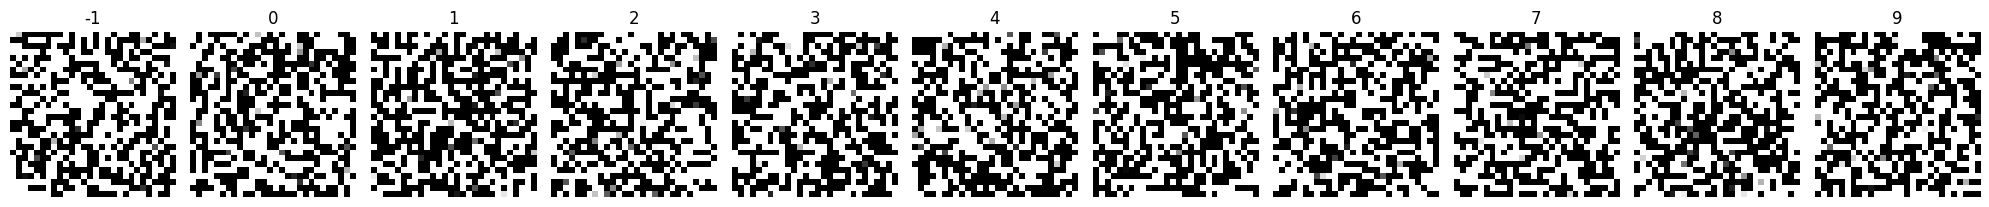

Epoch 2/300
468/468 [==============================] - 123s 262ms/step - noise_loss: 0.0403 - val_loss: 0.3577 - val_noise_loss: 0.3577 - val_image_loss: 9.6061 - learning_rate: 9.9989e-04


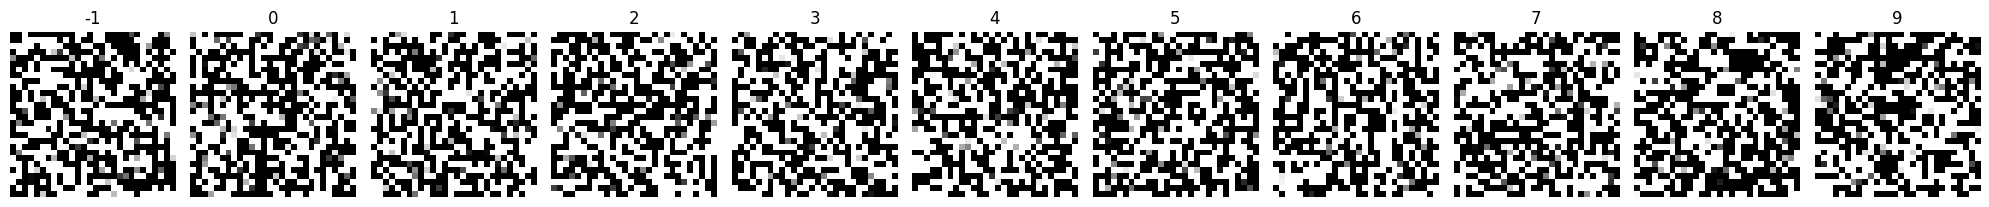

Epoch 3/300
468/468 [==============================] - 123s 263ms/step - noise_loss: 0.0360 - val_loss: 0.1993 - val_noise_loss: 0.1993 - val_image_loss: 4.9258 - learning_rate: 9.9975e-04


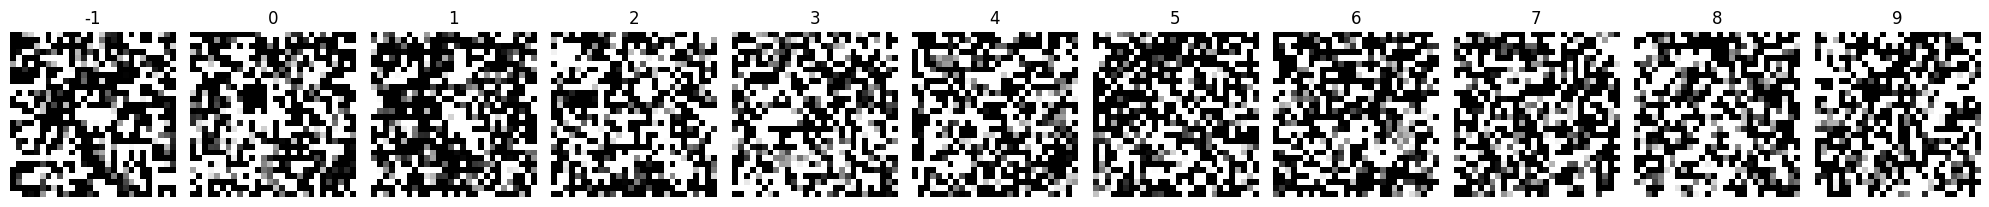

Epoch 4/300
468/468 [==============================] - 121s 257ms/step - noise_loss: 0.0335 - val_loss: 0.1143 - val_noise_loss: 0.1143 - val_image_loss: 2.3354 - learning_rate: 9.9956e-04


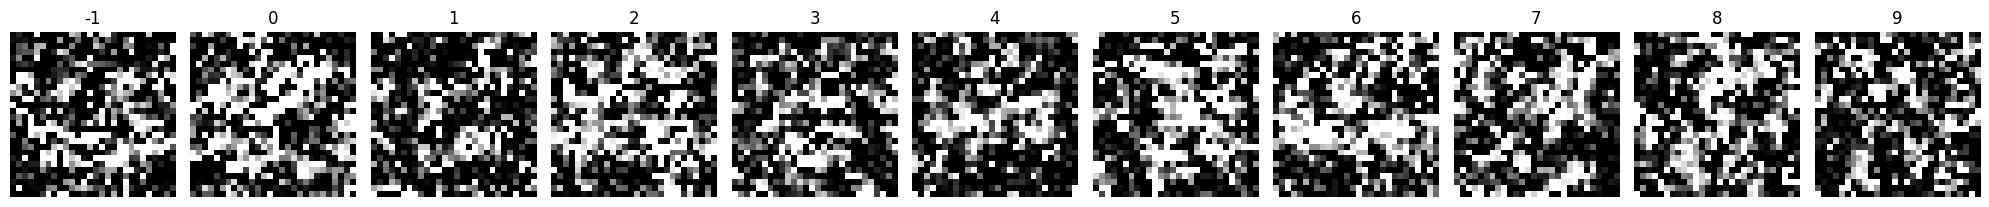

Epoch 5/300
468/468 [==============================] - 122s 260ms/step - noise_loss: 0.0317 - val_loss: 0.0720 - val_noise_loss: 0.0720 - val_image_loss: 1.1299 - learning_rate: 9.9931e-04


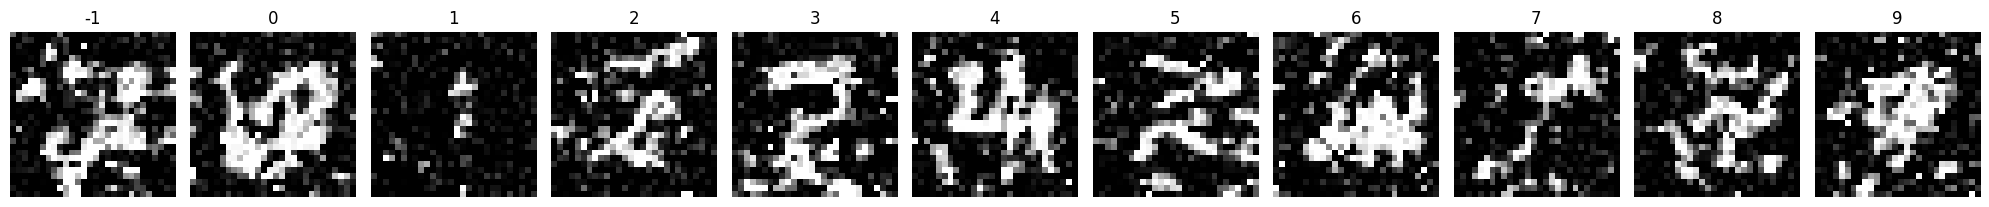

Epoch 6/300
468/468 [==============================] - 128s 273ms/step - noise_loss: 0.0302 - val_loss: 0.0526 - val_noise_loss: 0.0526 - val_image_loss: 0.5996 - learning_rate: 9.9901e-04


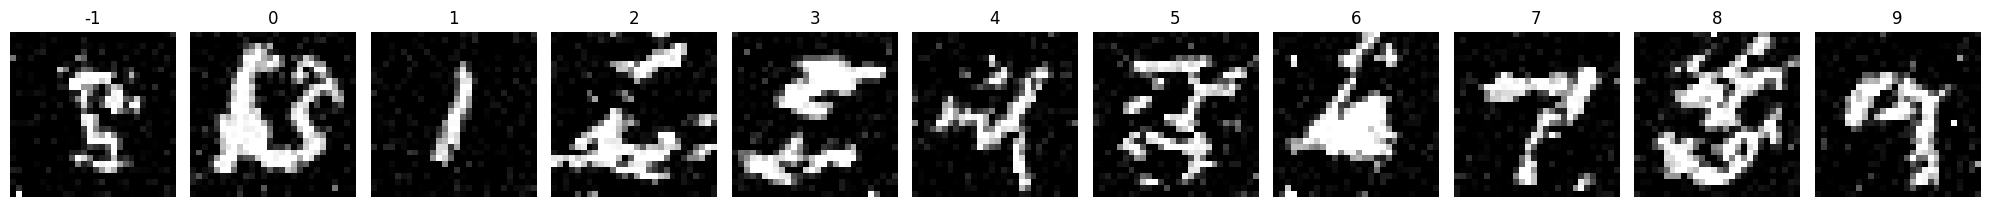

Epoch 7/300
468/468 [==============================] - 125s 266ms/step - noise_loss: 0.0293 - val_loss: 0.0439 - val_noise_loss: 0.0439 - val_image_loss: 0.4261 - learning_rate: 9.9866e-04


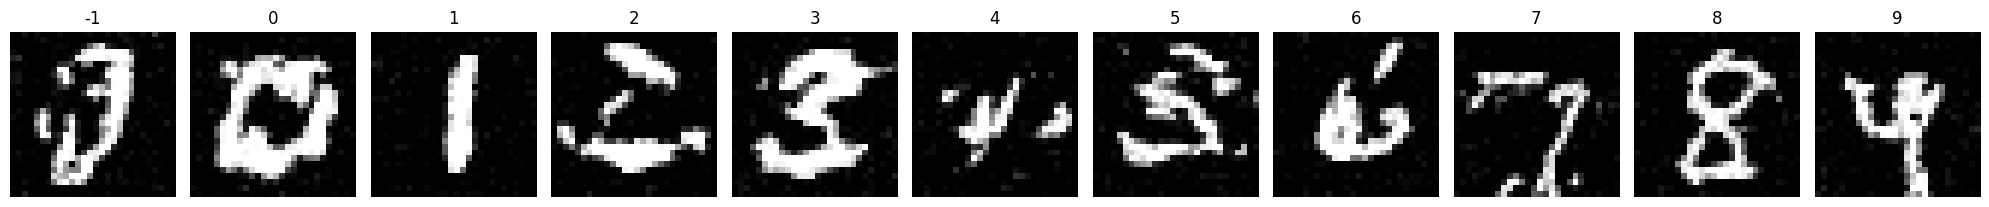

Epoch 8/300
468/468 [==============================] - 126s 269ms/step - noise_loss: 0.0287 - val_loss: 0.0409 - val_noise_loss: 0.0409 - val_image_loss: 0.2923 - learning_rate: 9.9825e-04


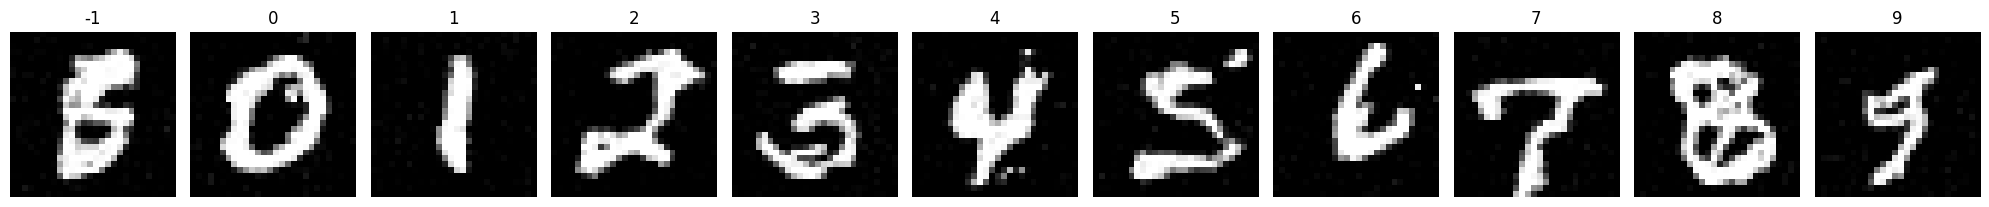

Epoch 9/300
468/468 [==============================] - 120s 257ms/step - noise_loss: 0.0280 - val_loss: 0.0403 - val_noise_loss: 0.0403 - val_image_loss: 0.2492 - learning_rate: 9.9778e-04


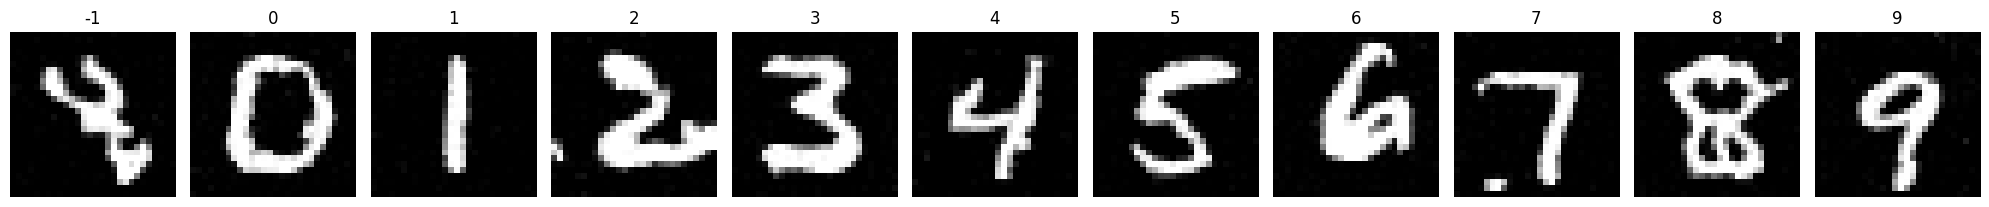

Epoch 10/300
468/468 [==============================] - 118s 251ms/step - noise_loss: 0.0276 - val_loss: 0.0404 - val_noise_loss: 0.0404 - val_image_loss: 0.2279 - learning_rate: 9.9726e-04


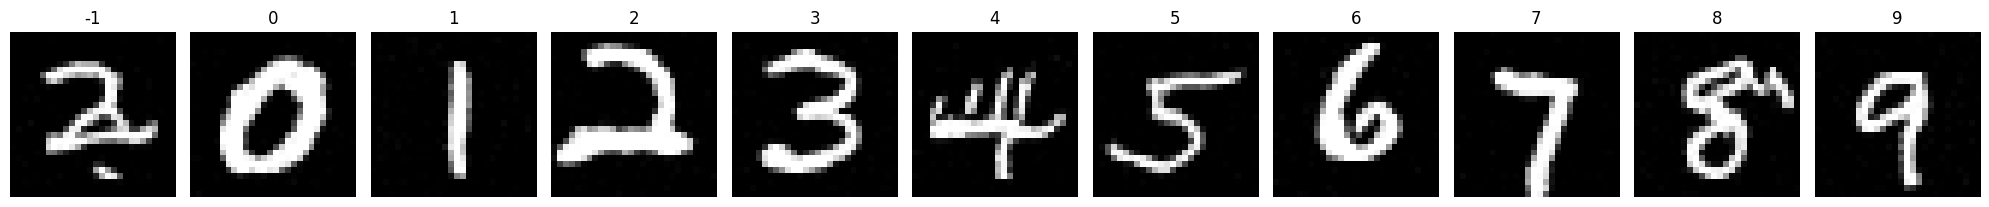

Epoch 11/300
468/468 [==============================] - 120s 256ms/step - noise_loss: 0.0272 - val_loss: 0.0409 - val_noise_loss: 0.0409 - val_image_loss: 0.2312 - learning_rate: 9.9669e-04


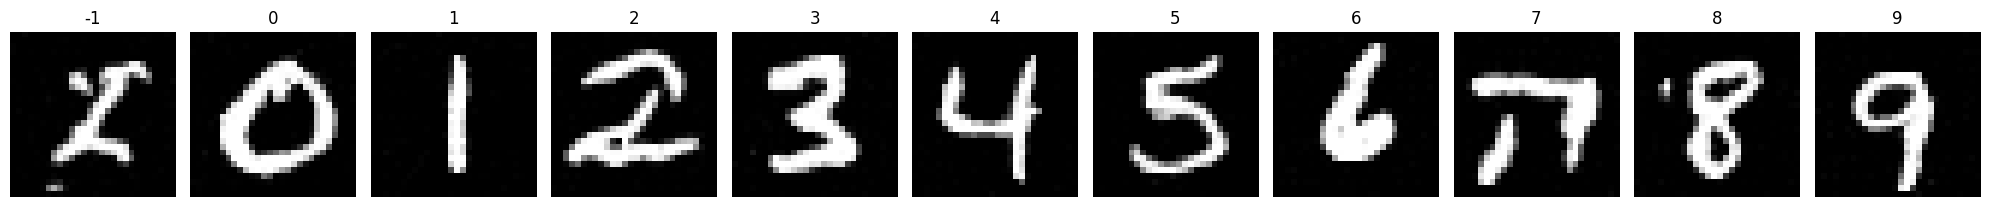

Epoch 12/300
468/468 [==============================] - 121s 258ms/step - noise_loss: 0.0270 - val_loss: 0.0417 - val_noise_loss: 0.0417 - val_image_loss: 0.2221 - learning_rate: 9.9606e-04


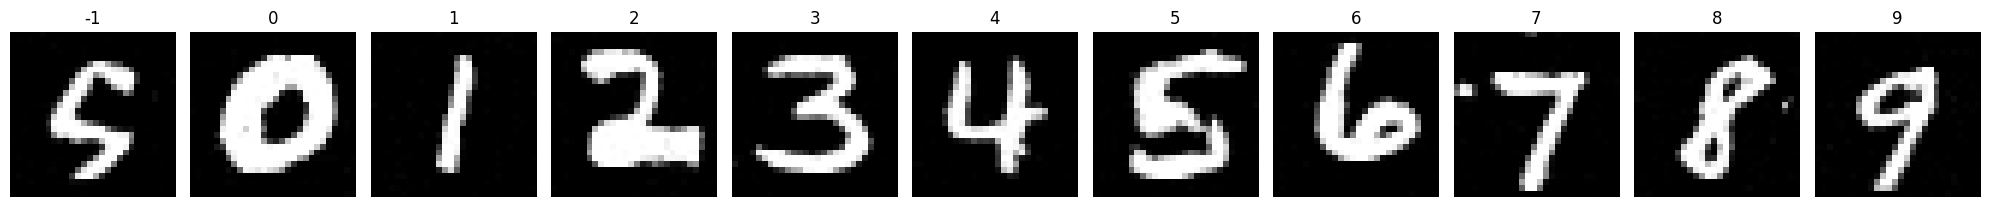

Epoch 13/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0267 - val_loss: 0.0417 - val_noise_loss: 0.0417 - val_image_loss: 0.2182 - learning_rate: 9.9537e-04


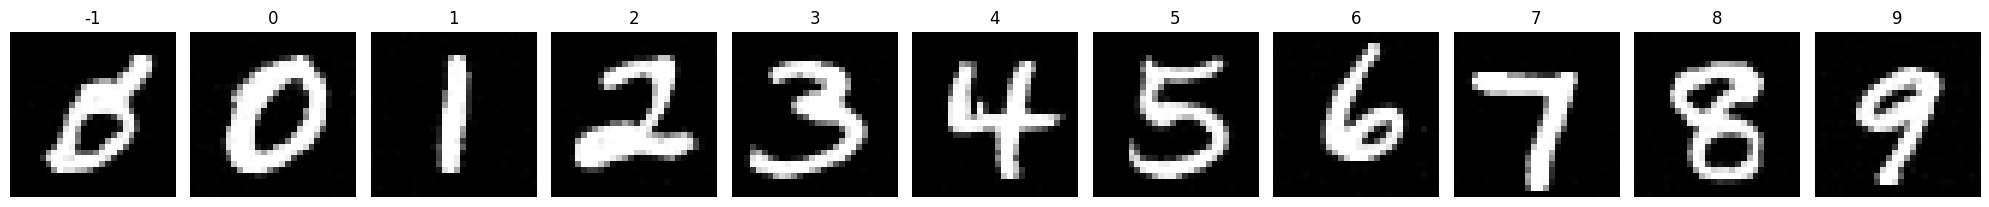

Epoch 14/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0264 - val_loss: 0.0417 - val_noise_loss: 0.0417 - val_image_loss: 0.2202 - learning_rate: 9.9464e-04


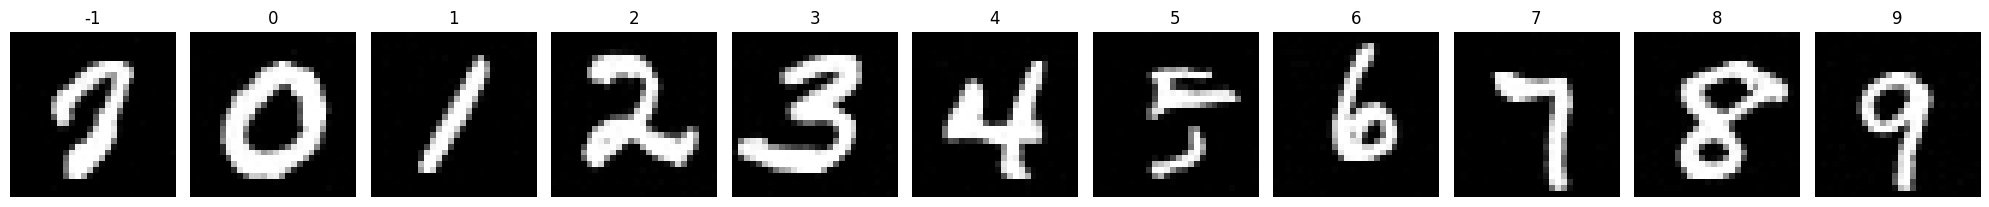

Epoch 15/300
468/468 [==============================] - 118s 252ms/step - noise_loss: 0.0263 - val_loss: 0.0418 - val_noise_loss: 0.0418 - val_image_loss: 0.2237 - learning_rate: 9.9384e-04


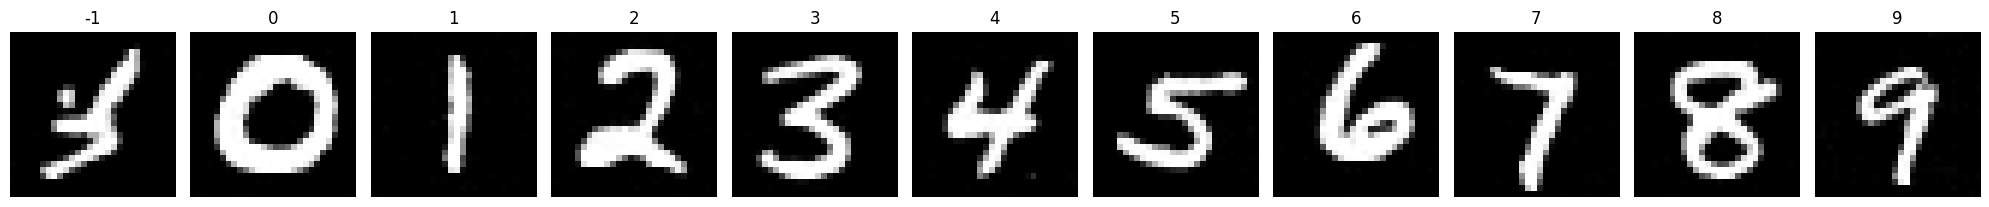

Epoch 16/300
468/468 [==============================] - 119s 253ms/step - noise_loss: 0.0263 - val_loss: 0.0416 - val_noise_loss: 0.0416 - val_image_loss: 0.2232 - learning_rate: 9.9300e-04


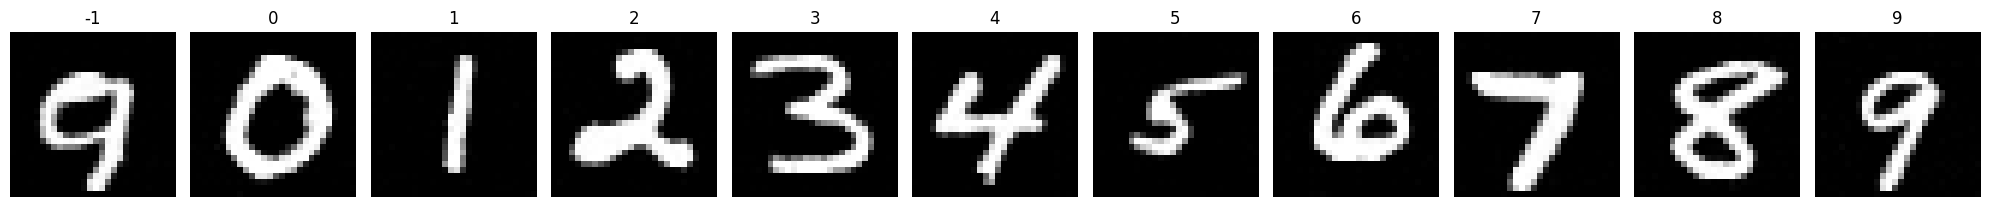

Epoch 17/300
468/468 [==============================] - 119s 254ms/step - noise_loss: 0.0262 - val_loss: 0.0415 - val_noise_loss: 0.0415 - val_image_loss: 0.2178 - learning_rate: 9.9210e-04


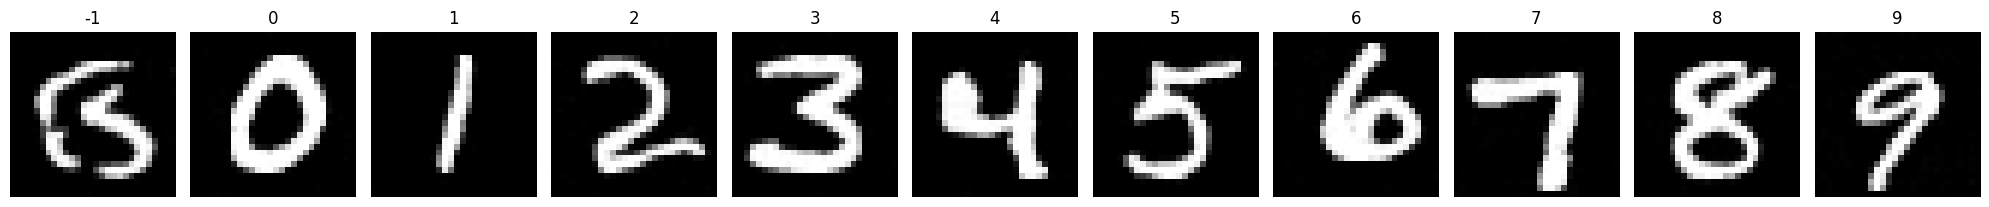

Epoch 18/300
468/468 [==============================] - 120s 256ms/step - noise_loss: 0.0259 - val_loss: 0.0415 - val_noise_loss: 0.0415 - val_image_loss: 0.2232 - learning_rate: 9.9114e-04


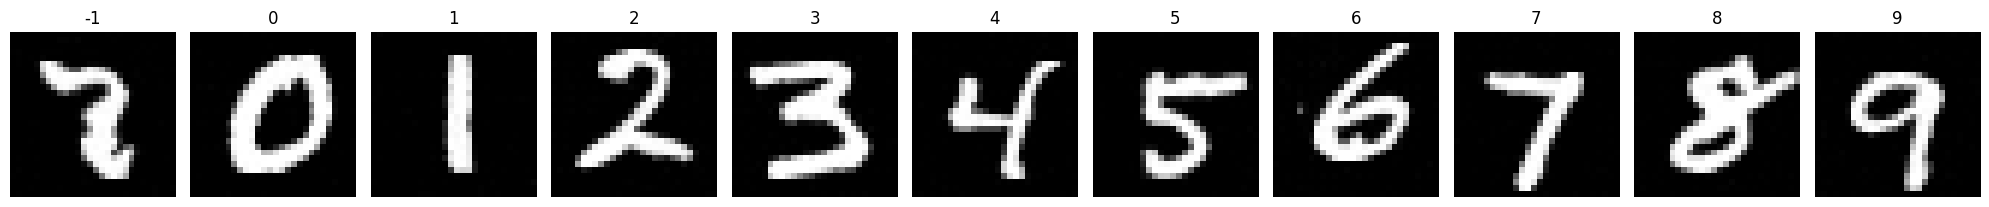

Epoch 19/300
468/468 [==============================] - 120s 255ms/step - noise_loss: 0.0258 - val_loss: 0.0419 - val_noise_loss: 0.0419 - val_image_loss: 0.2159 - learning_rate: 9.9014e-04


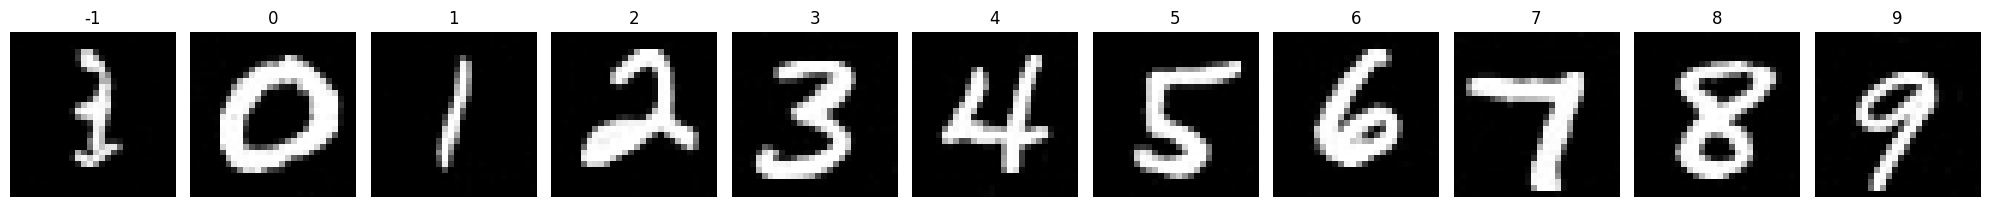

Epoch 20/300
468/468 [==============================] - 119s 255ms/step - noise_loss: 0.0257 - val_loss: 0.0413 - val_noise_loss: 0.0413 - val_image_loss: 0.2226 - learning_rate: 9.8907e-04


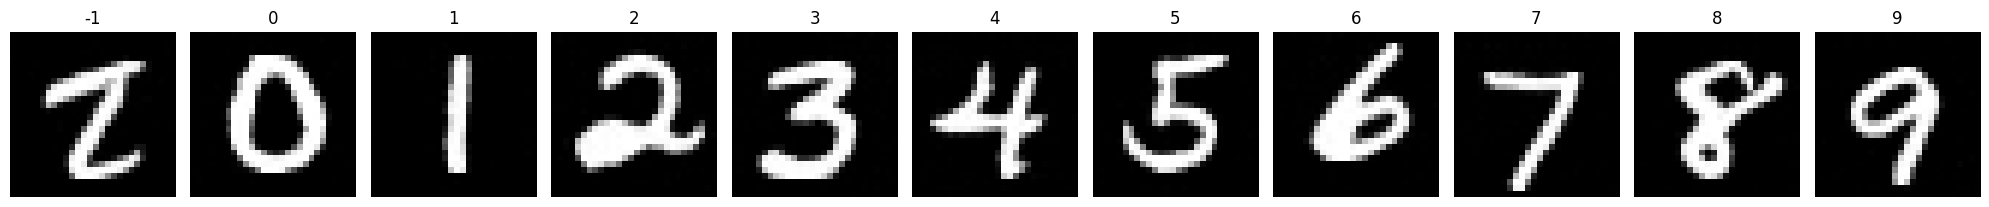

Epoch 21/300
468/468 [==============================] - 119s 254ms/step - noise_loss: 0.0255 - val_loss: 0.0412 - val_noise_loss: 0.0412 - val_image_loss: 0.2177 - learning_rate: 9.8796e-04


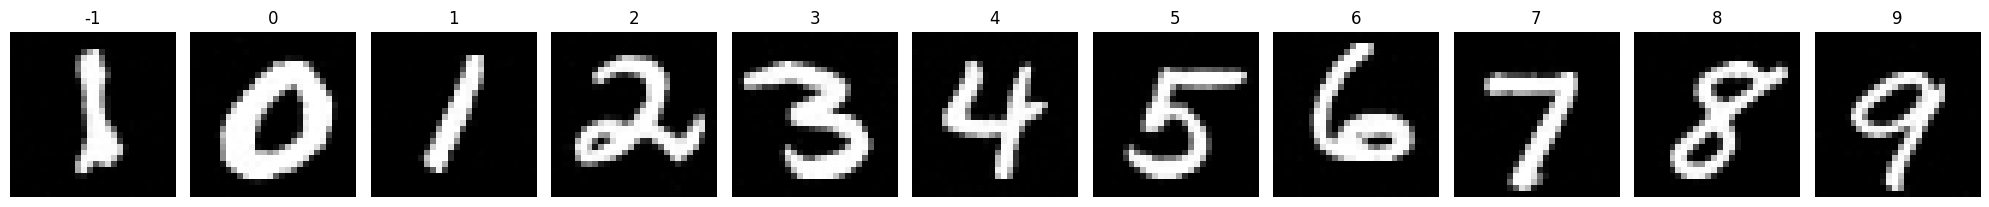

Epoch 22/300
468/468 [==============================] - 119s 253ms/step - noise_loss: 0.0254 - val_loss: 0.0412 - val_noise_loss: 0.0412 - val_image_loss: 0.2194 - learning_rate: 9.8679e-04


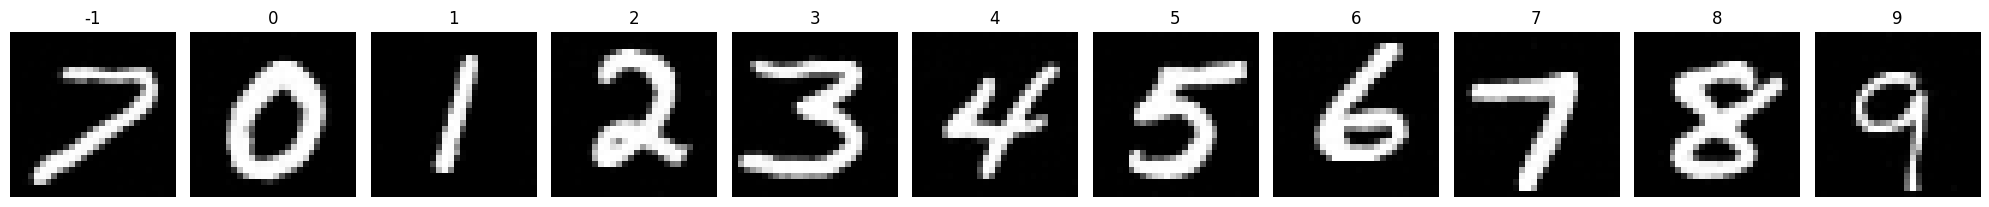

Epoch 23/300
468/468 [==============================] - 119s 253ms/step - noise_loss: 0.0253 - val_loss: 0.0406 - val_noise_loss: 0.0406 - val_image_loss: 0.2201 - learning_rate: 9.8557e-04


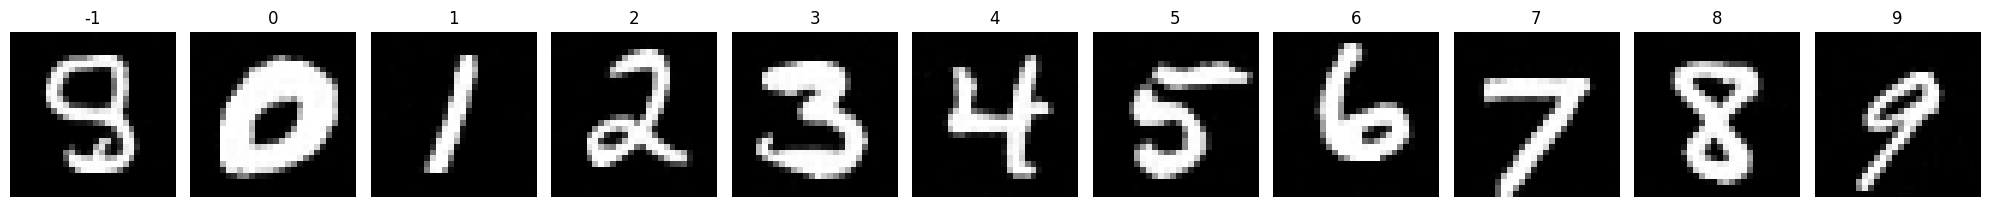

Epoch 24/300
468/468 [==============================] - 122s 261ms/step - noise_loss: 0.0252 - val_loss: 0.0406 - val_noise_loss: 0.0406 - val_image_loss: 0.2210 - learning_rate: 9.8429e-04


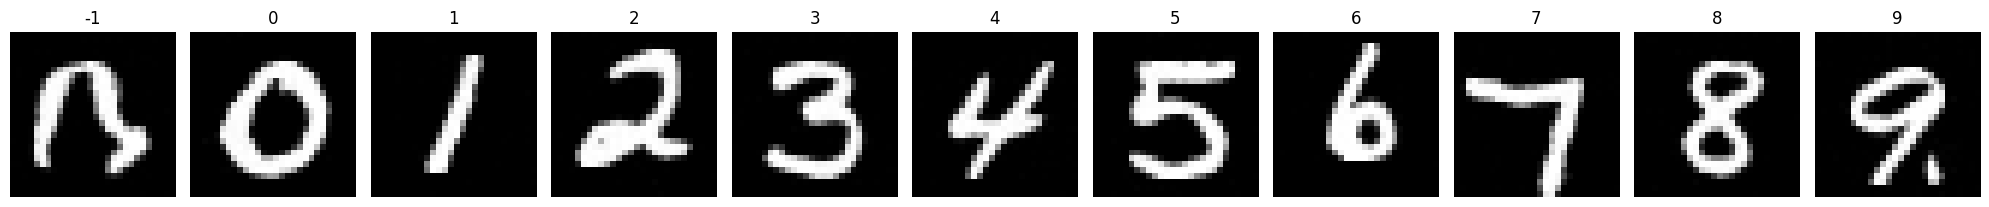

Epoch 25/300
468/468 [==============================] - 123s 262ms/step - noise_loss: 0.0251 - val_loss: 0.0406 - val_noise_loss: 0.0406 - val_image_loss: 0.2160 - learning_rate: 9.8296e-04


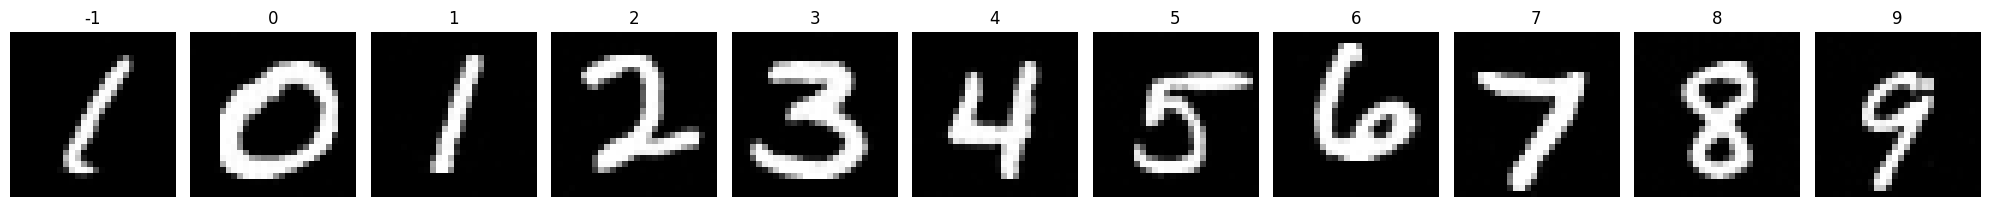

Epoch 26/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0251 - val_loss: 0.0401 - val_noise_loss: 0.0401 - val_image_loss: 0.2156 - learning_rate: 9.8158e-04


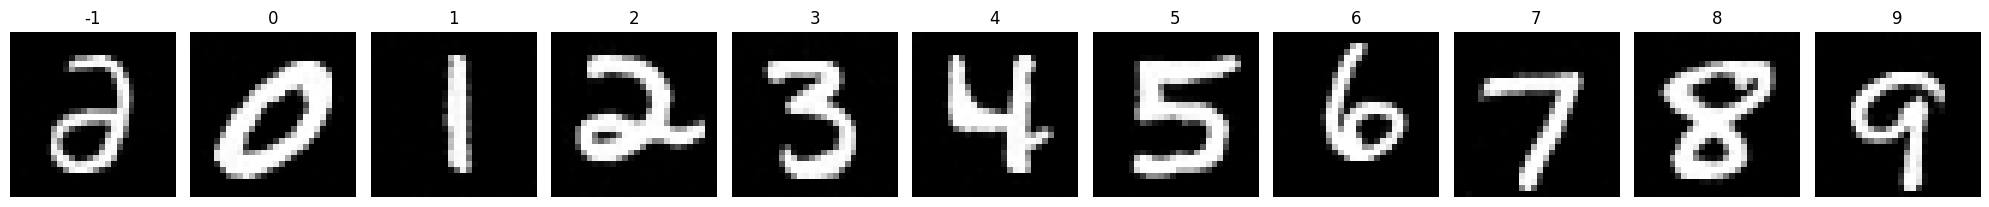

Epoch 27/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0251 - val_loss: 0.0403 - val_noise_loss: 0.0403 - val_image_loss: 0.2136 - learning_rate: 9.8015e-04


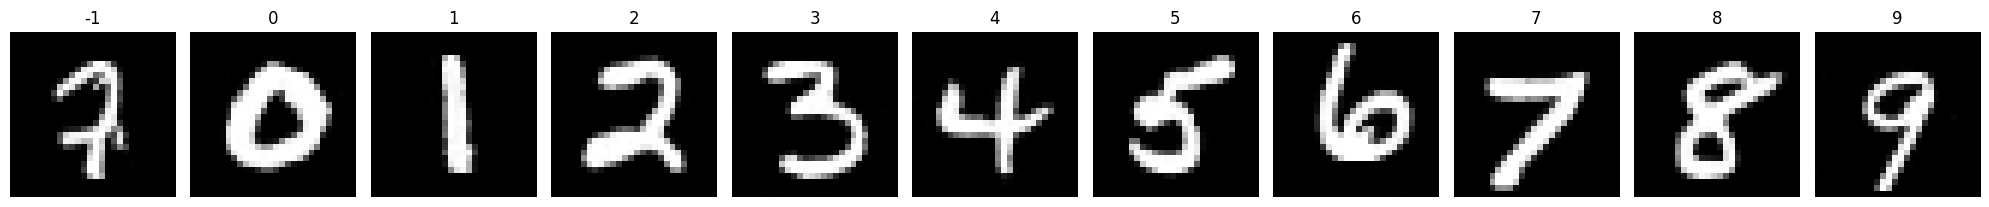

Epoch 28/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0251 - val_loss: 0.0395 - val_noise_loss: 0.0395 - val_image_loss: 0.2116 - learning_rate: 9.7866e-04


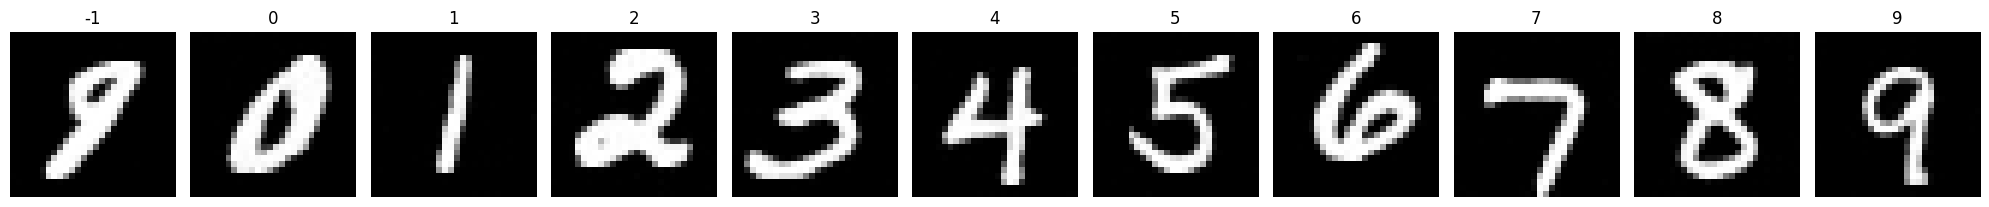

Epoch 29/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0249 - val_loss: 0.0397 - val_noise_loss: 0.0397 - val_image_loss: 0.2101 - learning_rate: 9.7712e-04


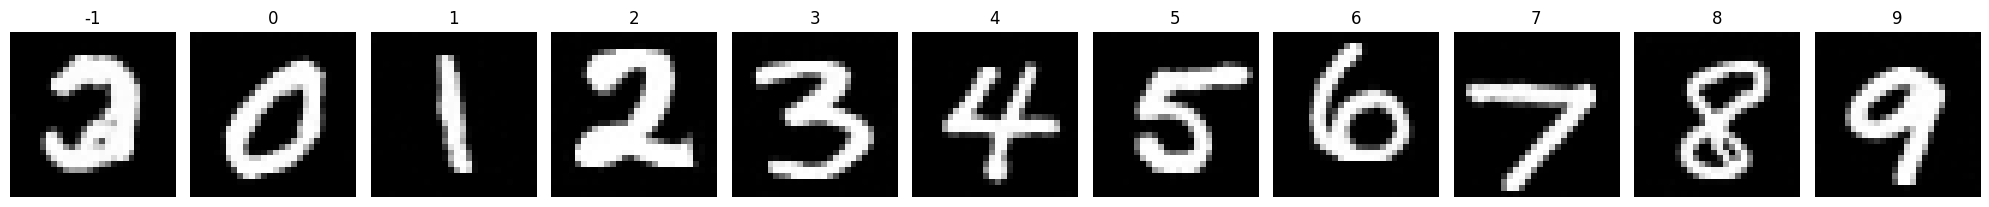

Epoch 30/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0248 - val_loss: 0.0390 - val_noise_loss: 0.0390 - val_image_loss: 0.2090 - learning_rate: 9.7553e-04


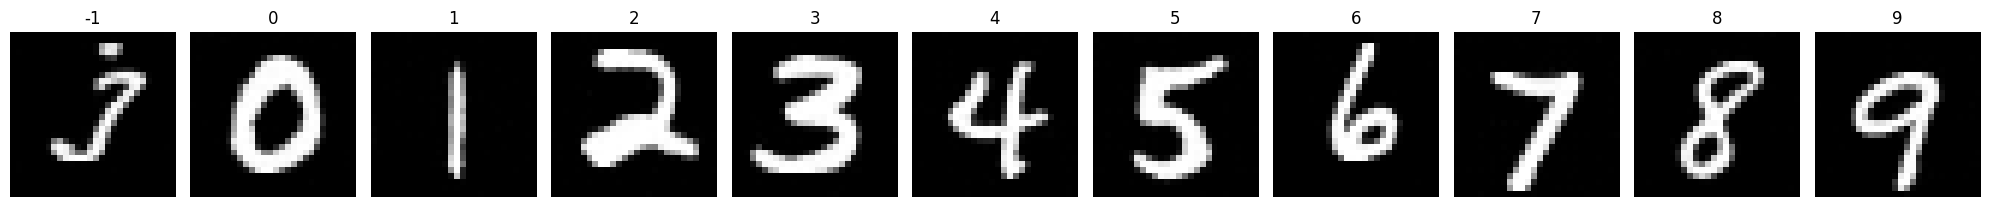

Epoch 31/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0249 - val_loss: 0.0395 - val_noise_loss: 0.0395 - val_image_loss: 0.2143 - learning_rate: 9.7388e-04


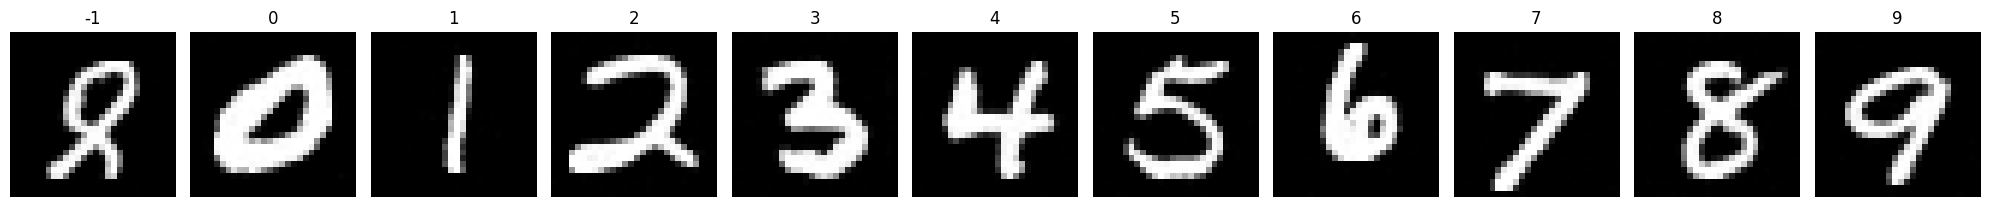

Epoch 32/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0249 - val_loss: 0.0395 - val_noise_loss: 0.0395 - val_image_loss: 0.2131 - learning_rate: 9.7219e-04


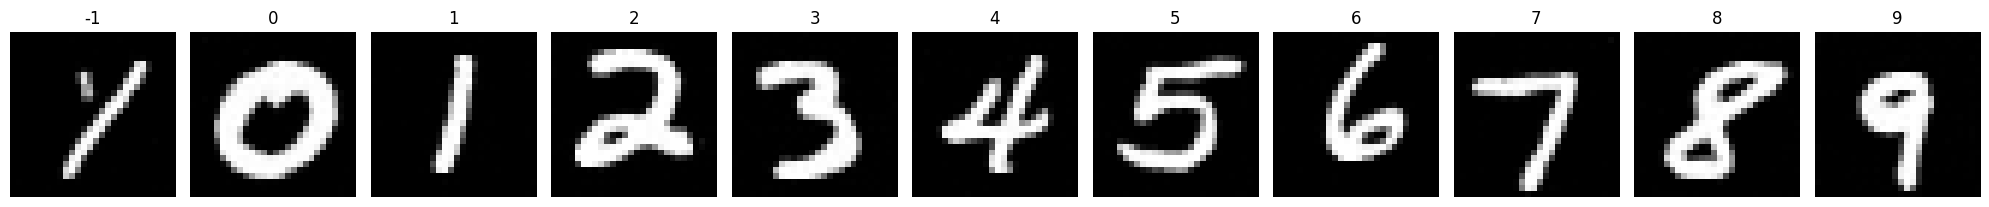

Epoch 33/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0247 - val_loss: 0.0388 - val_noise_loss: 0.0388 - val_image_loss: 0.2133 - learning_rate: 9.7044e-04


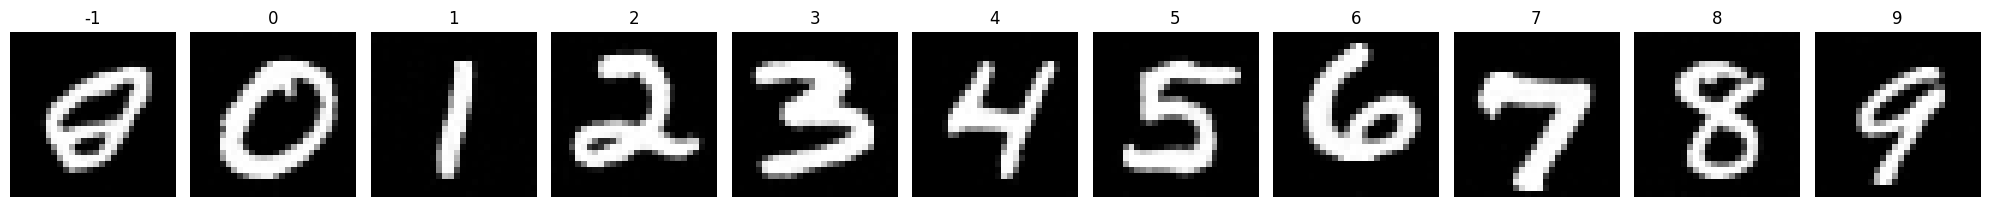

Epoch 34/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0246 - val_loss: 0.0384 - val_noise_loss: 0.0384 - val_image_loss: 0.2105 - learning_rate: 9.6864e-04


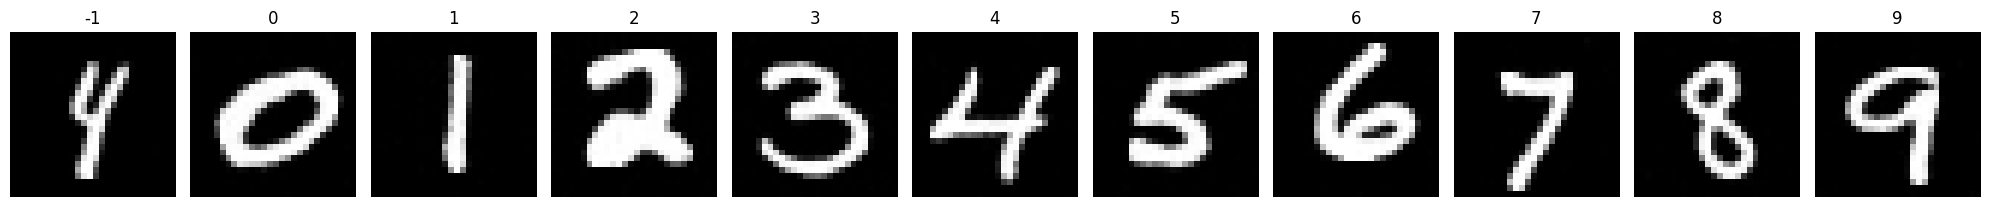

Epoch 35/300
468/468 [==============================] - 117s 248ms/step - noise_loss: 0.0247 - val_loss: 0.0384 - val_noise_loss: 0.0384 - val_image_loss: 0.2156 - learning_rate: 9.6679e-04


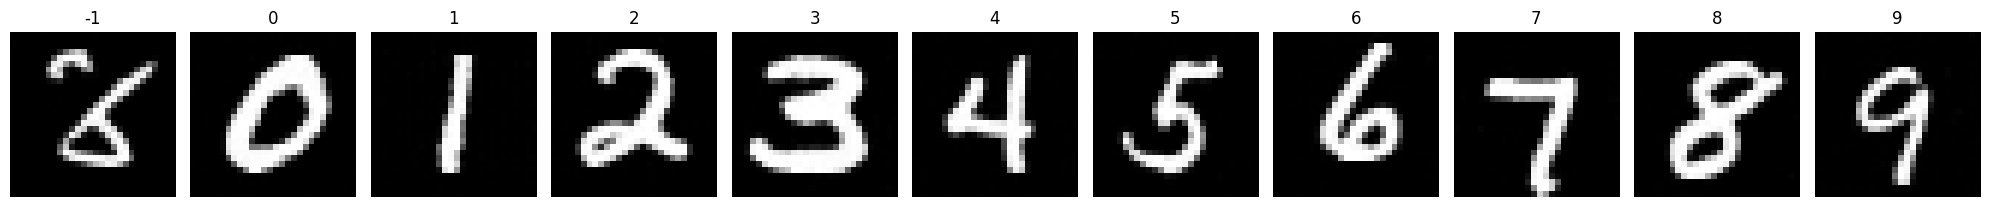

Epoch 36/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0246 - val_loss: 0.0386 - val_noise_loss: 0.0386 - val_image_loss: 0.2088 - learning_rate: 9.6489e-04


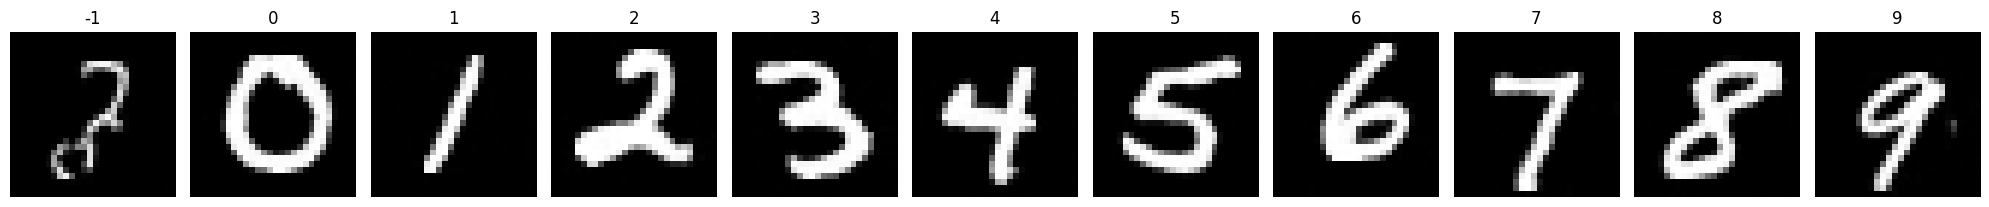

Epoch 37/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0246 - val_loss: 0.0386 - val_noise_loss: 0.0386 - val_image_loss: 0.2092 - learning_rate: 9.6294e-04


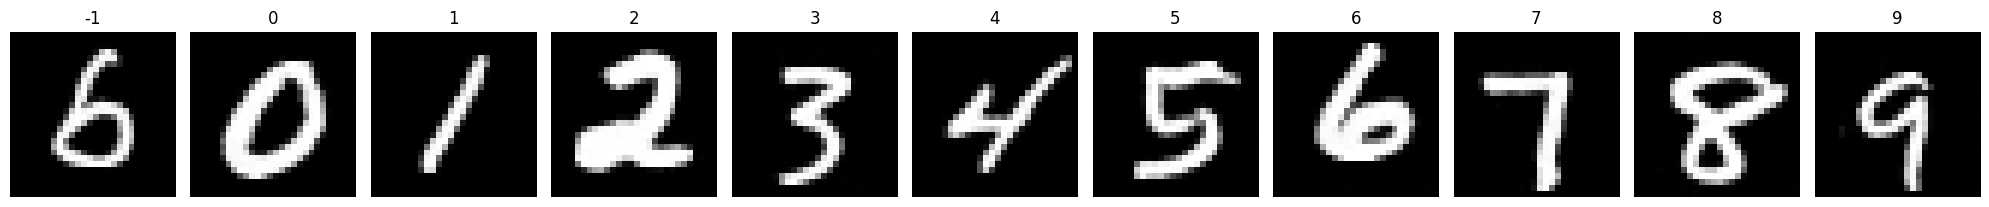

Epoch 38/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0246 - val_loss: 0.0386 - val_noise_loss: 0.0386 - val_image_loss: 0.2161 - learning_rate: 9.6093e-04


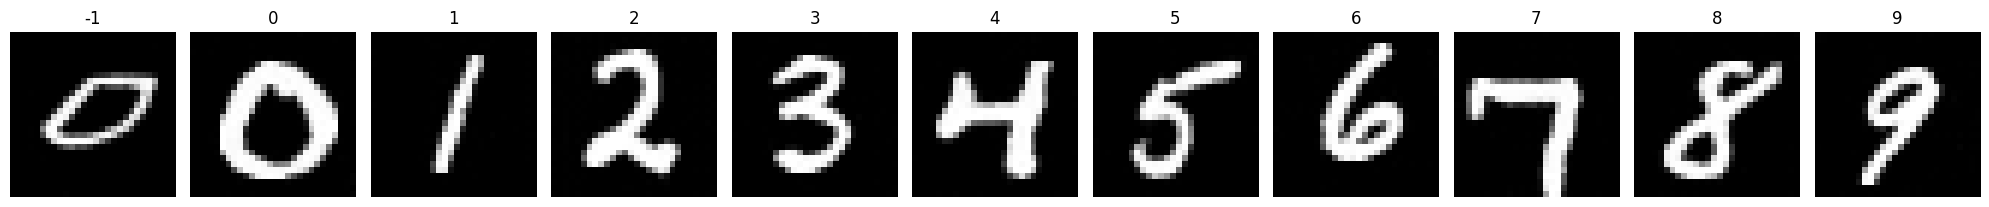

Epoch 39/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0245 - val_loss: 0.0383 - val_noise_loss: 0.0383 - val_image_loss: 0.2100 - learning_rate: 9.5888e-04


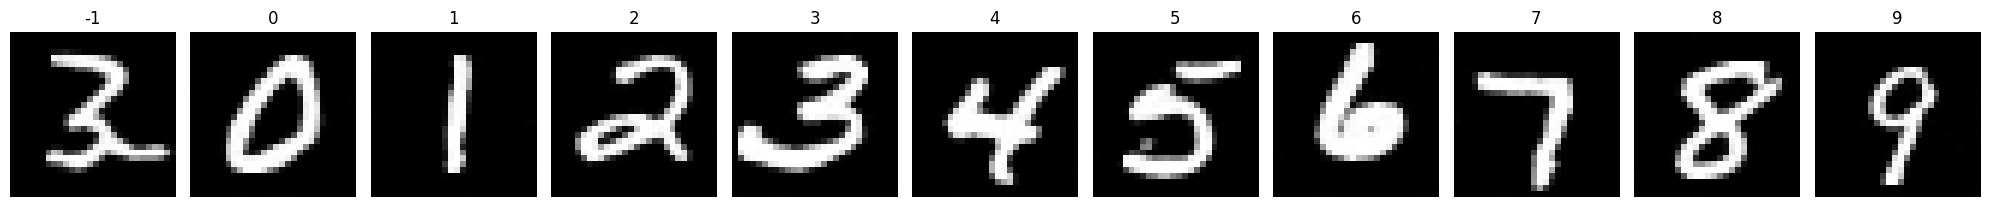

Epoch 40/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0245 - val_loss: 0.0380 - val_noise_loss: 0.0380 - val_image_loss: 0.2156 - learning_rate: 9.5677e-04


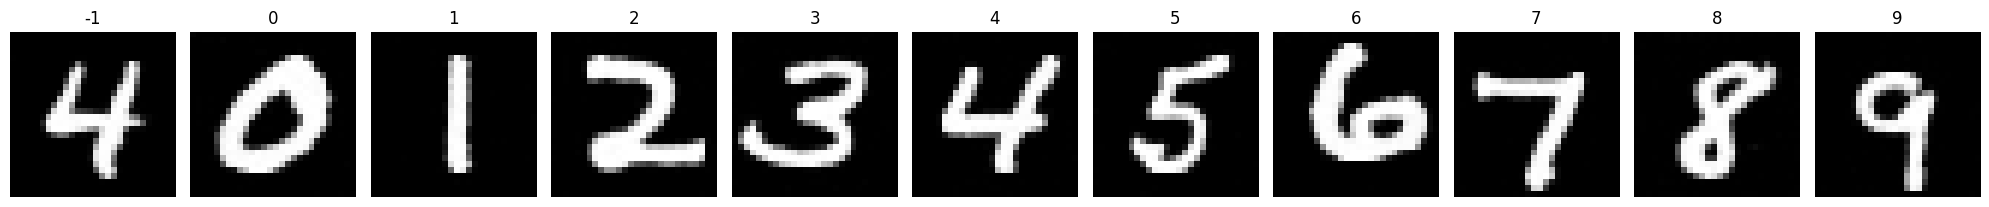

Epoch 41/300
468/468 [==============================] - 117s 251ms/step - noise_loss: 0.0244 - val_loss: 0.0382 - val_noise_loss: 0.0382 - val_image_loss: 0.2057 - learning_rate: 9.5462e-04


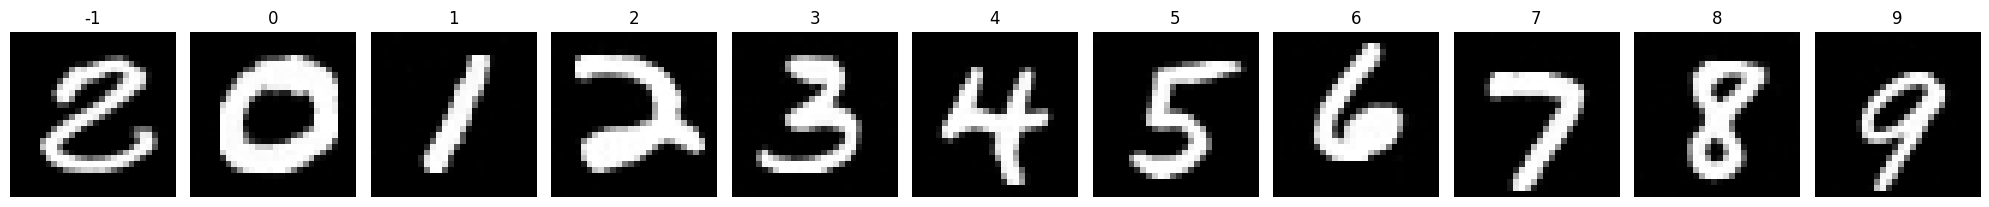

Epoch 42/300
468/468 [==============================] - 118s 251ms/step - noise_loss: 0.0245 - val_loss: 0.0377 - val_noise_loss: 0.0377 - val_image_loss: 0.2070 - learning_rate: 9.5241e-04


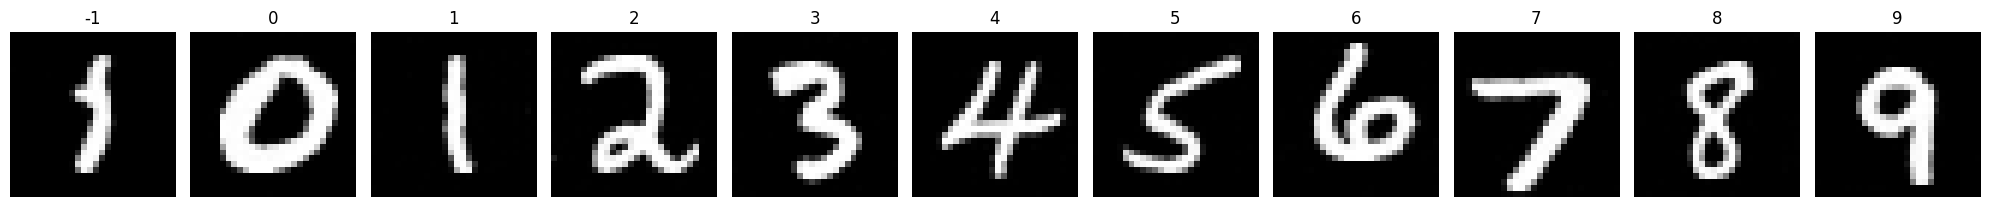

Epoch 43/300
468/468 [==============================] - 117s 250ms/step - noise_loss: 0.0244 - val_loss: 0.0382 - val_noise_loss: 0.0382 - val_image_loss: 0.2109 - learning_rate: 9.5016e-04


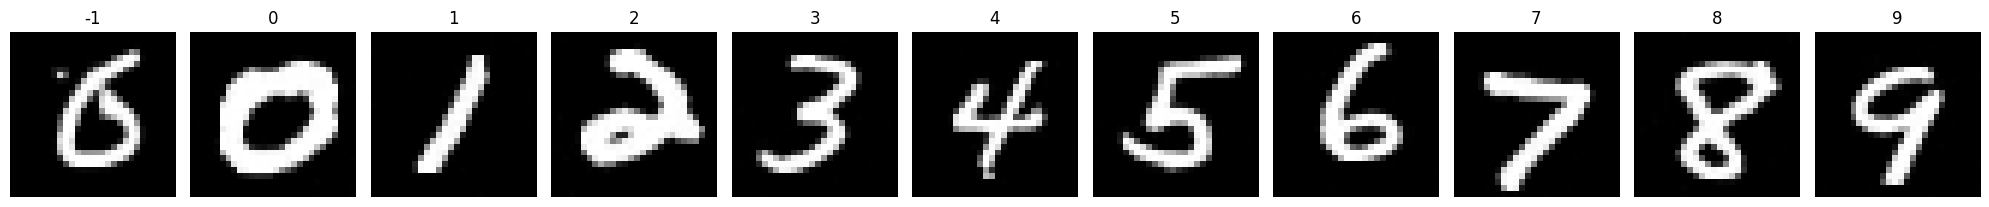

Epoch 44/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0242 - val_loss: 0.0379 - val_noise_loss: 0.0379 - val_image_loss: 0.2098 - learning_rate: 9.4786e-04


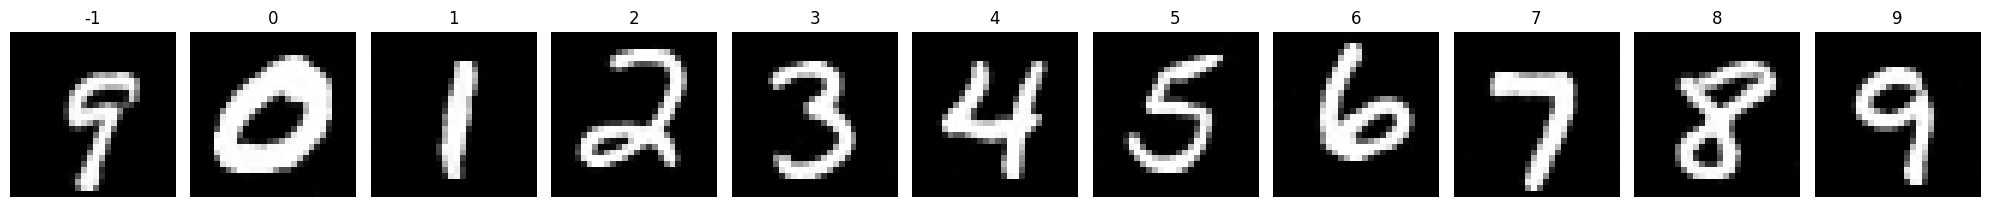

Epoch 45/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0242 - val_loss: 0.0376 - val_noise_loss: 0.0376 - val_image_loss: 0.2093 - learning_rate: 9.4550e-04


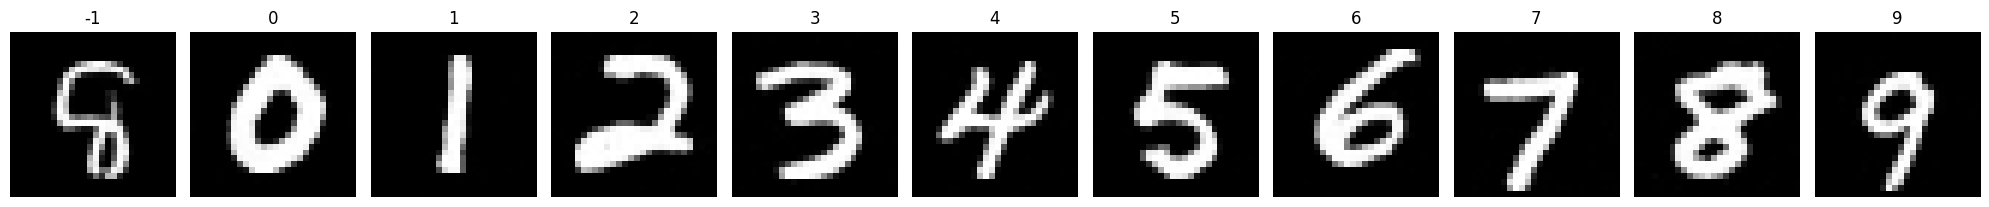

Epoch 46/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0245 - val_loss: 0.0378 - val_noise_loss: 0.0378 - val_image_loss: 0.2102 - learning_rate: 9.4310e-04


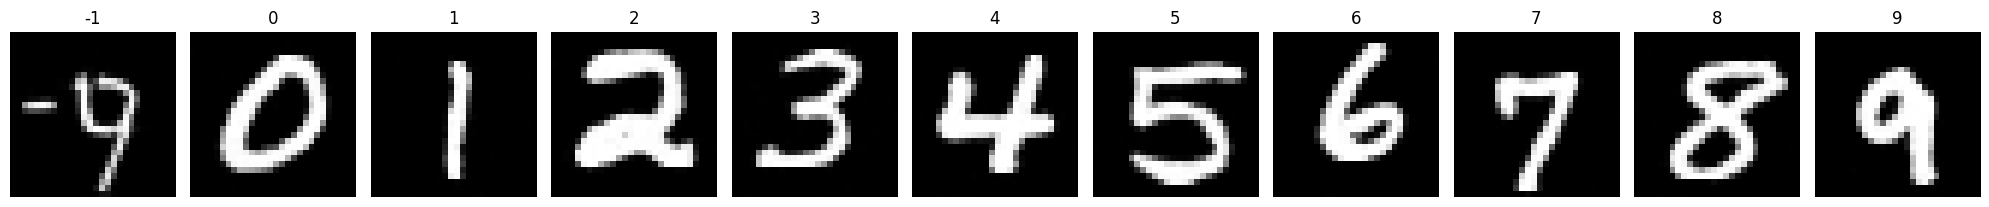

Epoch 47/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0243 - val_loss: 0.0380 - val_noise_loss: 0.0380 - val_image_loss: 0.2053 - learning_rate: 9.4065e-04


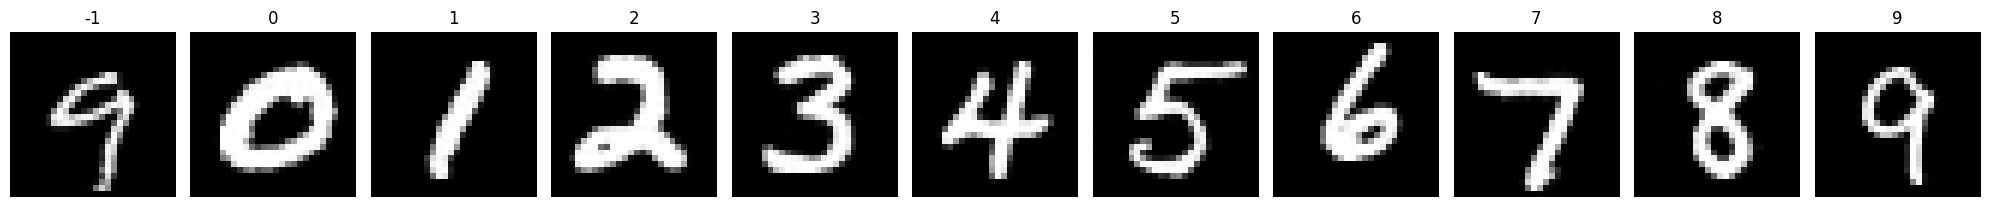

Epoch 48/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0241 - val_loss: 0.0374 - val_noise_loss: 0.0374 - val_image_loss: 0.2074 - learning_rate: 9.3815e-04


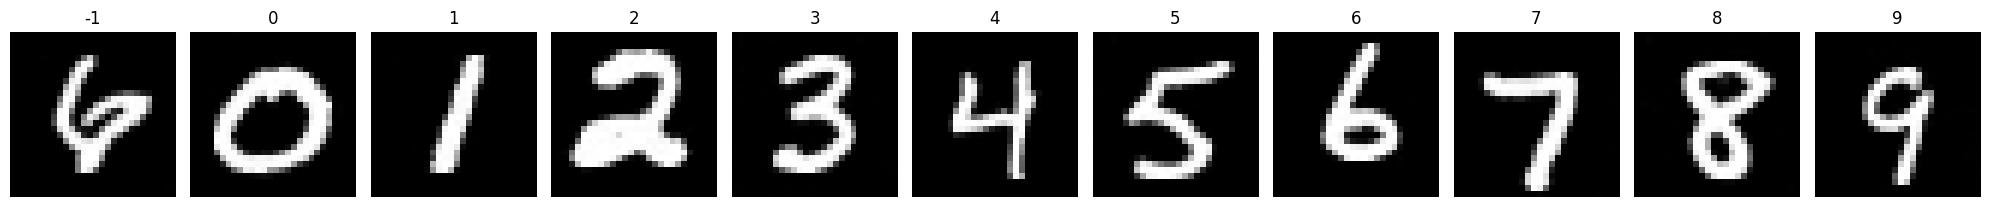

Epoch 49/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0241 - val_loss: 0.0377 - val_noise_loss: 0.0377 - val_image_loss: 0.2098 - learning_rate: 9.3561e-04


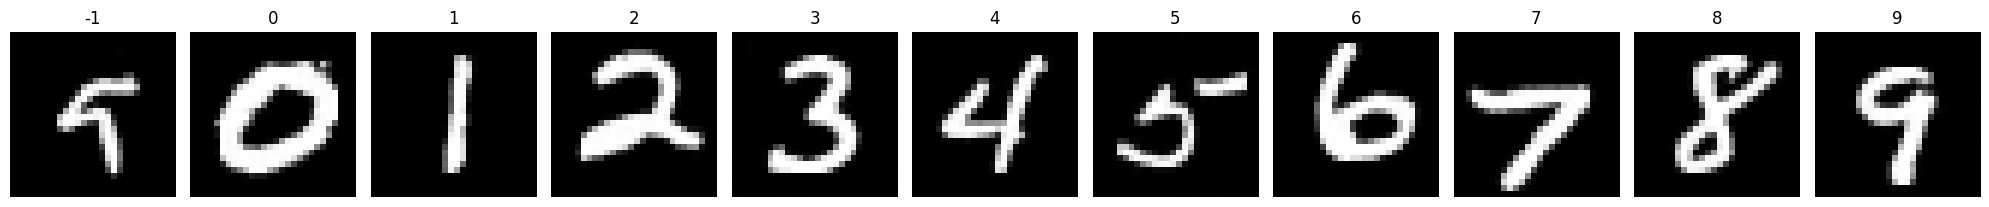

Epoch 50/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0242 - val_loss: 0.0379 - val_noise_loss: 0.0379 - val_image_loss: 0.2106 - learning_rate: 9.3301e-04


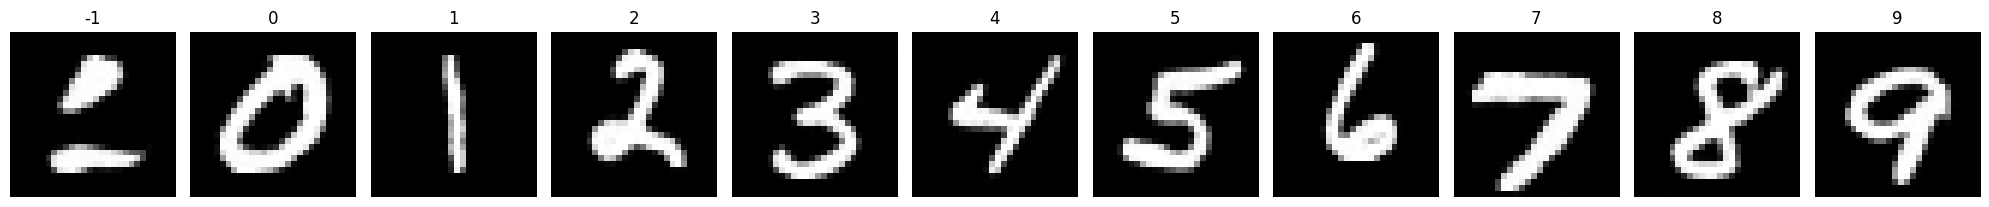

Epoch 51/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0241 - val_loss: 0.0372 - val_noise_loss: 0.0372 - val_image_loss: 0.2040 - learning_rate: 9.3037e-04


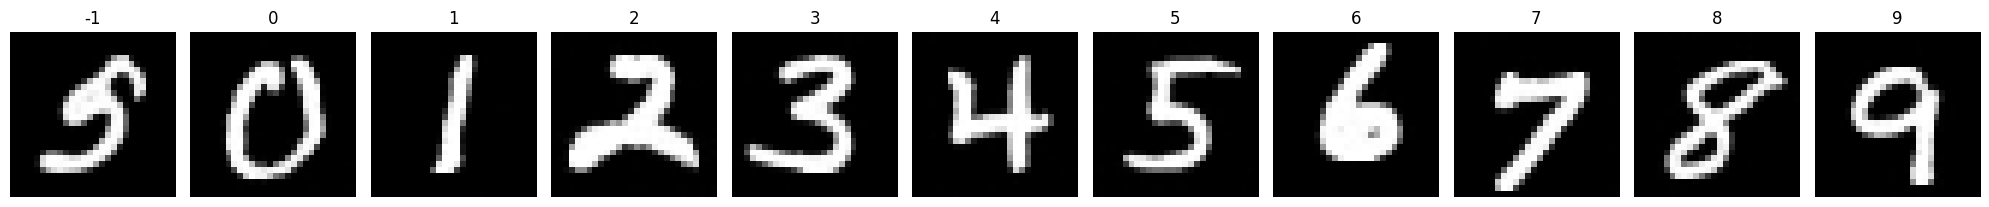

Epoch 52/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0240 - val_loss: 0.0374 - val_noise_loss: 0.0374 - val_image_loss: 0.2066 - learning_rate: 9.2768e-04


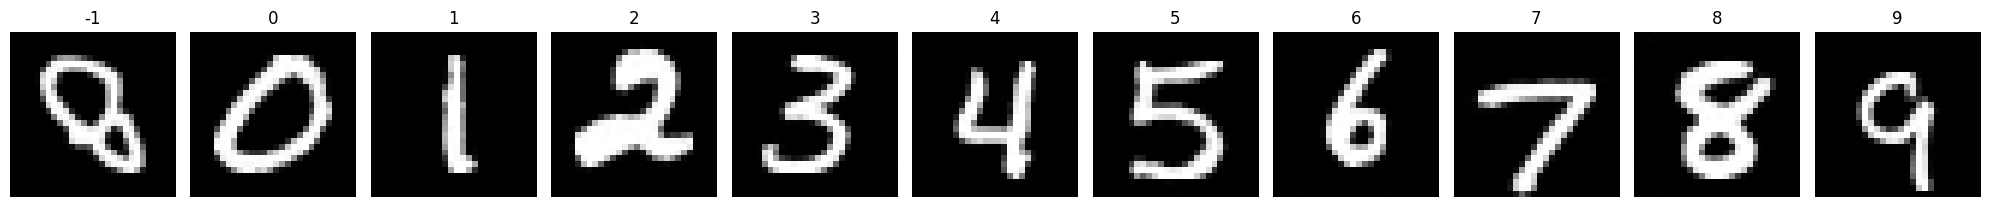

Epoch 53/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0240 - val_loss: 0.0371 - val_noise_loss: 0.0371 - val_image_loss: 0.2065 - learning_rate: 9.2495e-04


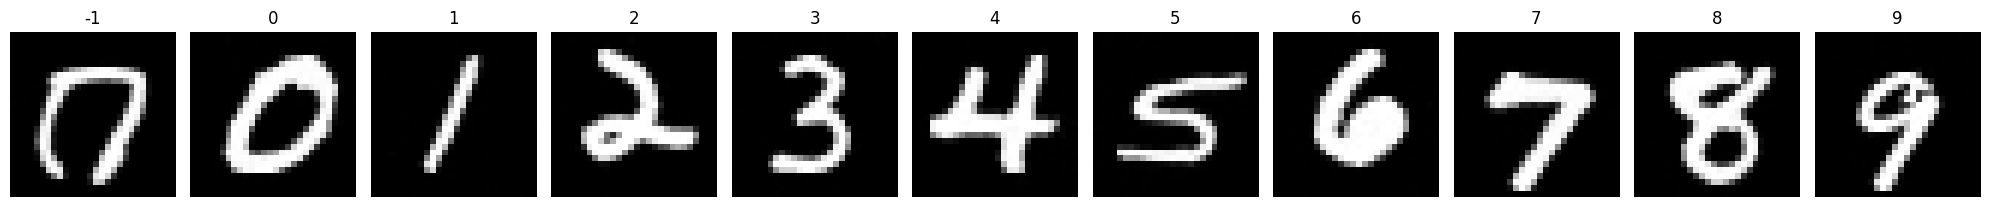

Epoch 54/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0240 - val_loss: 0.0373 - val_noise_loss: 0.0373 - val_image_loss: 0.2090 - learning_rate: 9.2216e-04


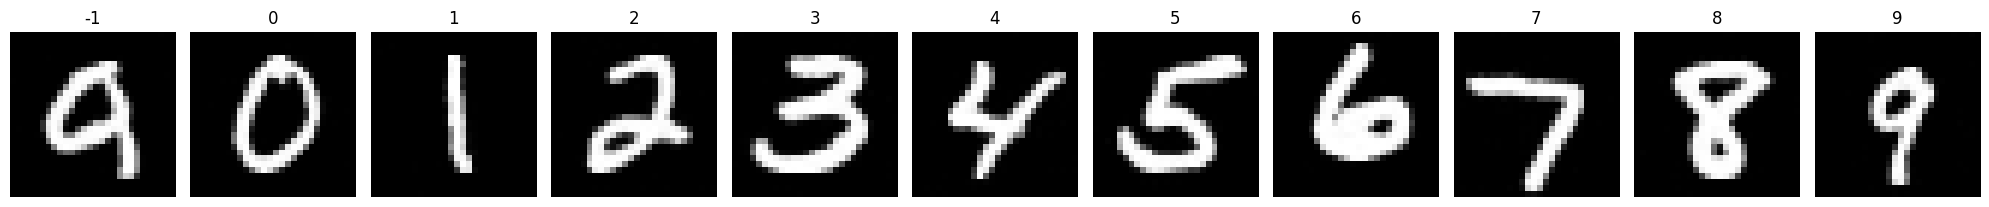

Epoch 55/300
468/468 [==============================] - 118s 252ms/step - noise_loss: 0.0240 - val_loss: 0.0371 - val_noise_loss: 0.0371 - val_image_loss: 0.2071 - learning_rate: 9.1934e-04


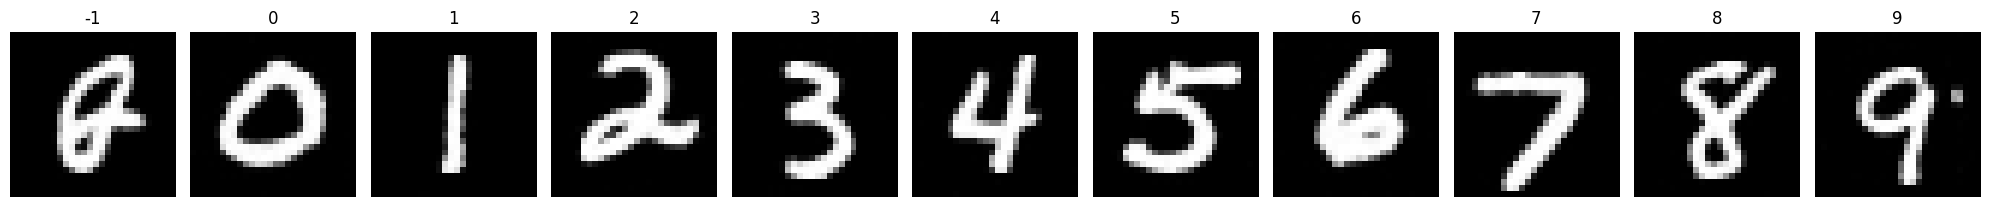

Epoch 56/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0241 - val_loss: 0.0374 - val_noise_loss: 0.0374 - val_image_loss: 0.2111 - learning_rate: 9.1646e-04


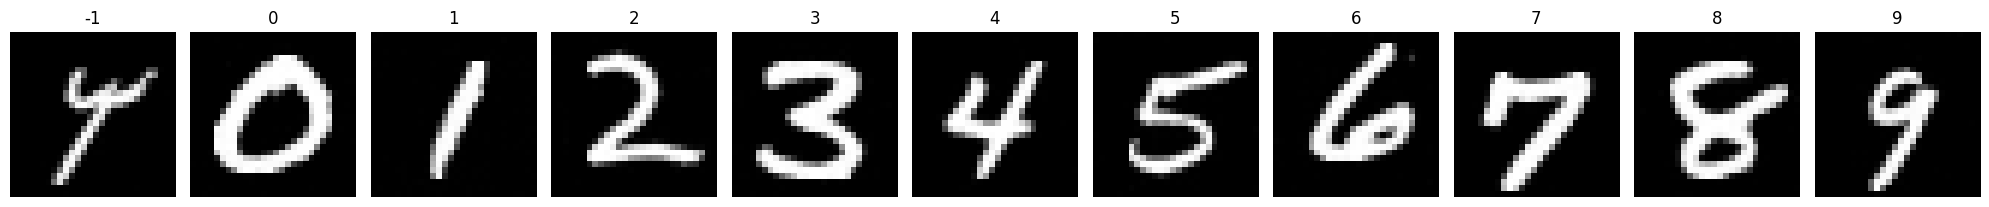

Epoch 57/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0240 - val_loss: 0.0377 - val_noise_loss: 0.0377 - val_image_loss: 0.2035 - learning_rate: 9.1354e-04


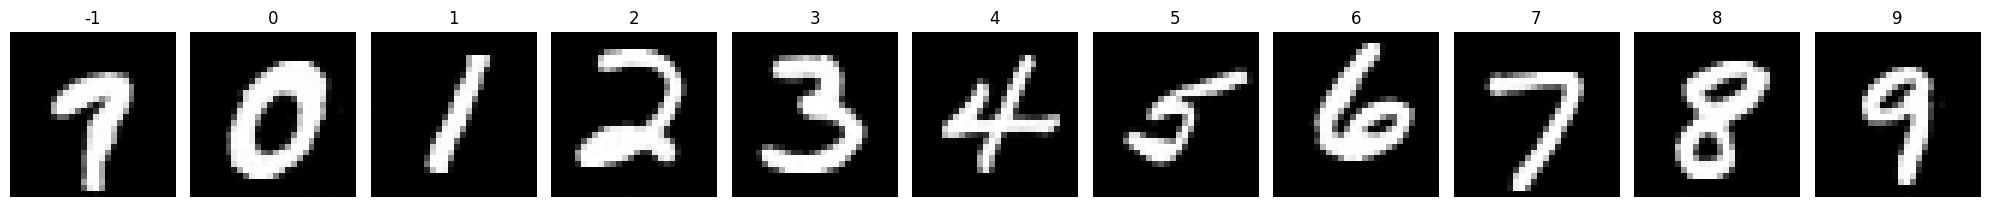

Epoch 58/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0238 - val_loss: 0.0368 - val_noise_loss: 0.0368 - val_image_loss: 0.2034 - learning_rate: 9.1057e-04


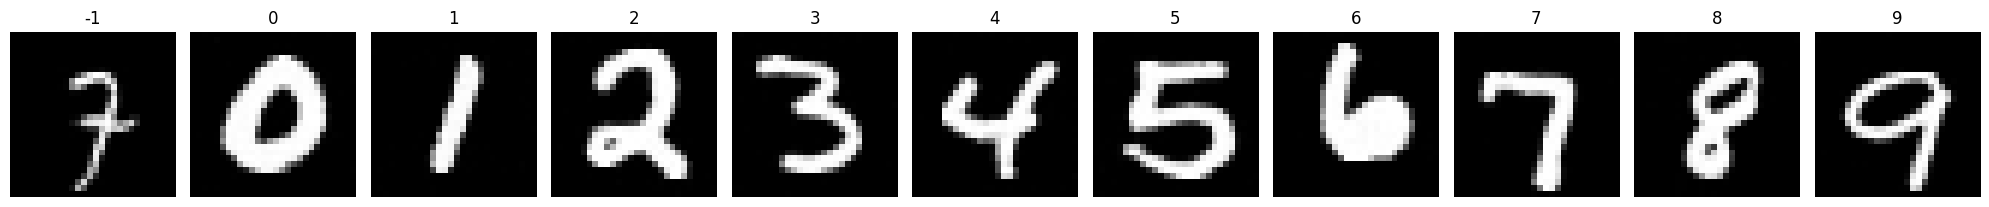

Epoch 59/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0239 - val_loss: 0.0370 - val_noise_loss: 0.0370 - val_image_loss: 0.2091 - learning_rate: 9.0756e-04


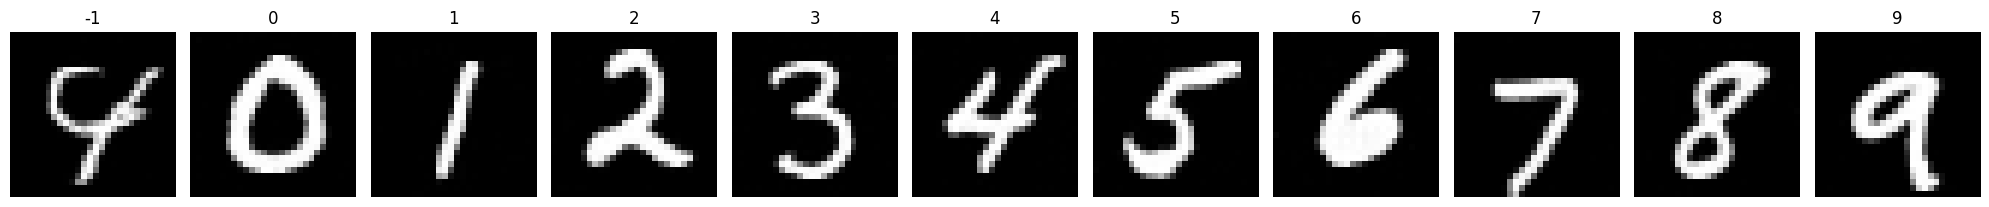

Epoch 60/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0239 - val_loss: 0.0369 - val_noise_loss: 0.0369 - val_image_loss: 0.2029 - learning_rate: 9.0451e-04


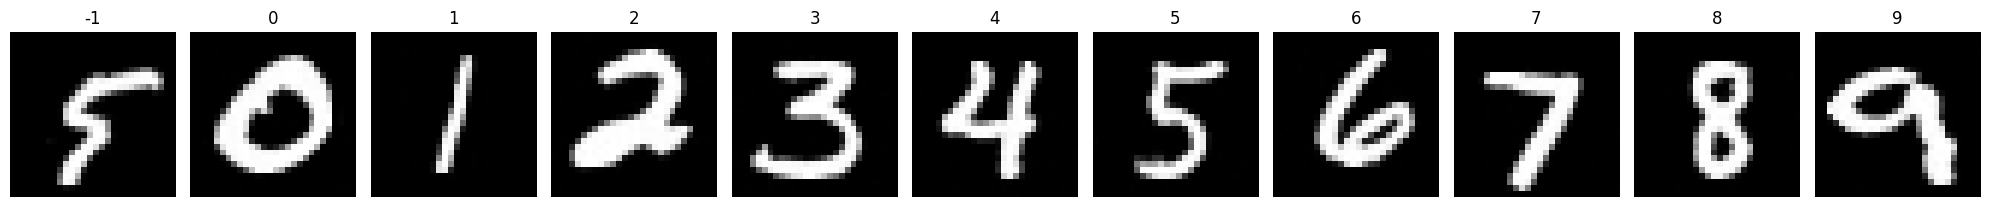

Epoch 61/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0240 - val_loss: 0.0371 - val_noise_loss: 0.0371 - val_image_loss: 0.2068 - learning_rate: 9.0141e-04


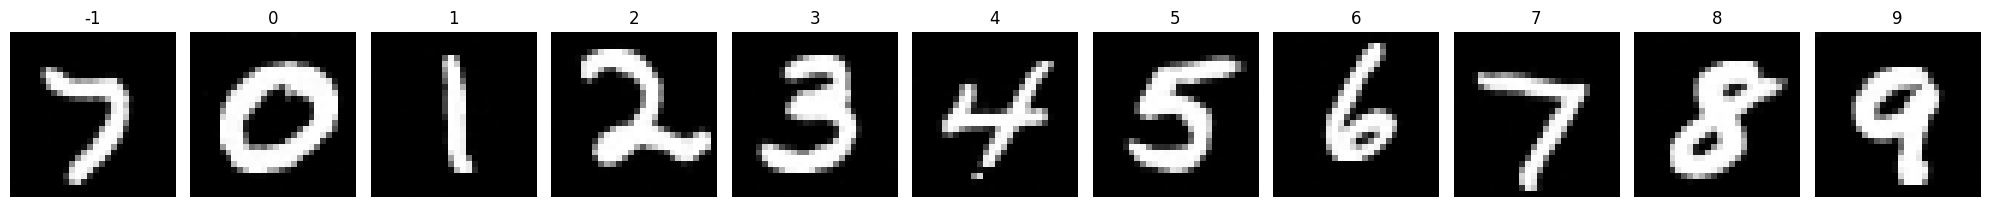

Epoch 62/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0239 - val_loss: 0.0367 - val_noise_loss: 0.0367 - val_image_loss: 0.2059 - learning_rate: 8.9827e-04


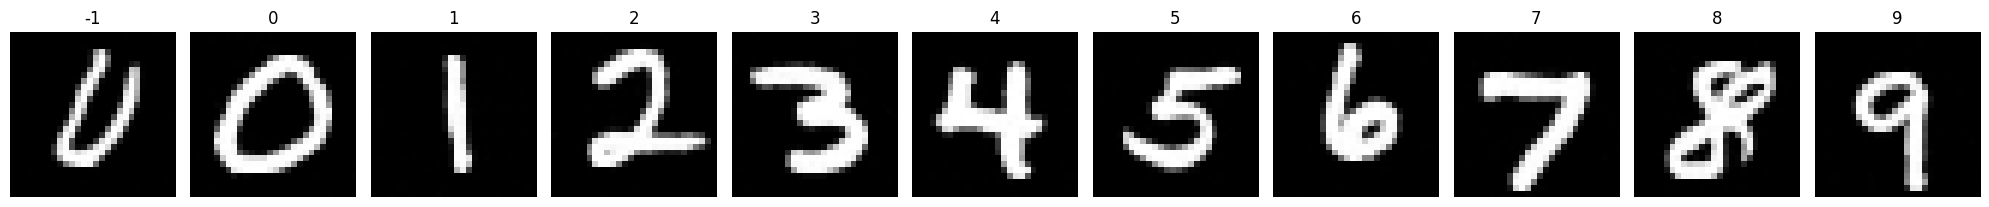

Epoch 63/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0238 - val_loss: 0.0366 - val_noise_loss: 0.0366 - val_image_loss: 0.2035 - learning_rate: 8.9508e-04


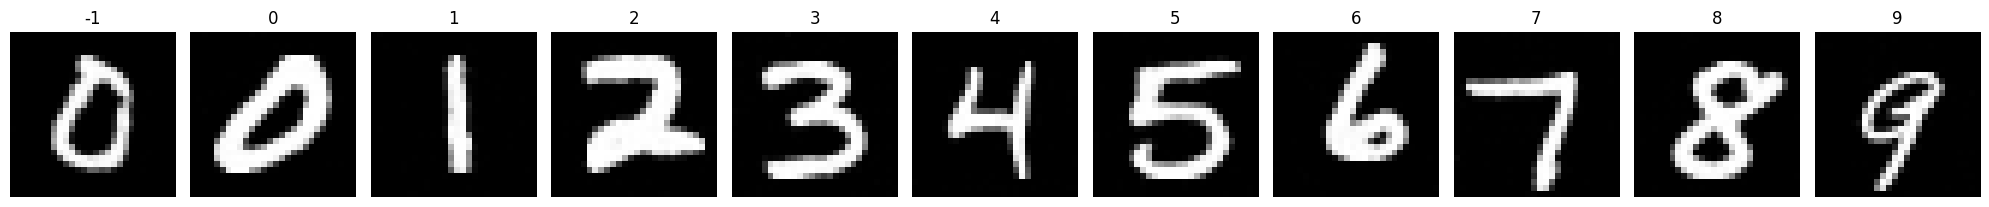

Epoch 64/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0239 - val_loss: 0.0366 - val_noise_loss: 0.0366 - val_image_loss: 0.2030 - learning_rate: 8.9185e-04


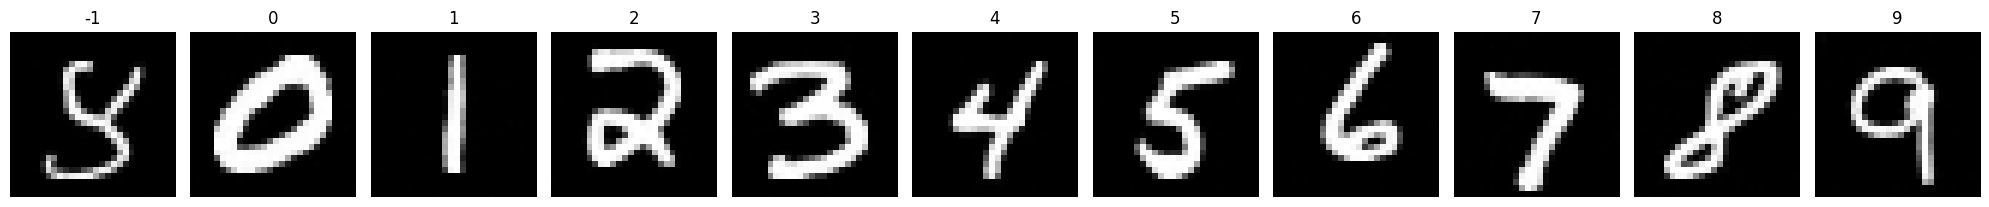

Epoch 65/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0238 - val_loss: 0.0368 - val_noise_loss: 0.0368 - val_image_loss: 0.2007 - learning_rate: 8.8857e-04


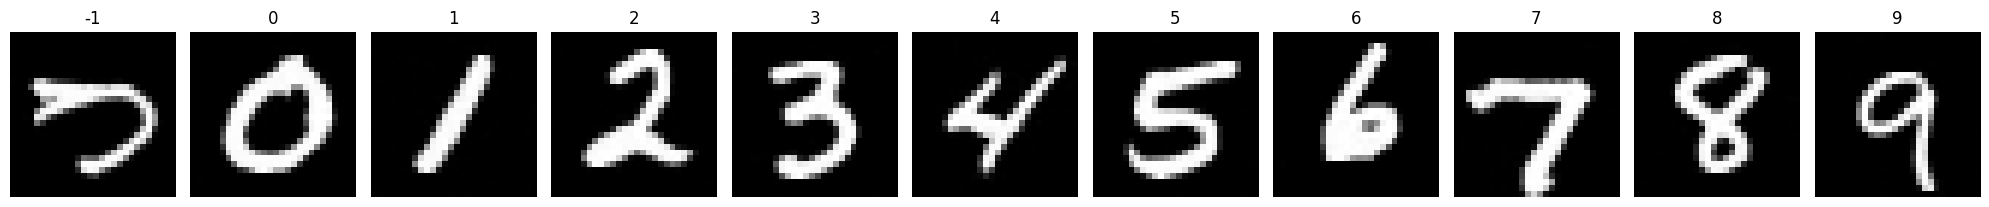

Epoch 66/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0238 - val_loss: 0.0368 - val_noise_loss: 0.0368 - val_image_loss: 0.2034 - learning_rate: 8.8526e-04


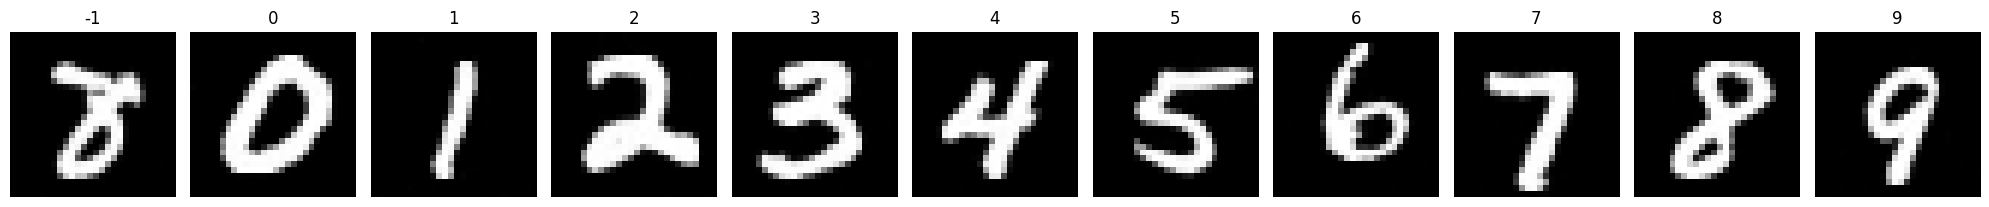

Epoch 67/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0238 - val_loss: 0.0365 - val_noise_loss: 0.0365 - val_image_loss: 0.2006 - learning_rate: 8.8190e-04


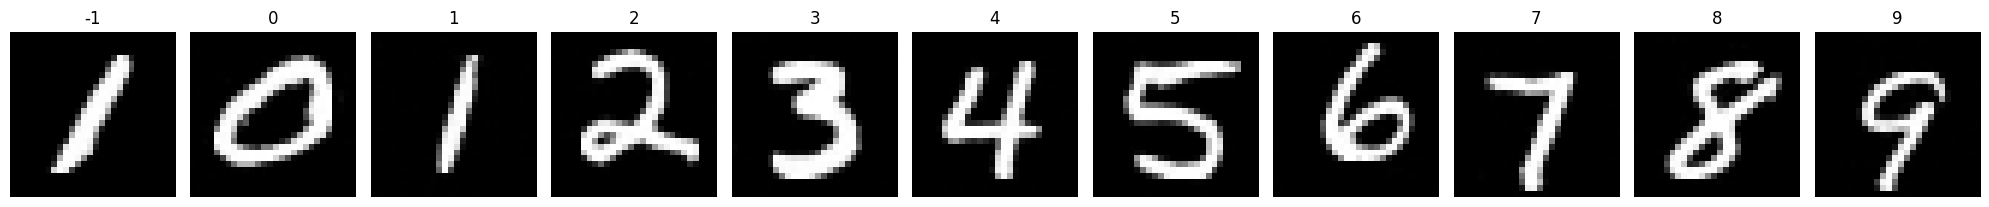

Epoch 68/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0237 - val_loss: 0.0368 - val_noise_loss: 0.0368 - val_image_loss: 0.2022 - learning_rate: 8.7850e-04


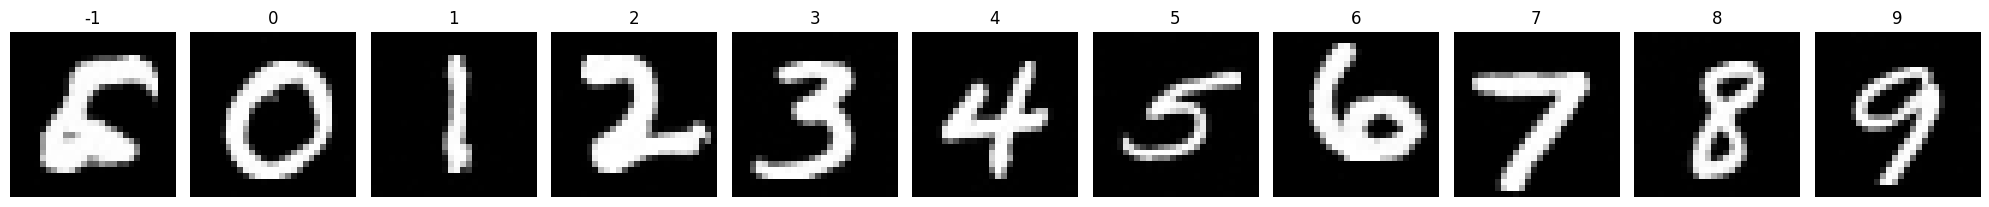

Epoch 69/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0238 - val_loss: 0.0367 - val_noise_loss: 0.0367 - val_image_loss: 0.2058 - learning_rate: 8.7506e-04


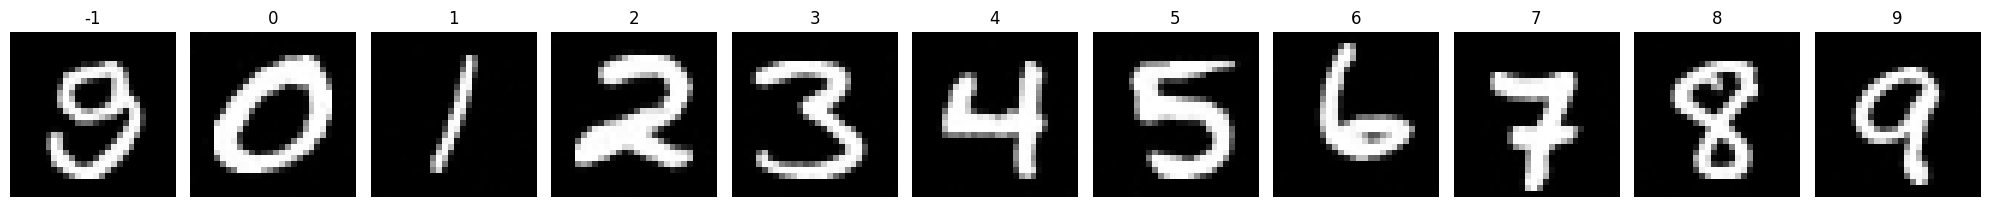

Epoch 70/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0237 - val_loss: 0.0369 - val_noise_loss: 0.0369 - val_image_loss: 0.2056 - learning_rate: 8.7157e-04


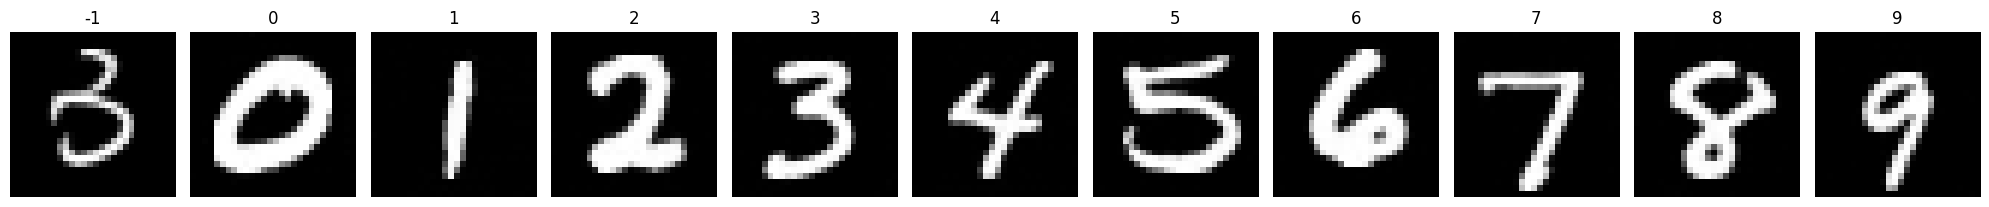

Epoch 71/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0237 - val_loss: 0.0368 - val_noise_loss: 0.0368 - val_image_loss: 0.2041 - learning_rate: 8.6805e-04


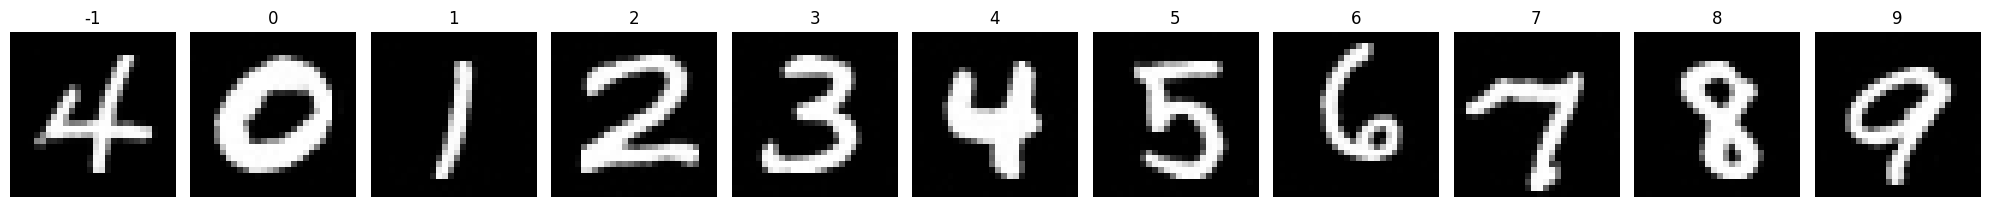

Epoch 72/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0236 - val_loss: 0.0366 - val_noise_loss: 0.0366 - val_image_loss: 0.2016 - learning_rate: 8.6448e-04


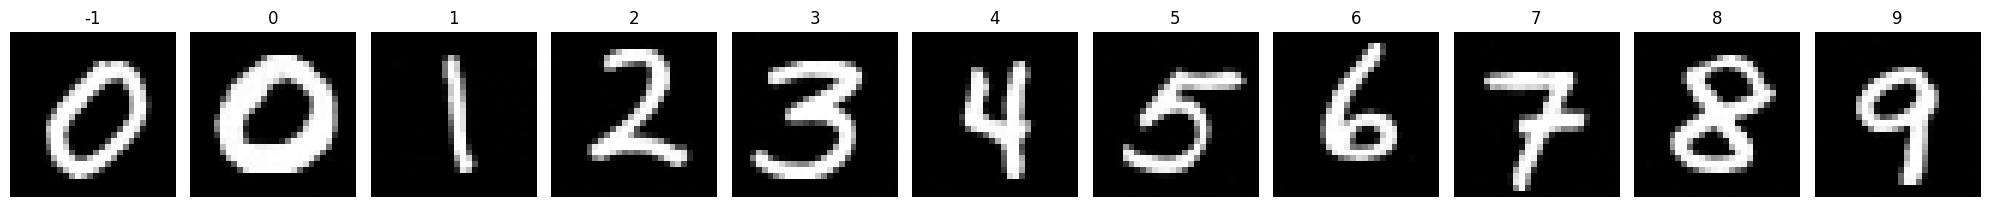

Epoch 73/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0237 - val_loss: 0.0362 - val_noise_loss: 0.0362 - val_image_loss: 0.2033 - learning_rate: 8.6088e-04


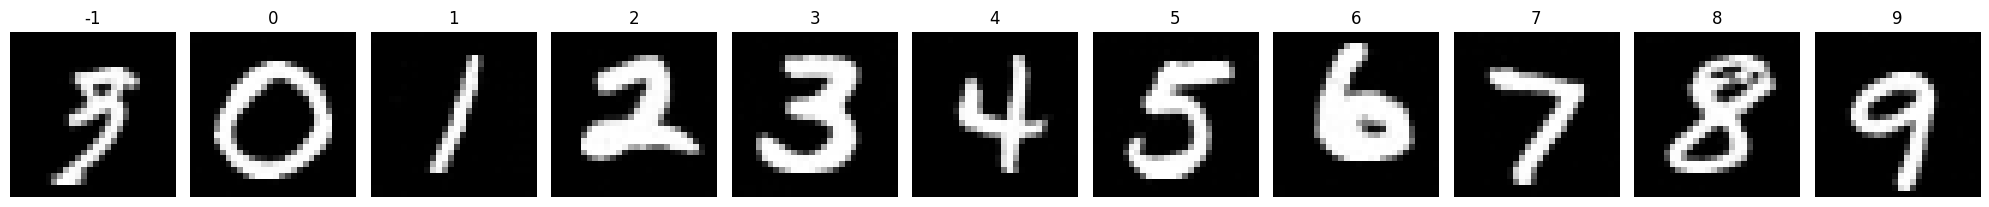

Epoch 74/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0236 - val_loss: 0.0367 - val_noise_loss: 0.0367 - val_image_loss: 0.2081 - learning_rate: 8.5724e-04


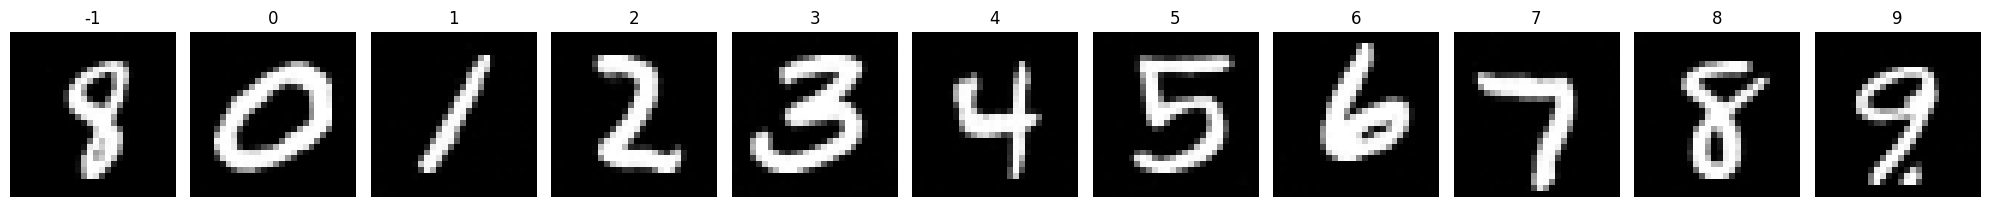

Epoch 75/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0237 - val_loss: 0.0362 - val_noise_loss: 0.0362 - val_image_loss: 0.2057 - learning_rate: 8.5355e-04


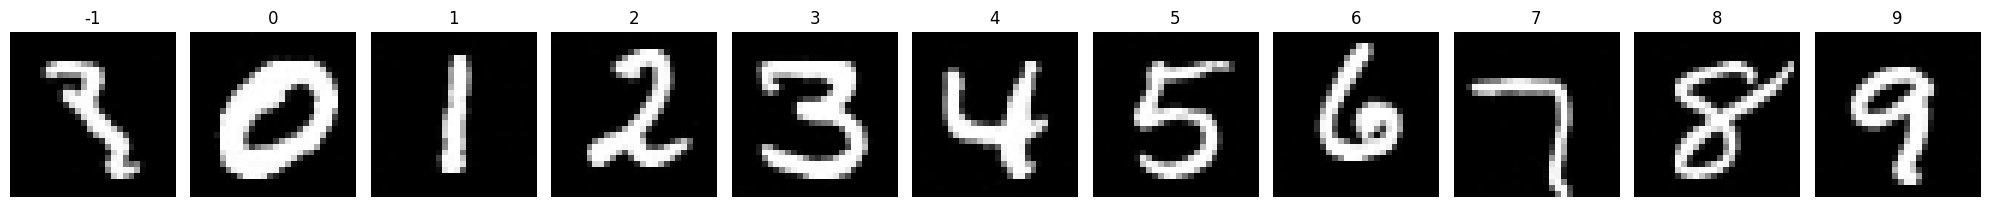

Epoch 76/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0236 - val_loss: 0.0360 - val_noise_loss: 0.0360 - val_image_loss: 0.2076 - learning_rate: 8.4983e-04


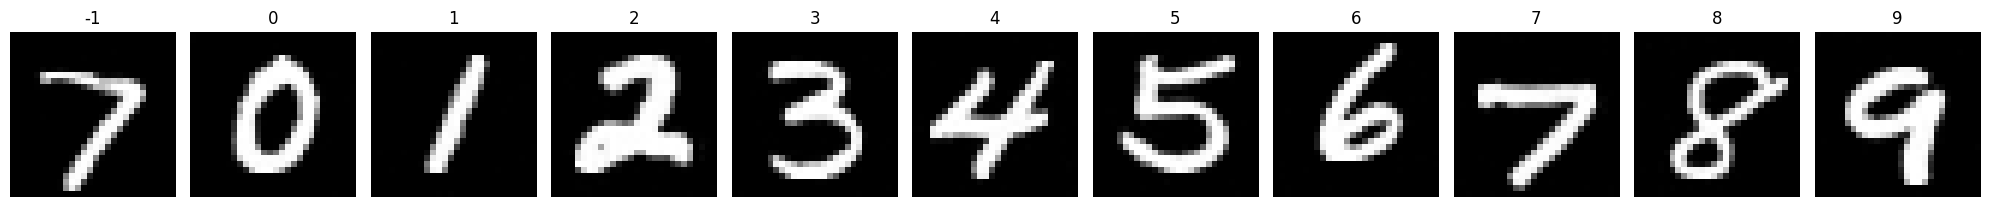

Epoch 77/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0237 - val_loss: 0.0363 - val_noise_loss: 0.0363 - val_image_loss: 0.2028 - learning_rate: 8.4607e-04


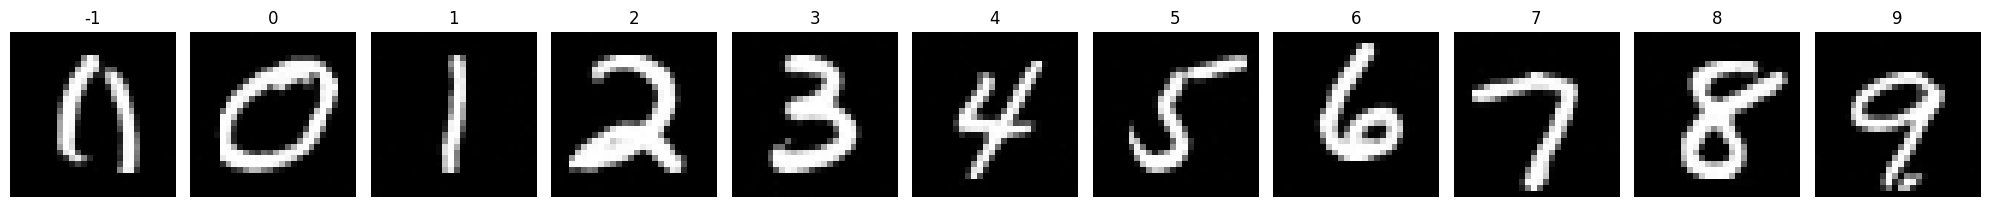

Epoch 78/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0236 - val_loss: 0.0365 - val_noise_loss: 0.0365 - val_image_loss: 0.2068 - learning_rate: 8.4227e-04


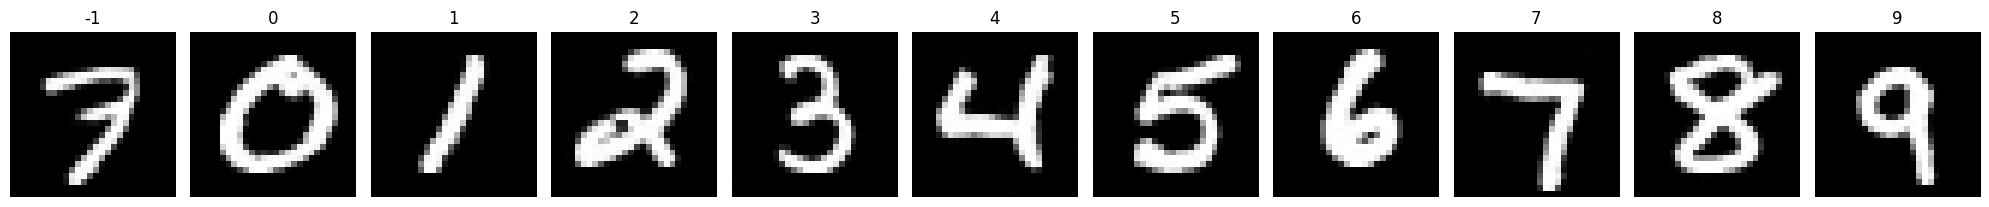

Epoch 79/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0236 - val_loss: 0.0362 - val_noise_loss: 0.0362 - val_image_loss: 0.2067 - learning_rate: 8.3844e-04


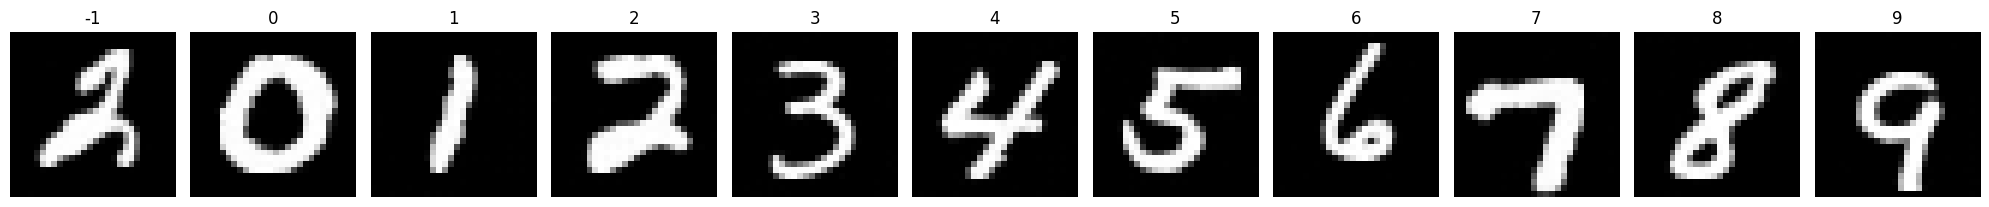

Epoch 80/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0237 - val_loss: 0.0360 - val_noise_loss: 0.0360 - val_image_loss: 0.1980 - learning_rate: 8.3457e-04


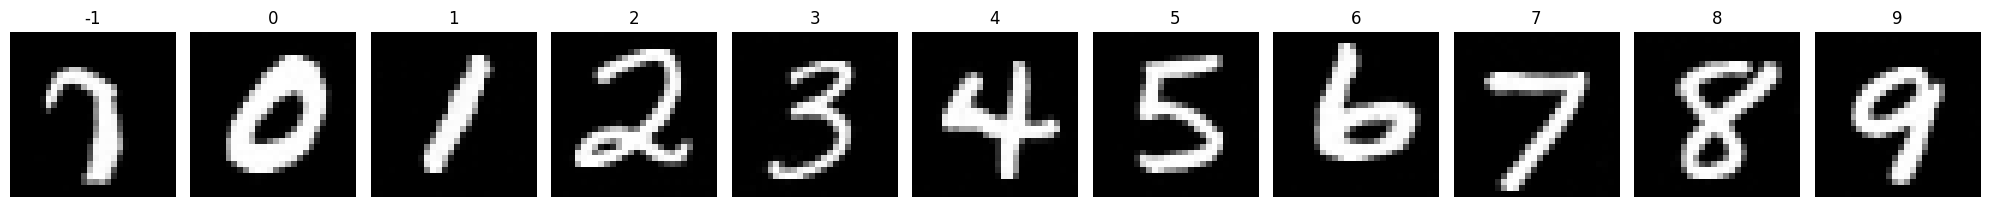

Epoch 81/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0236 - val_loss: 0.0363 - val_noise_loss: 0.0363 - val_image_loss: 0.2053 - learning_rate: 8.3066e-04


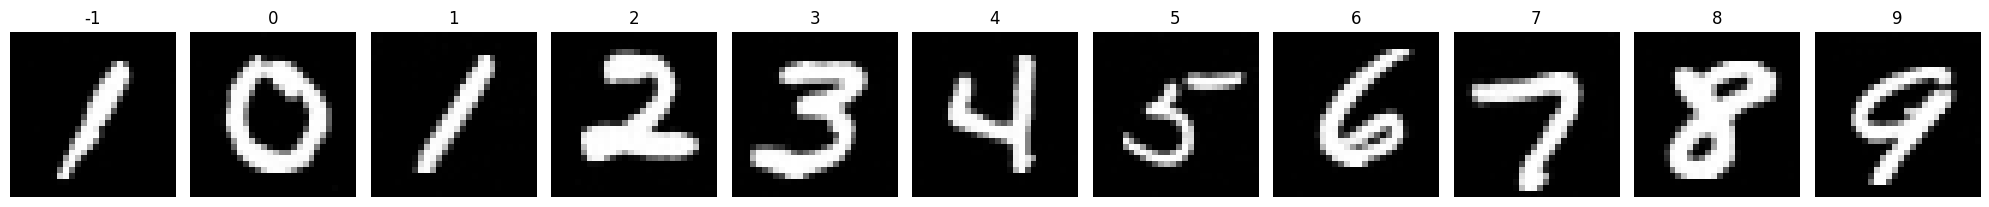

Epoch 82/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0358 - val_noise_loss: 0.0358 - val_image_loss: 0.2051 - learning_rate: 8.2671e-04


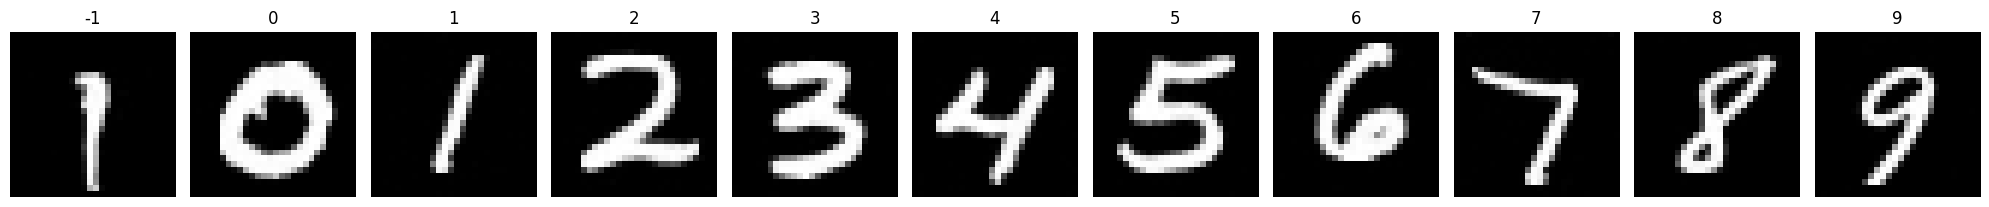

Epoch 83/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0236 - val_loss: 0.0359 - val_noise_loss: 0.0359 - val_image_loss: 0.2006 - learning_rate: 8.2273e-04


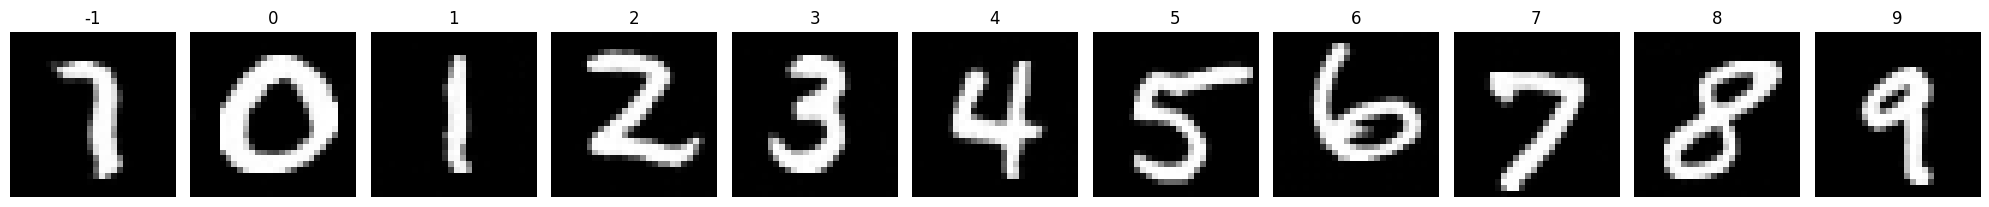

Epoch 84/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0236 - val_loss: 0.0358 - val_noise_loss: 0.0358 - val_image_loss: 0.2071 - learning_rate: 8.1871e-04


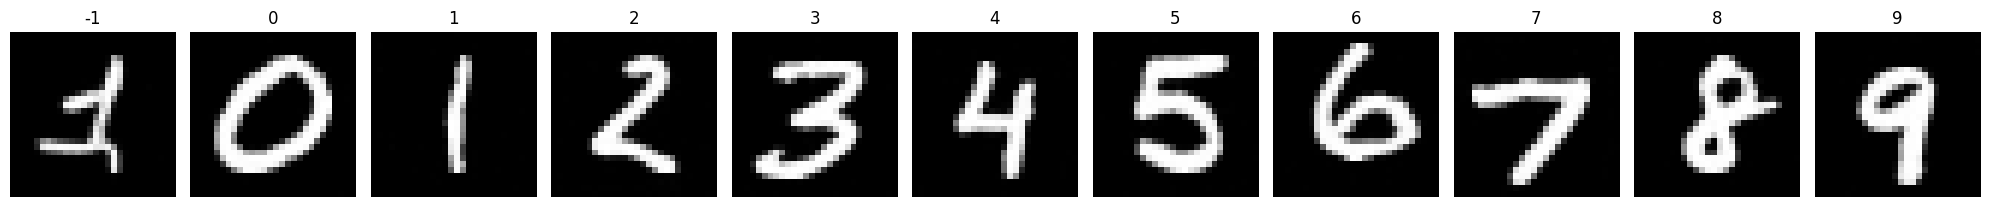

Epoch 85/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0361 - val_noise_loss: 0.0361 - val_image_loss: 0.2034 - learning_rate: 8.1466e-04


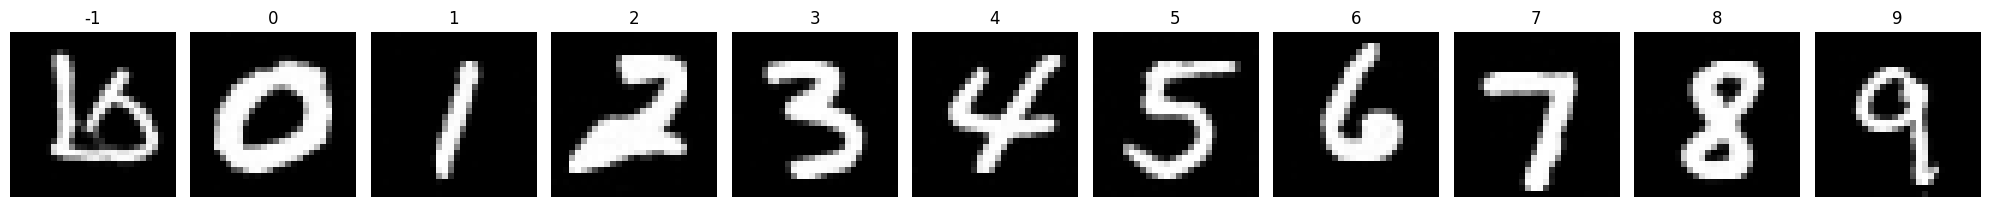

Epoch 86/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0361 - val_noise_loss: 0.0361 - val_image_loss: 0.2040 - learning_rate: 8.1057e-04


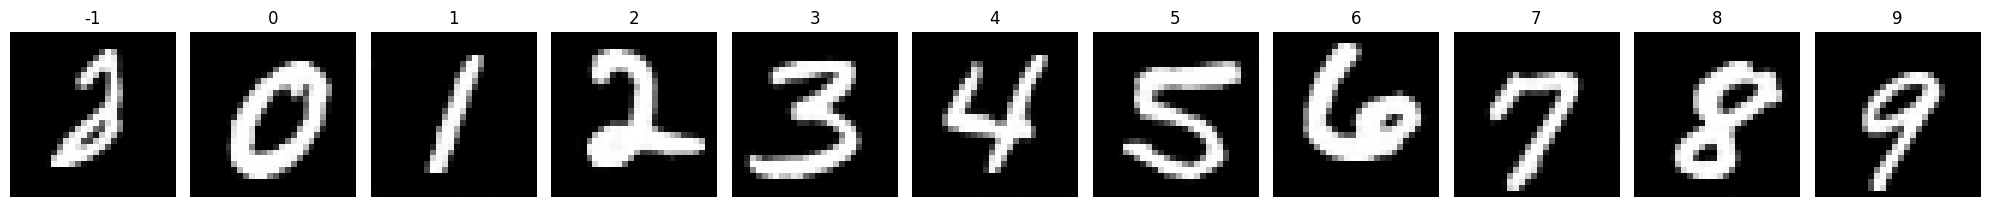

Epoch 87/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0359 - val_noise_loss: 0.0359 - val_image_loss: 0.1994 - learning_rate: 8.0645e-04


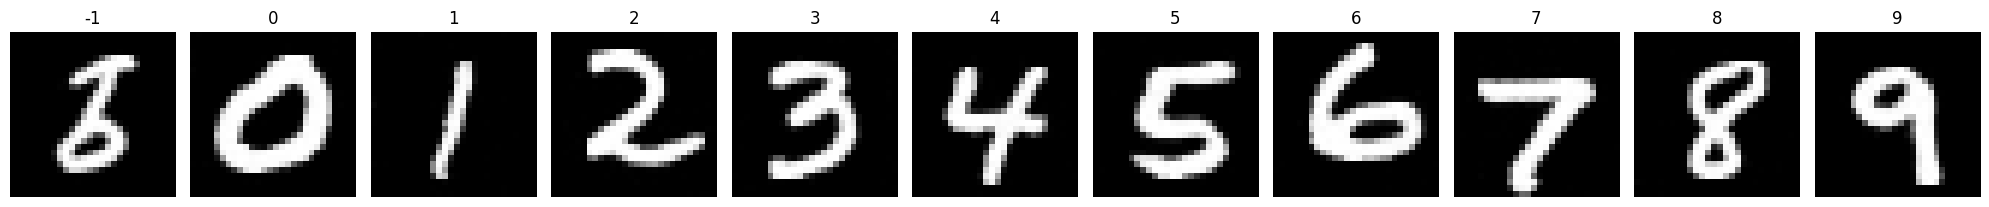

Epoch 88/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0361 - val_noise_loss: 0.0361 - val_image_loss: 0.1985 - learning_rate: 8.0230e-04


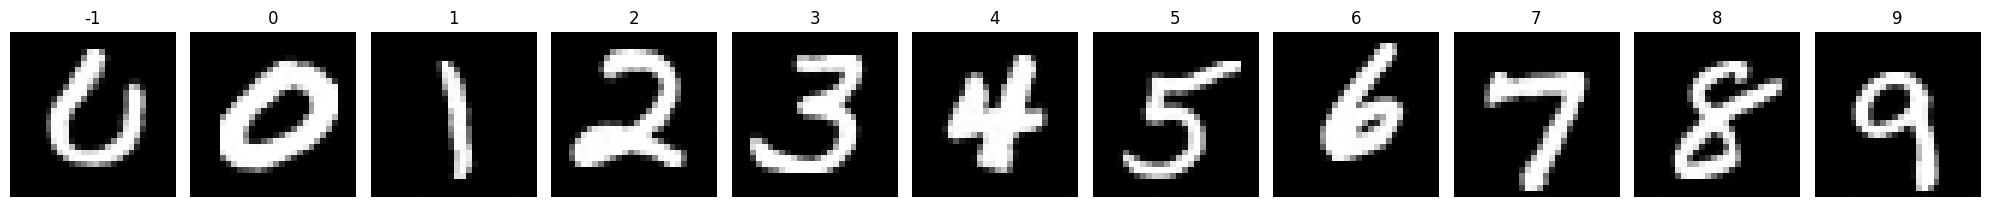

Epoch 89/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0361 - val_noise_loss: 0.0361 - val_image_loss: 0.2053 - learning_rate: 7.9811e-04


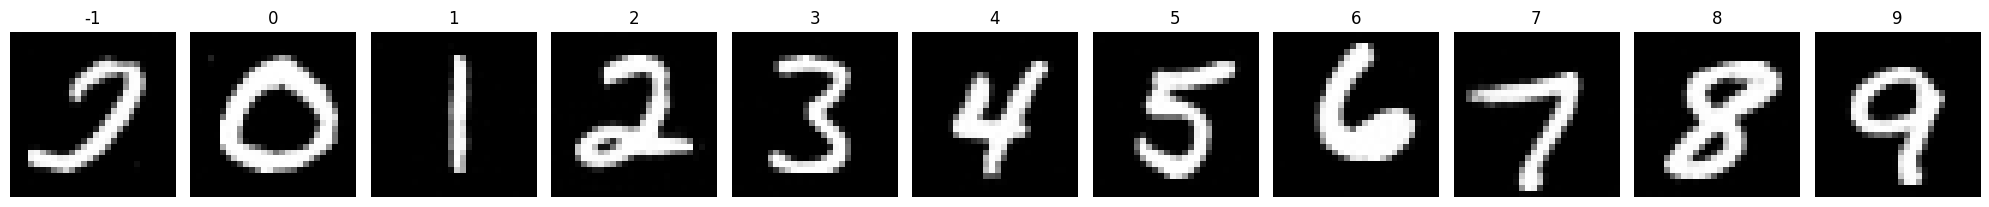

Epoch 90/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0359 - val_noise_loss: 0.0359 - val_image_loss: 0.1958 - learning_rate: 7.9389e-04


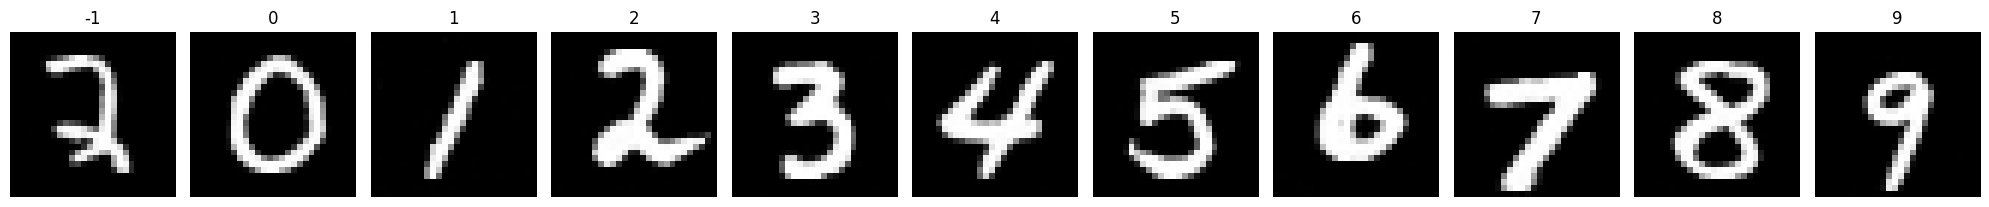

Epoch 91/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0235 - val_loss: 0.0360 - val_noise_loss: 0.0360 - val_image_loss: 0.1993 - learning_rate: 7.8964e-04


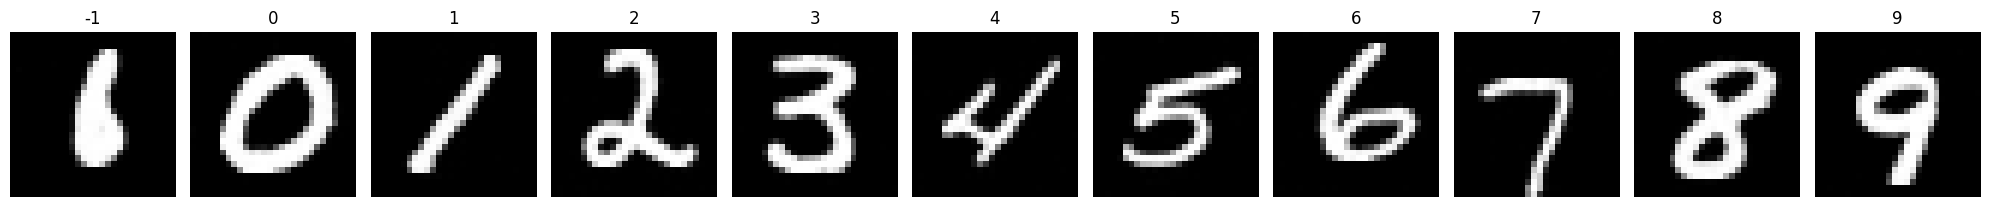

Epoch 92/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0356 - val_noise_loss: 0.0356 - val_image_loss: 0.1984 - learning_rate: 7.8536e-04


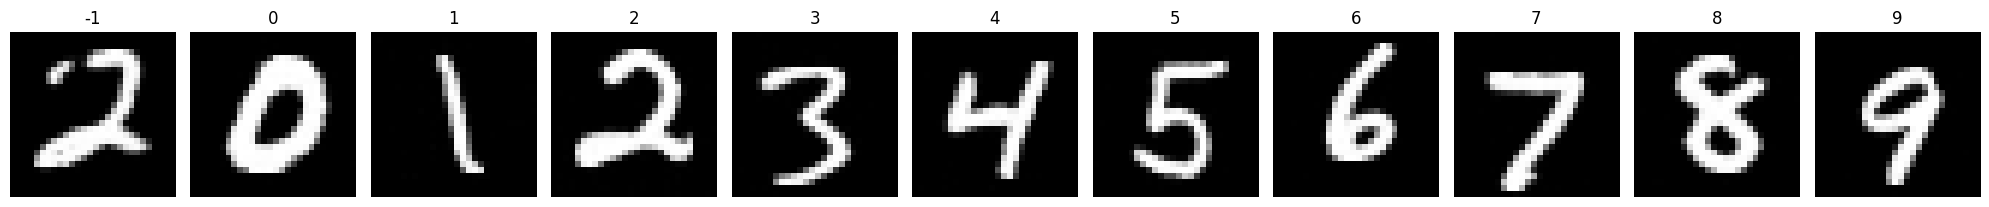

Epoch 93/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0356 - val_noise_loss: 0.0356 - val_image_loss: 0.2031 - learning_rate: 7.8104e-04


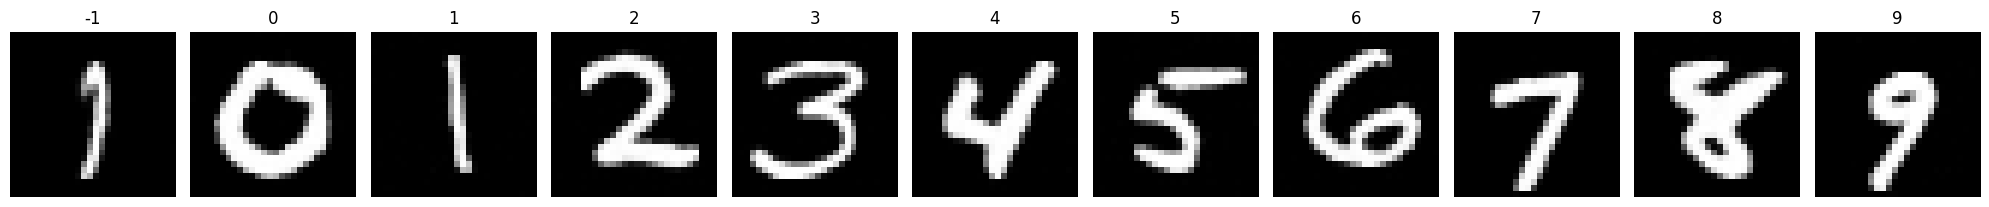

Epoch 94/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0233 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.2014 - learning_rate: 7.7670e-04


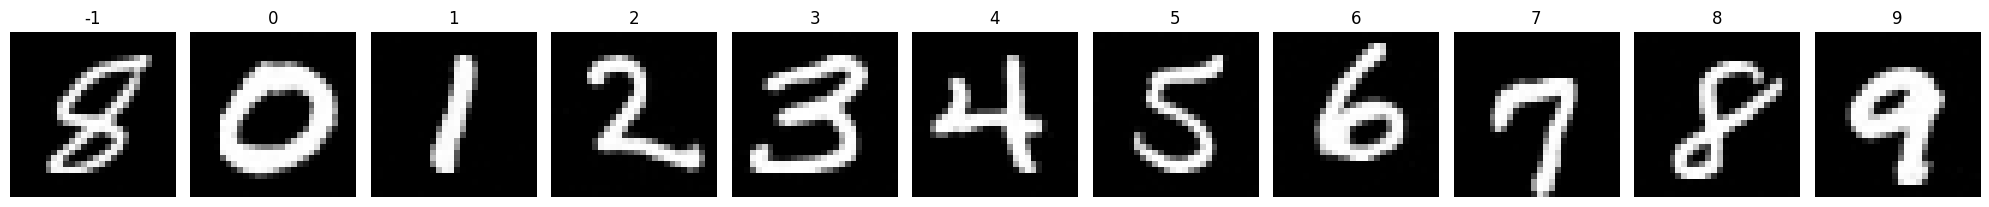

Epoch 95/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.2008 - learning_rate: 7.7232e-04


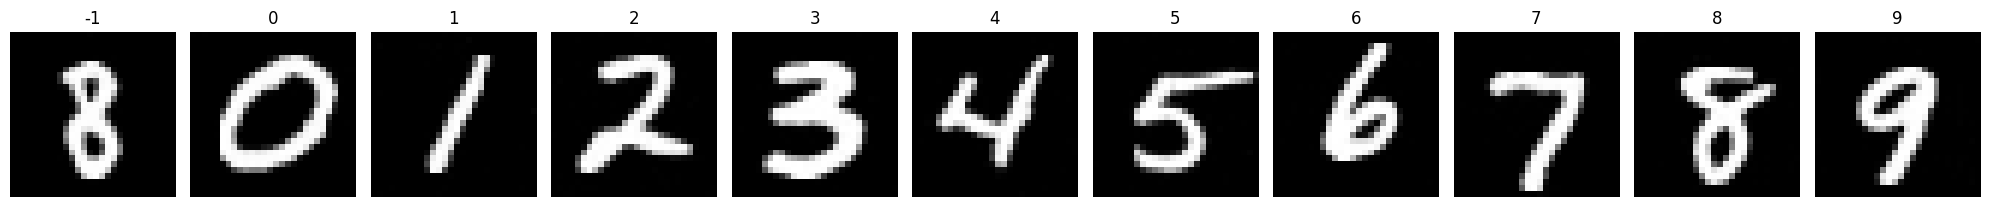

Epoch 96/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0233 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.2027 - learning_rate: 7.6791e-04


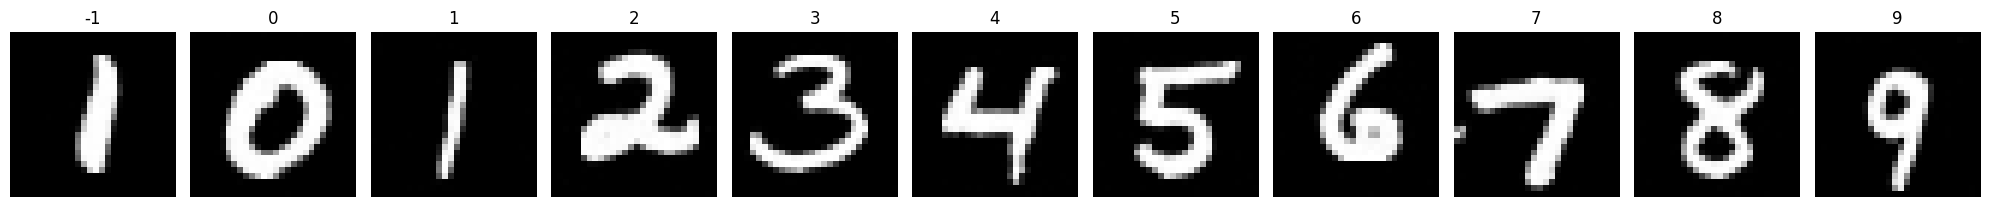

Epoch 97/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0234 - val_loss: 0.0353 - val_noise_loss: 0.0353 - val_image_loss: 0.2026 - learning_rate: 7.6348e-04


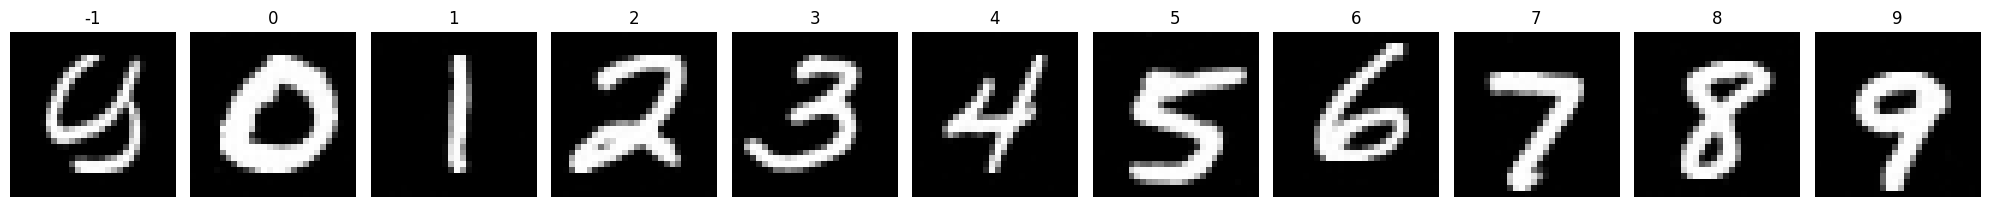

Epoch 98/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0234 - val_loss: 0.0357 - val_noise_loss: 0.0357 - val_image_loss: 0.2020 - learning_rate: 7.5901e-04


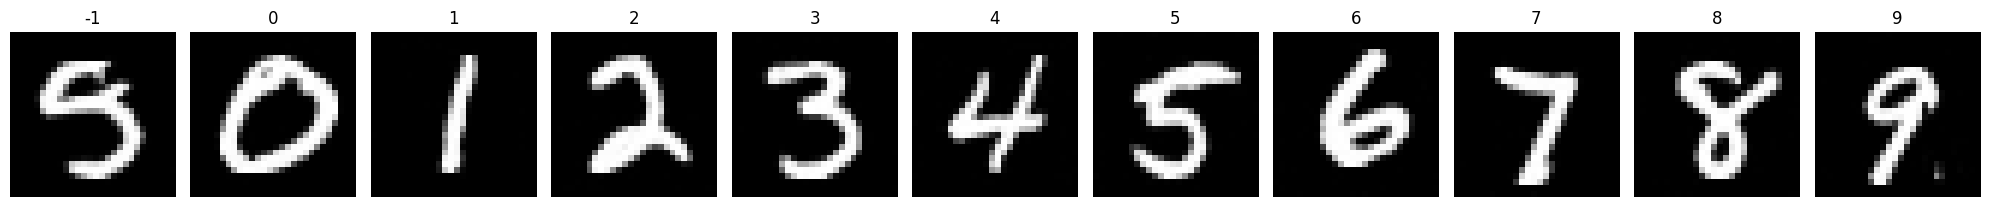

Epoch 99/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0234 - val_loss: 0.0357 - val_noise_loss: 0.0357 - val_image_loss: 0.2015 - learning_rate: 7.5452e-04


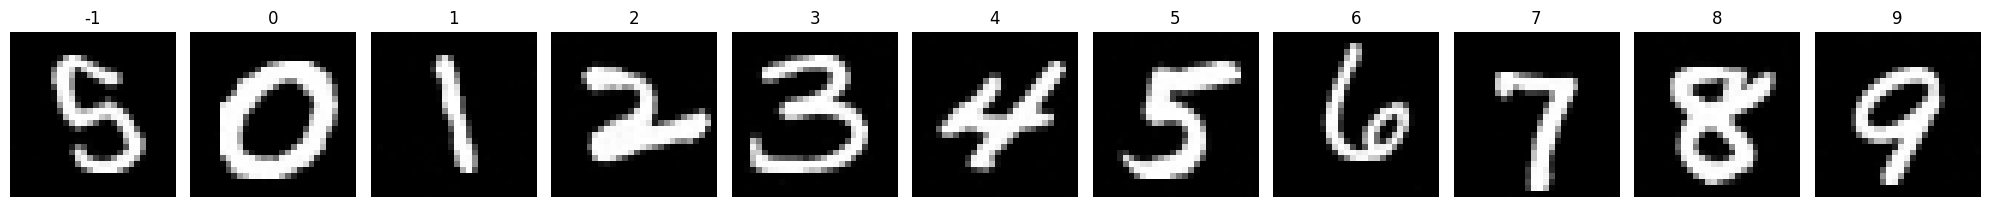

Epoch 100/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0234 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.2048 - learning_rate: 7.5000e-04


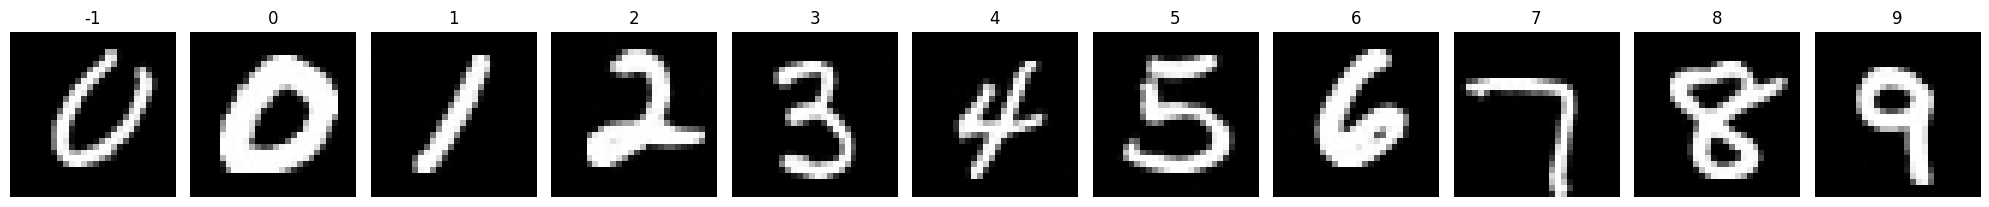

Epoch 101/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0355 - val_noise_loss: 0.0355 - val_image_loss: 0.1987 - learning_rate: 7.4545e-04


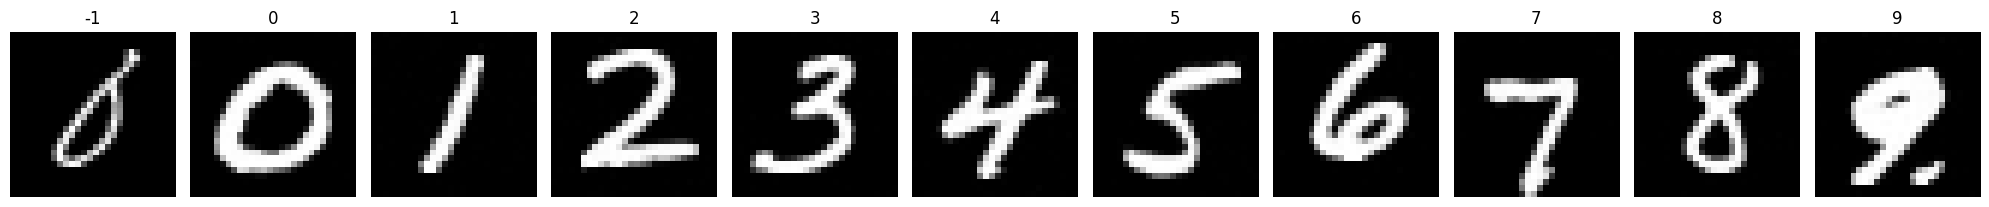

Epoch 102/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.2048 - learning_rate: 7.4088e-04


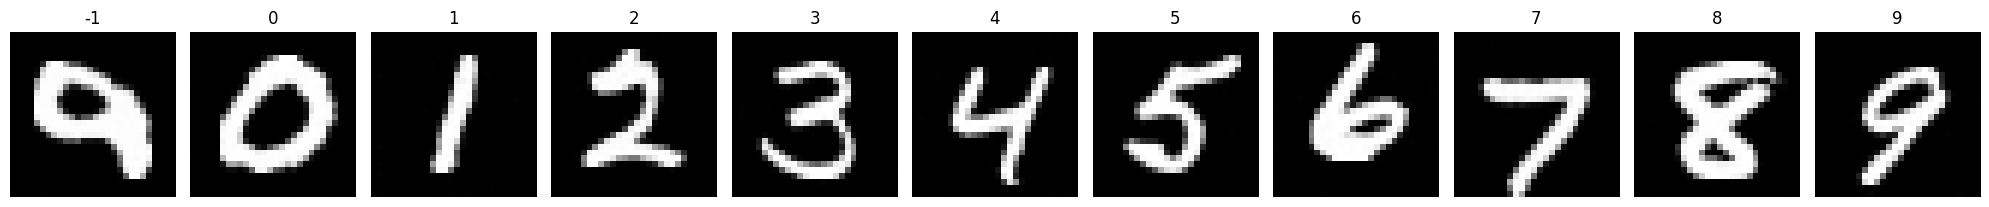

Epoch 103/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0355 - val_noise_loss: 0.0355 - val_image_loss: 0.2050 - learning_rate: 7.3628e-04


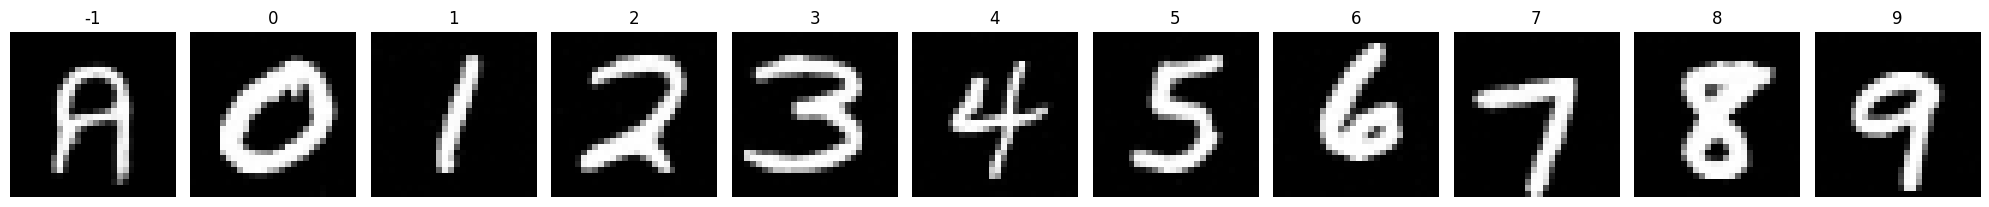

Epoch 104/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0233 - val_loss: 0.0356 - val_noise_loss: 0.0356 - val_image_loss: 0.2002 - learning_rate: 7.3165e-04


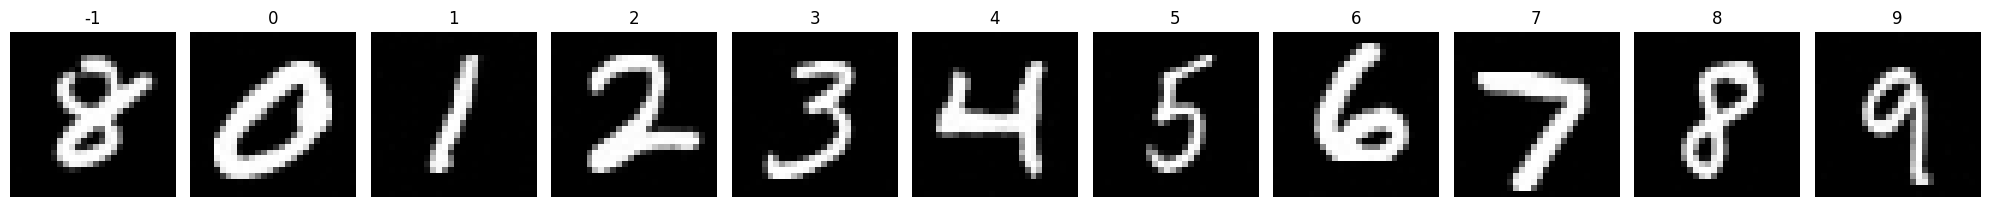

Epoch 105/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0353 - val_noise_loss: 0.0353 - val_image_loss: 0.2005 - learning_rate: 7.2700e-04


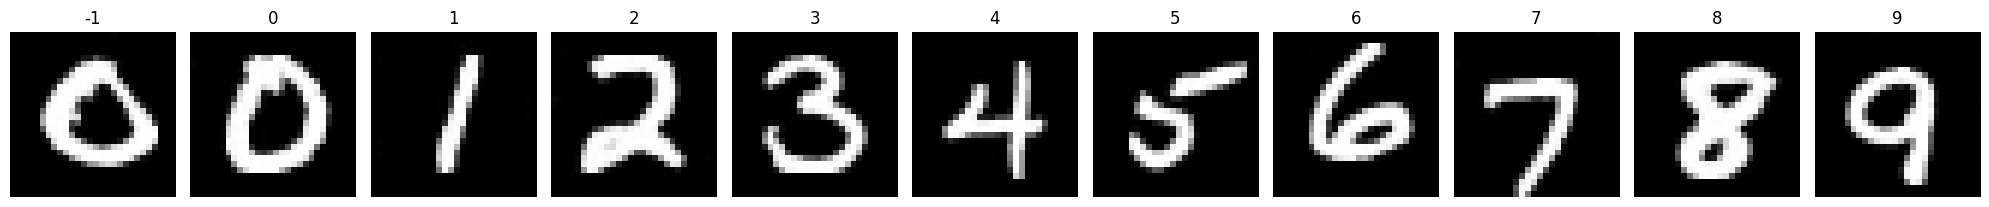

Epoch 106/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0233 - val_loss: 0.0353 - val_noise_loss: 0.0353 - val_image_loss: 0.1984 - learning_rate: 7.2232e-04


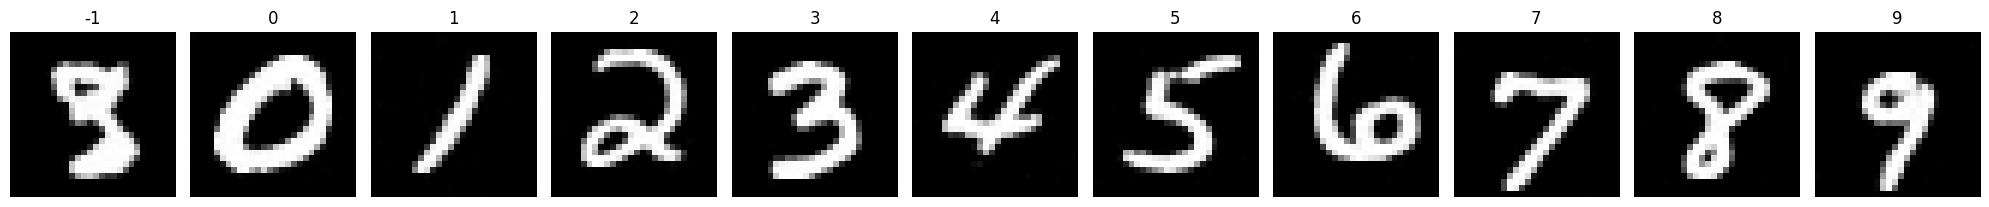

Epoch 107/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.1972 - learning_rate: 7.1762e-04


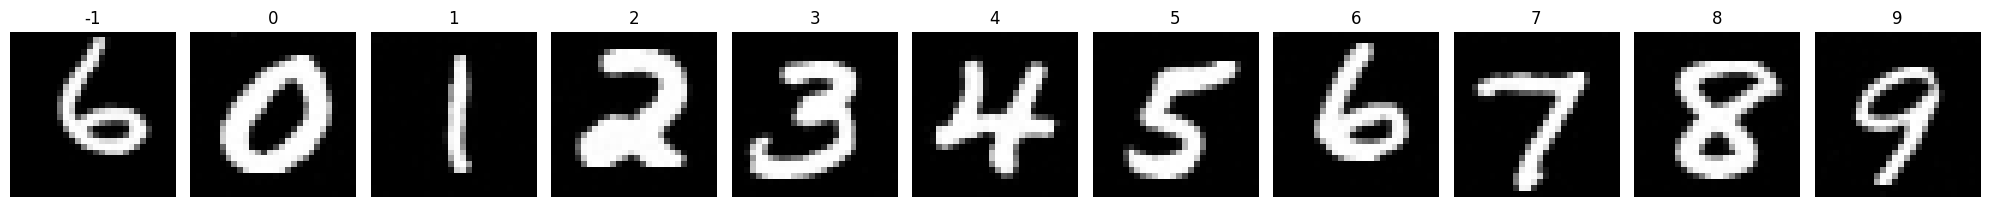

Epoch 108/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0233 - val_loss: 0.0355 - val_noise_loss: 0.0355 - val_image_loss: 0.2048 - learning_rate: 7.1289e-04


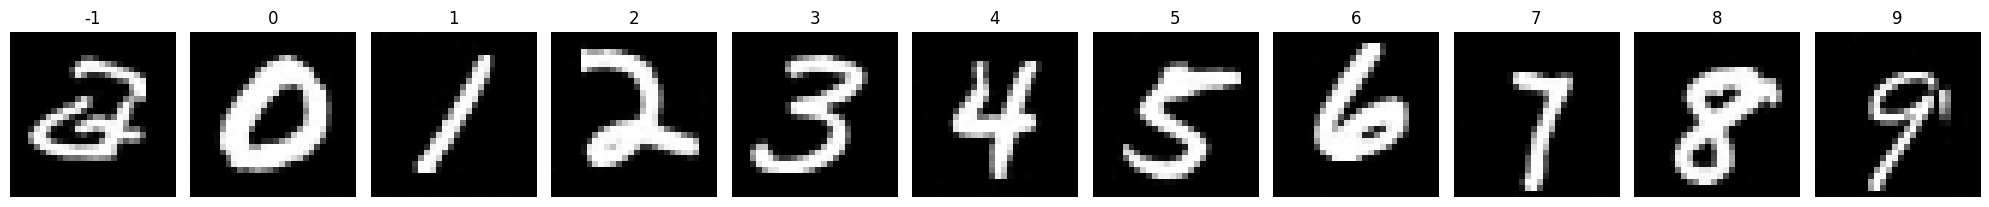

Epoch 109/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0233 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.2064 - learning_rate: 7.0814e-04


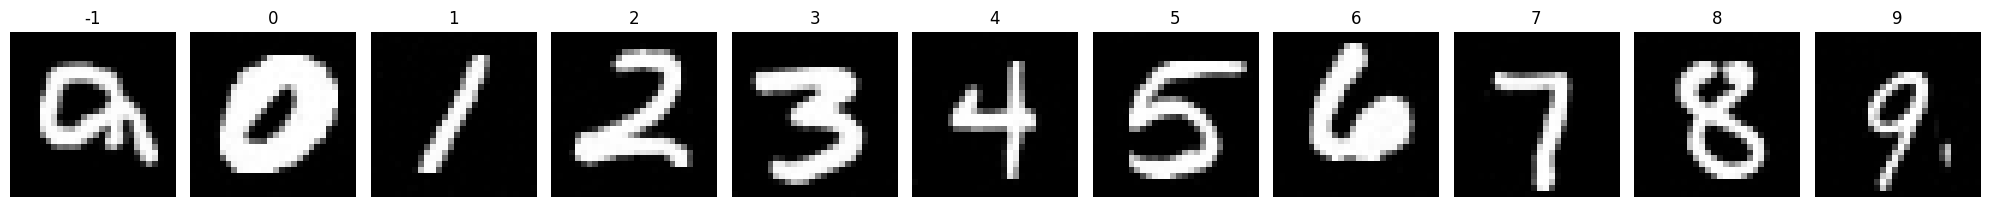

Epoch 110/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0233 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.2029 - learning_rate: 7.0337e-04


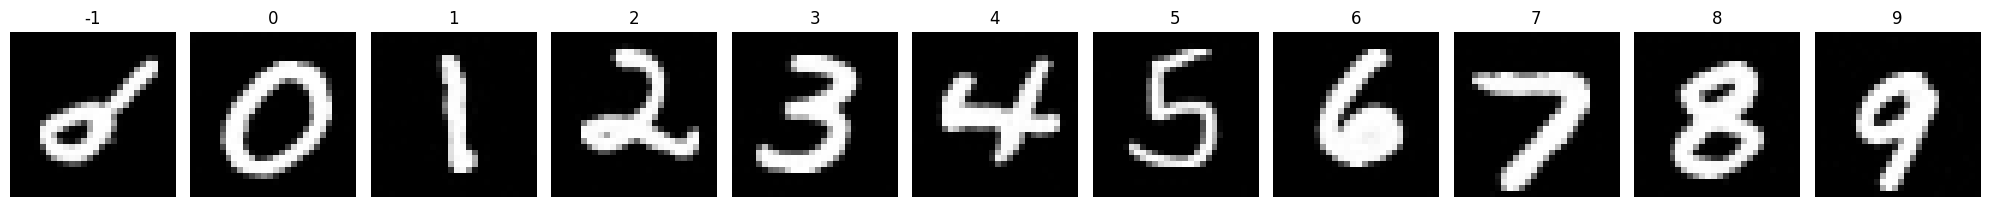

Epoch 111/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0232 - val_loss: 0.0352 - val_noise_loss: 0.0352 - val_image_loss: 0.1975 - learning_rate: 6.9857e-04


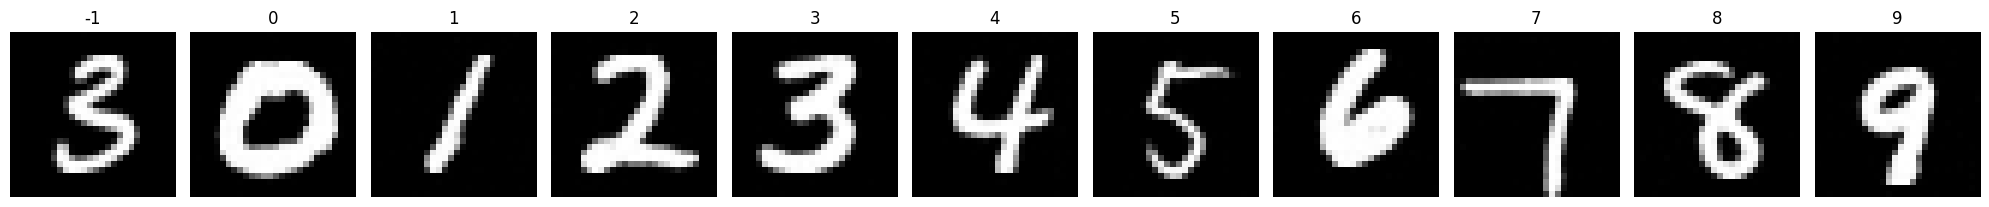

Epoch 112/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0232 - val_loss: 0.0352 - val_noise_loss: 0.0352 - val_image_loss: 0.2018 - learning_rate: 6.9376e-04


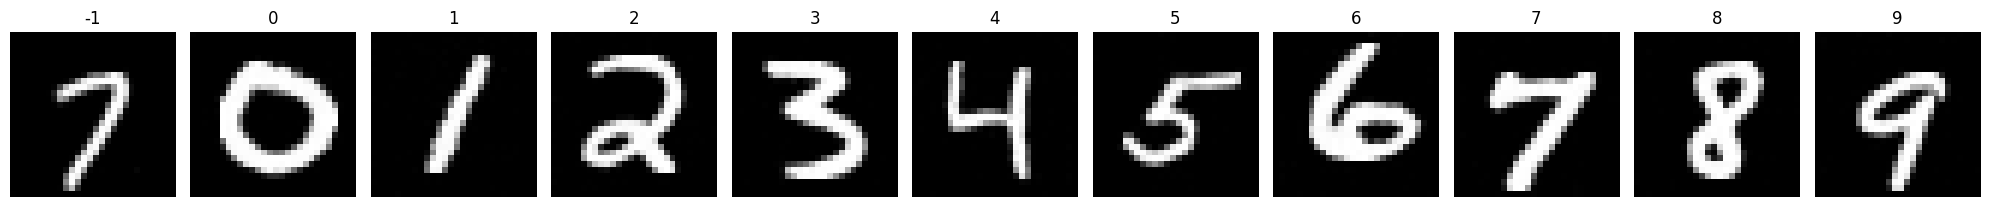

Epoch 113/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0232 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.1937 - learning_rate: 6.8892e-04


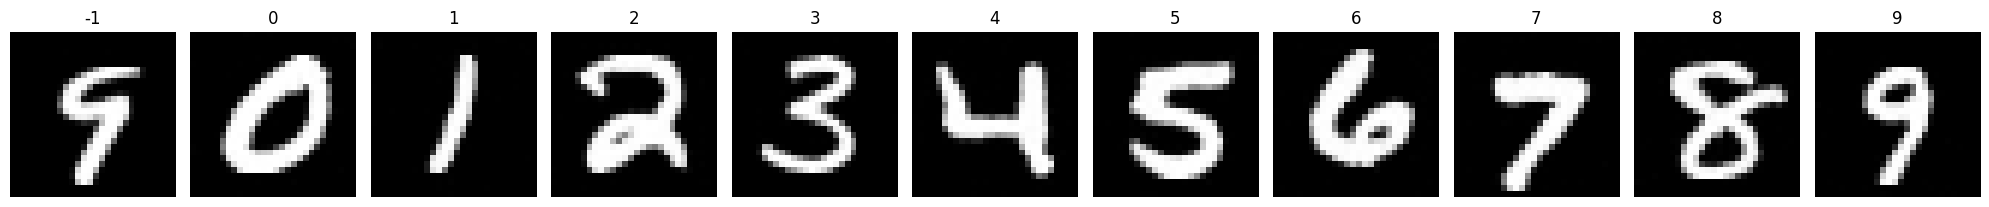

Epoch 114/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0231 - val_loss: 0.0355 - val_noise_loss: 0.0355 - val_image_loss: 0.1982 - learning_rate: 6.8406e-04


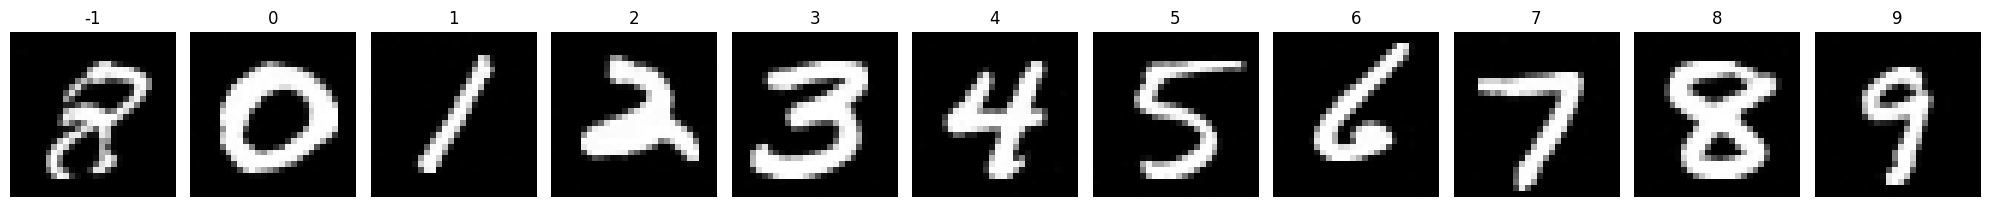

Epoch 115/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0232 - val_loss: 0.0355 - val_noise_loss: 0.0355 - val_image_loss: 0.2016 - learning_rate: 6.7918e-04


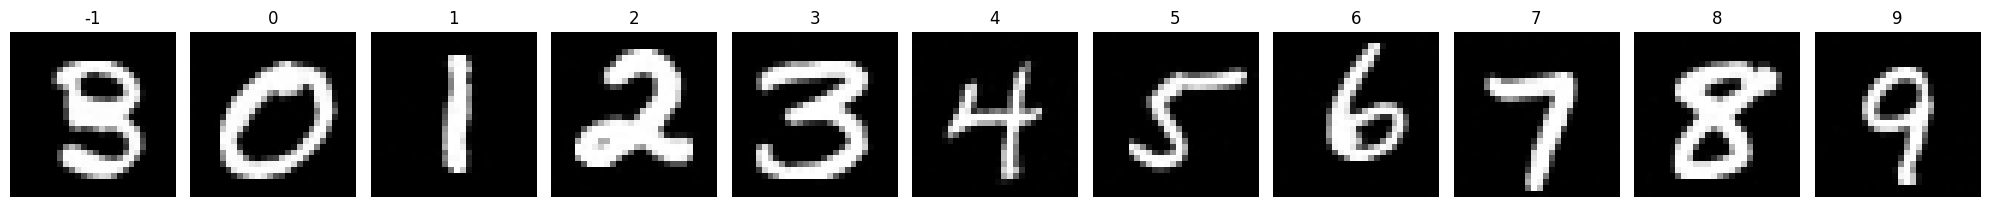

Epoch 116/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0232 - val_loss: 0.0355 - val_noise_loss: 0.0355 - val_image_loss: 0.1984 - learning_rate: 6.7429e-04


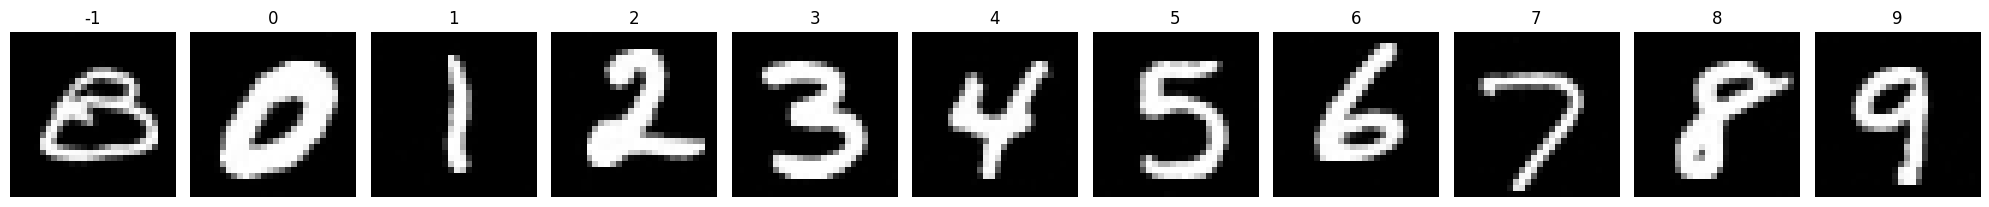

Epoch 117/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0232 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.2047 - learning_rate: 6.6937e-04


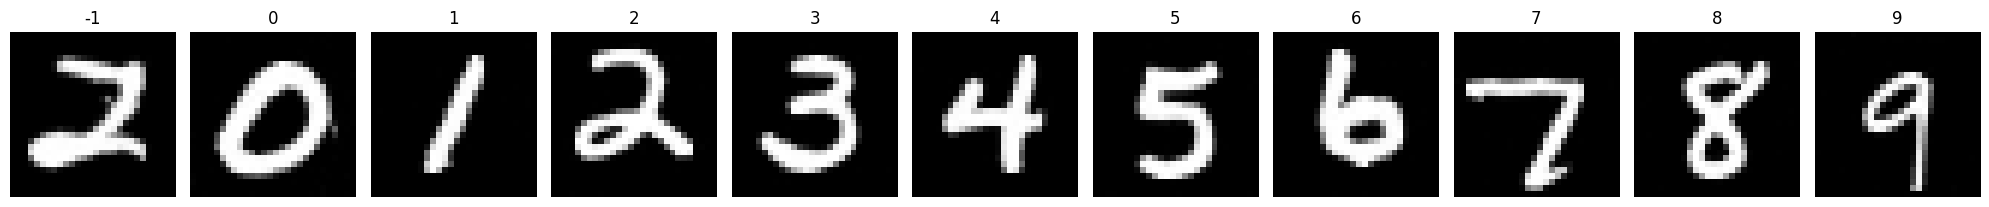

Epoch 118/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0232 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.2011 - learning_rate: 6.6443e-04


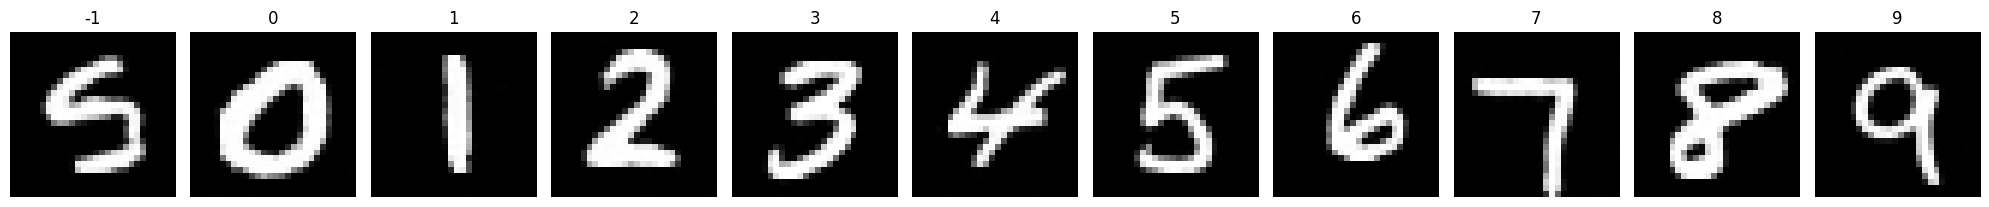

Epoch 119/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0231 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.2036 - learning_rate: 6.5948e-04


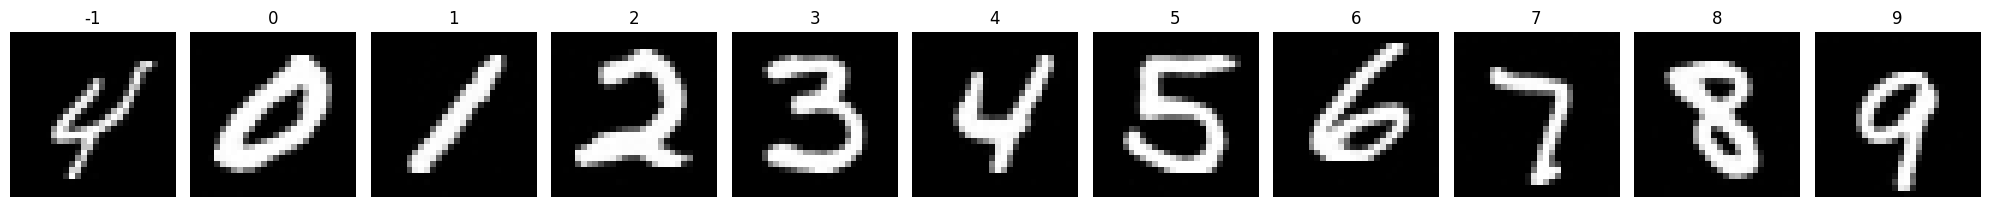

Epoch 120/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0231 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.2088 - learning_rate: 6.5451e-04


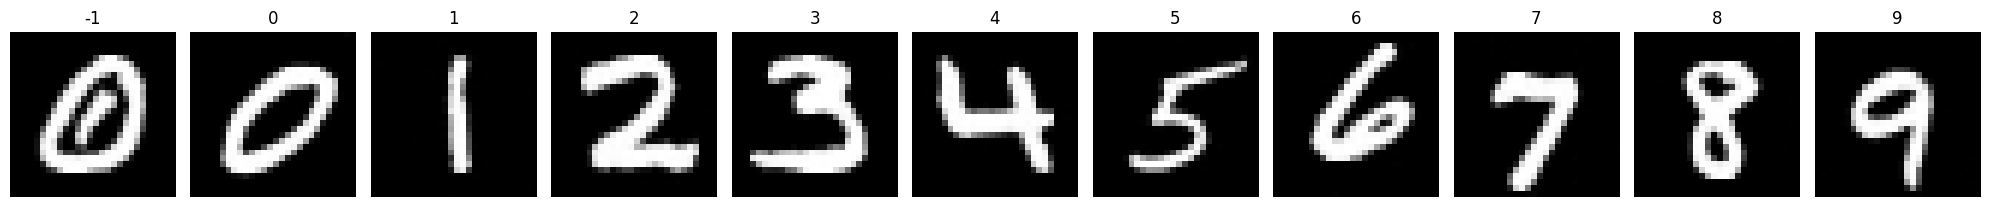

Epoch 121/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.2010 - learning_rate: 6.4952e-04


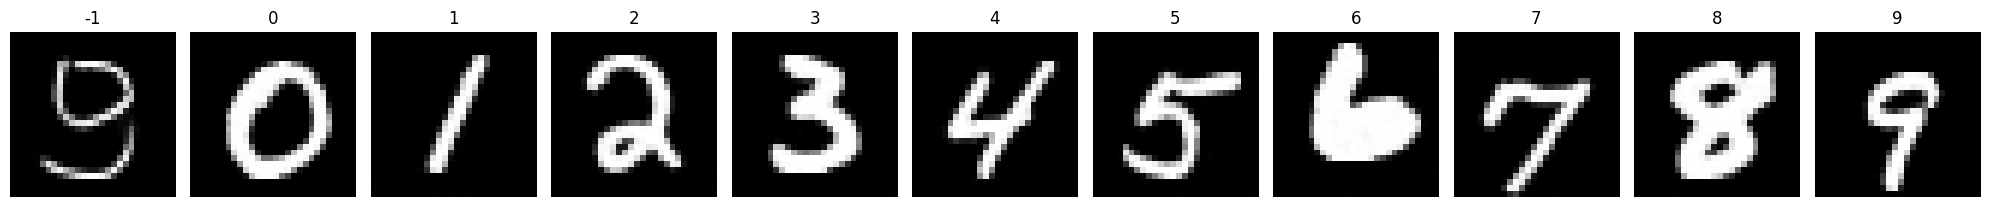

Epoch 122/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0231 - val_loss: 0.0352 - val_noise_loss: 0.0352 - val_image_loss: 0.2016 - learning_rate: 6.4452e-04


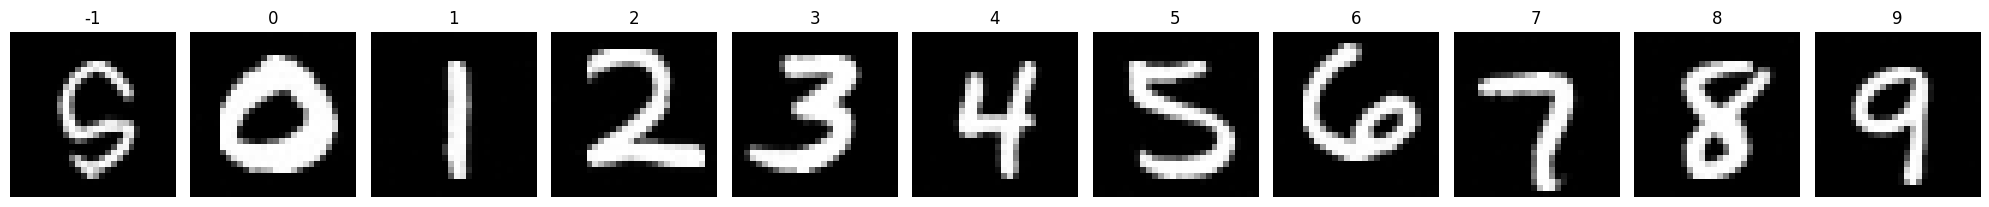

Epoch 123/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0231 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.2009 - learning_rate: 6.3950e-04


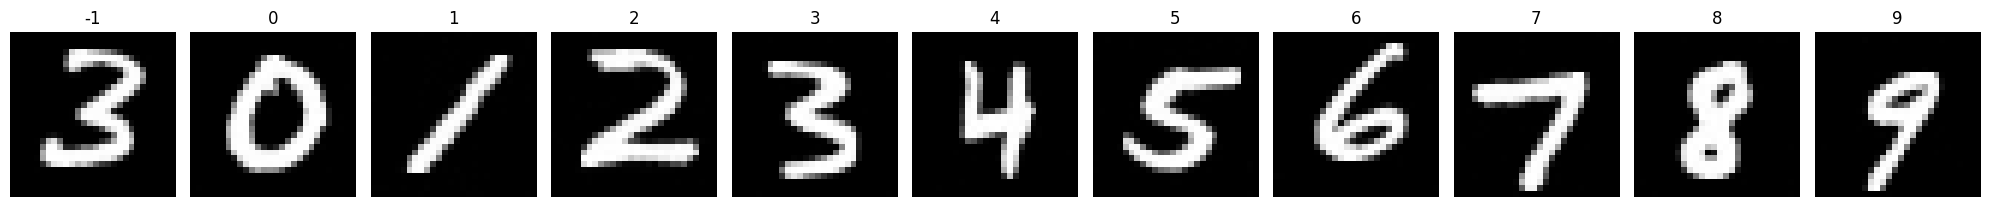

Epoch 124/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0231 - val_loss: 0.0353 - val_noise_loss: 0.0353 - val_image_loss: 0.2013 - learning_rate: 6.3446e-04


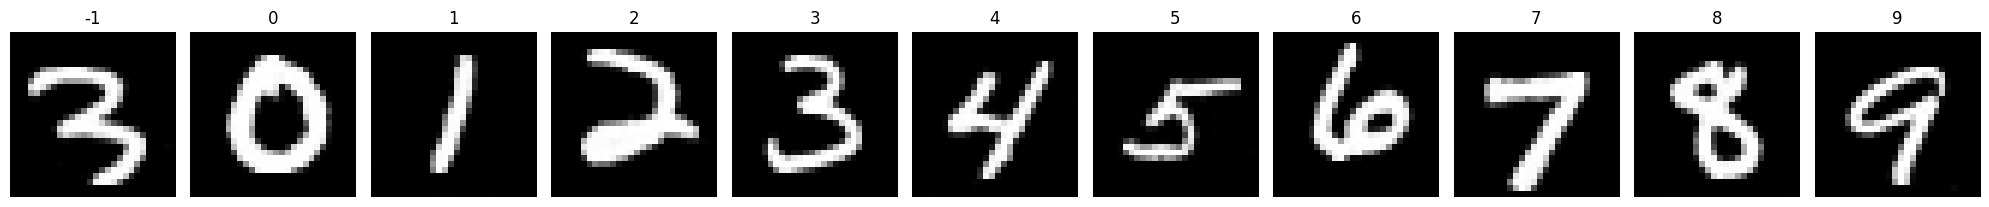

Epoch 125/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0231 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.2018 - learning_rate: 6.2941e-04


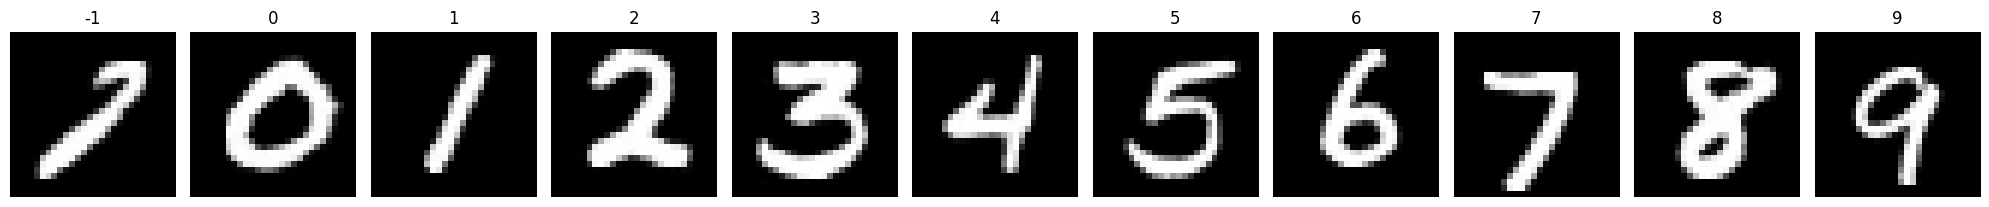

Epoch 126/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0231 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1952 - learning_rate: 6.2435e-04


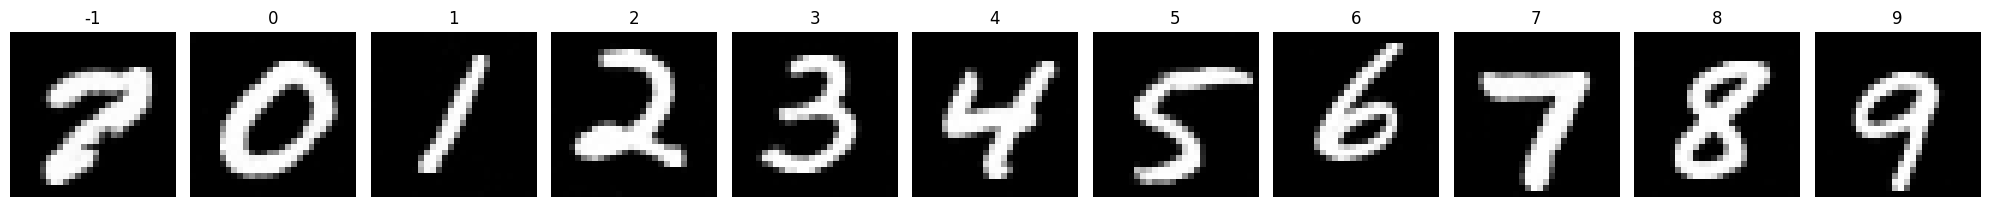

Epoch 127/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0232 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.1916 - learning_rate: 6.1927e-04


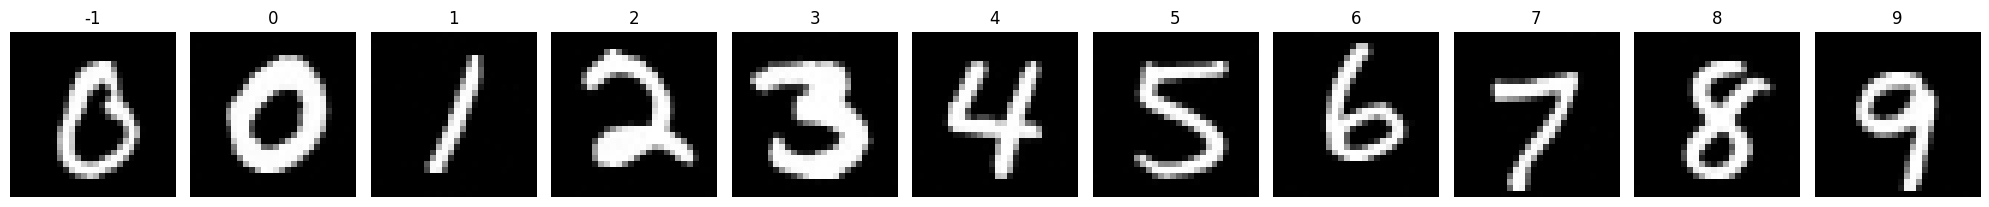

Epoch 128/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0230 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1994 - learning_rate: 6.1418e-04


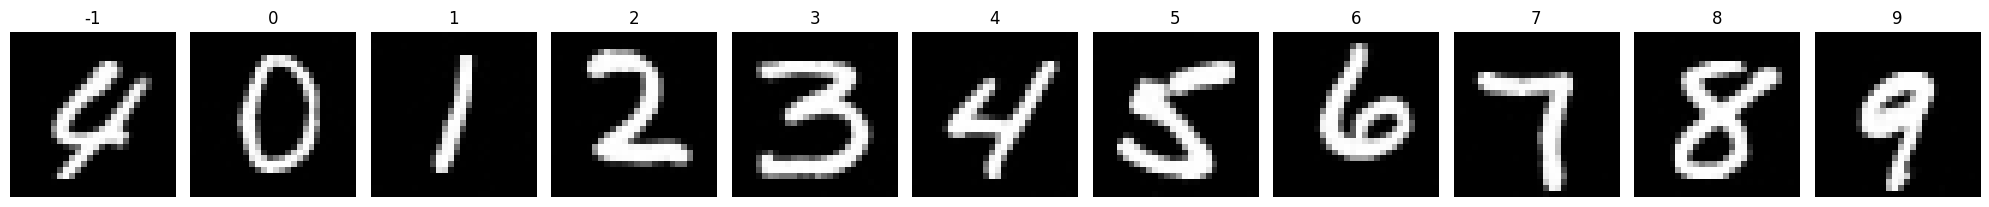

Epoch 129/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0230 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.2047 - learning_rate: 6.0907e-04


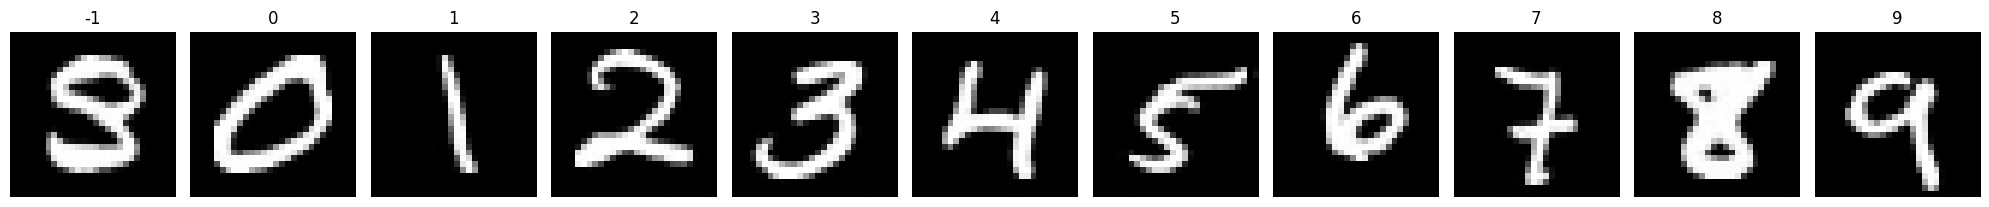

Epoch 130/300
468/468 [==============================] - 117s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.2040 - learning_rate: 6.0396e-04


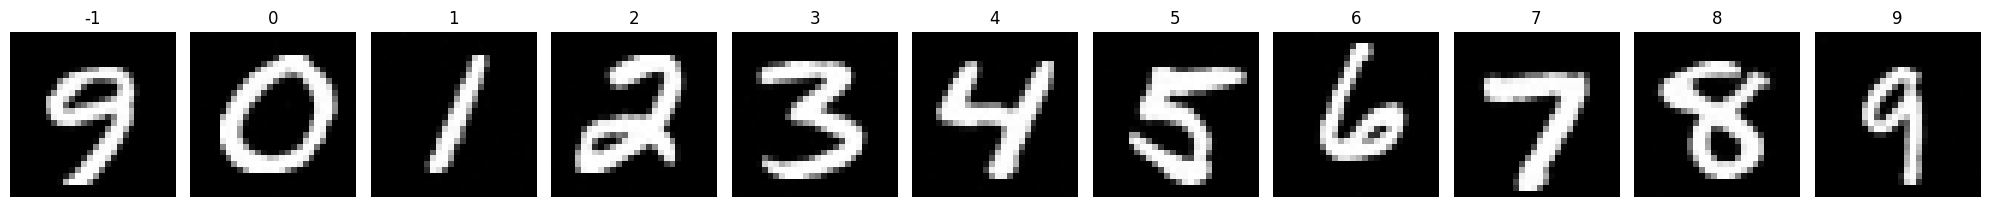

Epoch 131/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1986 - learning_rate: 5.9883e-04


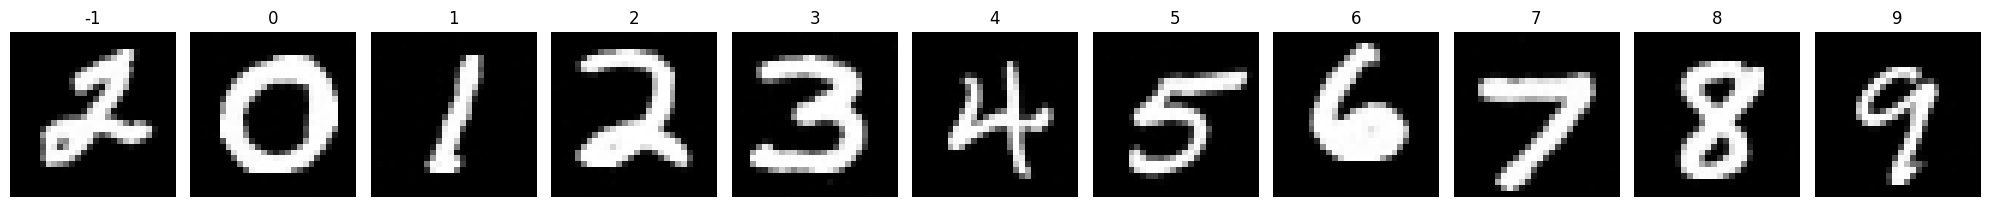

Epoch 132/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0229 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.2034 - learning_rate: 5.9369e-04


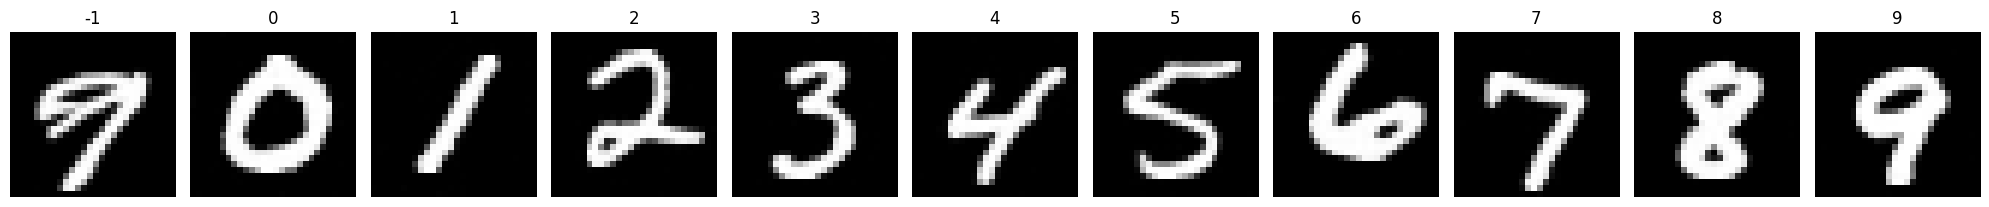

Epoch 133/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1986 - learning_rate: 5.8854e-04


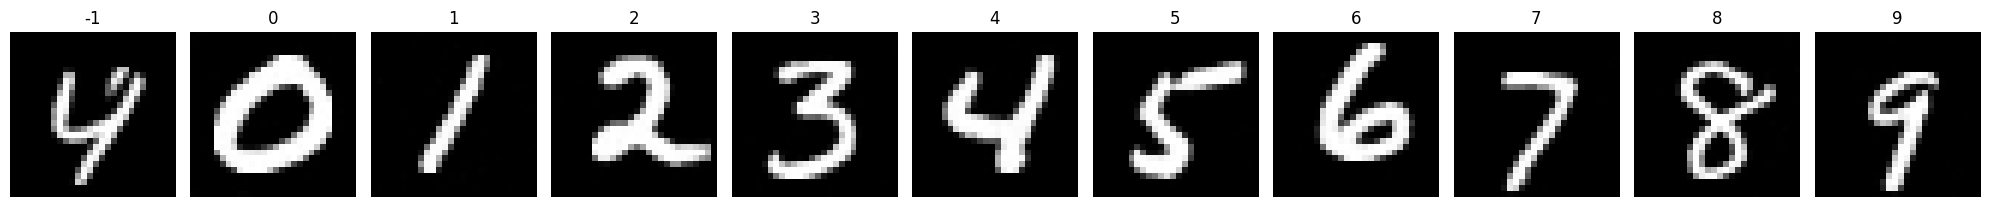

Epoch 134/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1998 - learning_rate: 5.8338e-04


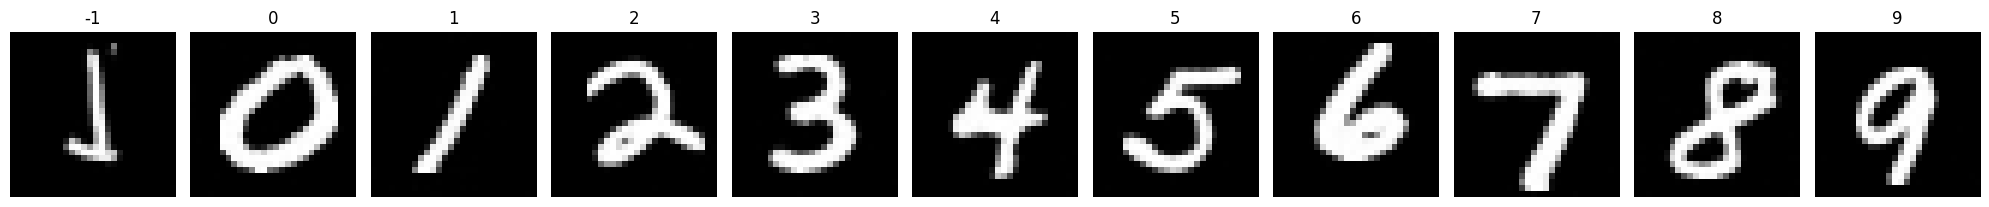

Epoch 135/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.2053 - learning_rate: 5.7822e-04


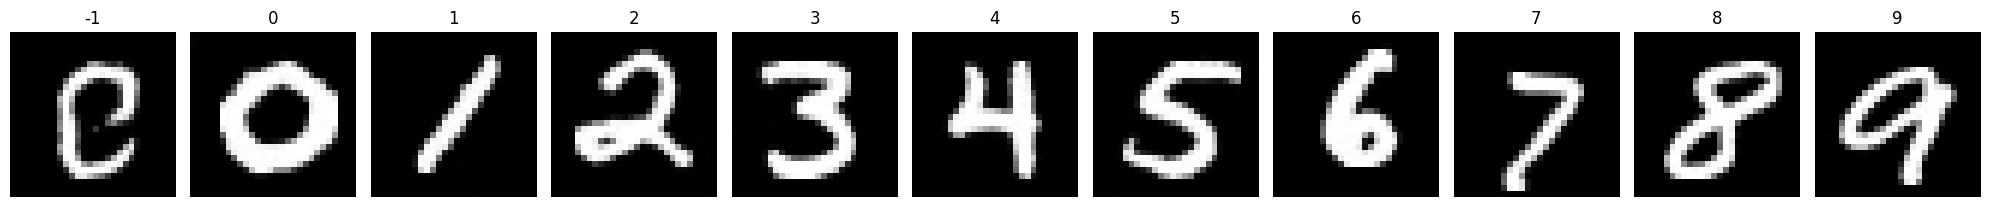

Epoch 136/300
468/468 [==============================] - 117s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.2028 - learning_rate: 5.7304e-04


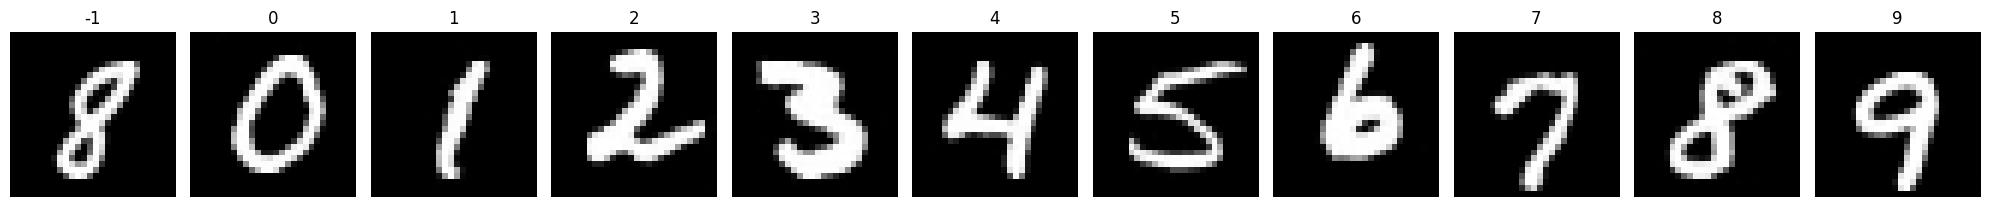

Epoch 137/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.2030 - learning_rate: 5.6786e-04


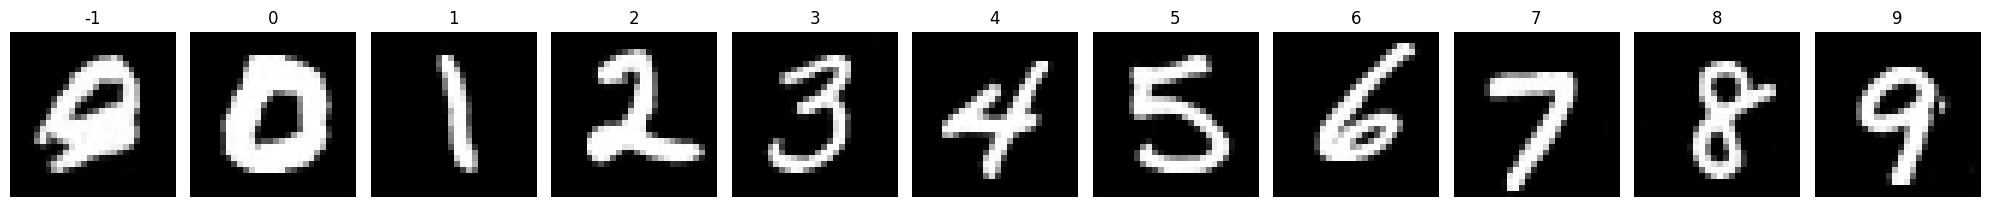

Epoch 138/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.2013 - learning_rate: 5.6267e-04


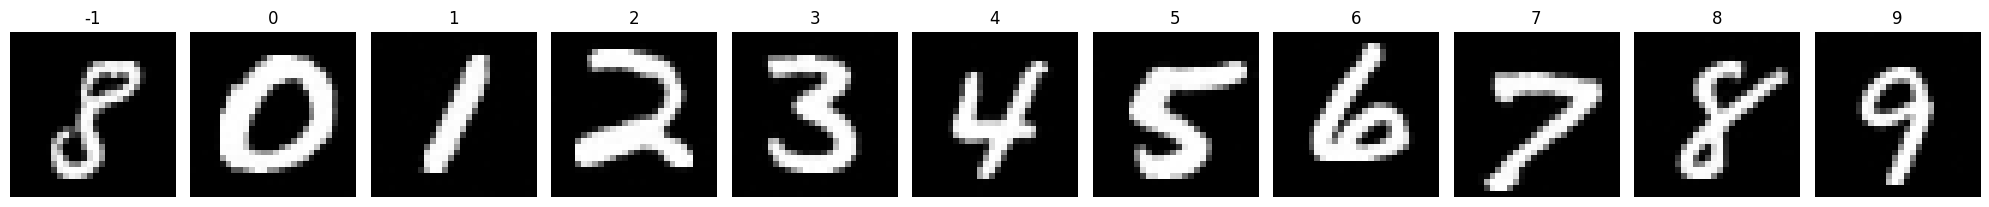

Epoch 139/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1986 - learning_rate: 5.5747e-04


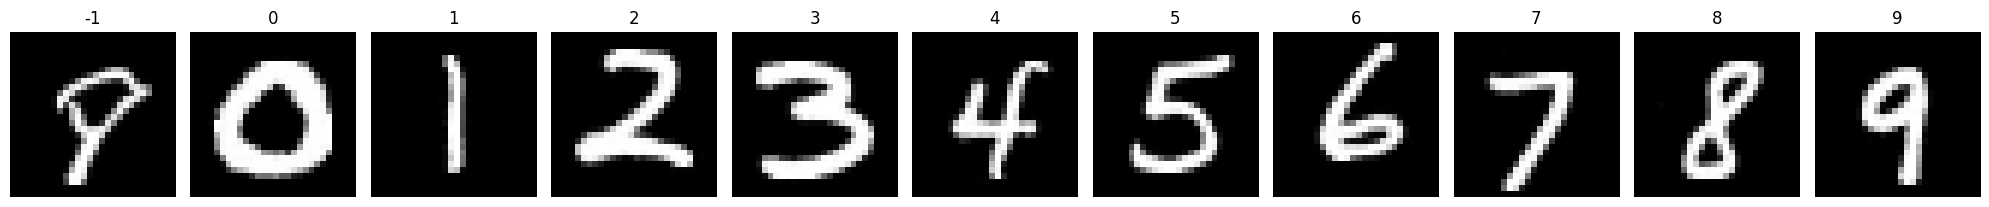

Epoch 140/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0229 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1965 - learning_rate: 5.5226e-04


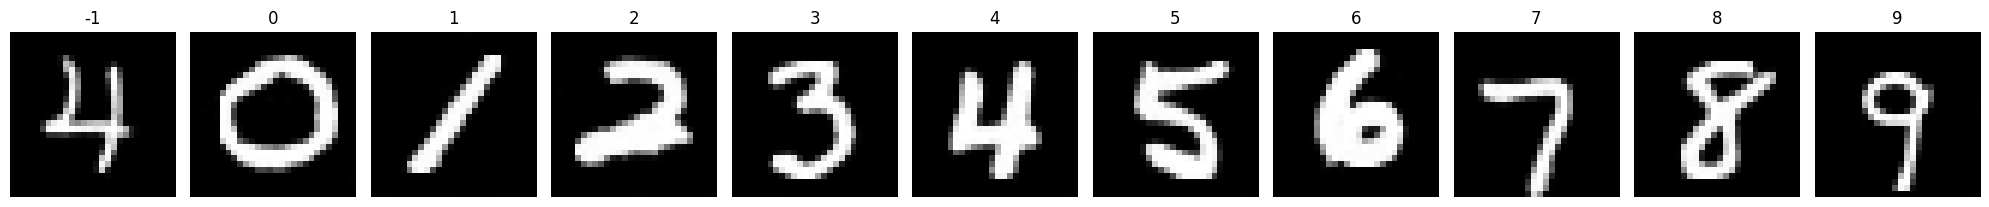

Epoch 141/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.2020 - learning_rate: 5.4705e-04


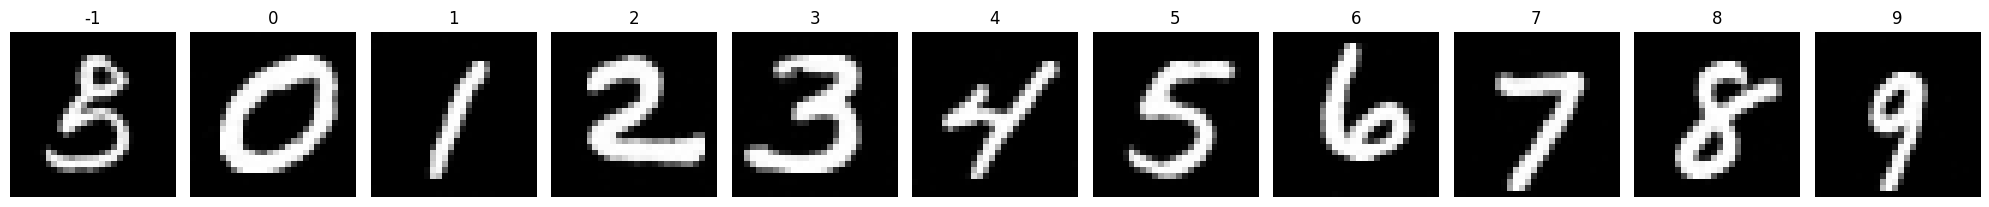

Epoch 142/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.2011 - learning_rate: 5.4184e-04


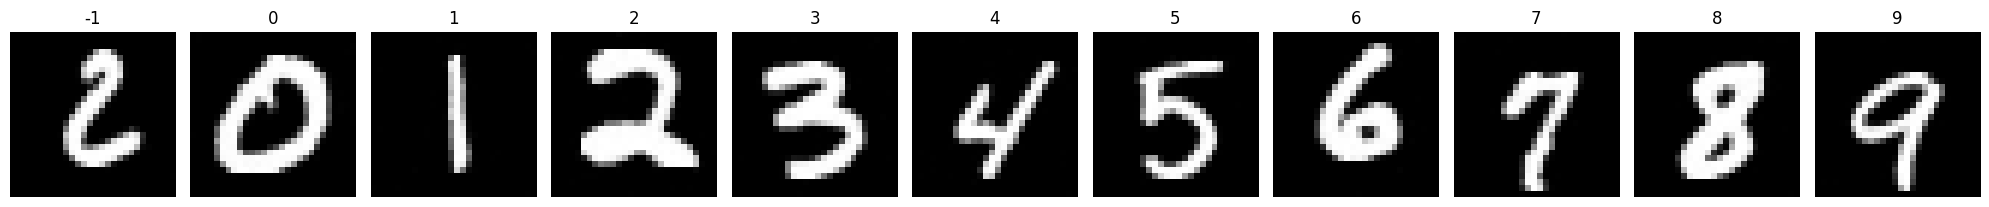

Epoch 143/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1992 - learning_rate: 5.3662e-04


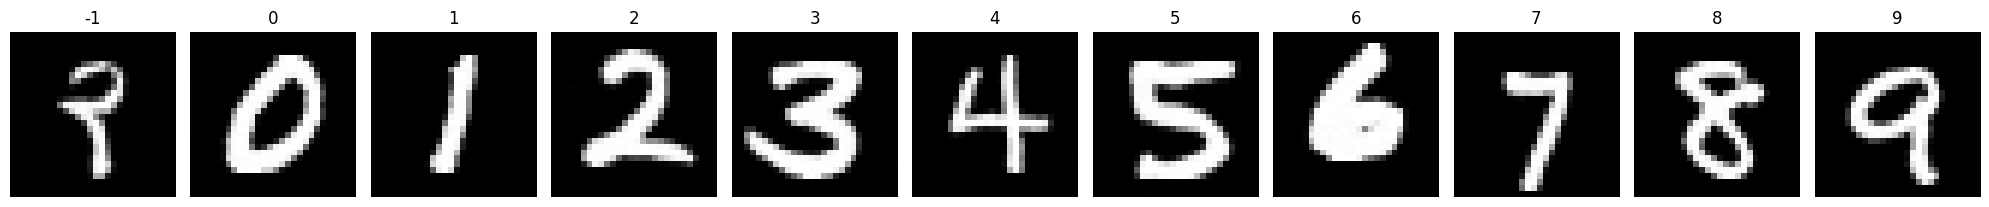

Epoch 144/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0229 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.2000 - learning_rate: 5.3140e-04


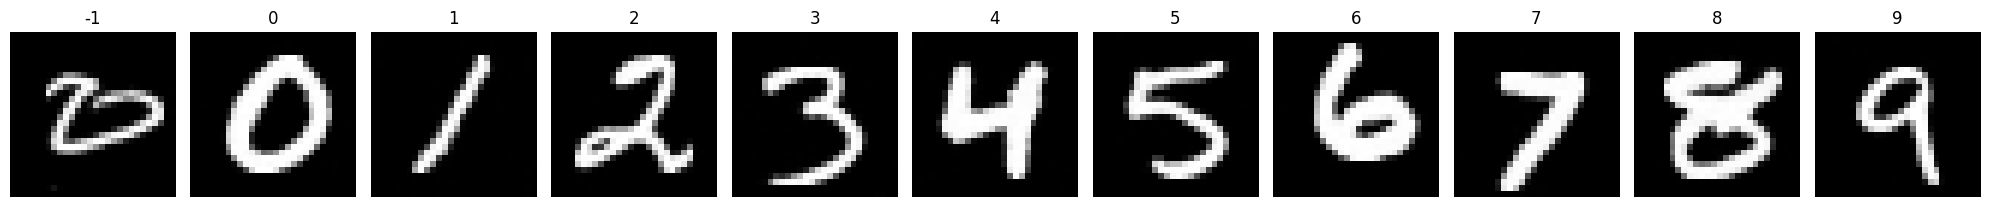

Epoch 145/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0230 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.2033 - learning_rate: 5.2617e-04


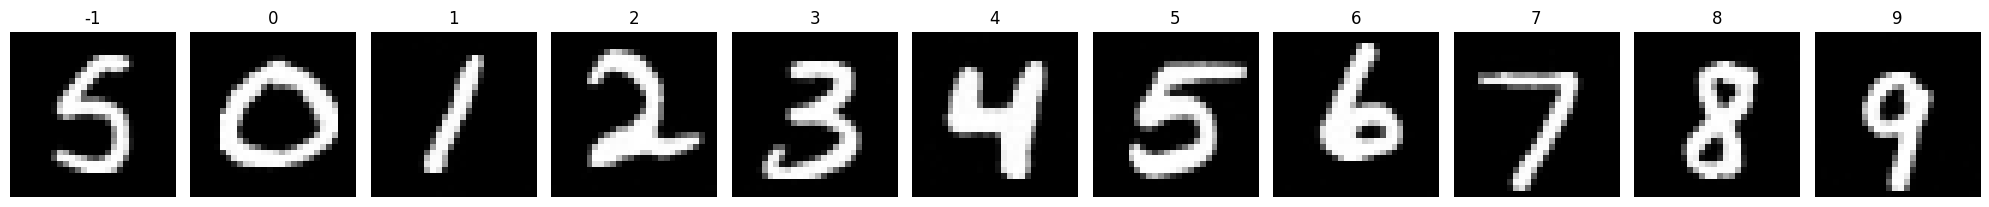

Epoch 146/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1999 - learning_rate: 5.2094e-04


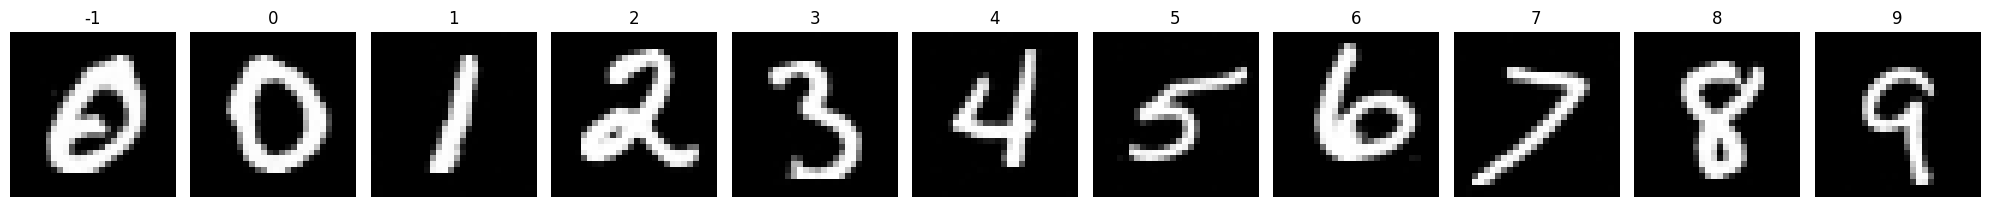

Epoch 147/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0228 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.2014 - learning_rate: 5.1571e-04


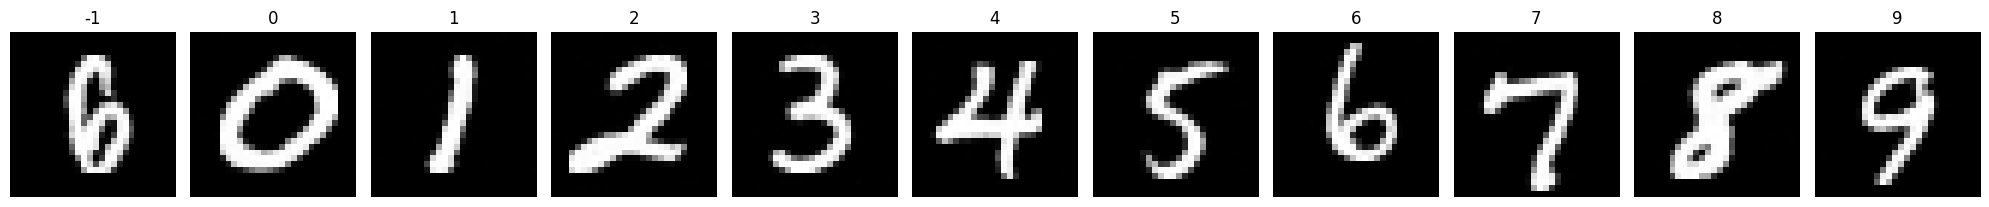

Epoch 148/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1993 - learning_rate: 5.1047e-04


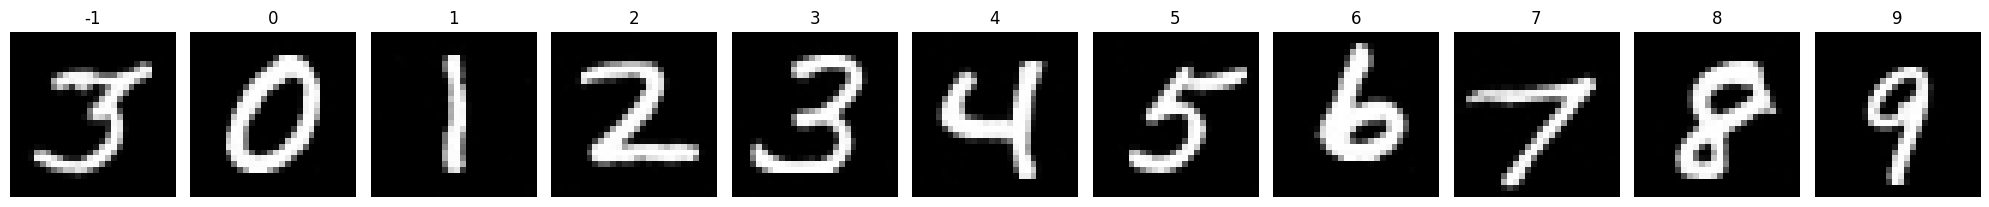

Epoch 149/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0230 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1976 - learning_rate: 5.0524e-04


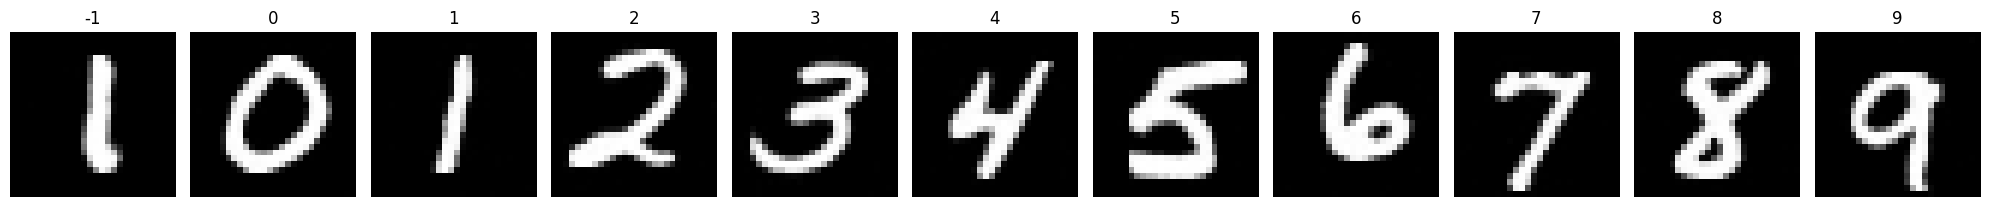

Epoch 150/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.2016 - learning_rate: 5.0000e-04


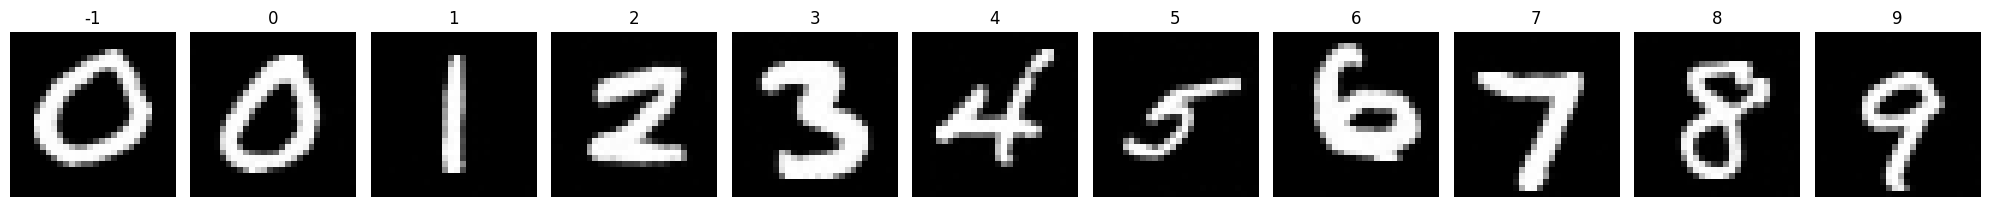

Epoch 151/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1994 - learning_rate: 4.9476e-04


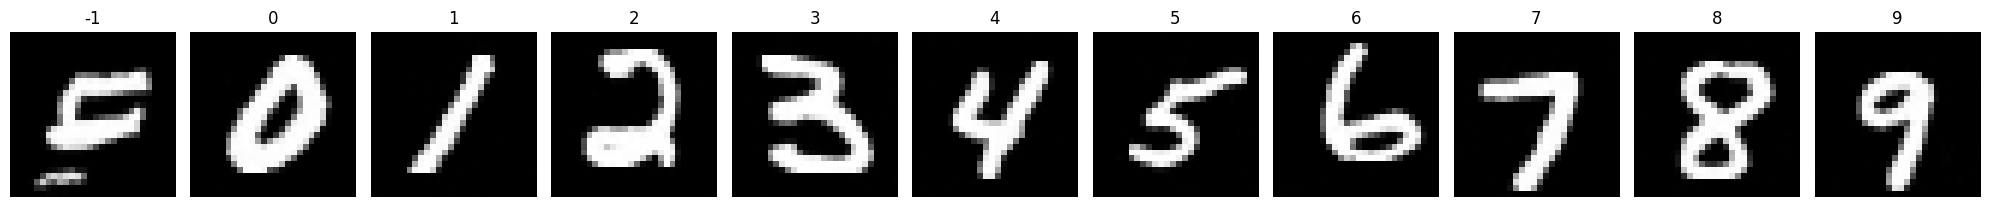

Epoch 152/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1944 - learning_rate: 4.8953e-04


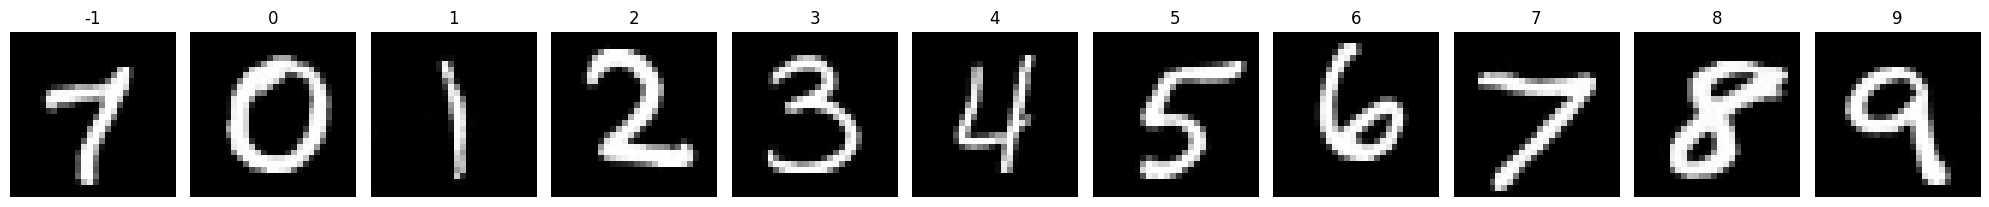

Epoch 153/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1974 - learning_rate: 4.8429e-04


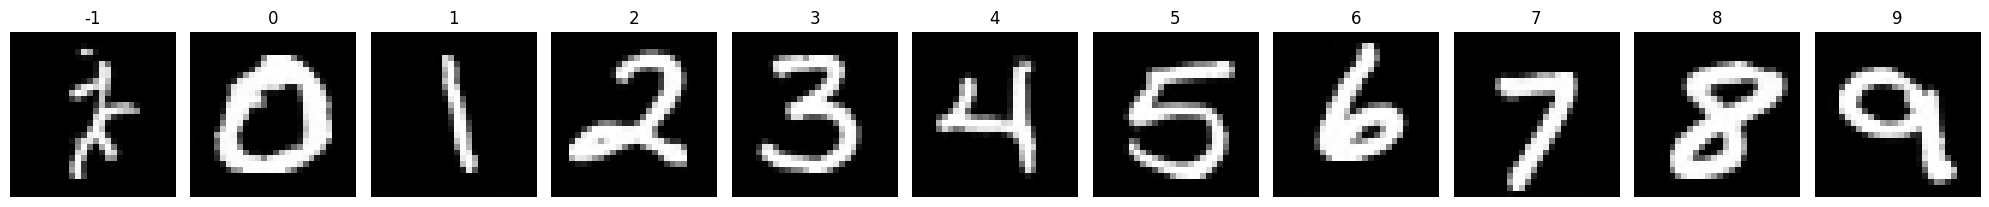

Epoch 154/300
468/468 [==============================] - 117s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1965 - learning_rate: 4.7906e-04


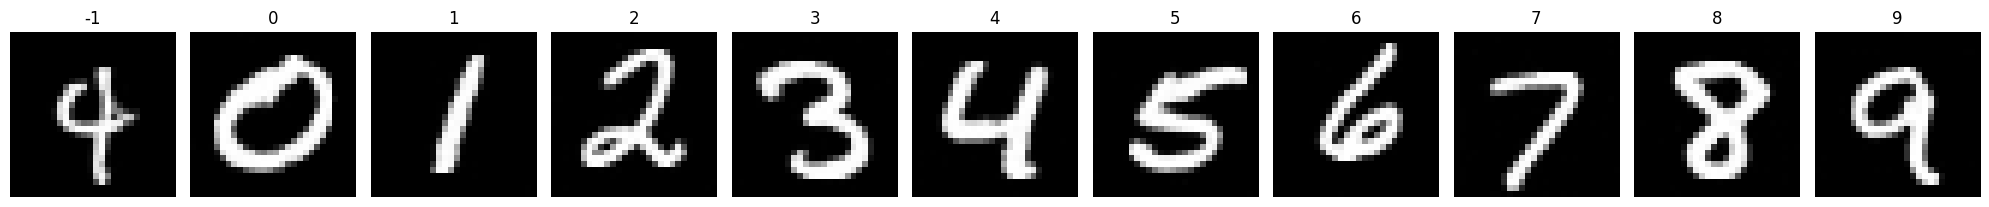

Epoch 155/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.2028 - learning_rate: 4.7383e-04


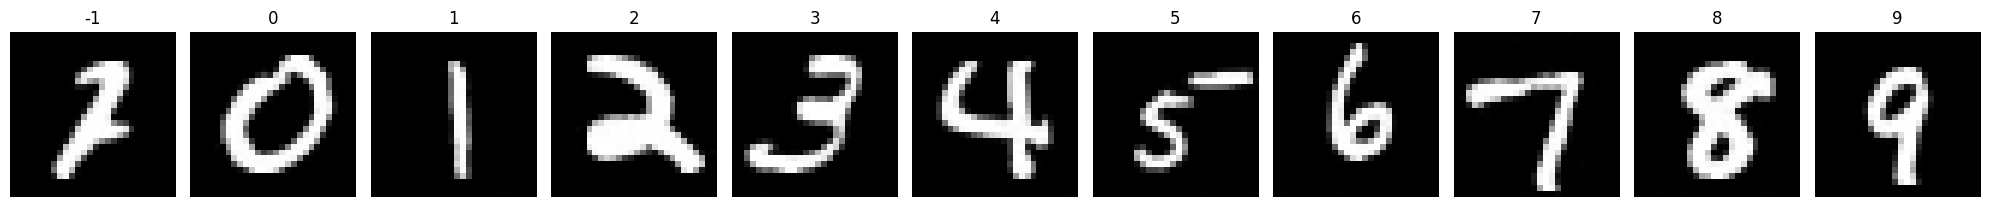

Epoch 156/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.2002 - learning_rate: 4.6860e-04


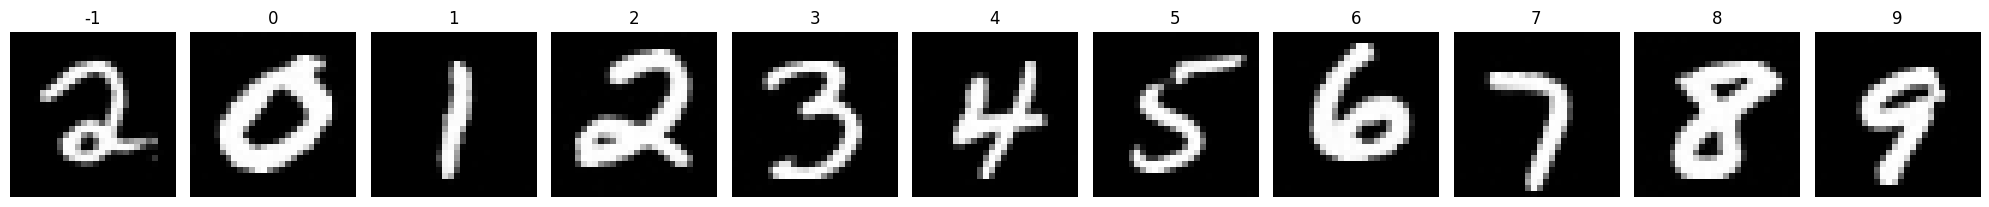

Epoch 157/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1985 - learning_rate: 4.6338e-04


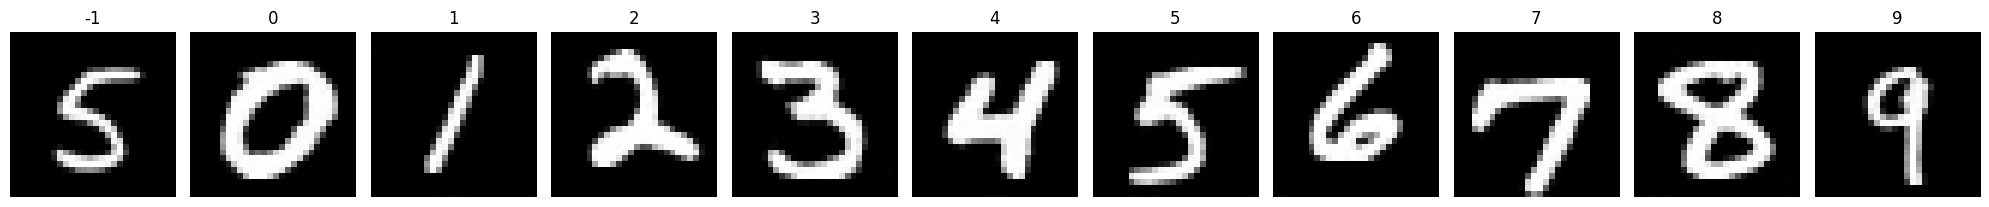

Epoch 158/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1988 - learning_rate: 4.5816e-04


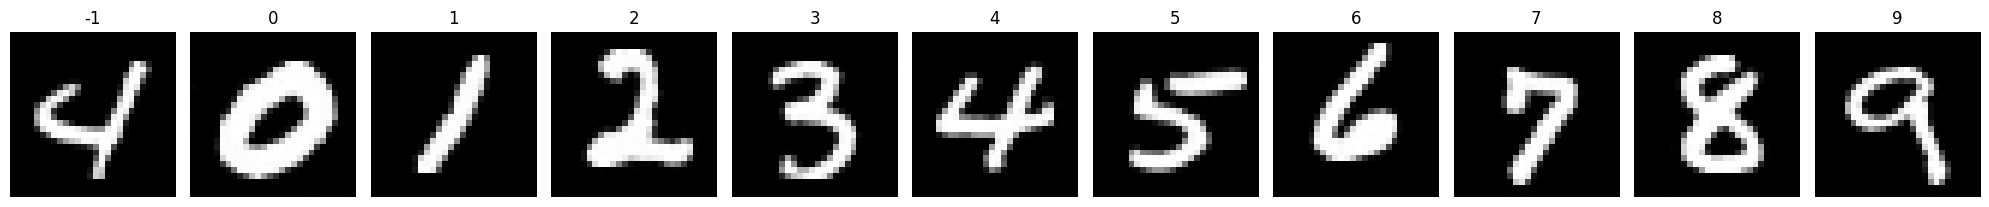

Epoch 159/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.2007 - learning_rate: 4.5295e-04


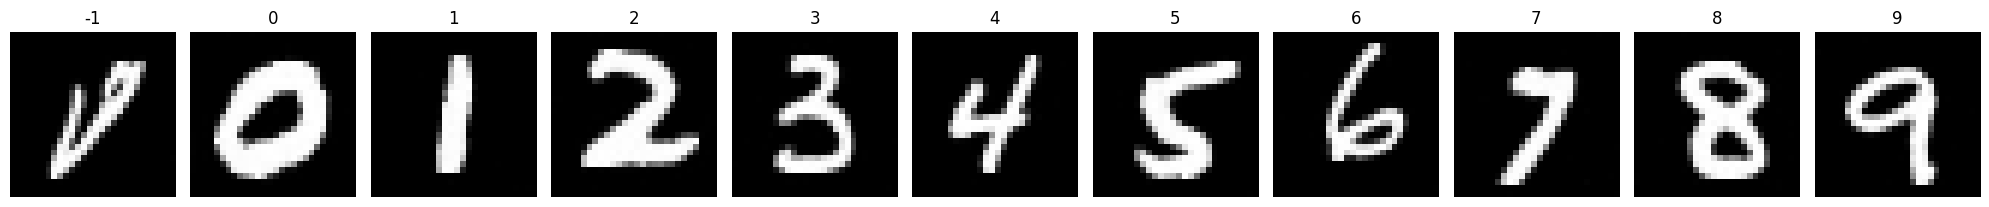

Epoch 160/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0228 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.2002 - learning_rate: 4.4774e-04


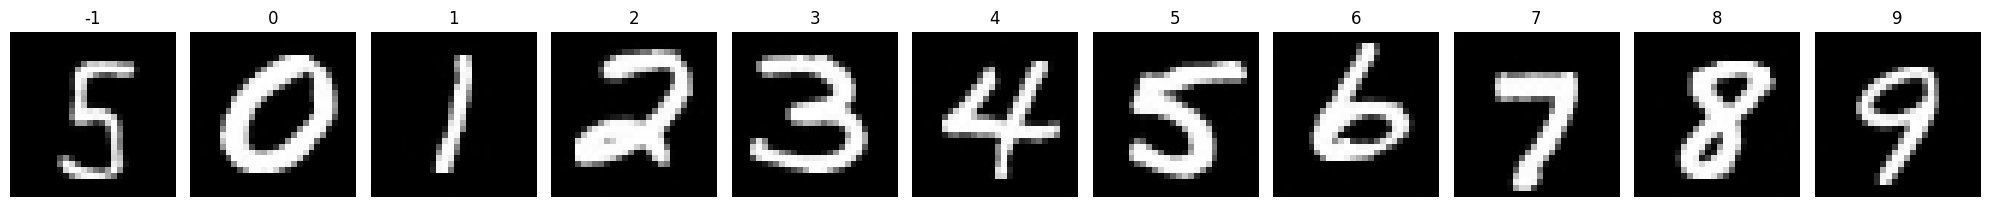

Epoch 161/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0229 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.2033 - learning_rate: 4.4253e-04


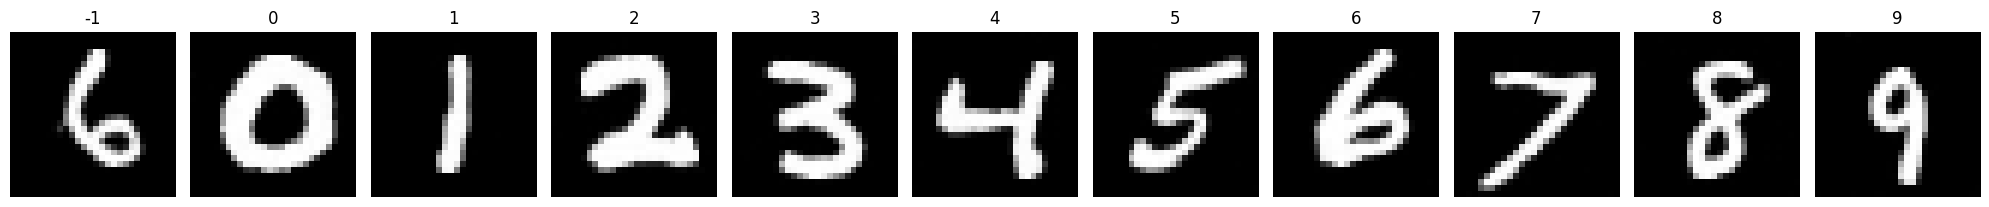

Epoch 162/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1991 - learning_rate: 4.3733e-04


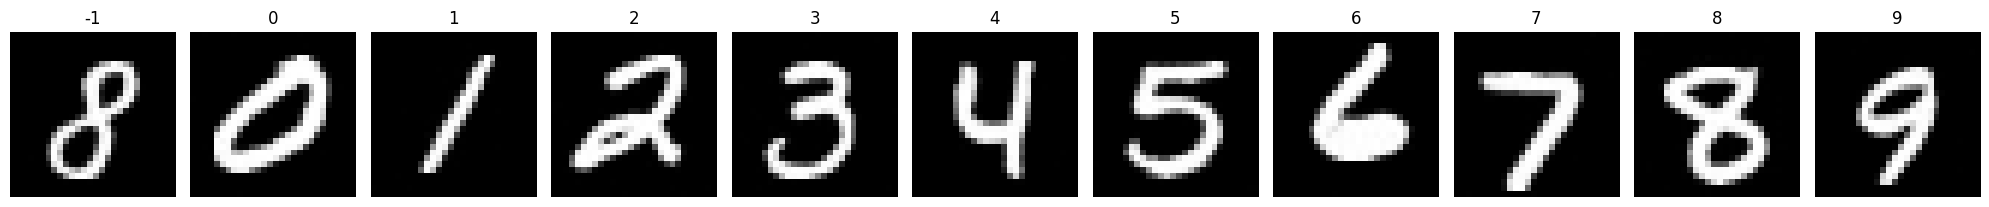

Epoch 163/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.2026 - learning_rate: 4.3214e-04


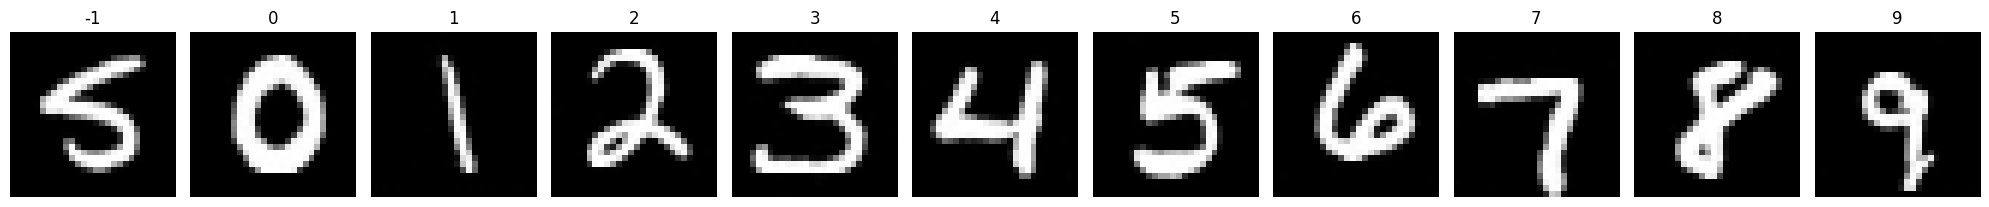

Epoch 164/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1983 - learning_rate: 4.2696e-04


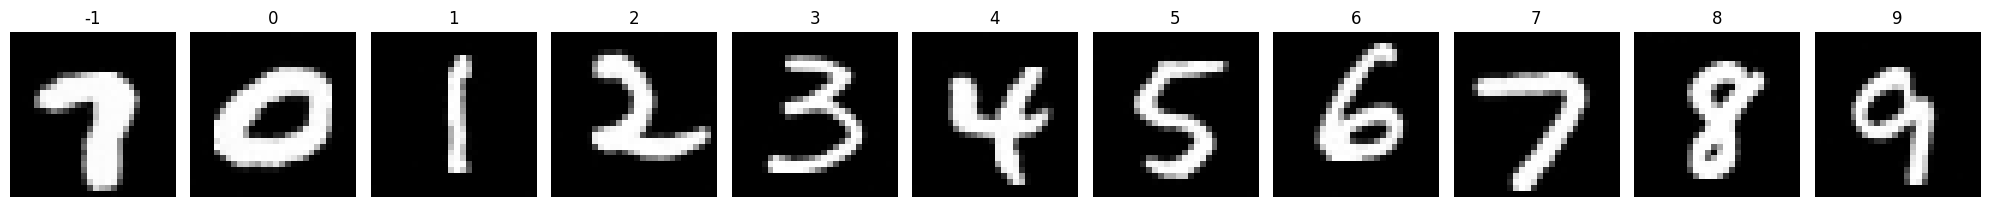

Epoch 165/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0227 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.2008 - learning_rate: 4.2178e-04


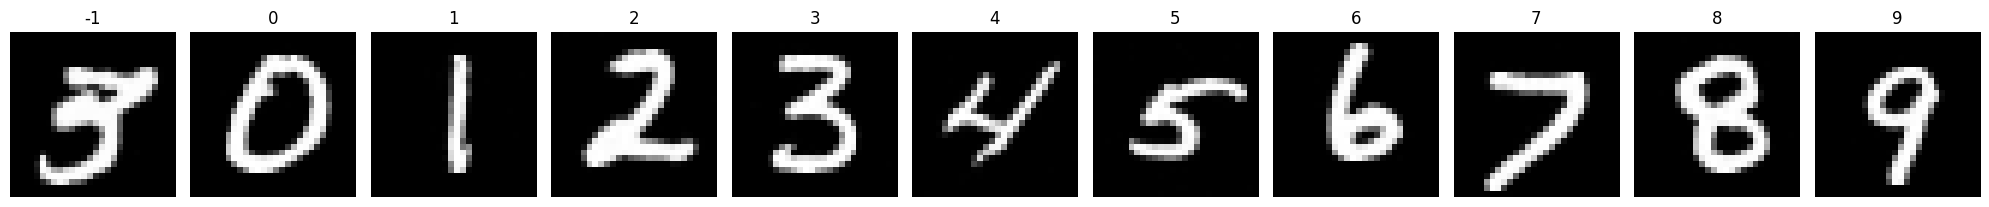

Epoch 166/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1952 - learning_rate: 4.1662e-04


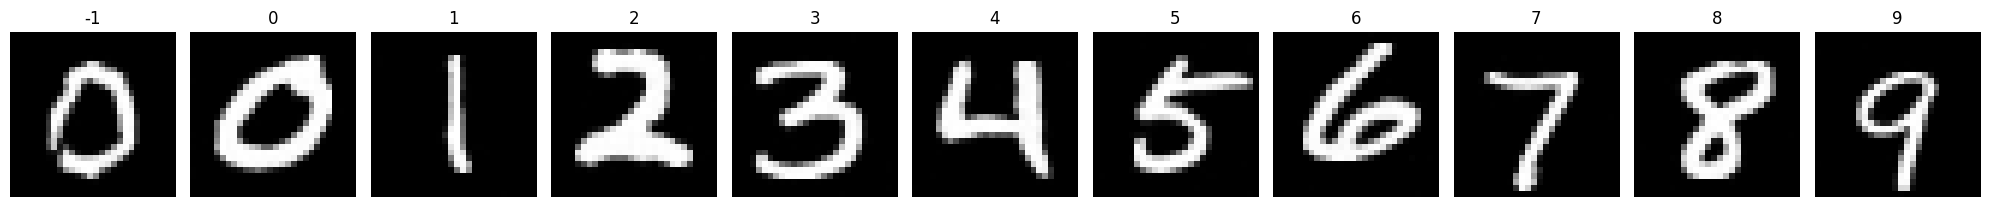

Epoch 167/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1967 - learning_rate: 4.1146e-04


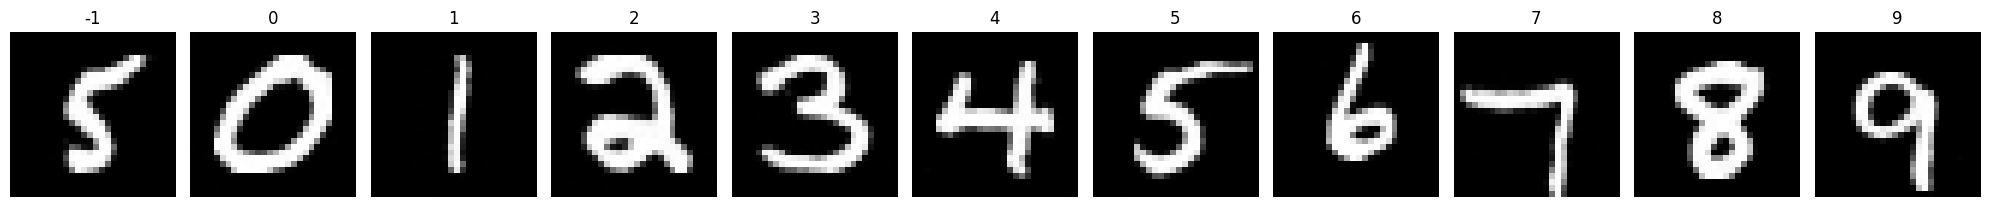

Epoch 168/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1987 - learning_rate: 4.0631e-04


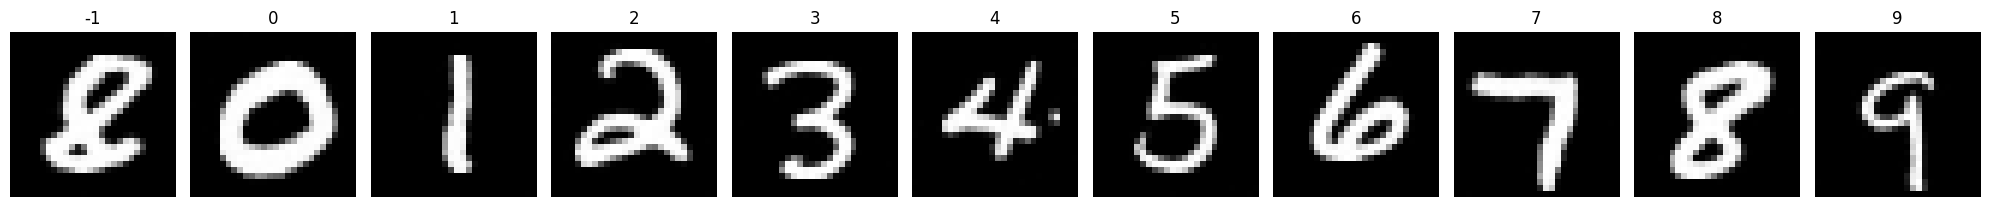

Epoch 169/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1972 - learning_rate: 4.0117e-04


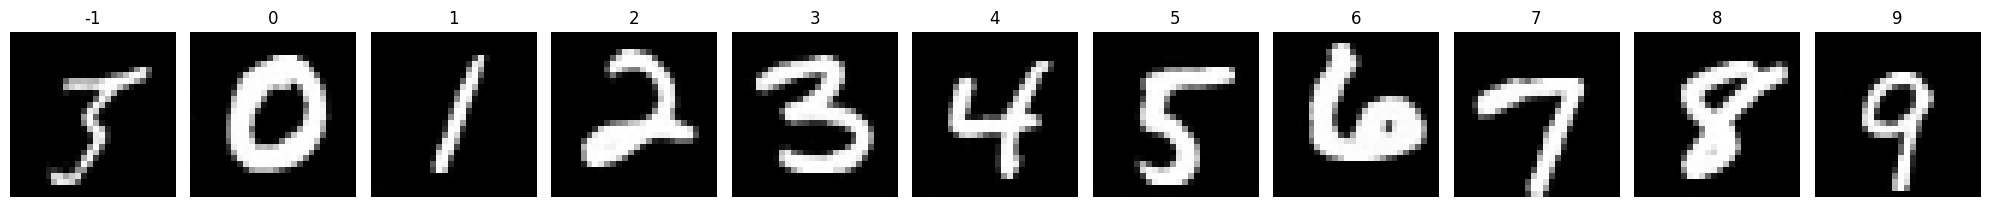

Epoch 170/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1986 - learning_rate: 3.9604e-04


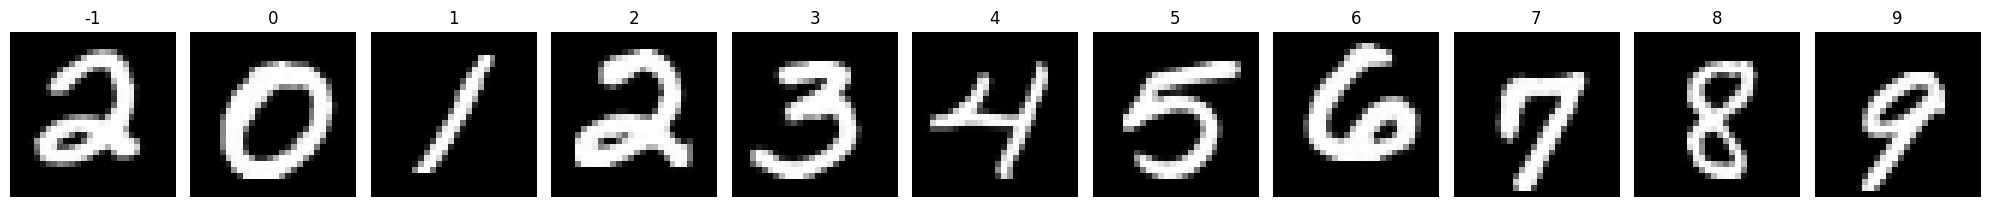

Epoch 171/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1934 - learning_rate: 3.9093e-04


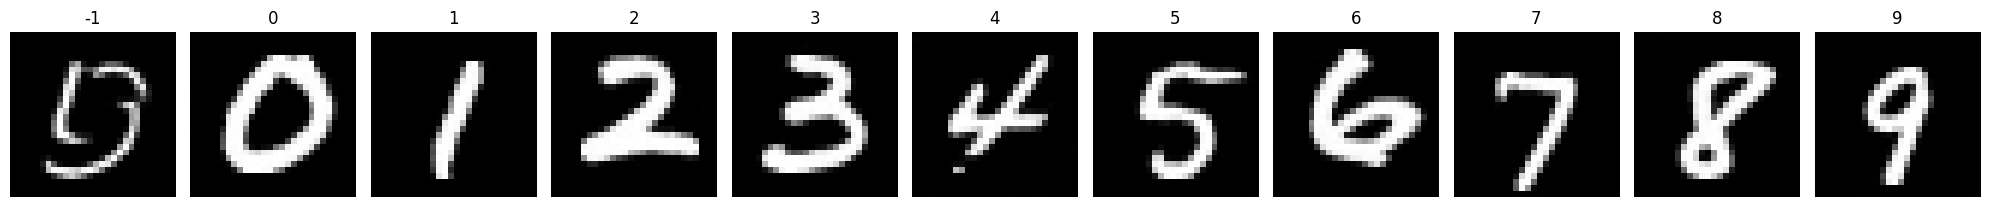

Epoch 172/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0228 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1975 - learning_rate: 3.8582e-04


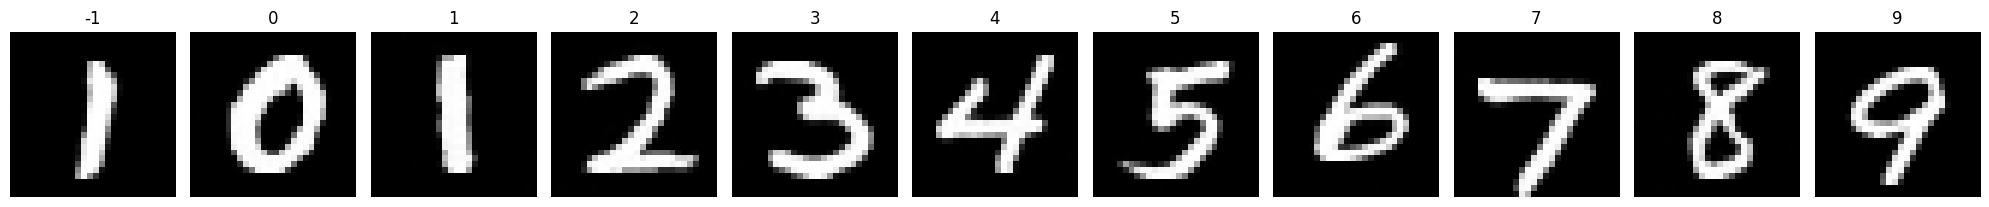

Epoch 173/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1956 - learning_rate: 3.8073e-04


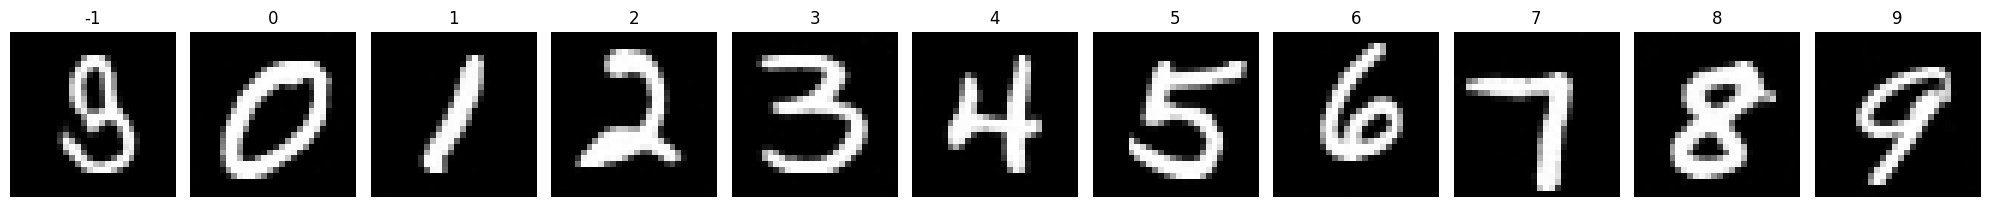

Epoch 174/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1954 - learning_rate: 3.7566e-04


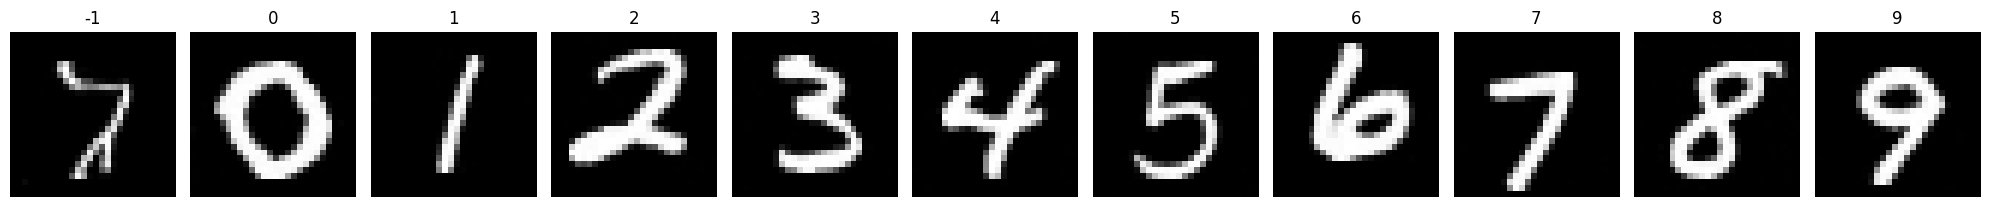

Epoch 175/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1977 - learning_rate: 3.7059e-04


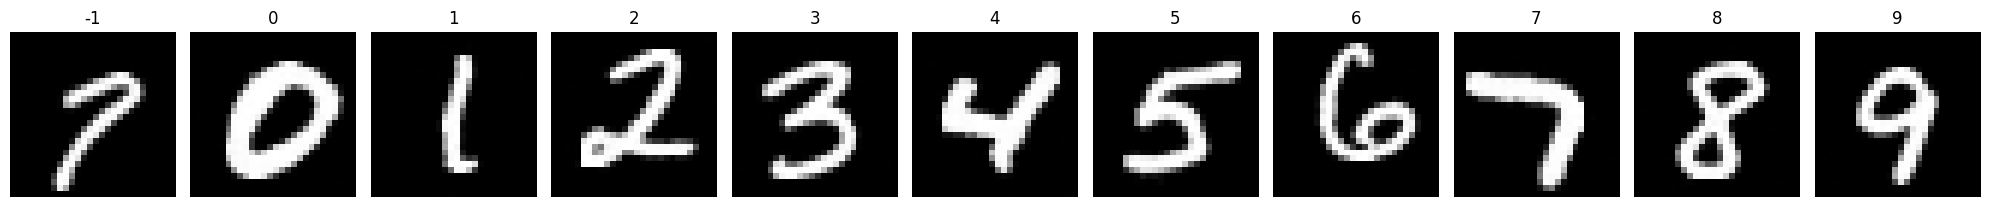

Epoch 176/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1952 - learning_rate: 3.6554e-04


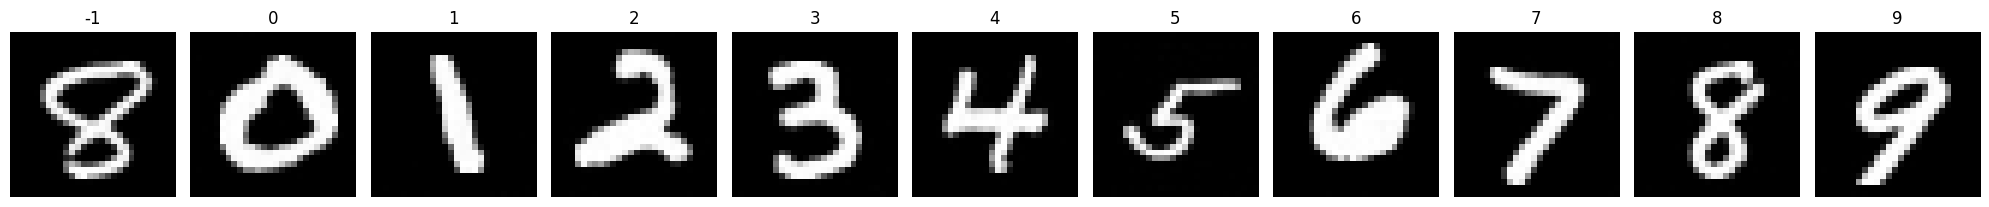

Epoch 177/300
468/468 [==============================] - 117s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1974 - learning_rate: 3.6050e-04


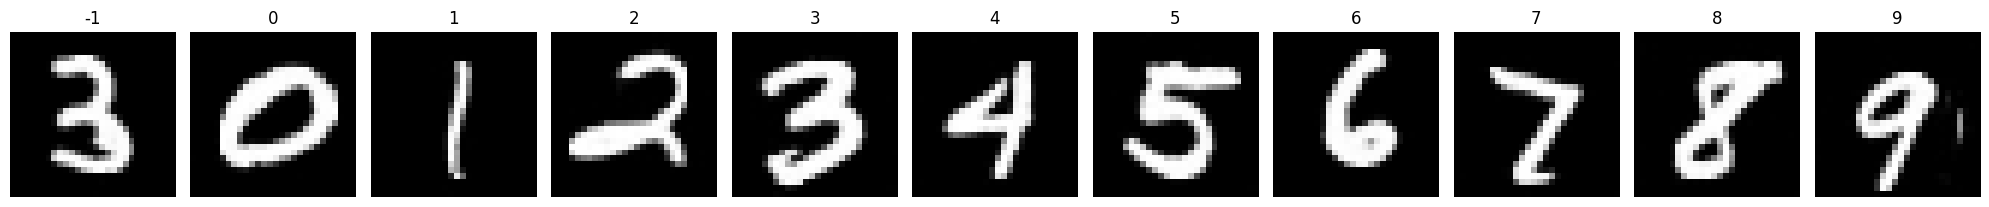

Epoch 178/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.2003 - learning_rate: 3.5548e-04


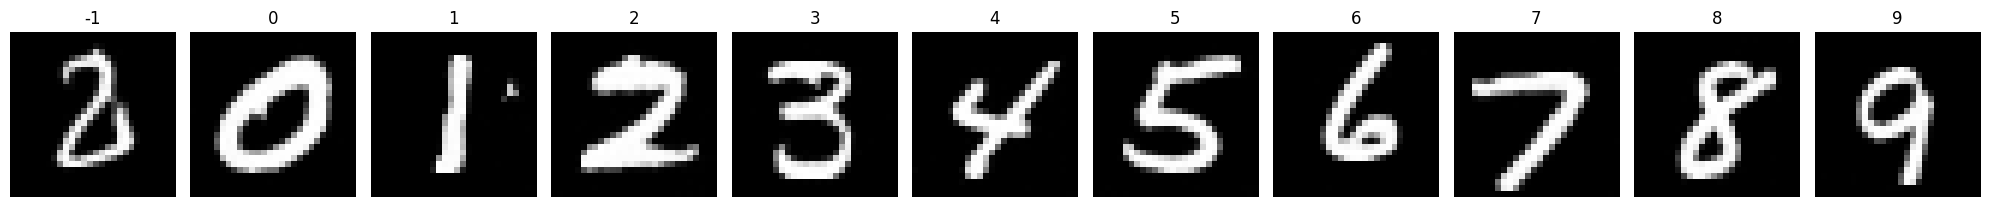

Epoch 179/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0228 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1968 - learning_rate: 3.5048e-04


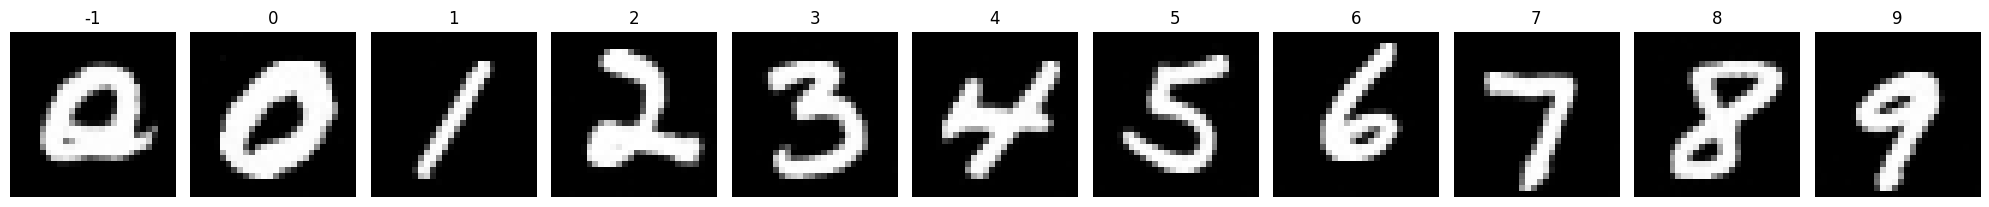

Epoch 180/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1950 - learning_rate: 3.4549e-04


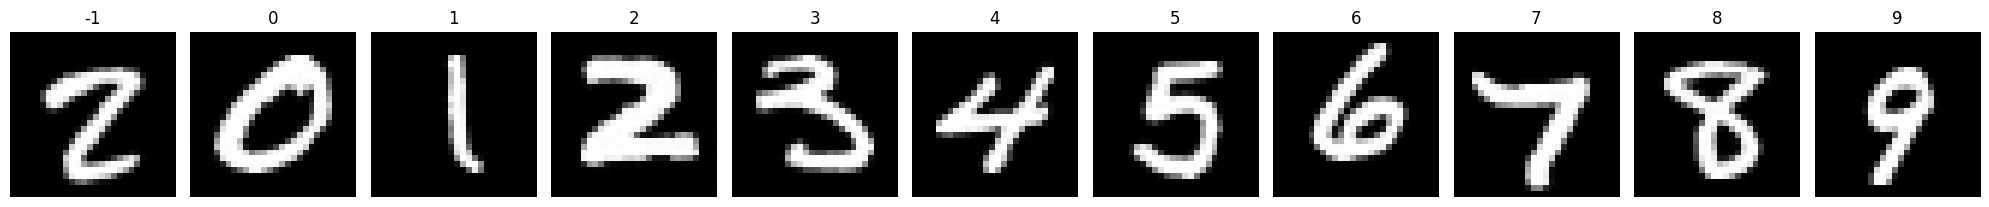

Epoch 181/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1970 - learning_rate: 3.4052e-04


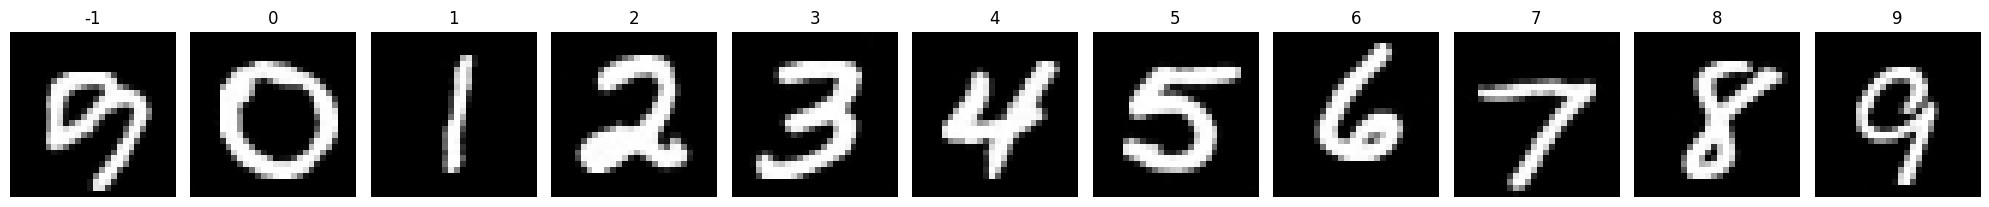

Epoch 182/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.2029 - learning_rate: 3.3557e-04


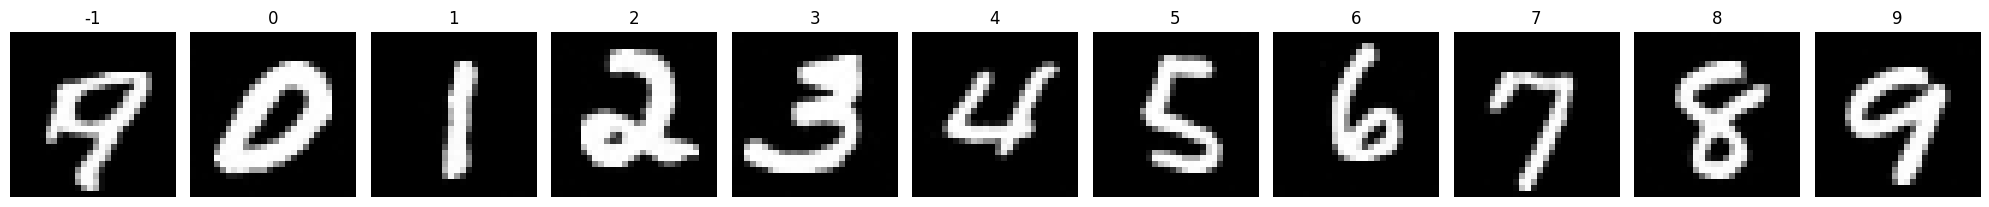

Epoch 183/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0227 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.2008 - learning_rate: 3.3063e-04


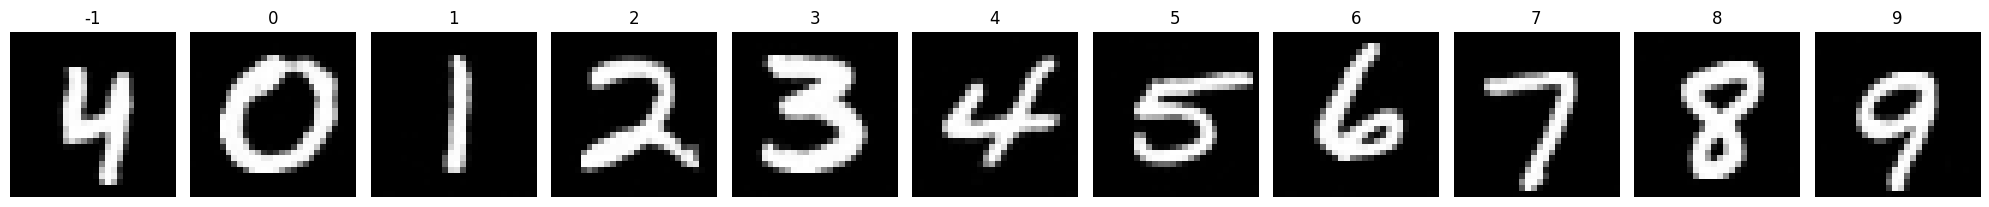

Epoch 184/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0227 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1981 - learning_rate: 3.2571e-04


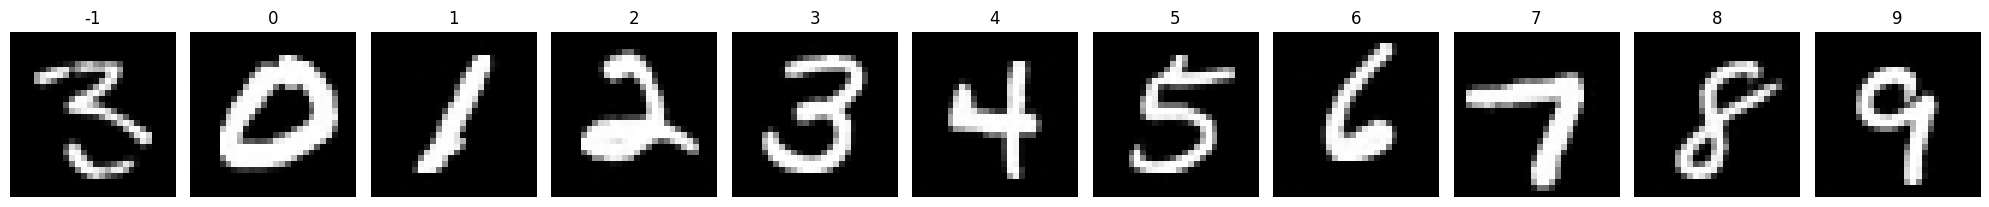

Epoch 185/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1966 - learning_rate: 3.2082e-04


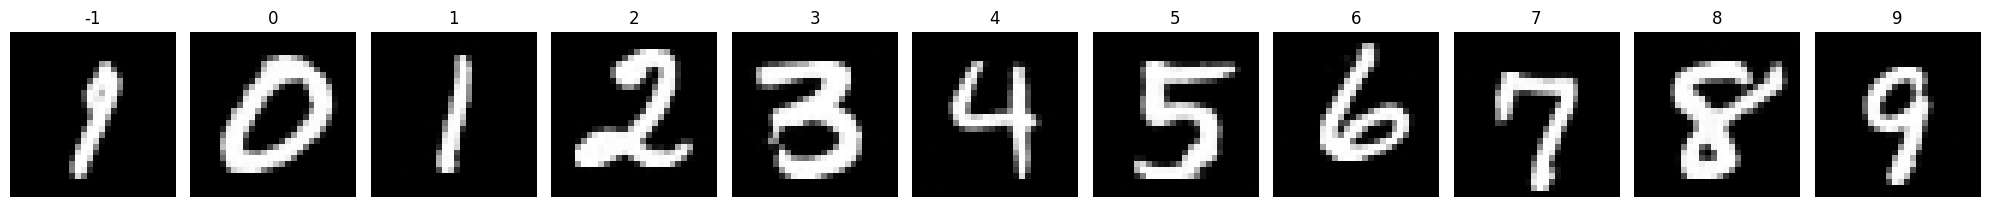

Epoch 186/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1929 - learning_rate: 3.1594e-04


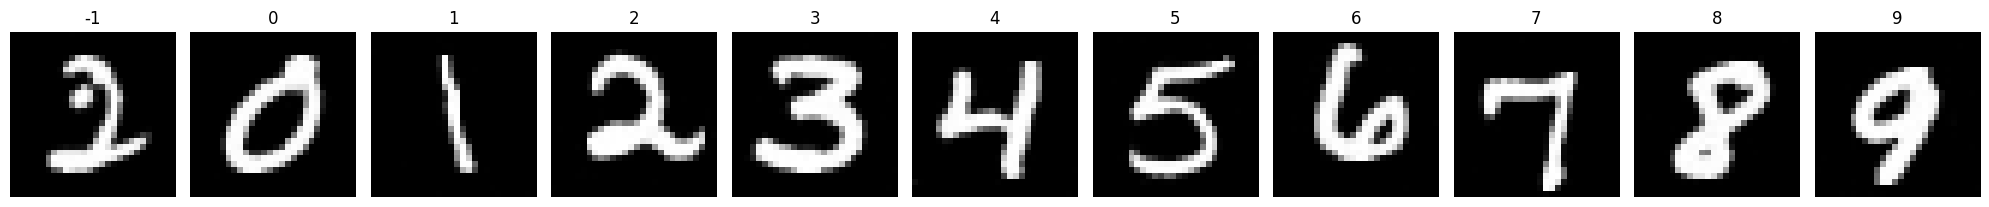

Epoch 187/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1986 - learning_rate: 3.1108e-04


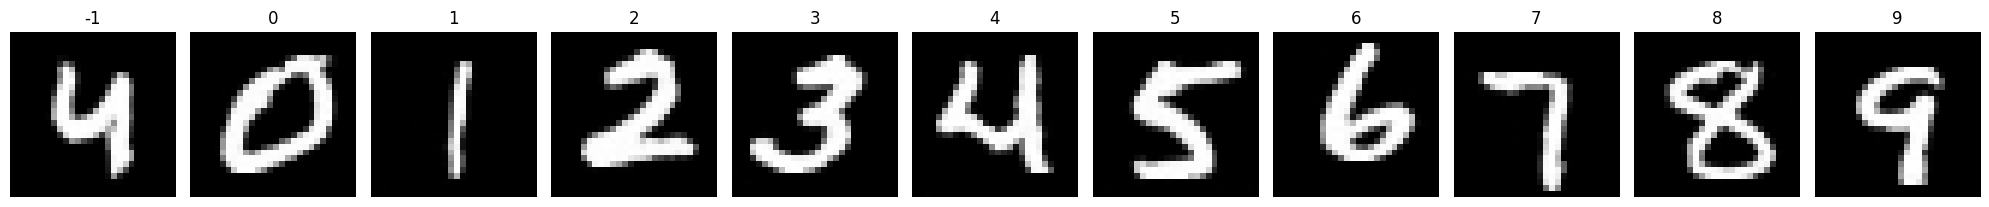

Epoch 188/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1946 - learning_rate: 3.0624e-04


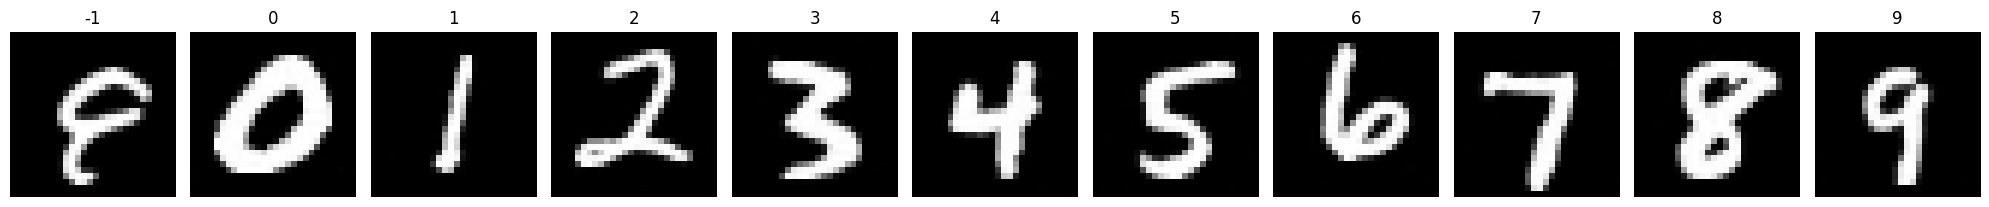

Epoch 189/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0225 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1966 - learning_rate: 3.0143e-04


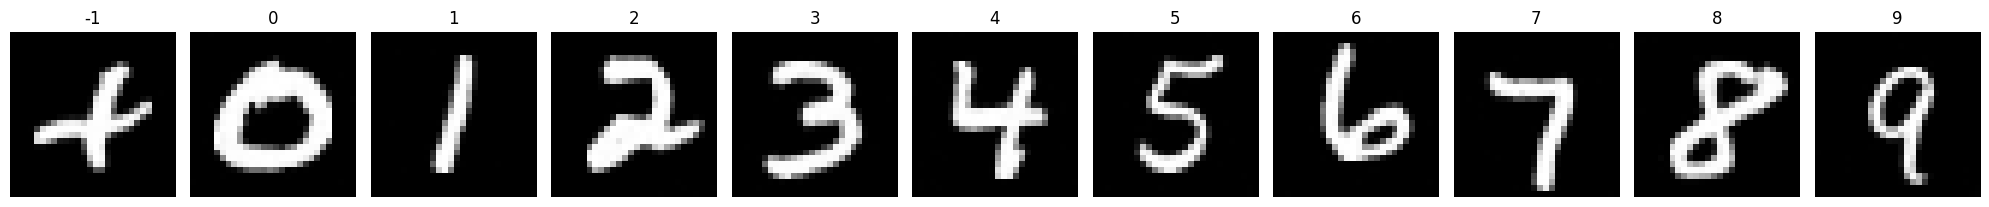

Epoch 190/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1982 - learning_rate: 2.9663e-04


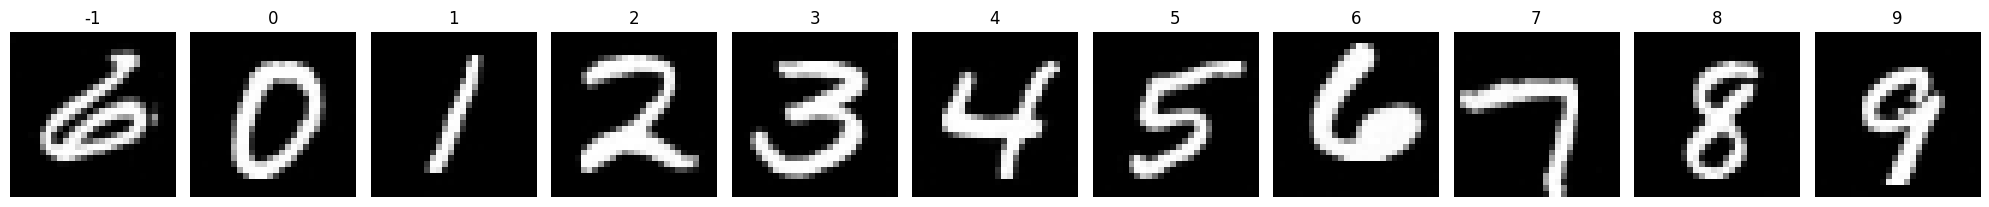

Epoch 191/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0227 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1946 - learning_rate: 2.9186e-04


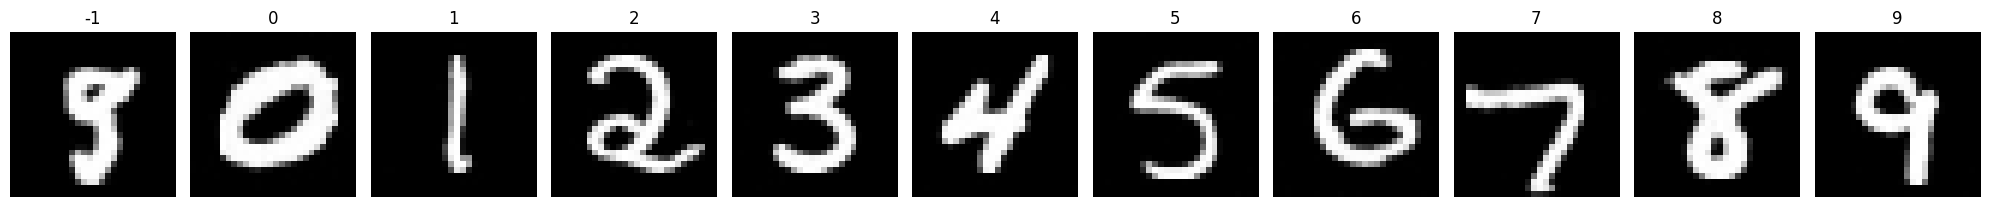

Epoch 192/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1971 - learning_rate: 2.8711e-04


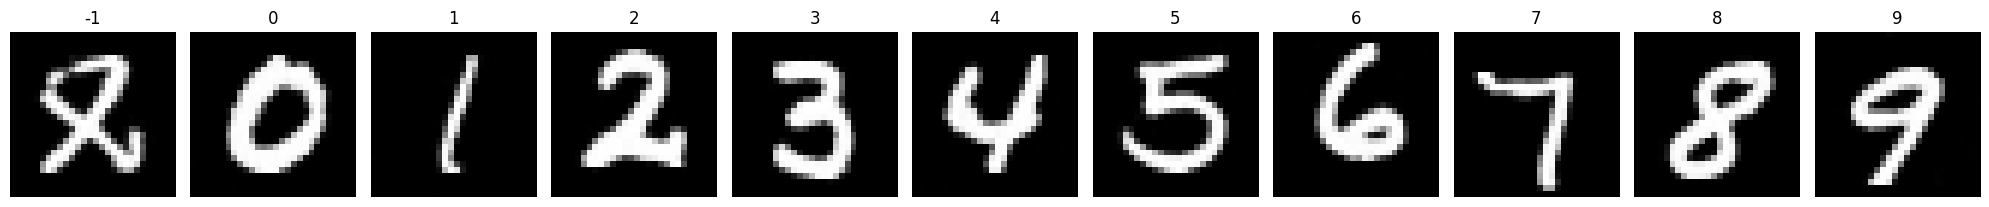

Epoch 193/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1964 - learning_rate: 2.8238e-04


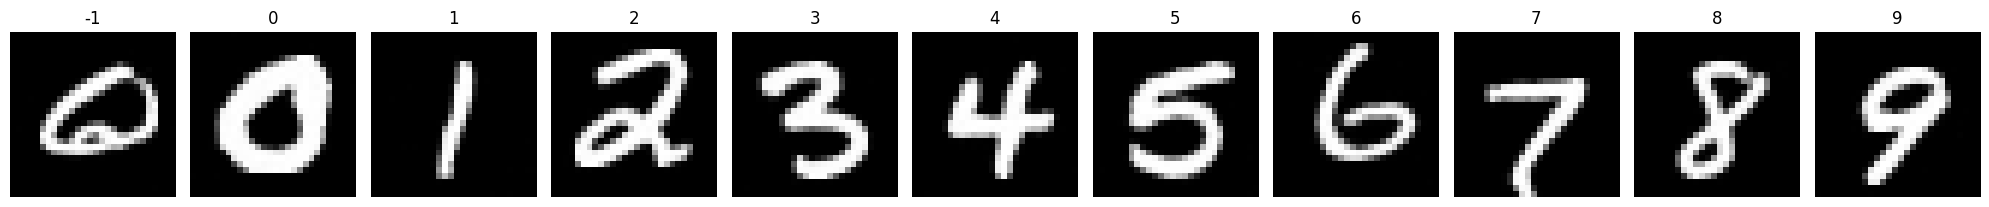

Epoch 194/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1973 - learning_rate: 2.7768e-04


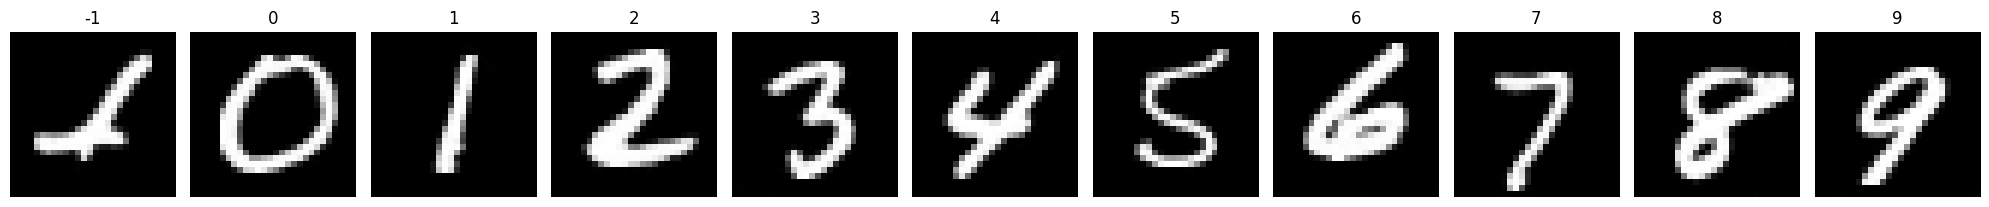

Epoch 195/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1975 - learning_rate: 2.7300e-04


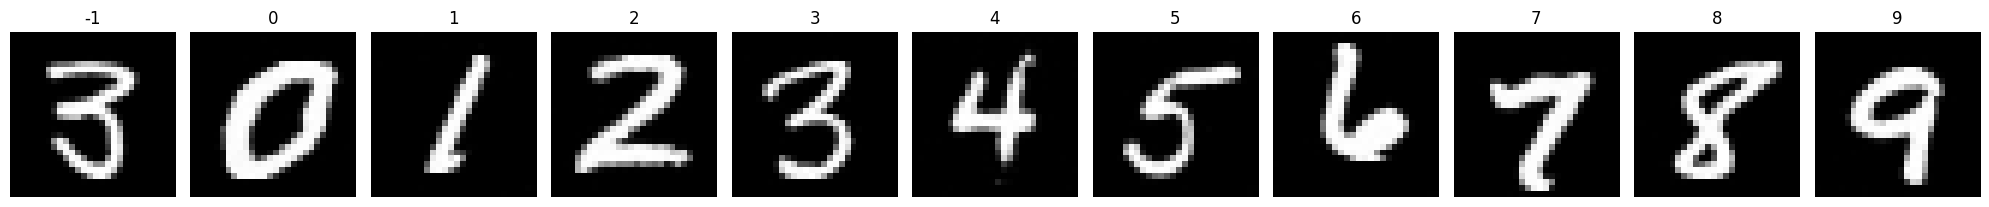

Epoch 196/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.2003 - learning_rate: 2.6835e-04


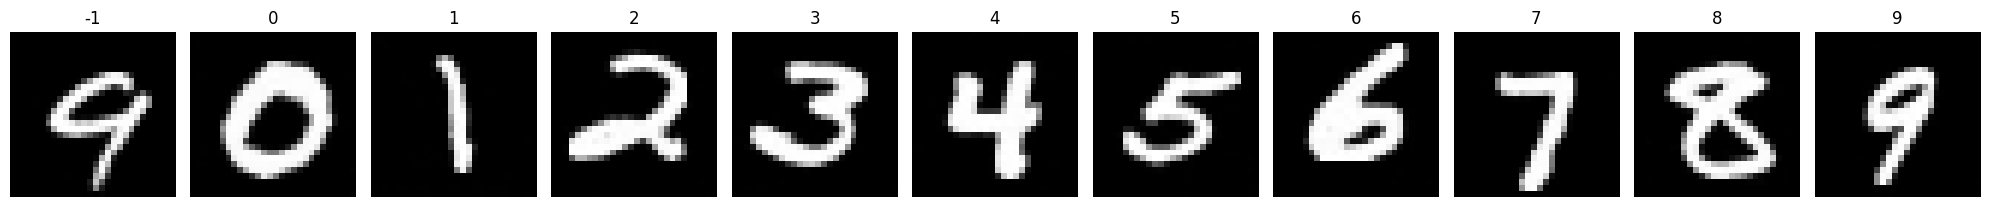

Epoch 197/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.1978 - learning_rate: 2.6372e-04


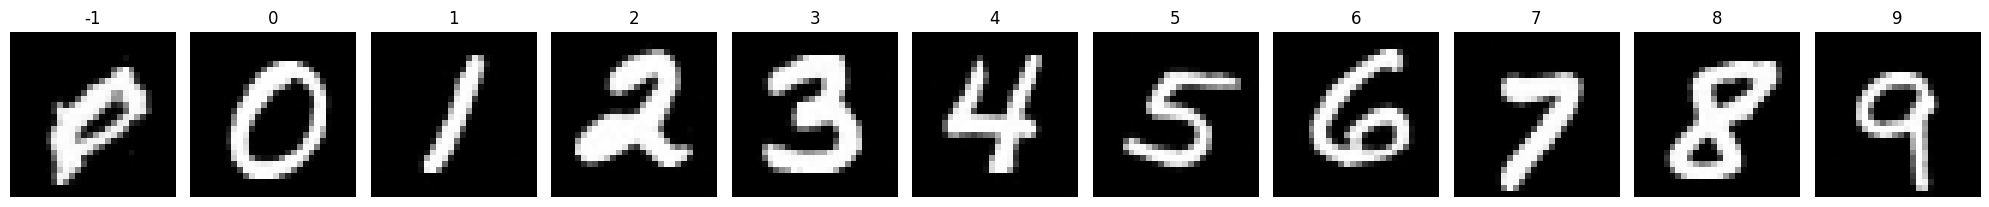

Epoch 198/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1990 - learning_rate: 2.5912e-04


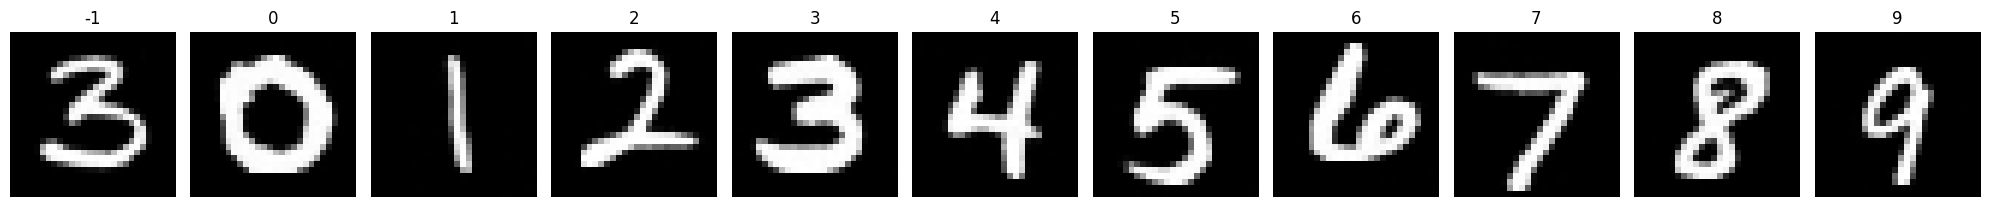

Epoch 199/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0226 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1935 - learning_rate: 2.5455e-04


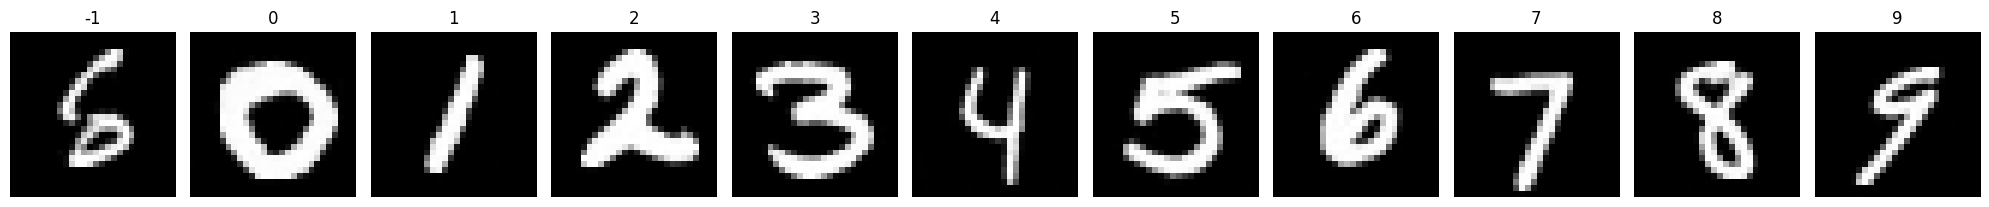

Epoch 200/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0225 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.2027 - learning_rate: 2.5000e-04


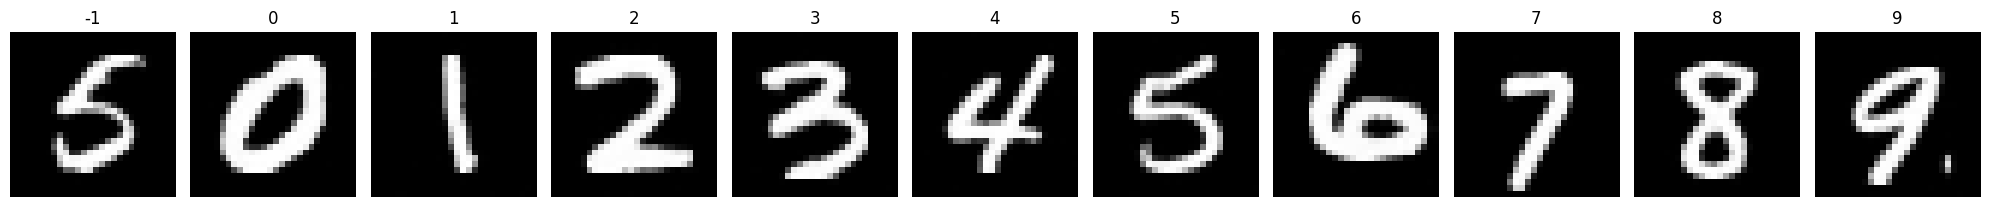

Epoch 201/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1977 - learning_rate: 2.4548e-04


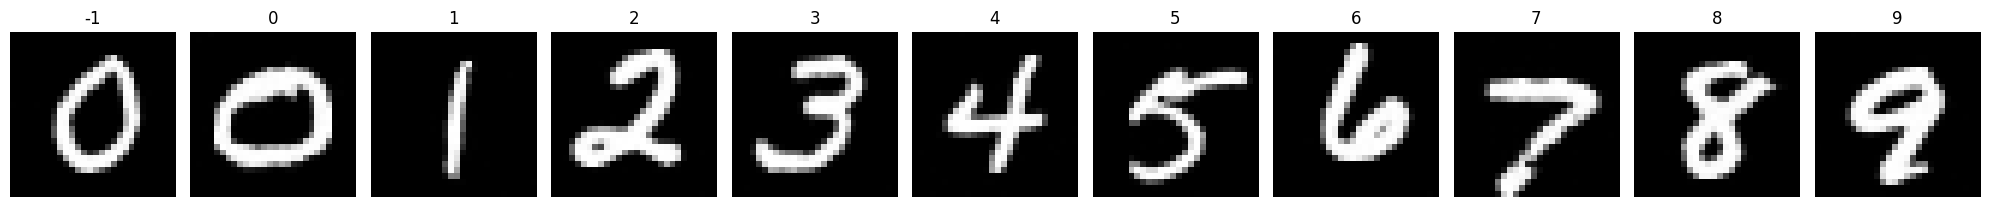

Epoch 202/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0225 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1926 - learning_rate: 2.4099e-04


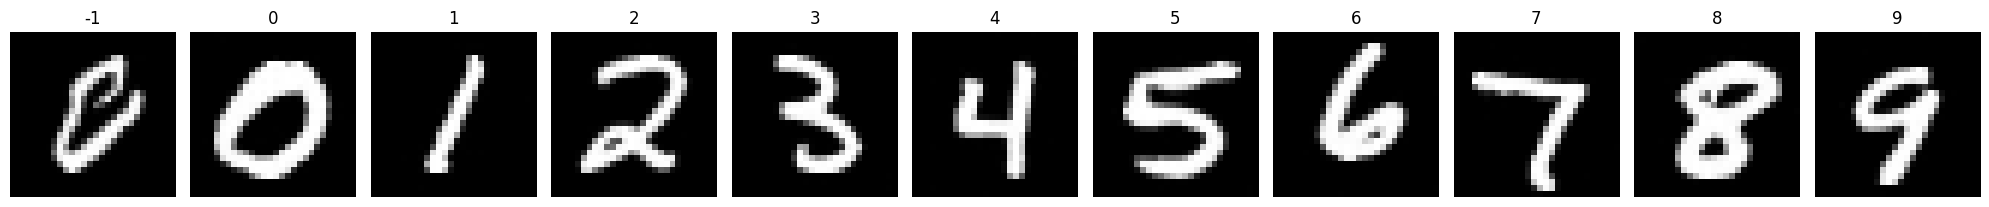

Epoch 203/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0225 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1961 - learning_rate: 2.3652e-04


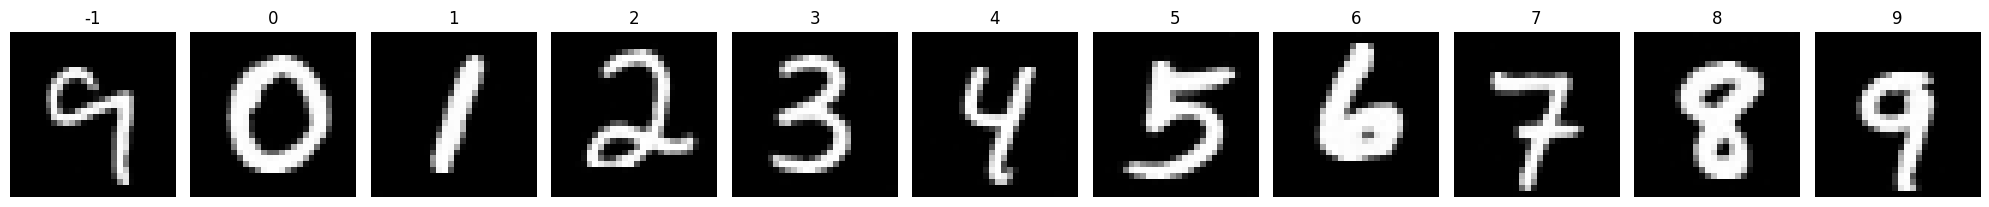

Epoch 204/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0225 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.2035 - learning_rate: 2.3209e-04


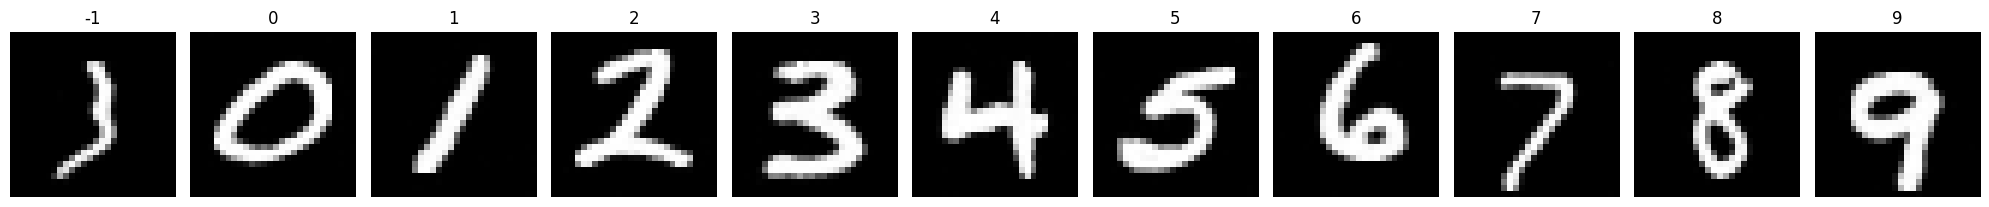

Epoch 205/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0225 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1903 - learning_rate: 2.2768e-04


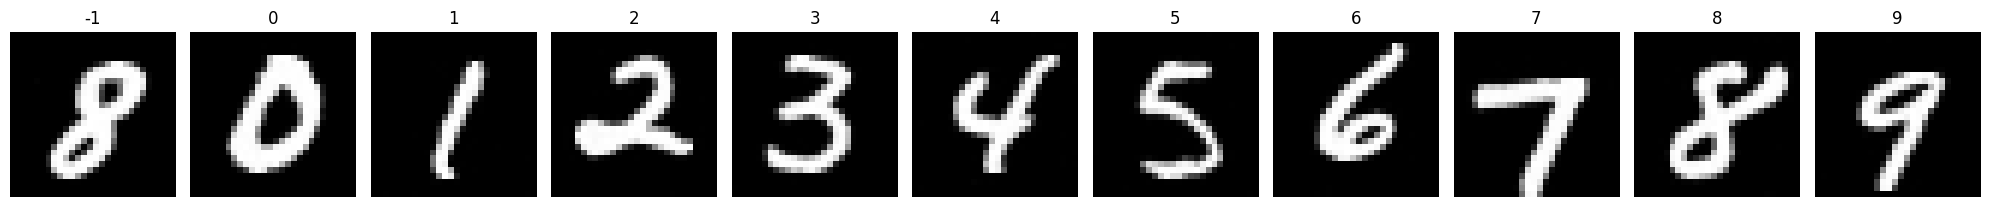

Epoch 206/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1942 - learning_rate: 2.2330e-04


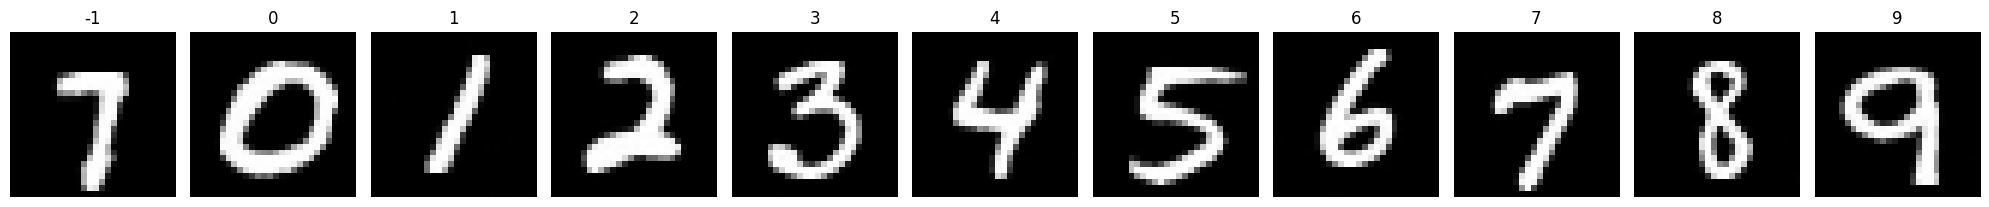

Epoch 207/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1958 - learning_rate: 2.1896e-04


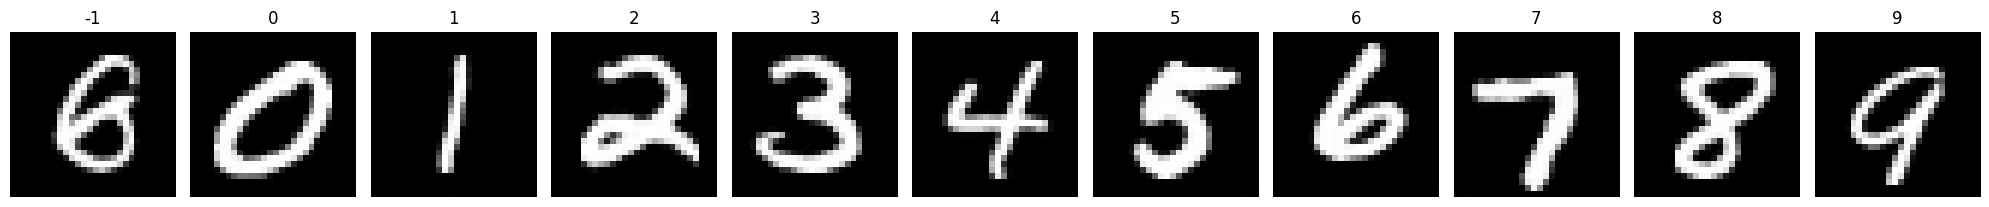

Epoch 208/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0225 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.2019 - learning_rate: 2.1464e-04


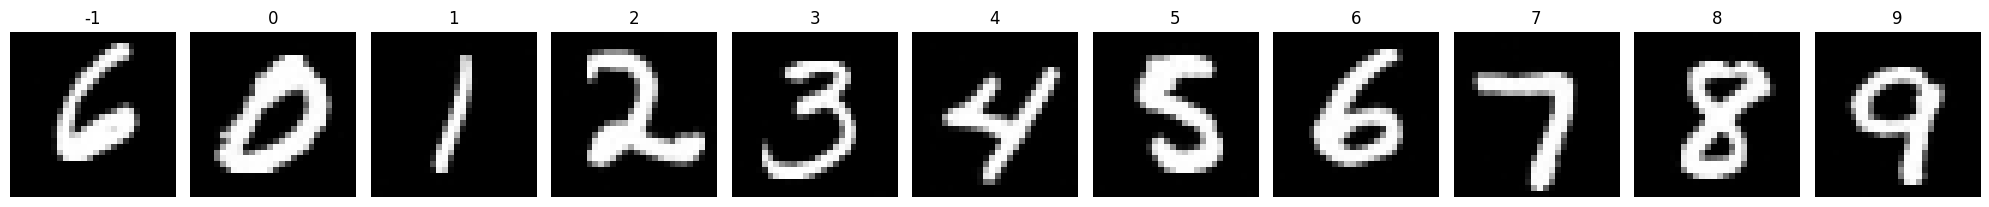

Epoch 209/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.2040 - learning_rate: 2.1036e-04


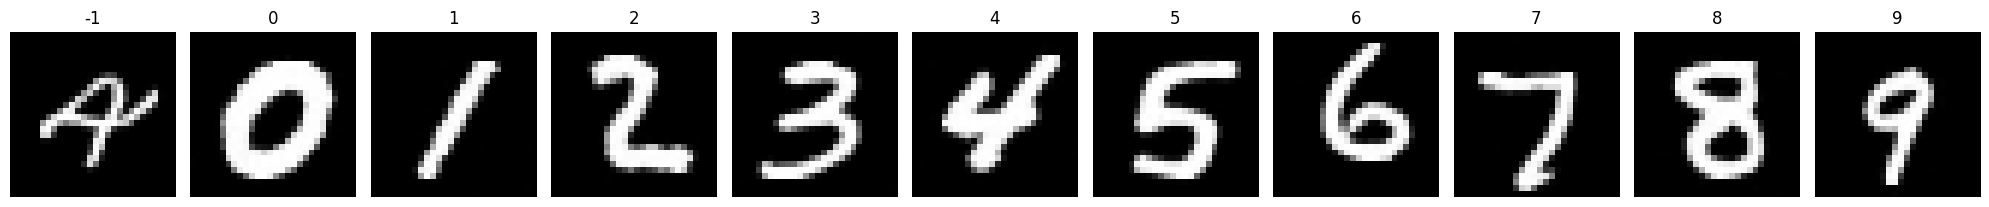

Epoch 210/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0226 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1926 - learning_rate: 2.0611e-04


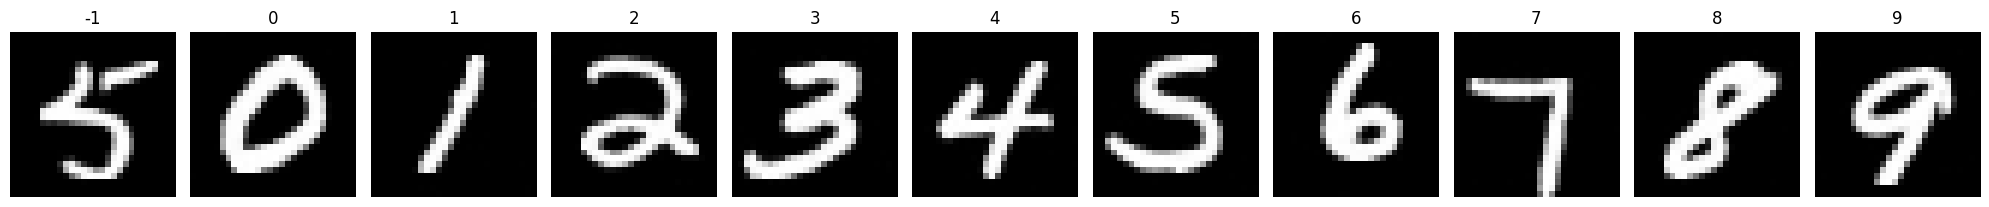

Epoch 211/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0224 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1974 - learning_rate: 2.0189e-04


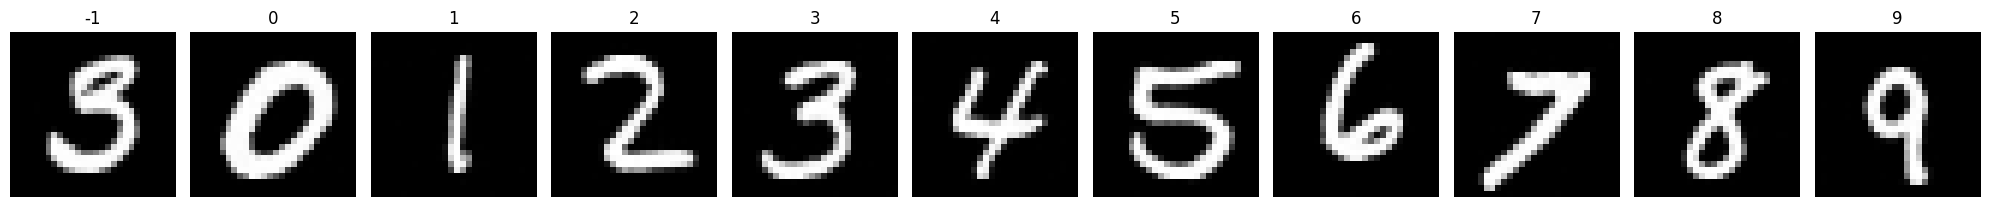

Epoch 212/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1991 - learning_rate: 1.9770e-04


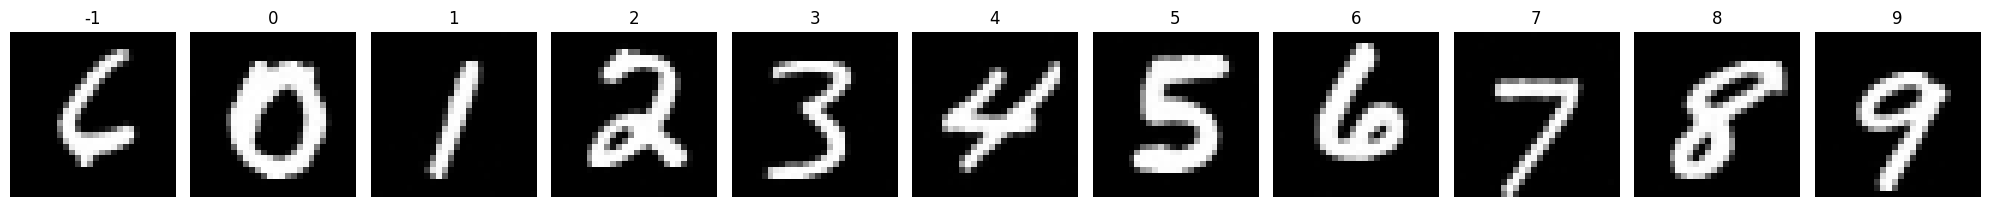

Epoch 213/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.2009 - learning_rate: 1.9355e-04


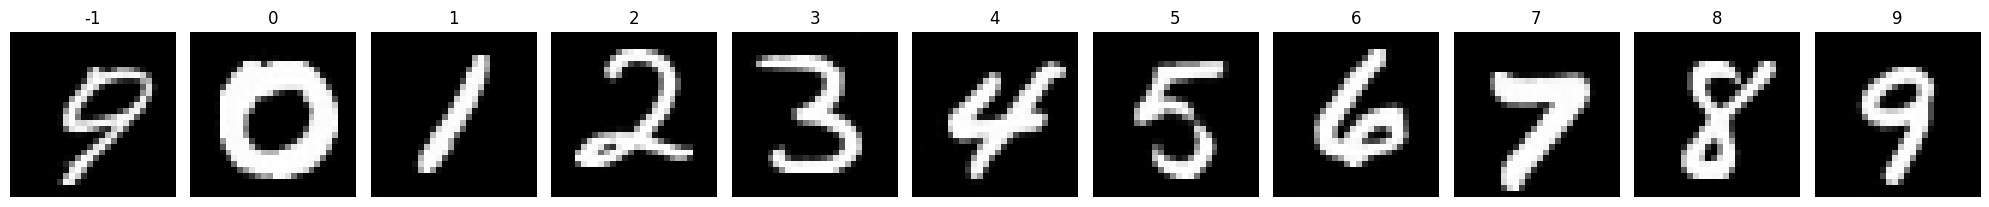

Epoch 214/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0224 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1964 - learning_rate: 1.8943e-04


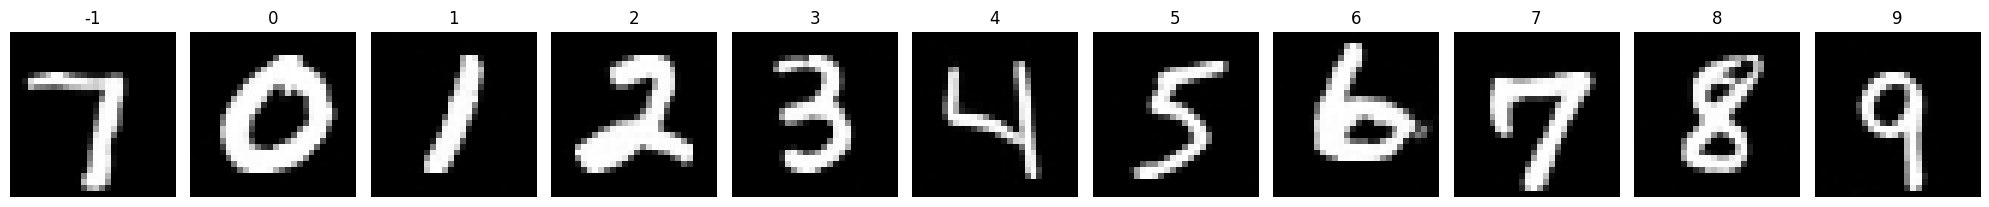

Epoch 215/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1990 - learning_rate: 1.8534e-04


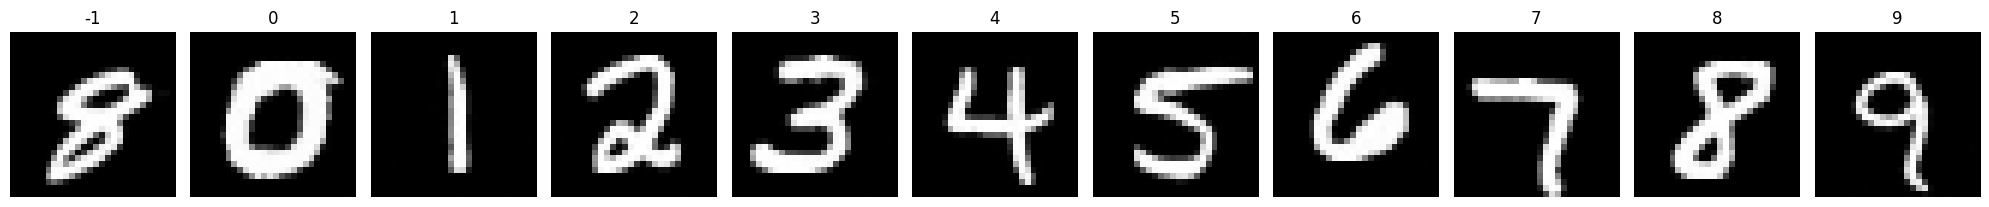

Epoch 216/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1958 - learning_rate: 1.8129e-04


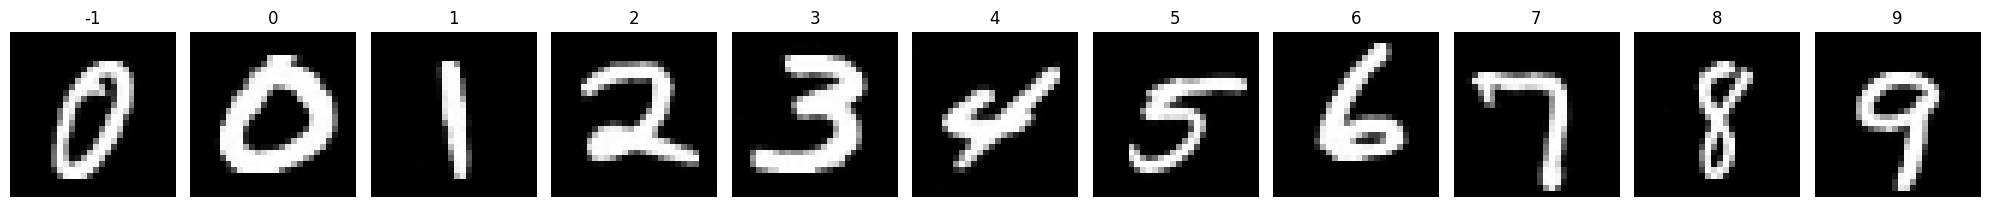

Epoch 217/300
468/468 [==============================] - 117s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.1989 - learning_rate: 1.7727e-04


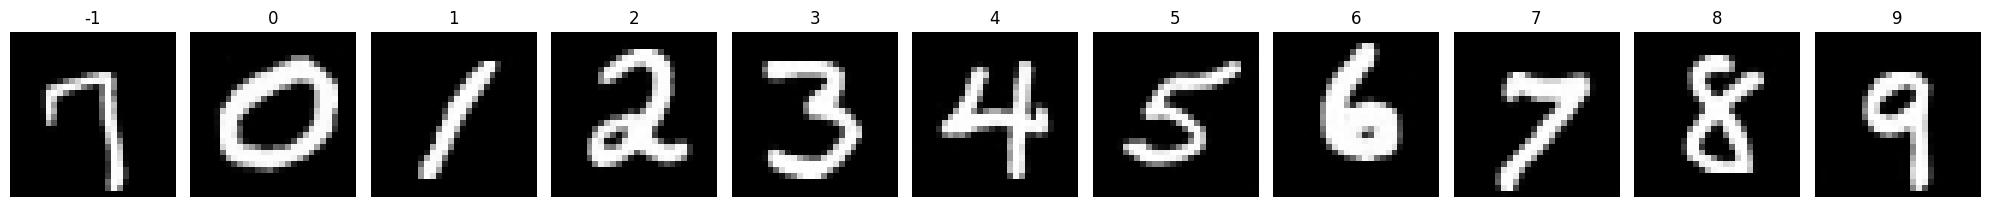

Epoch 218/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0225 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.2039 - learning_rate: 1.7329e-04


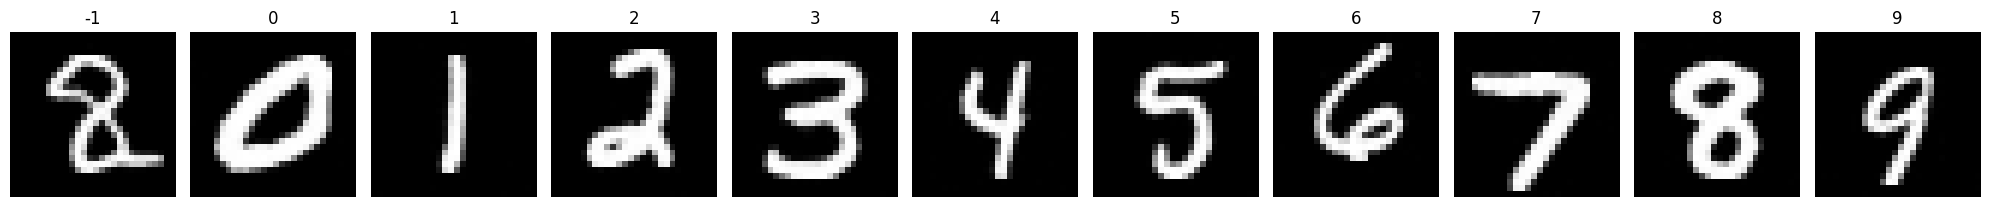

Epoch 219/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1959 - learning_rate: 1.6934e-04


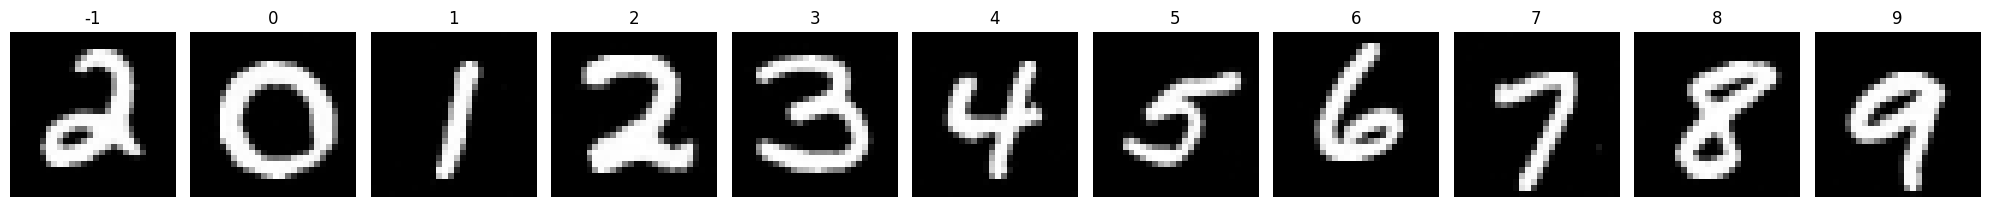

Epoch 220/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0223 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1962 - learning_rate: 1.6543e-04


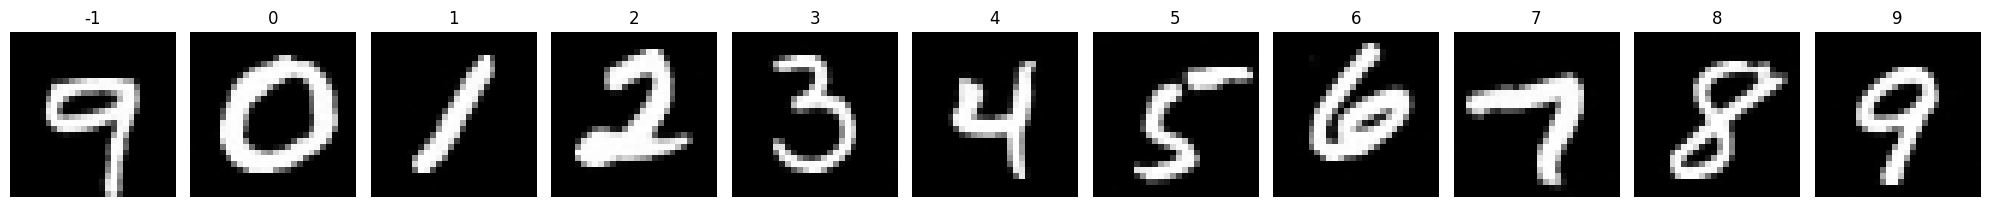

Epoch 221/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0224 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1962 - learning_rate: 1.6156e-04


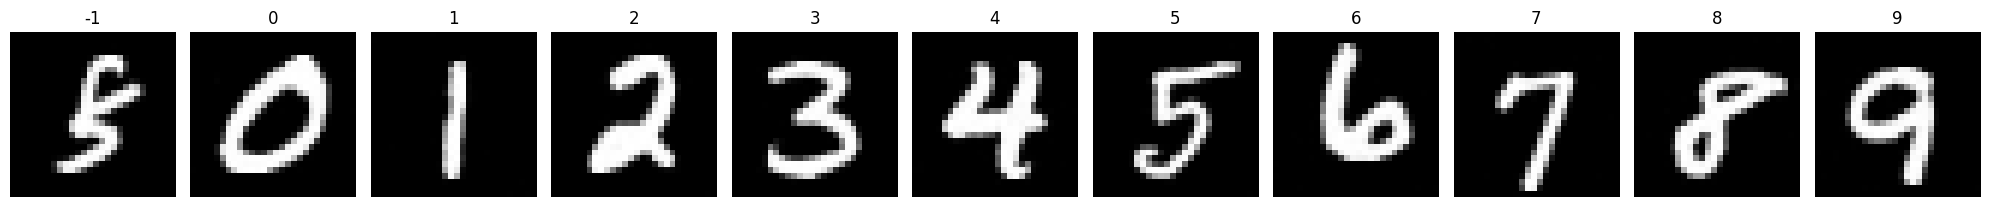

Epoch 222/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0225 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1947 - learning_rate: 1.5773e-04


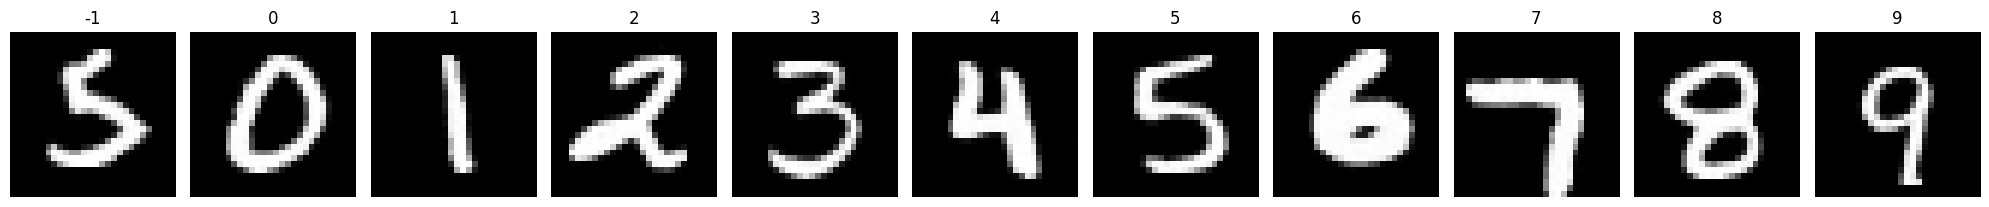

Epoch 223/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.2011 - learning_rate: 1.5393e-04


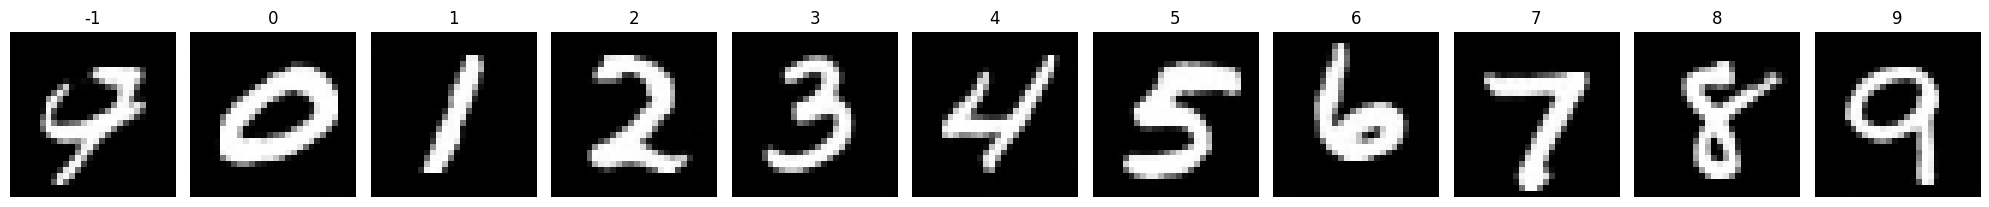

Epoch 224/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0224 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1958 - learning_rate: 1.5017e-04


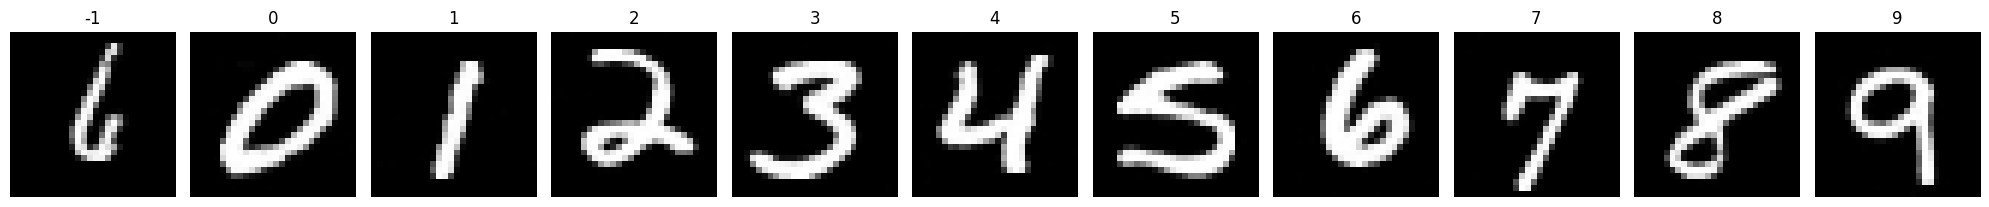

Epoch 225/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0224 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1953 - learning_rate: 1.4645e-04


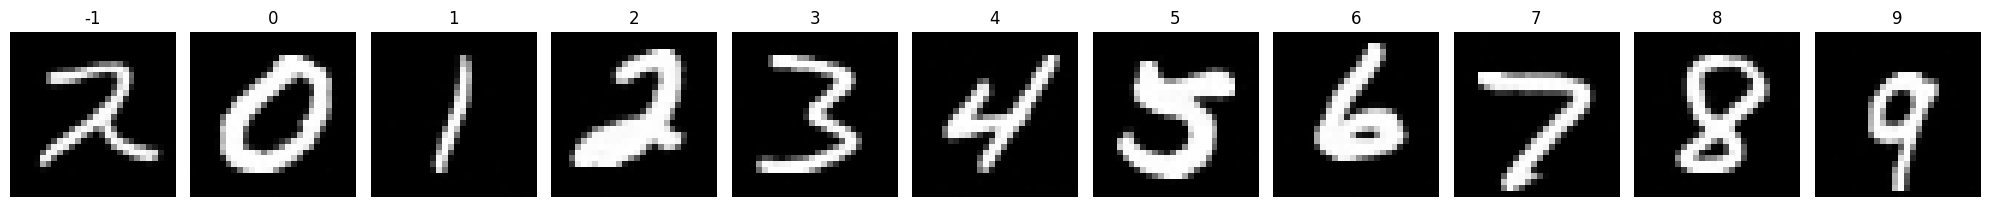

Epoch 226/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1940 - learning_rate: 1.4276e-04


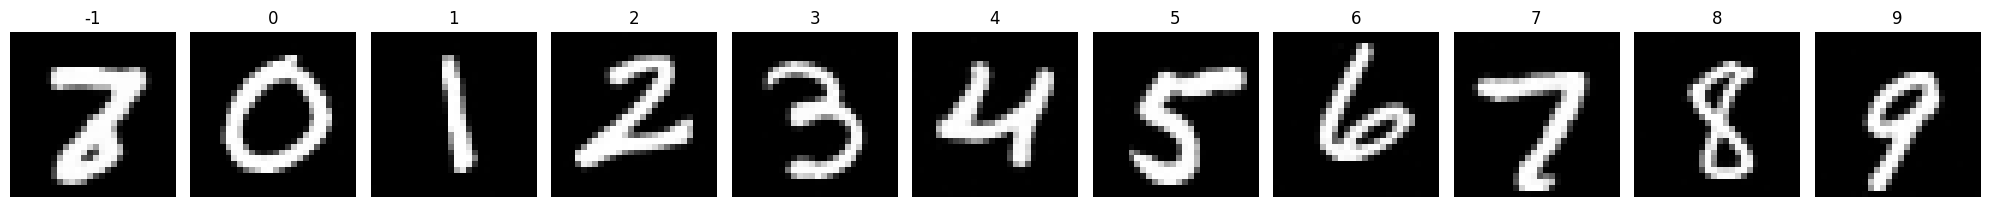

Epoch 227/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0223 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.2005 - learning_rate: 1.3912e-04


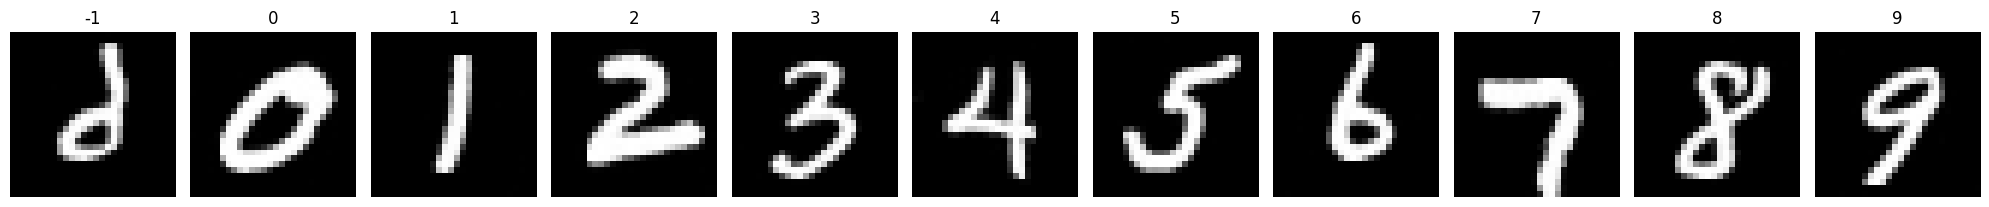

Epoch 228/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0224 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1939 - learning_rate: 1.3552e-04


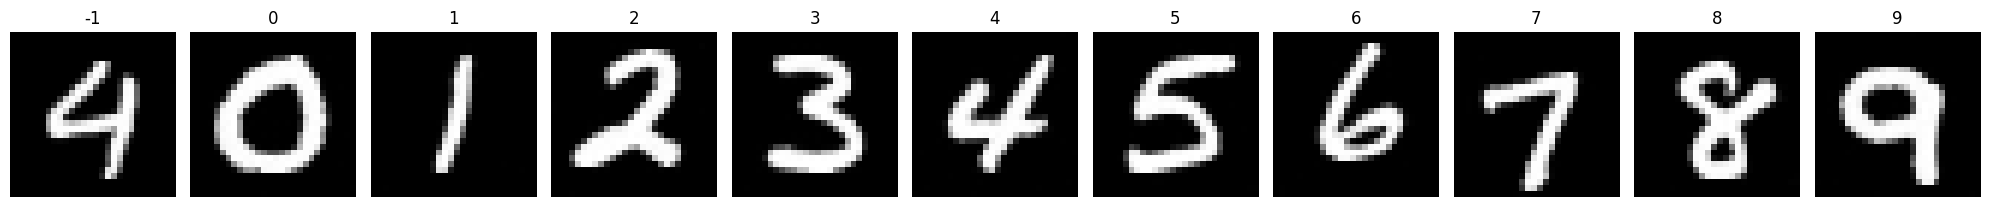

Epoch 229/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1901 - learning_rate: 1.3195e-04


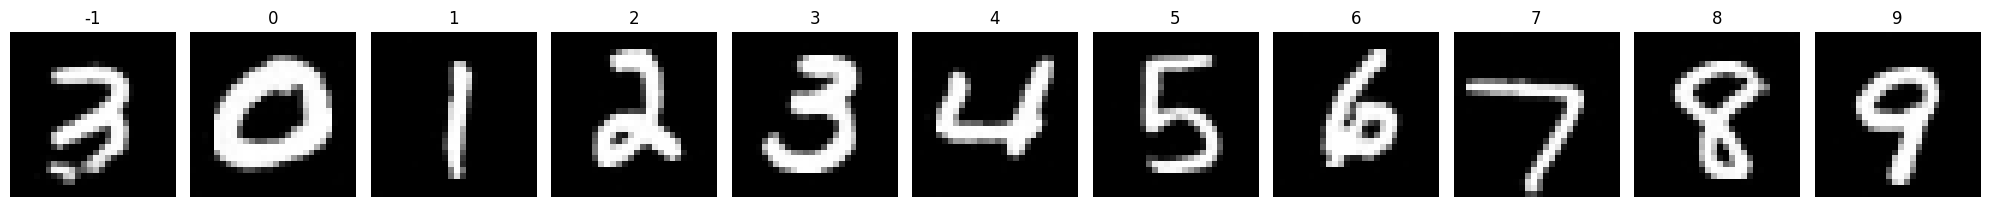

Epoch 230/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0224 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.2038 - learning_rate: 1.2843e-04


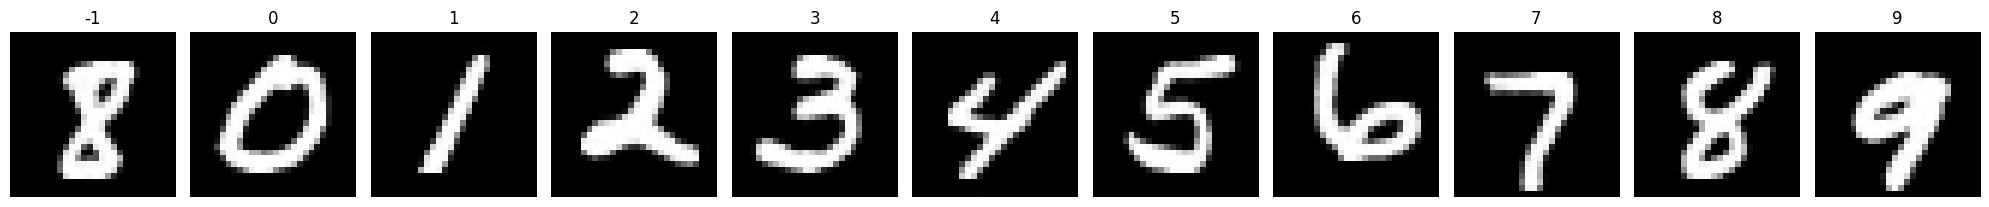

Epoch 231/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1962 - learning_rate: 1.2494e-04


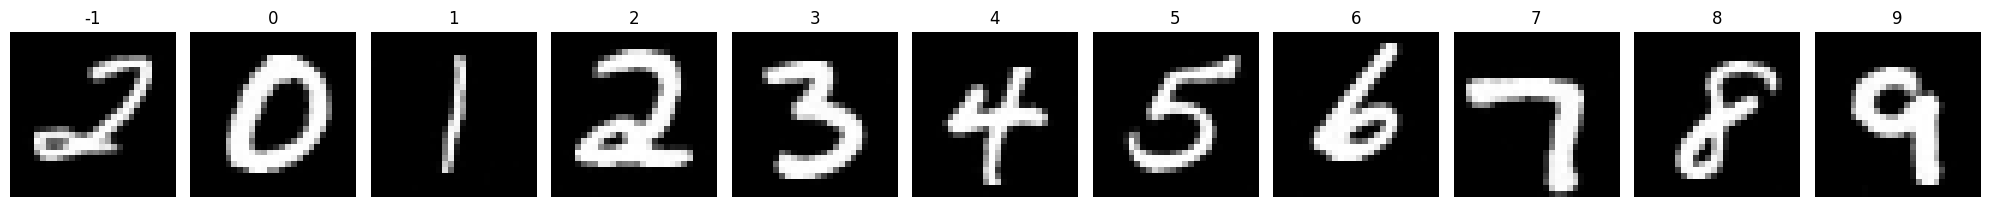

Epoch 232/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1926 - learning_rate: 1.2150e-04


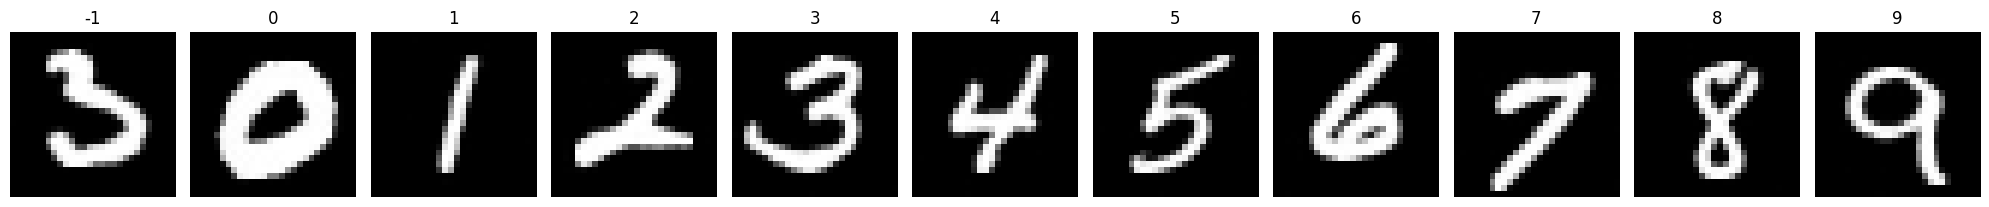

Epoch 233/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0224 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1954 - learning_rate: 1.1810e-04


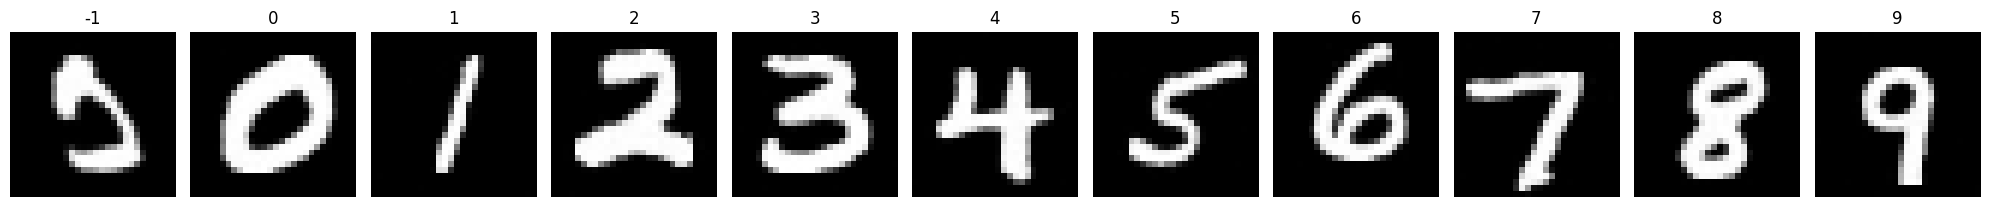

Epoch 234/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.1952 - learning_rate: 1.1474e-04


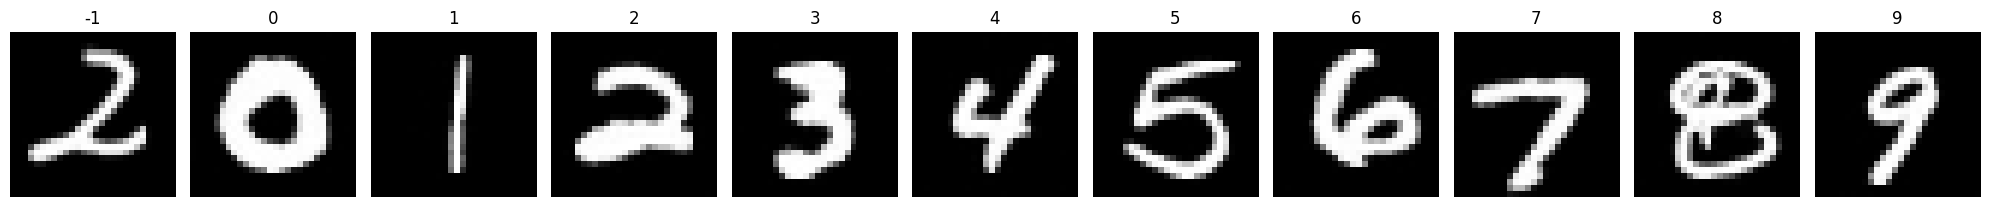

Epoch 235/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0223 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.2017 - learning_rate: 1.1143e-04


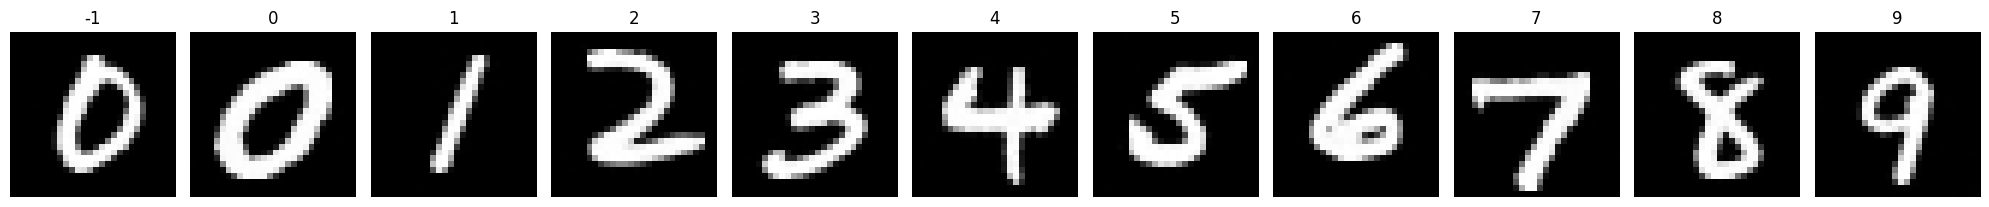

Epoch 236/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0222 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.1969 - learning_rate: 1.0815e-04


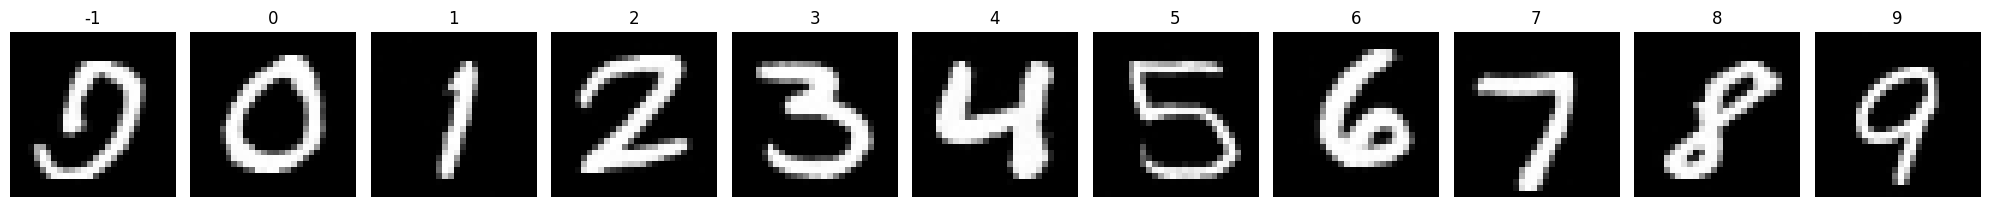

Epoch 237/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0222 - val_loss: 0.0336 - val_noise_loss: 0.0336 - val_image_loss: 0.1990 - learning_rate: 1.0492e-04


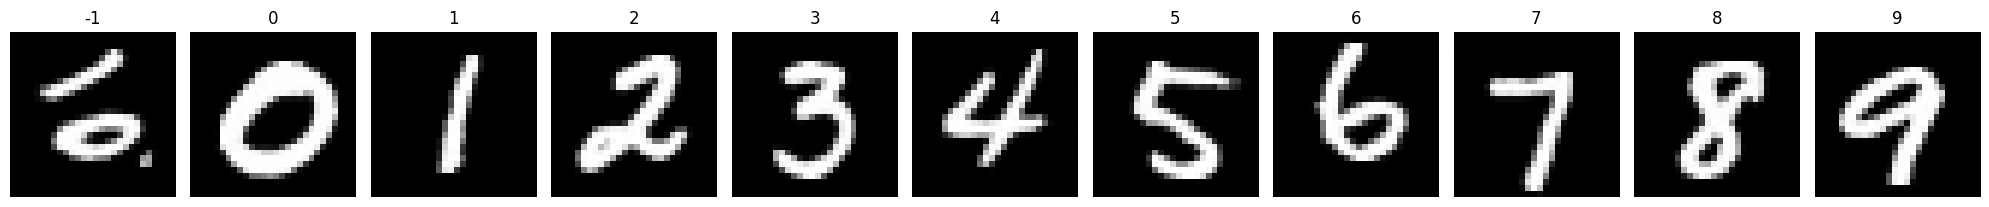

Epoch 238/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0223 - val_loss: 0.0335 - val_noise_loss: 0.0335 - val_image_loss: 0.1950 - learning_rate: 1.0174e-04


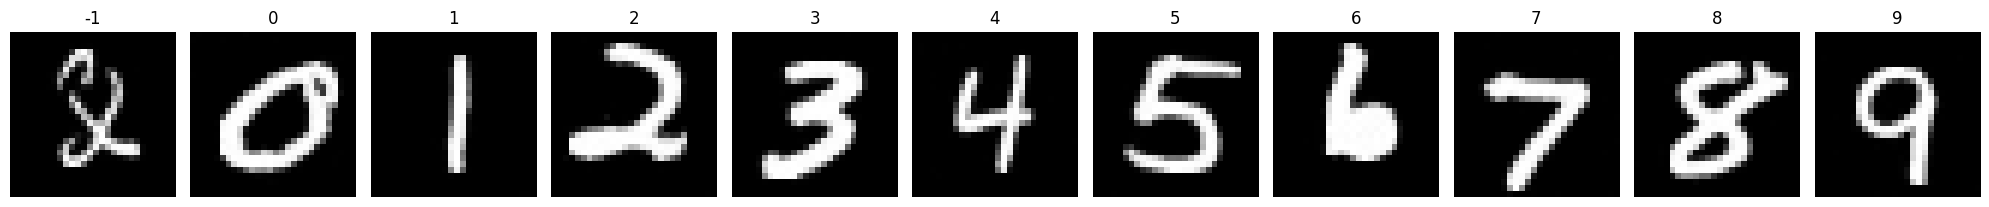

Epoch 239/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0223 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1917 - learning_rate: 9.8591e-05


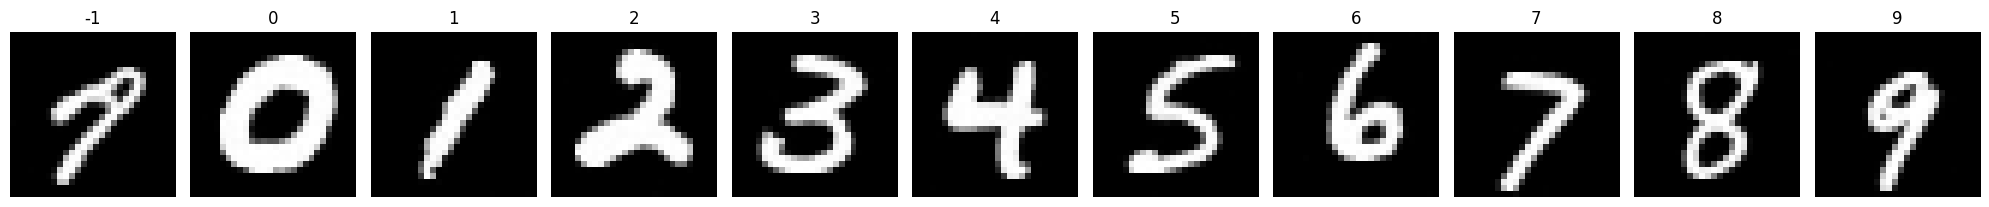

Epoch 240/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0224 - val_loss: 0.0333 - val_noise_loss: 0.0333 - val_image_loss: 0.1950 - learning_rate: 9.5491e-05


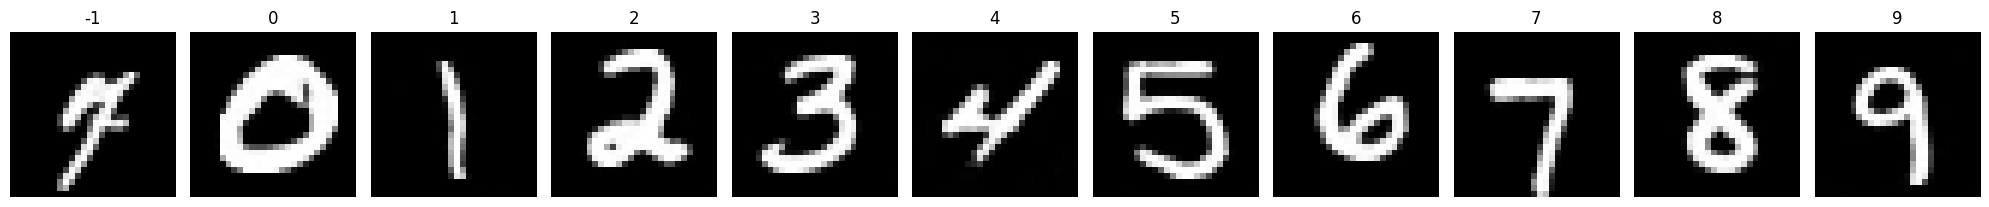

Epoch 241/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.1946 - learning_rate: 9.2436e-05


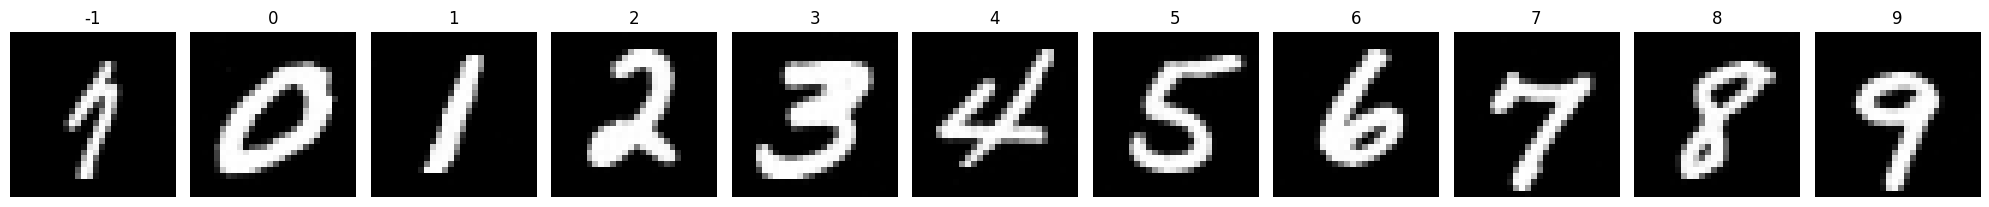

Epoch 242/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0223 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1917 - learning_rate: 8.9425e-05


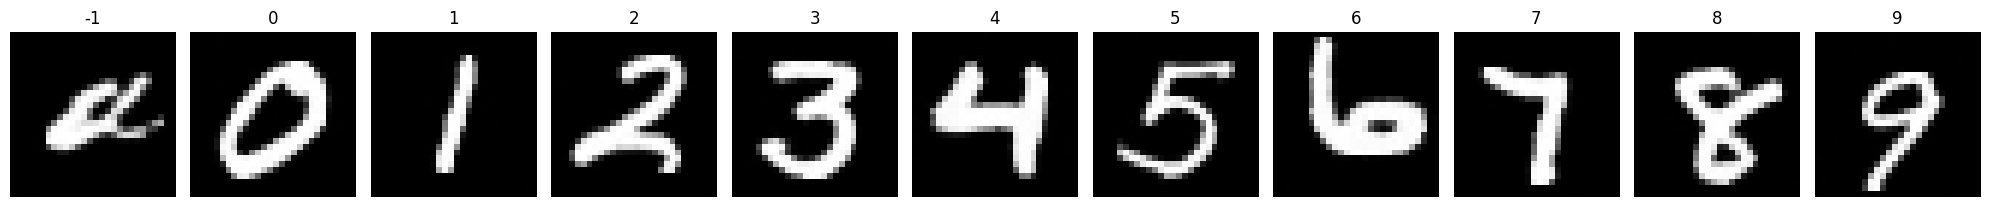

Epoch 243/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0223 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1935 - learning_rate: 8.6460e-05


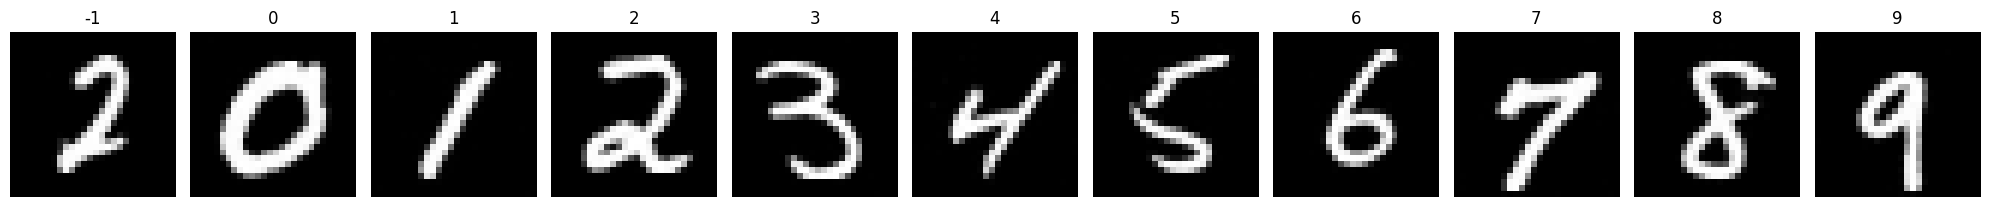

Epoch 244/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1913 - learning_rate: 8.3539e-05


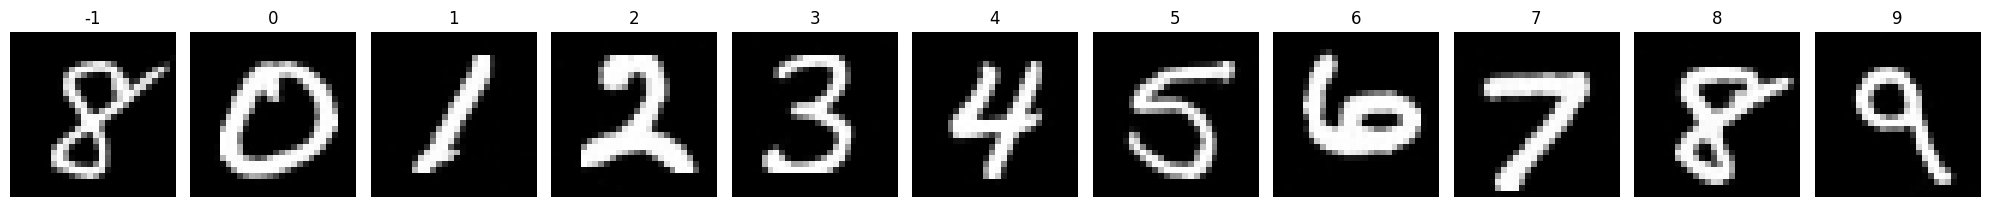

Epoch 245/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1959 - learning_rate: 8.0665e-05


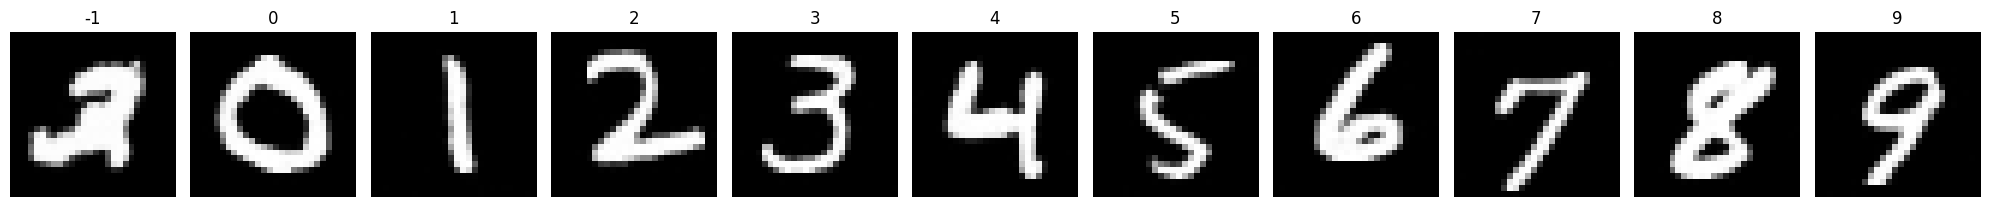

Epoch 246/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1970 - learning_rate: 7.7836e-05


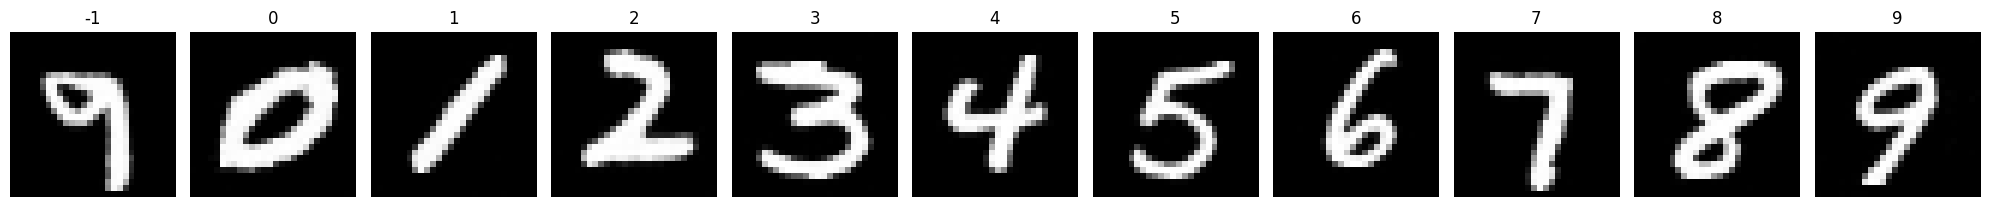

Epoch 247/300
468/468 [==============================] - 116s 249ms/step - noise_loss: 0.0223 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1933 - learning_rate: 7.5054e-05


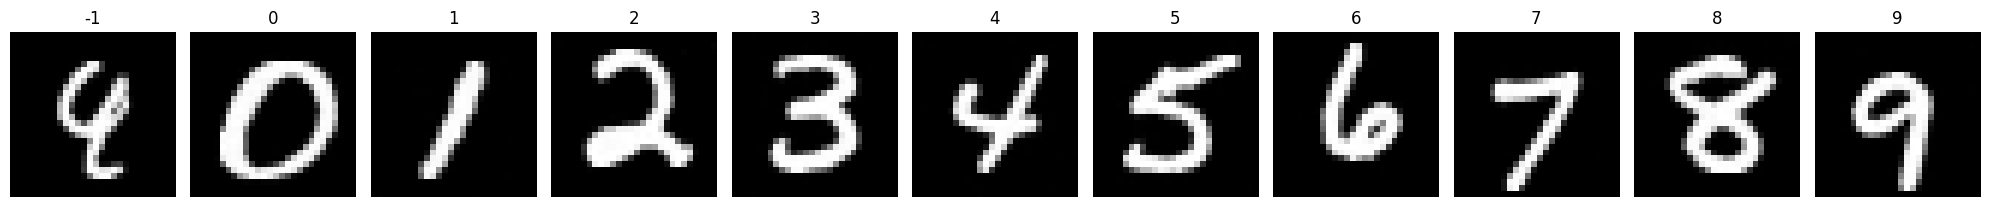

Epoch 248/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0223 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1955 - learning_rate: 7.2318e-05


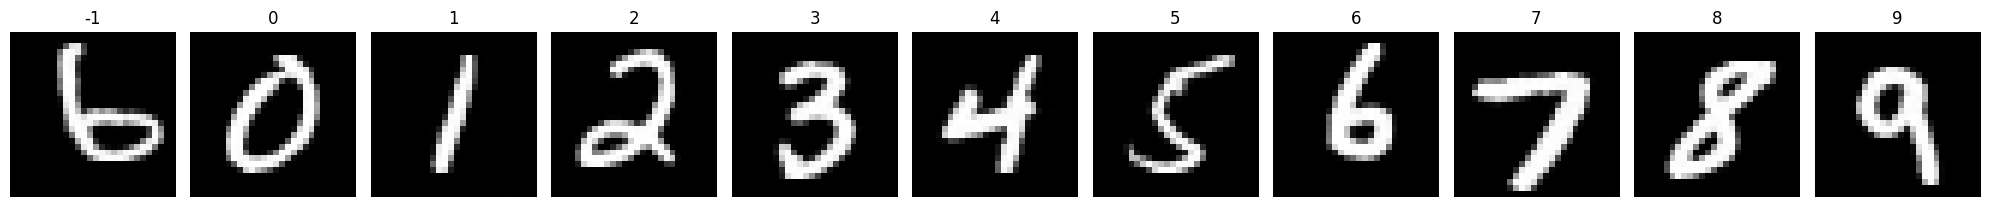

Epoch 249/300
468/468 [==============================] - 117s 249ms/step - noise_loss: 0.0222 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1857 - learning_rate: 6.9629e-05


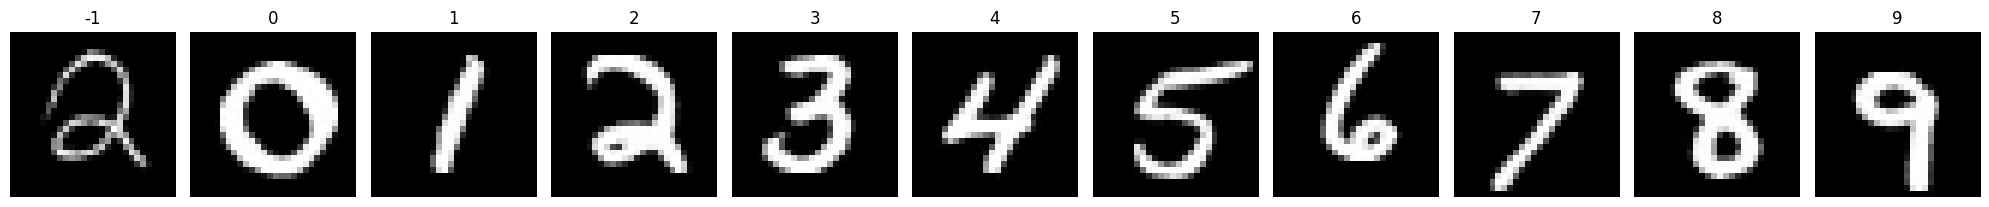

Epoch 250/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1990 - learning_rate: 6.6987e-05


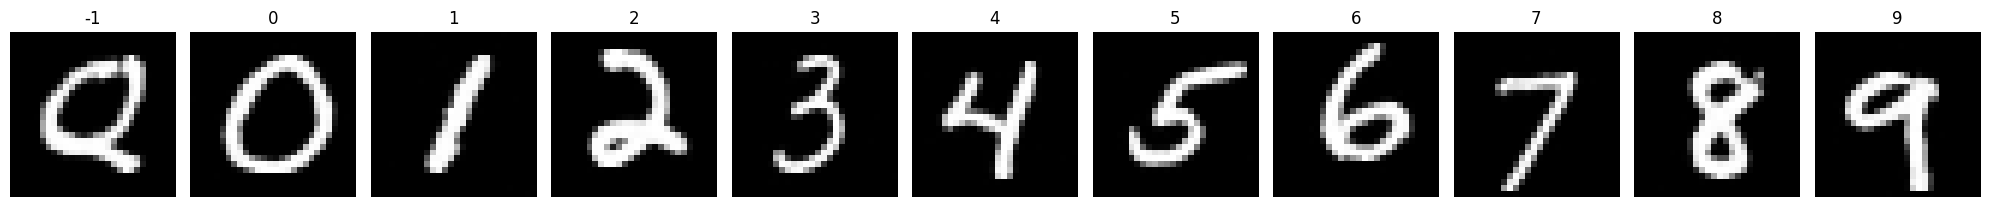

Epoch 251/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1890 - learning_rate: 6.4393e-05


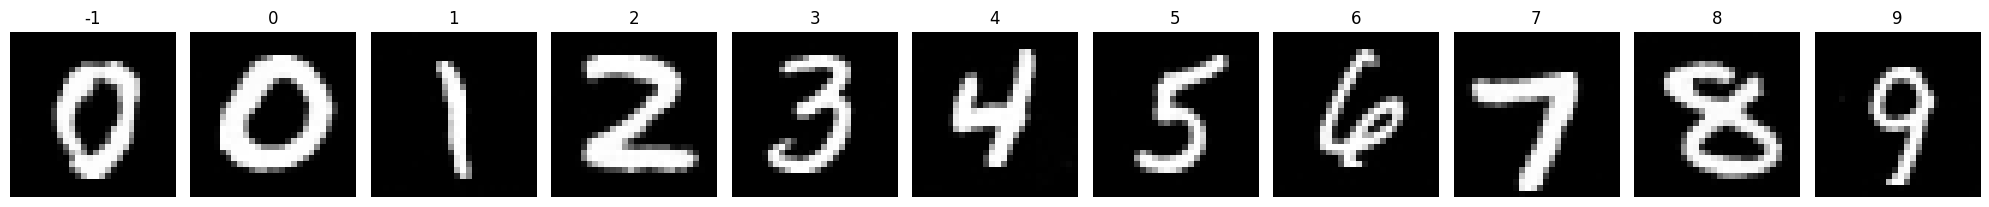

Epoch 252/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1926 - learning_rate: 6.1847e-05


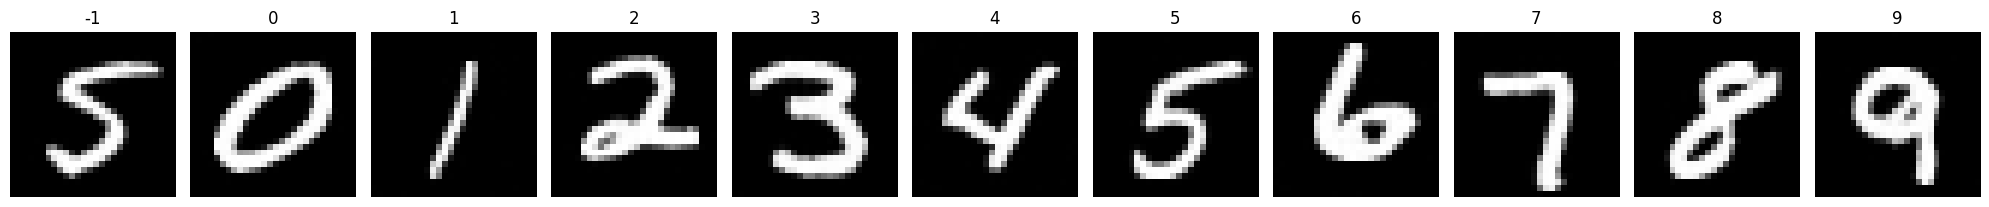

Epoch 253/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1951 - learning_rate: 5.9348e-05


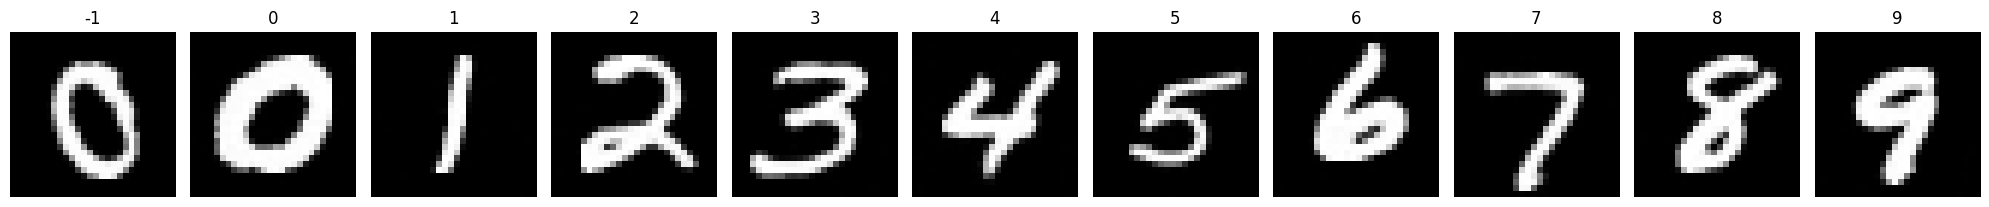

Epoch 254/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1981 - learning_rate: 5.6898e-05


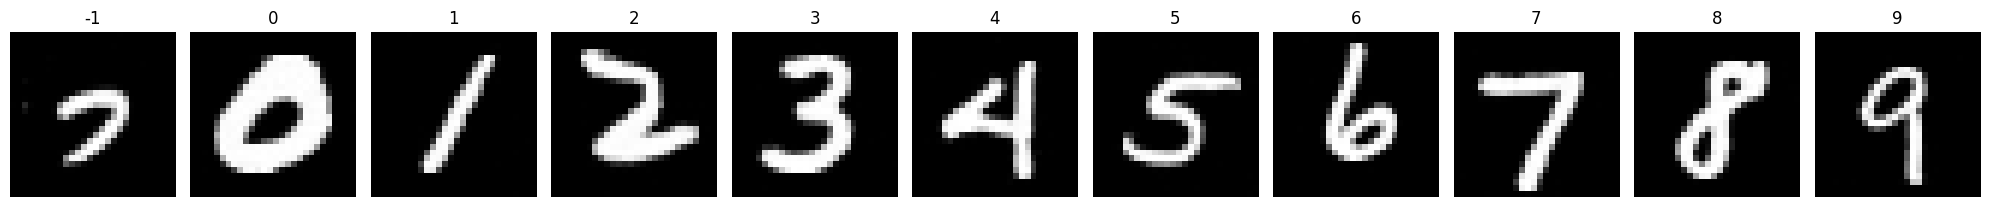

Epoch 255/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1990 - learning_rate: 5.4497e-05


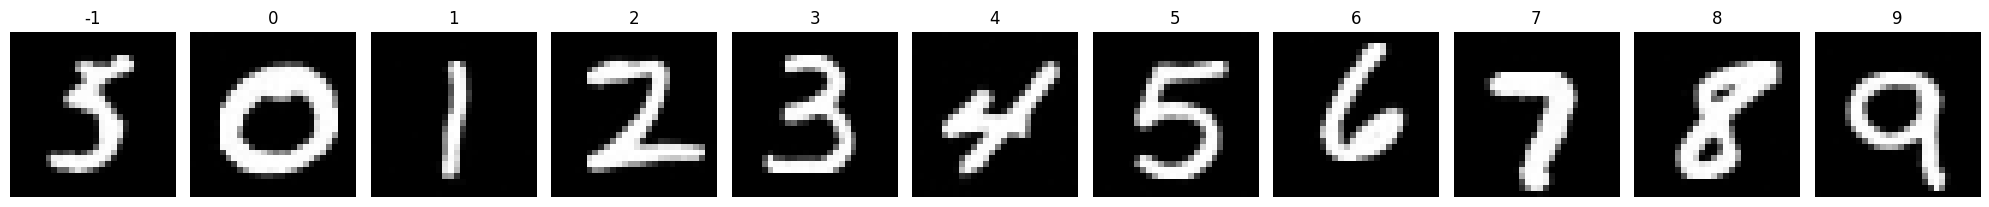

Epoch 256/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1953 - learning_rate: 5.2144e-05


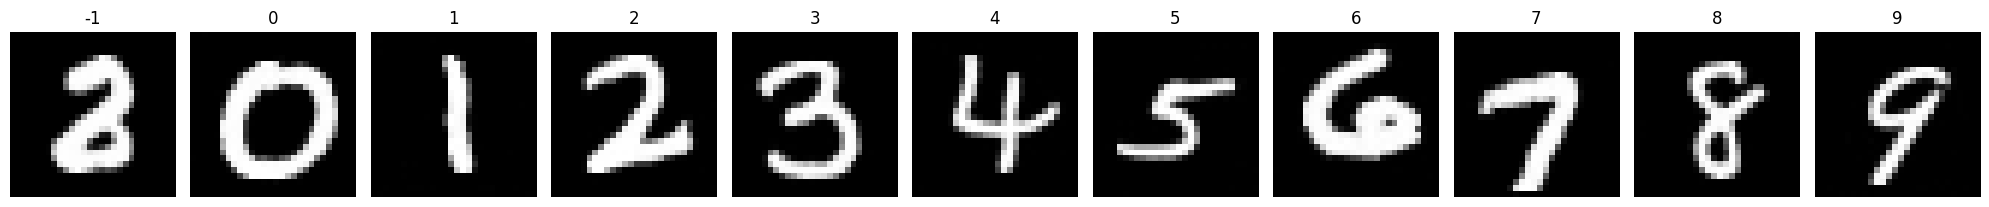

Epoch 257/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1963 - learning_rate: 4.9841e-05


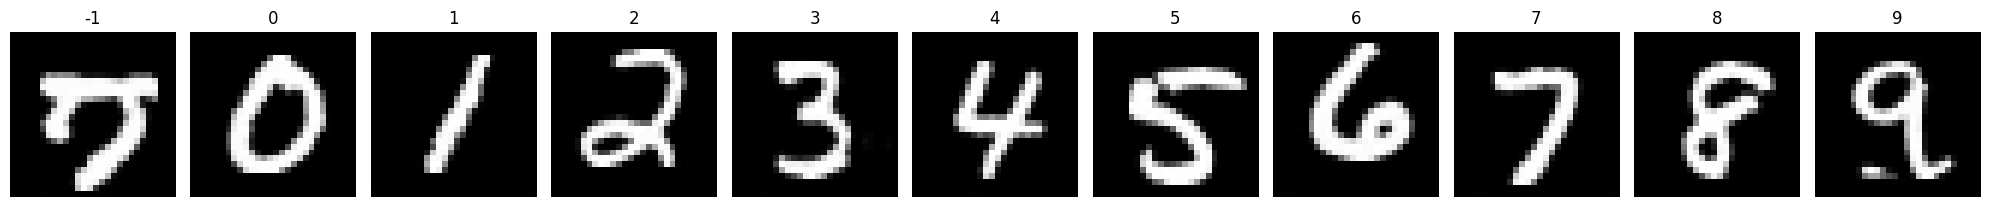

Epoch 258/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1980 - learning_rate: 4.7586e-05


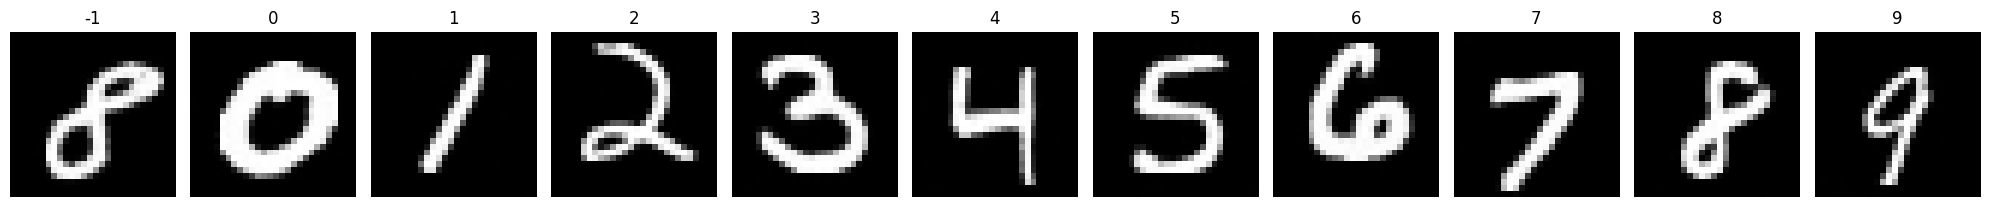

Epoch 259/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1968 - learning_rate: 4.5382e-05


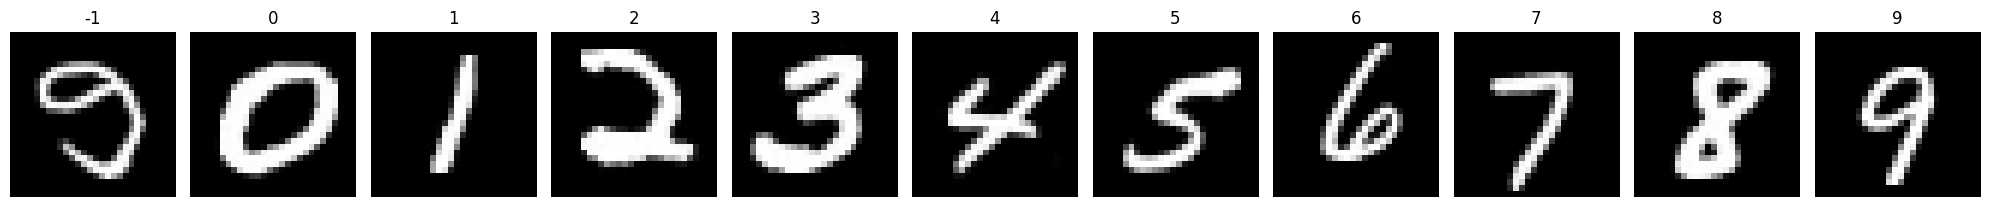

Epoch 260/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1951 - learning_rate: 4.3227e-05


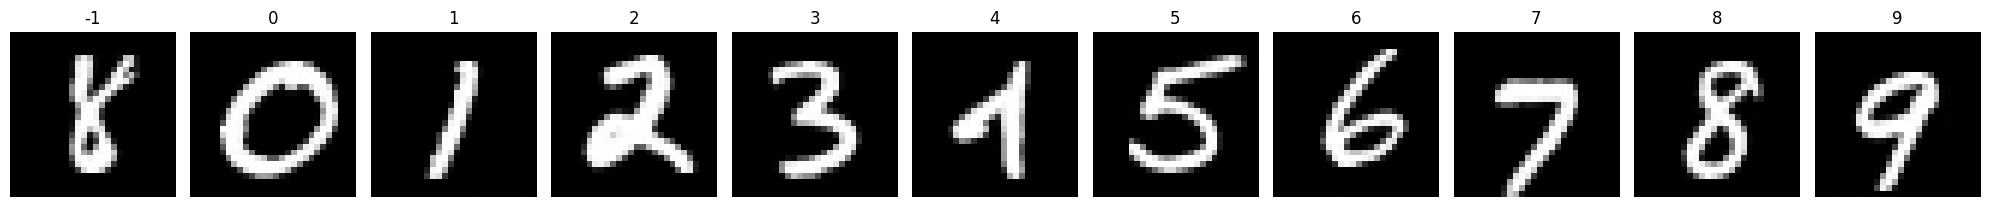

Epoch 261/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1879 - learning_rate: 4.1123e-05


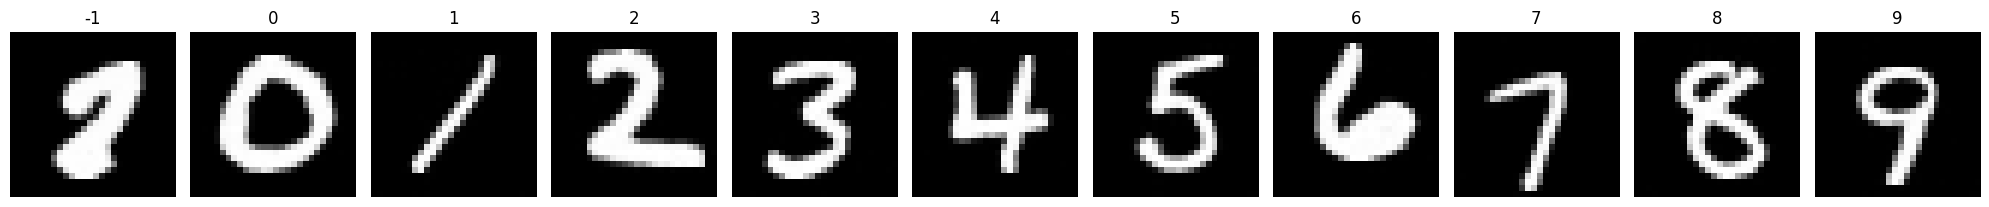

Epoch 262/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1943 - learning_rate: 3.9068e-05


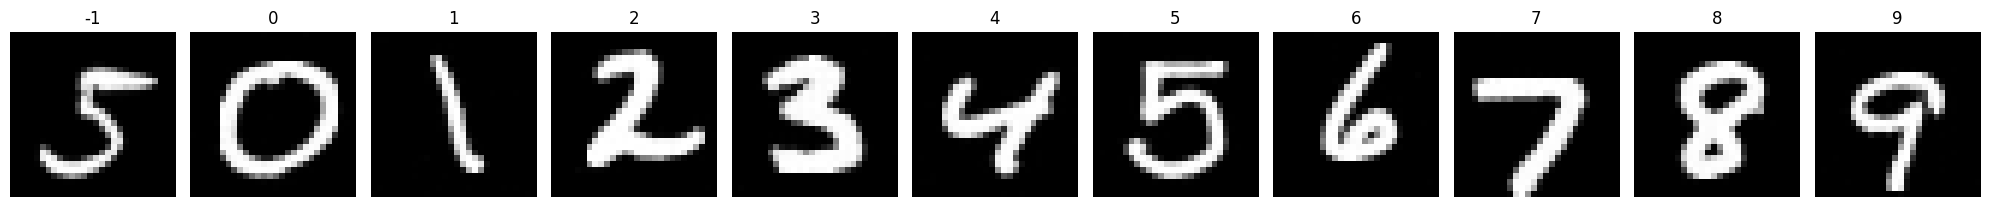

Epoch 263/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1950 - learning_rate: 3.7065e-05


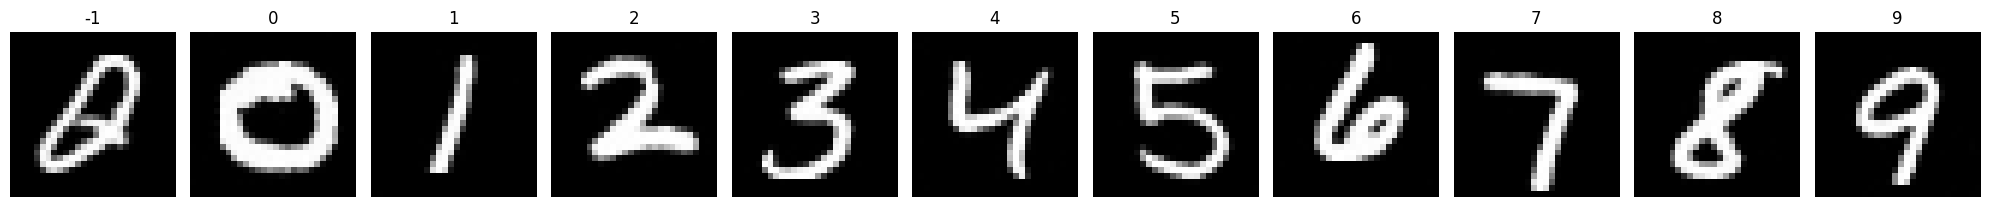

Epoch 264/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1907 - learning_rate: 3.5112e-05


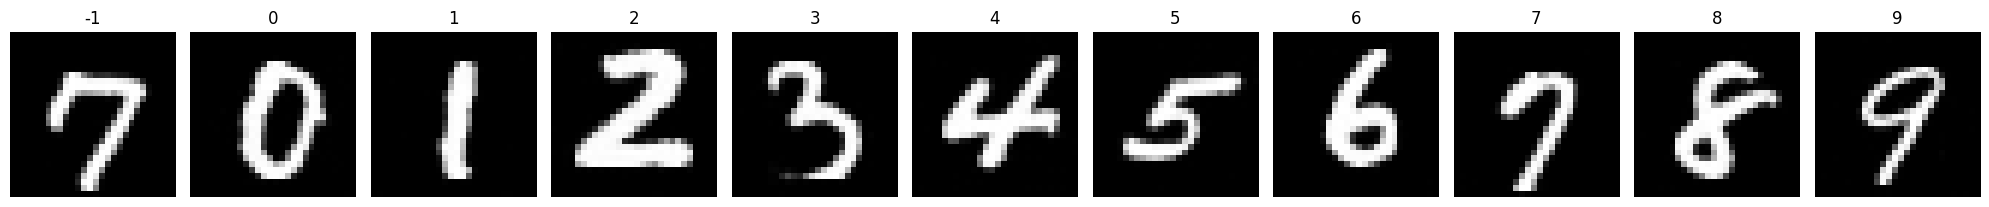

Epoch 265/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1942 - learning_rate: 3.3210e-05


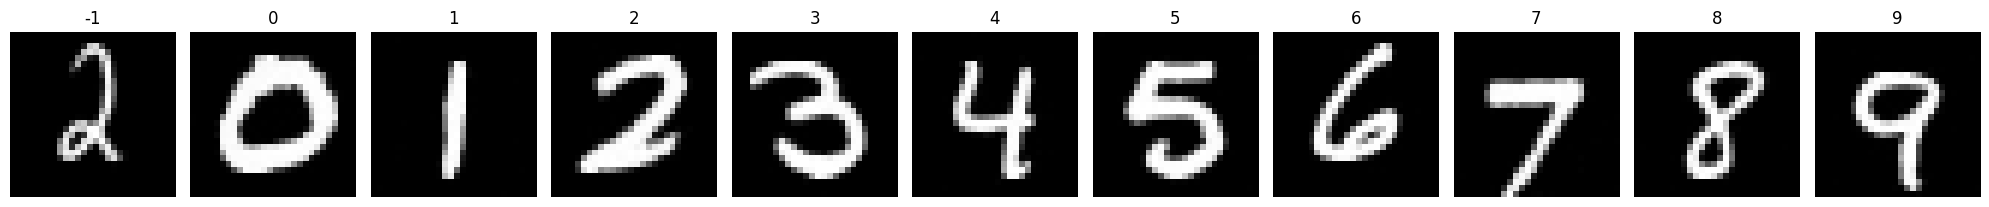

Epoch 266/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1956 - learning_rate: 3.1359e-05


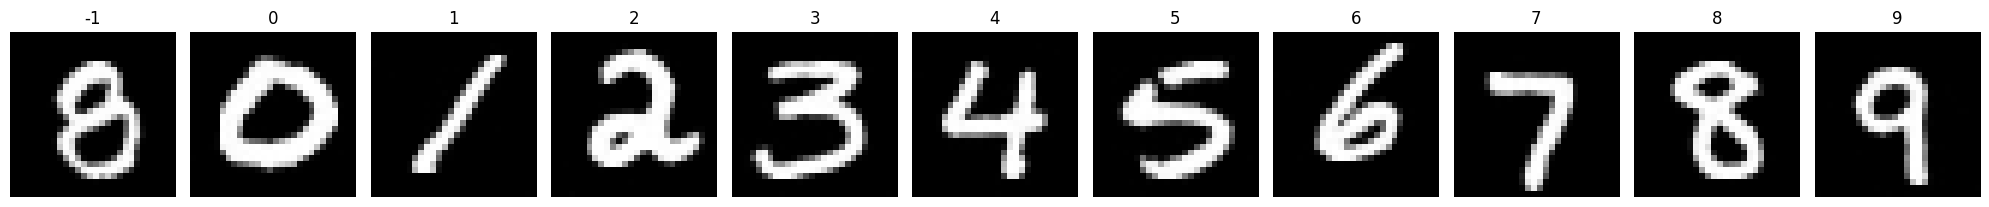

Epoch 267/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.1947 - learning_rate: 2.9560e-05


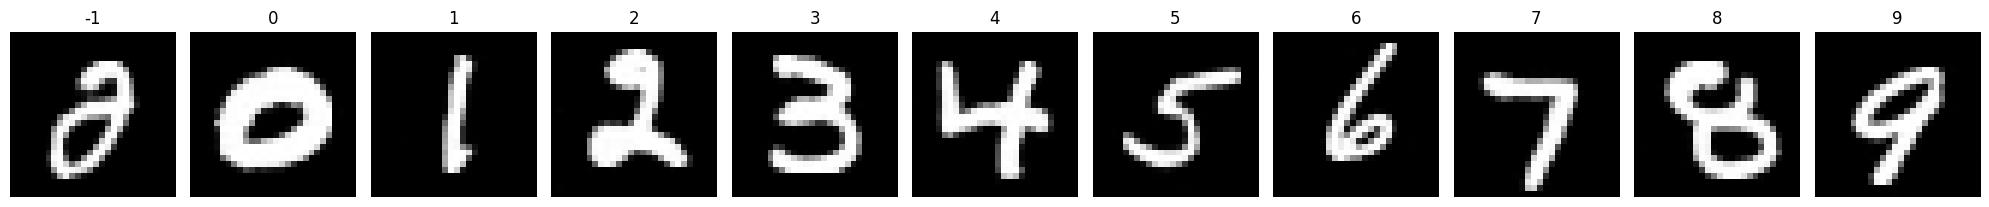

Epoch 268/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1931 - learning_rate: 2.7812e-05


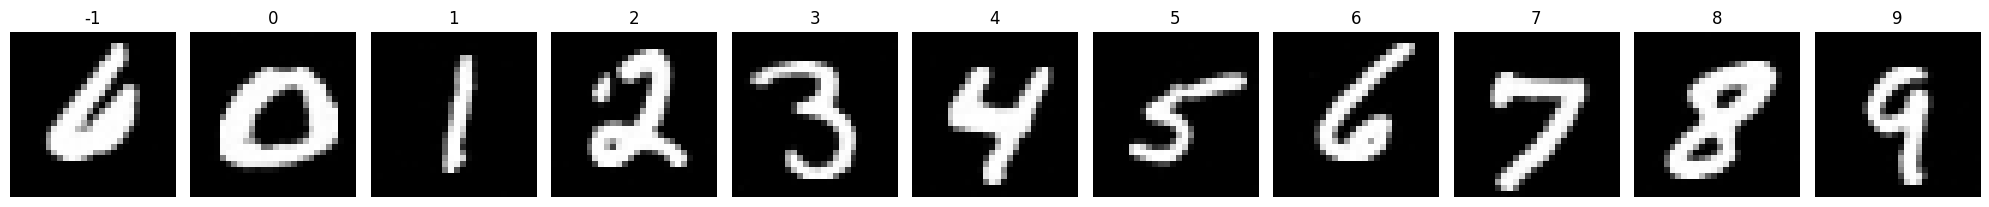

Epoch 269/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1924 - learning_rate: 2.6116e-05


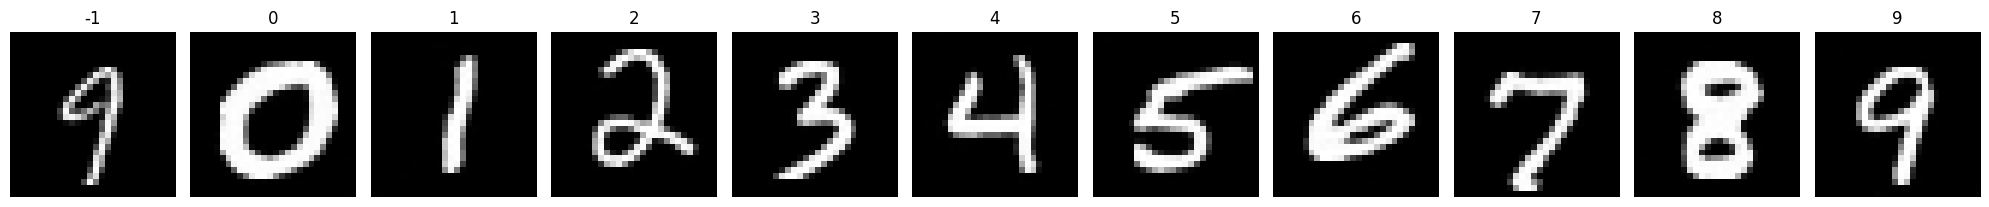

Epoch 270/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0333 - val_noise_loss: 0.0333 - val_image_loss: 0.1923 - learning_rate: 2.4472e-05


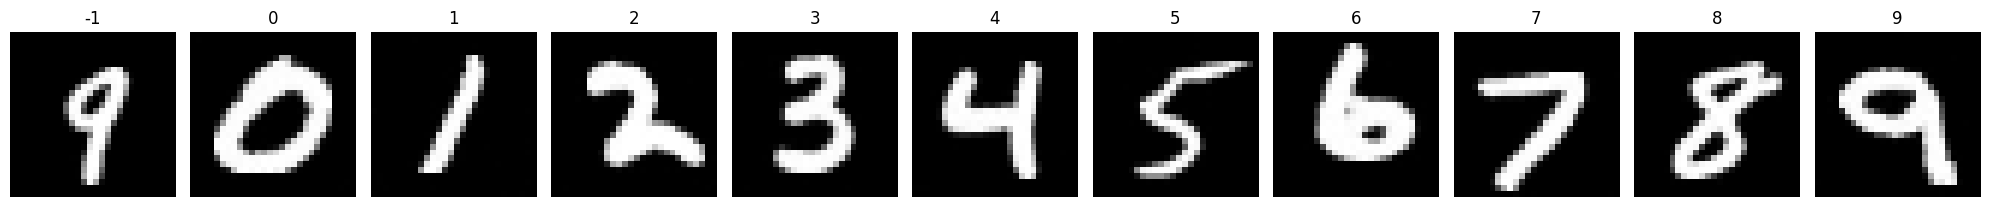

Epoch 271/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1942 - learning_rate: 2.2880e-05


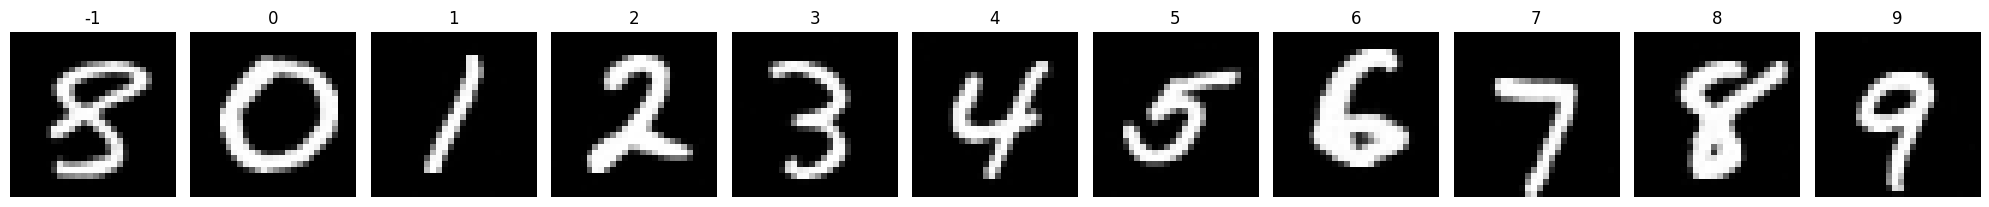

Epoch 272/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1983 - learning_rate: 2.1340e-05


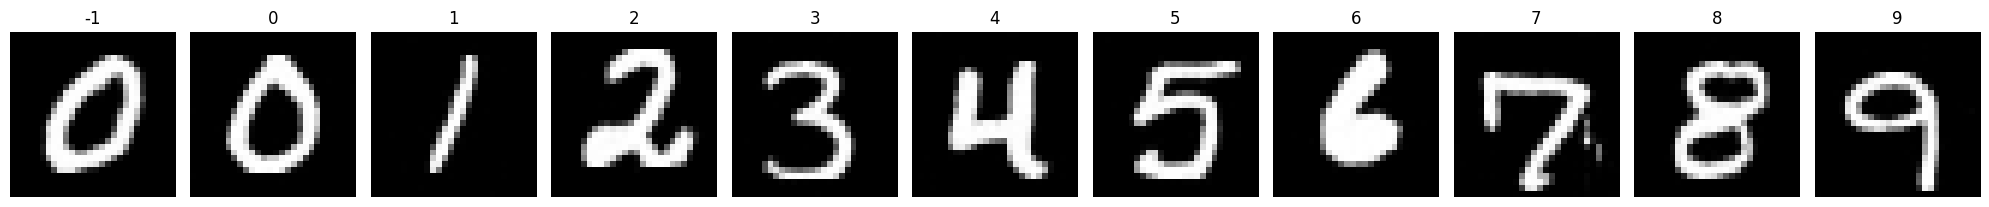

Epoch 273/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1977 - learning_rate: 1.9853e-05


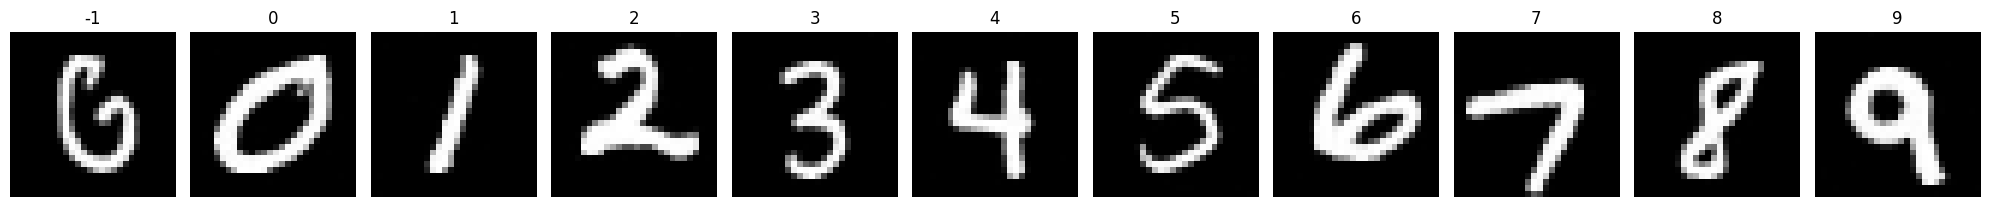

Epoch 274/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1918 - learning_rate: 1.8419e-05


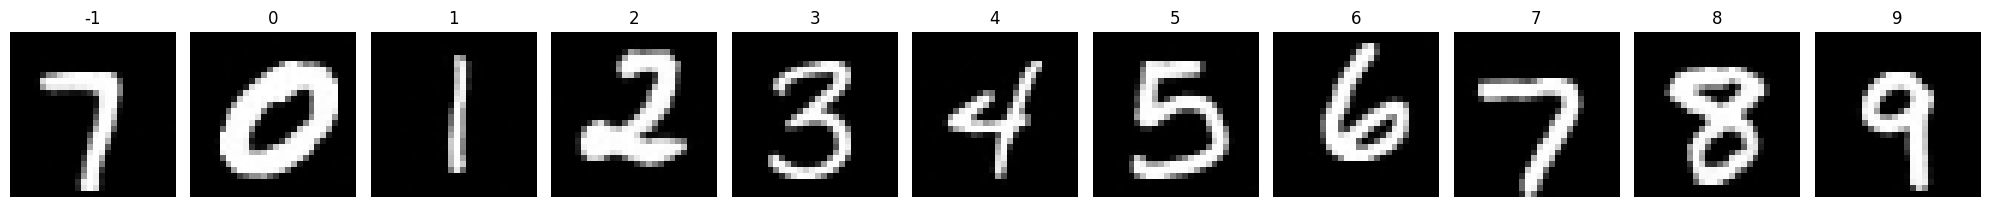

Epoch 275/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1958 - learning_rate: 1.7037e-05


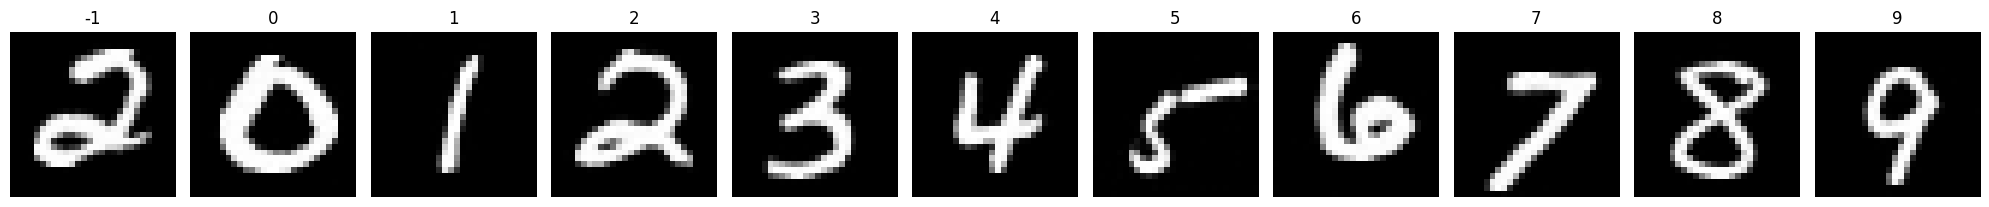

Epoch 276/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1940 - learning_rate: 1.5708e-05


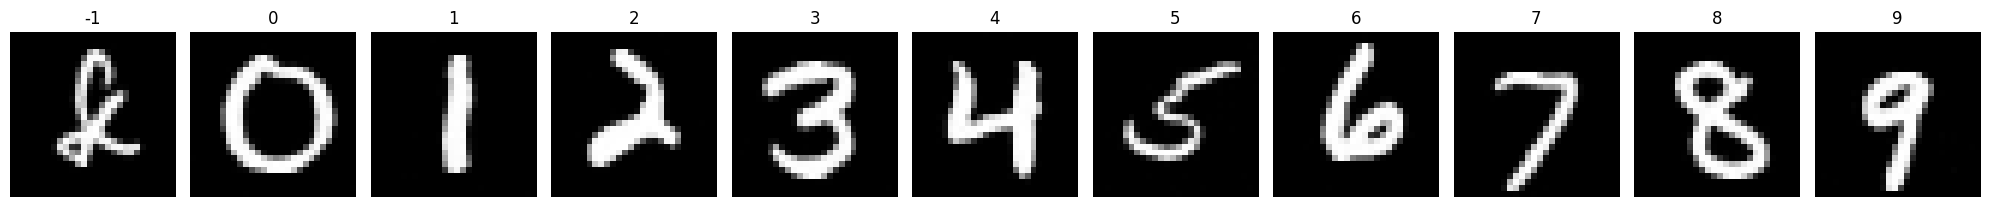

Epoch 277/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1967 - learning_rate: 1.4433e-05


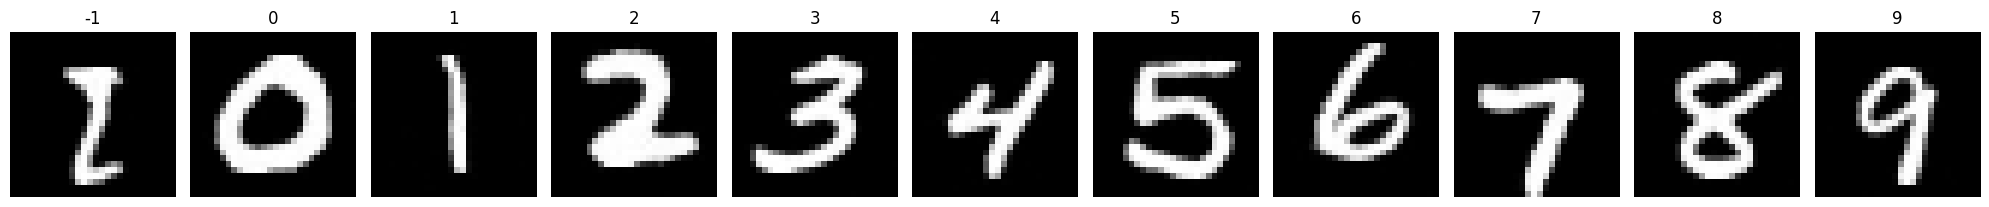

Epoch 278/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1962 - learning_rate: 1.3211e-05


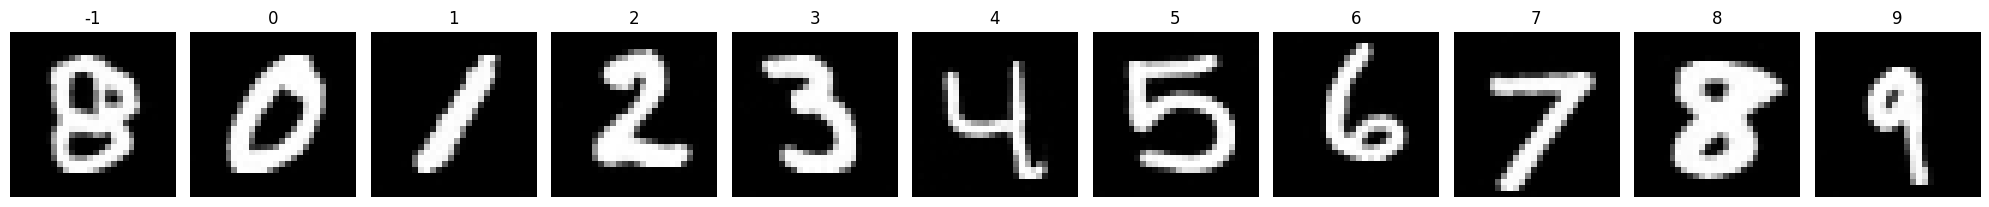

Epoch 279/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1926 - learning_rate: 1.2042e-05


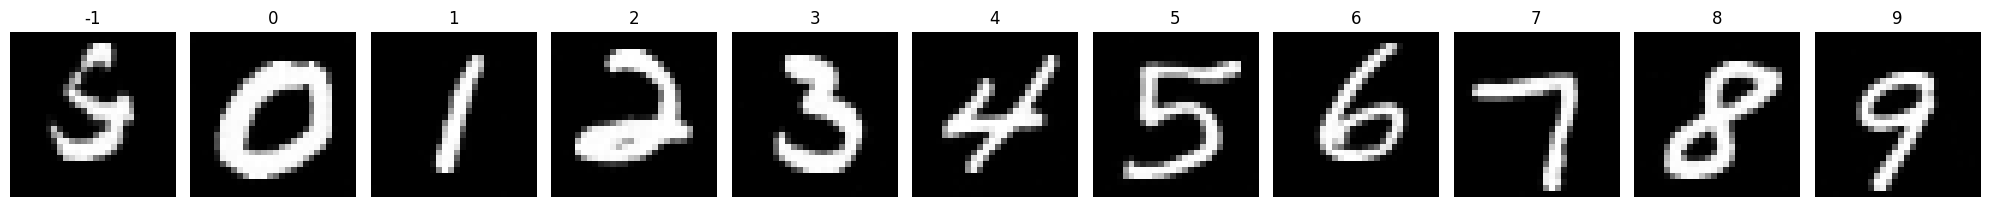

Epoch 280/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0338 - val_noise_loss: 0.0338 - val_image_loss: 0.1994 - learning_rate: 1.0926e-05


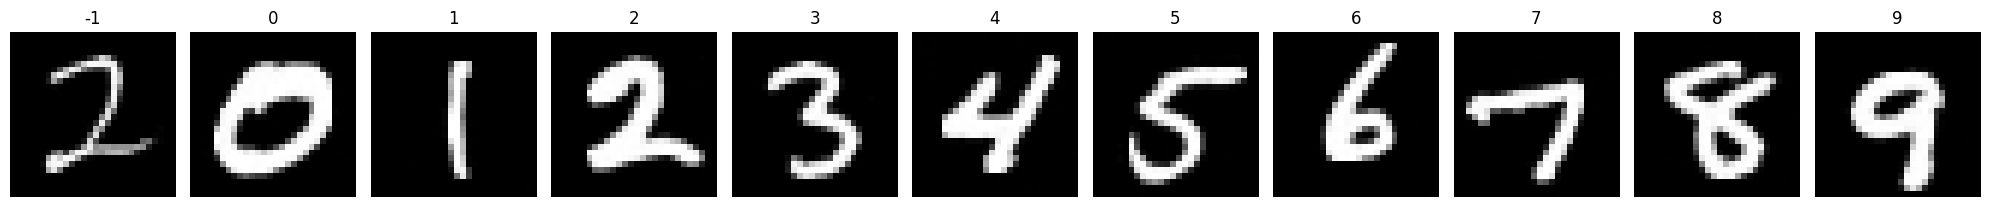

Epoch 281/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0339 - val_noise_loss: 0.0339 - val_image_loss: 0.1901 - learning_rate: 9.8644e-06


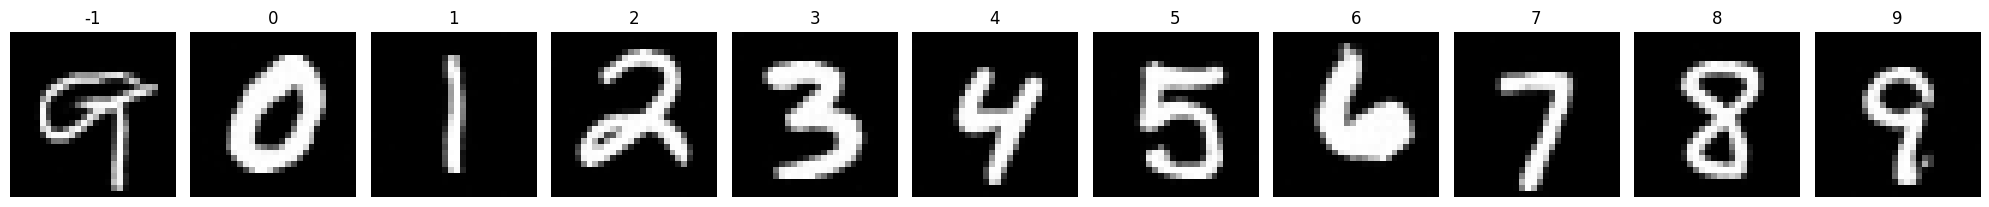

Epoch 282/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0220 - val_loss: 0.0334 - val_noise_loss: 0.0334 - val_image_loss: 0.1937 - learning_rate: 8.8564e-06


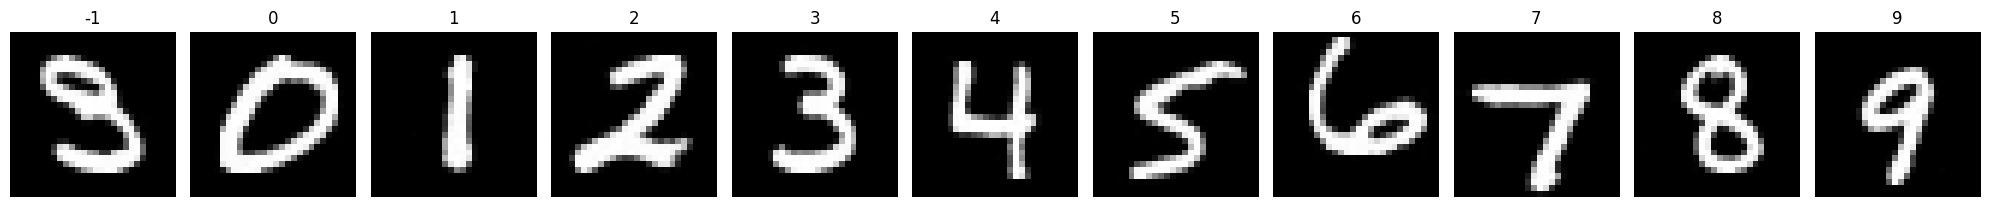

Epoch 283/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1932 - learning_rate: 7.9022e-06


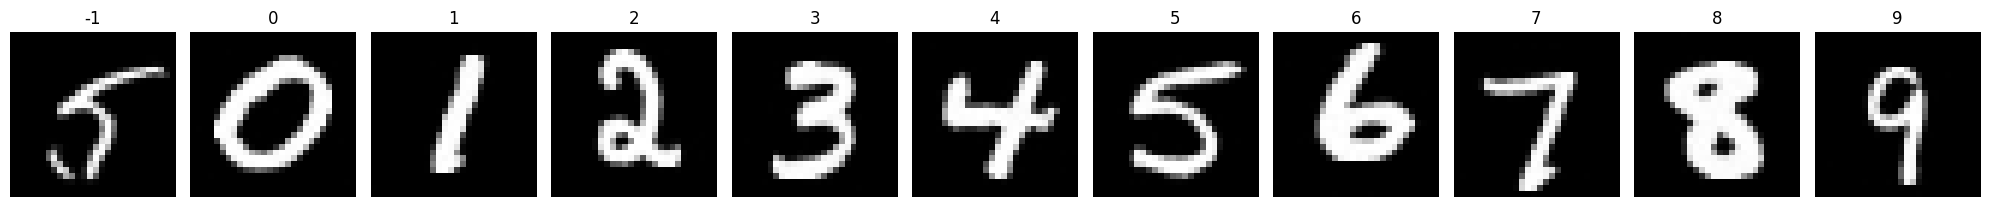

Epoch 284/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0220 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1950 - learning_rate: 7.0020e-06


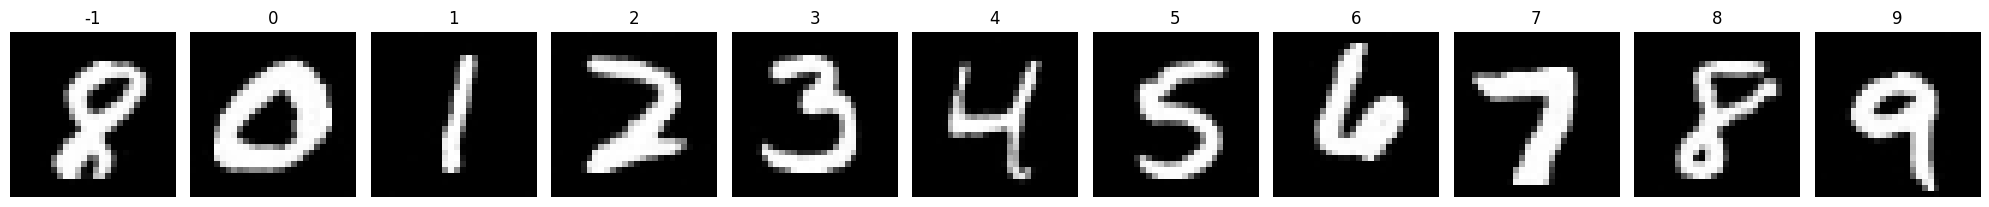

Epoch 285/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0223 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1890 - learning_rate: 6.1558e-06


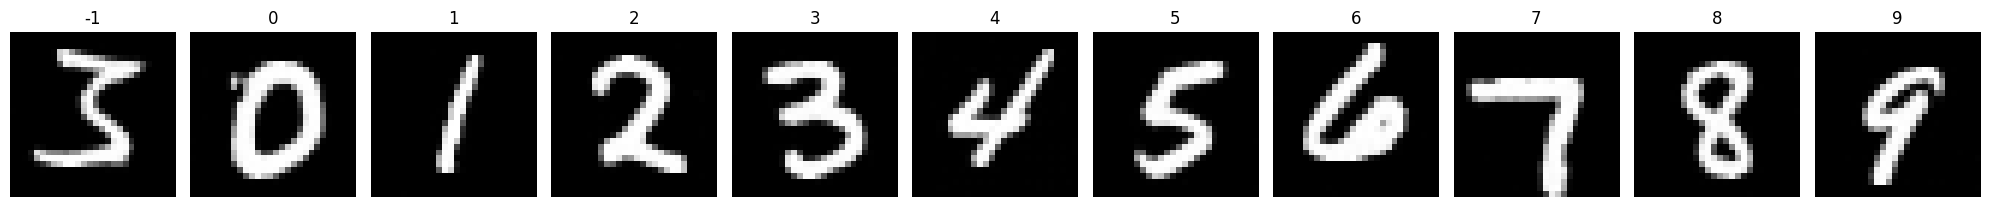

Epoch 286/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1948 - learning_rate: 5.3638e-06


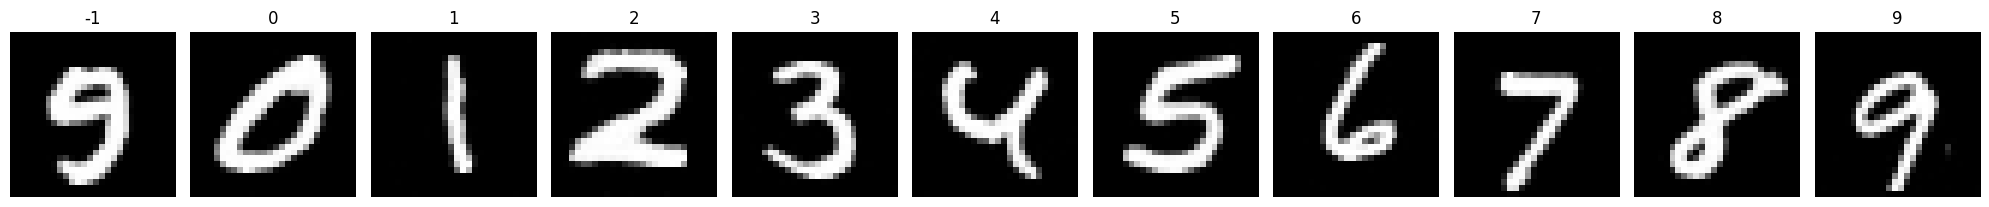

Epoch 287/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1965 - learning_rate: 4.6261e-06


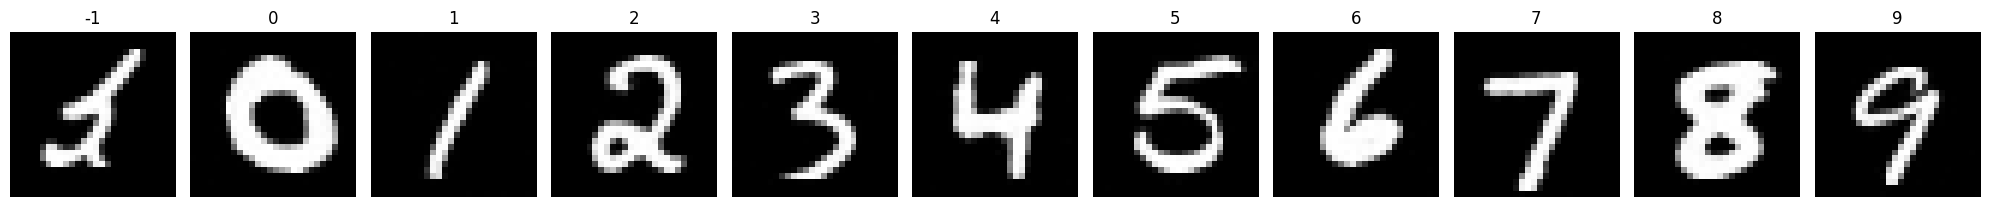

Epoch 288/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0221 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1988 - learning_rate: 3.9426e-06


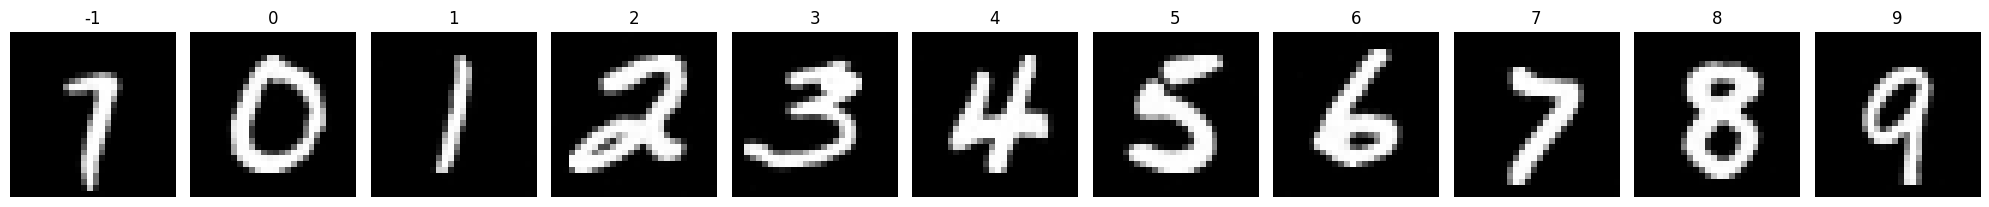

Epoch 289/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1911 - learning_rate: 3.3136e-06


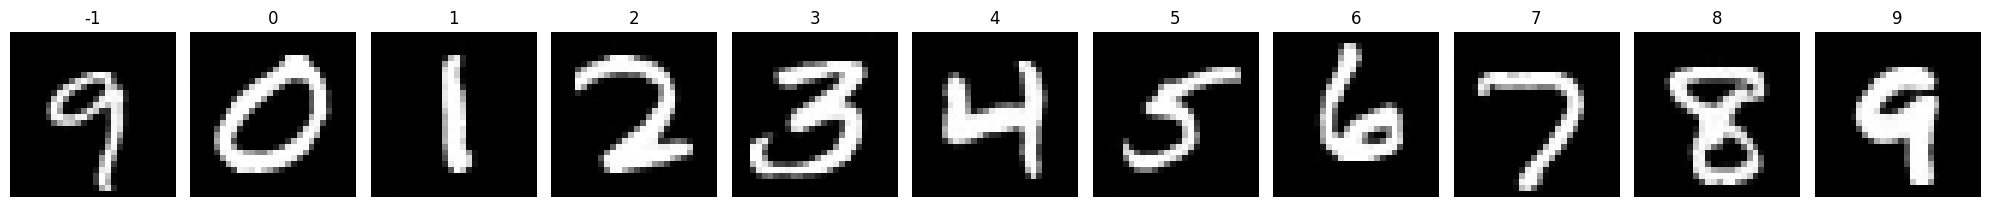

Epoch 290/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0223 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1935 - learning_rate: 2.7390e-06


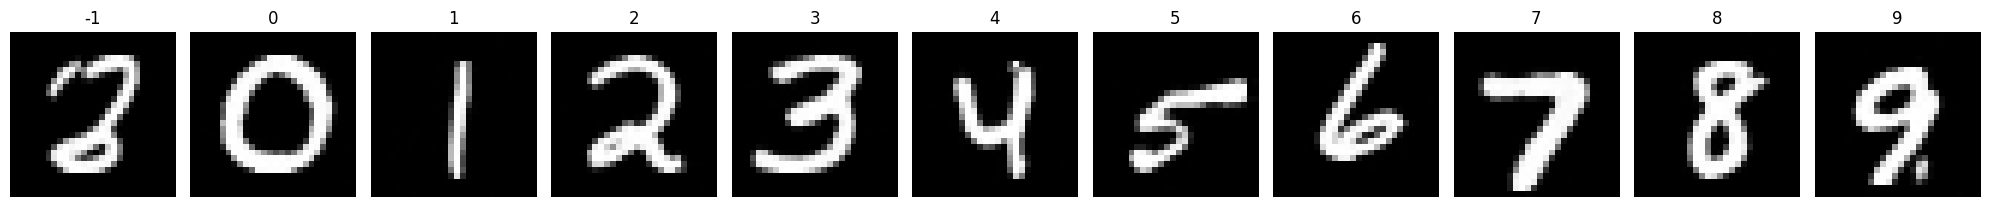

Epoch 291/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1933 - learning_rate: 2.2190e-06


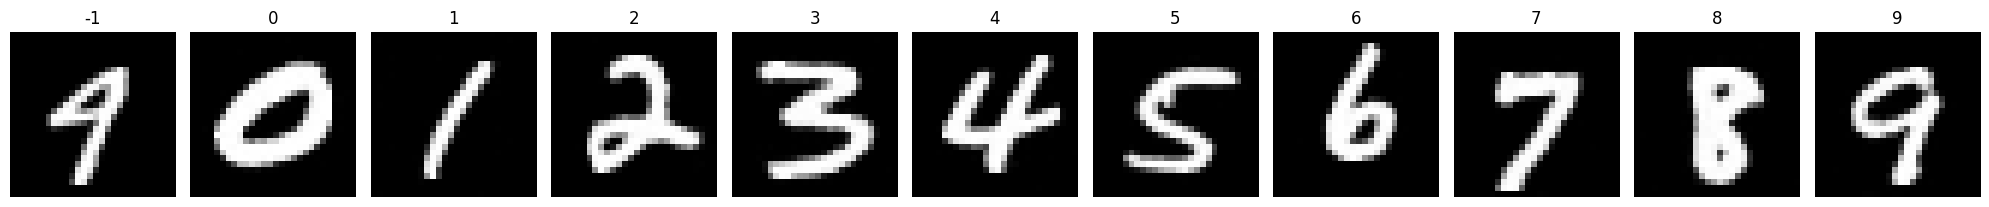

Epoch 292/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1966 - learning_rate: 1.7536e-06


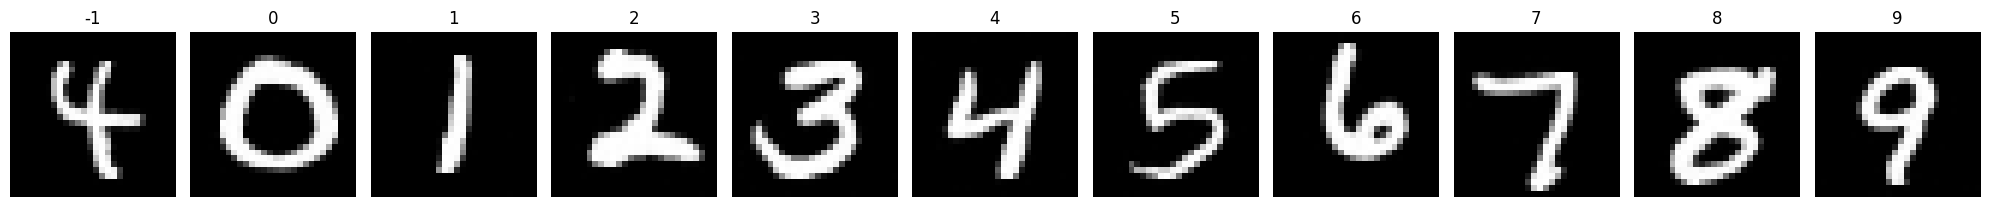

Epoch 293/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1949 - learning_rate: 1.3427e-06


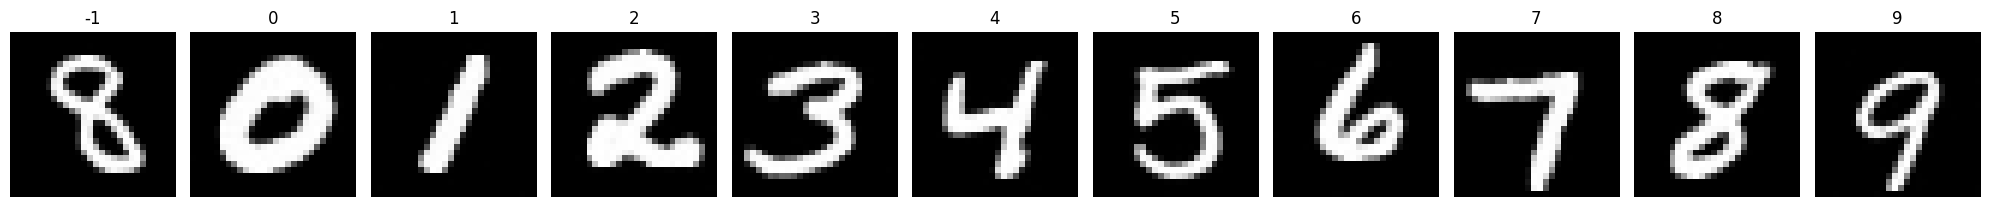

Epoch 294/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1946 - learning_rate: 9.8664e-07


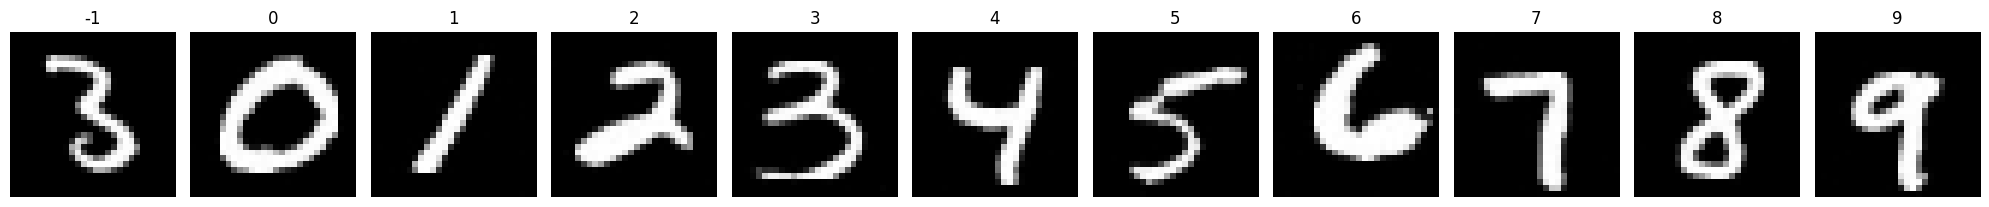

Epoch 295/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1900 - learning_rate: 6.8522e-07


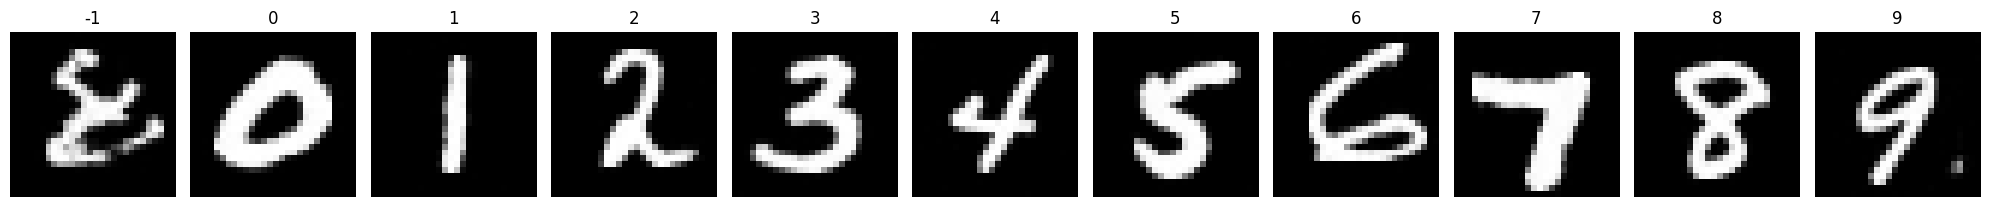

Epoch 296/300
468/468 [==============================] - 116s 247ms/step - noise_loss: 0.0222 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1969 - learning_rate: 4.3857e-07


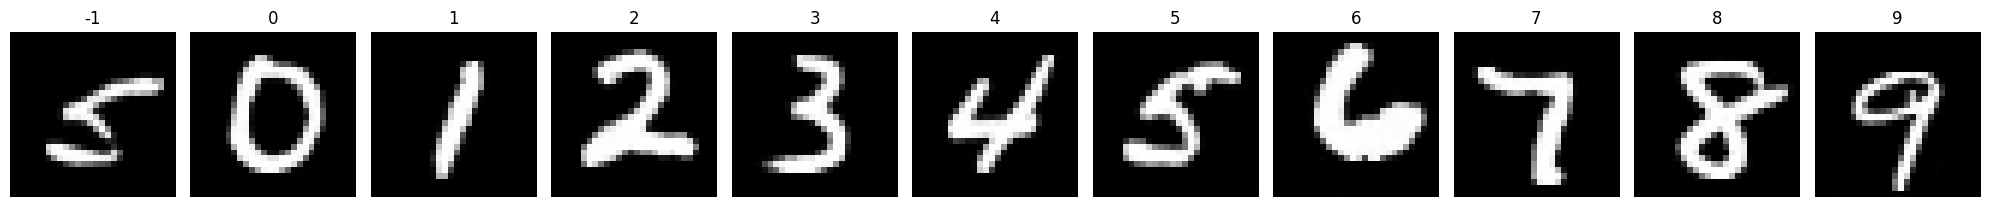

Epoch 297/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0334 - val_noise_loss: 0.0334 - val_image_loss: 0.1923 - learning_rate: 2.4673e-07


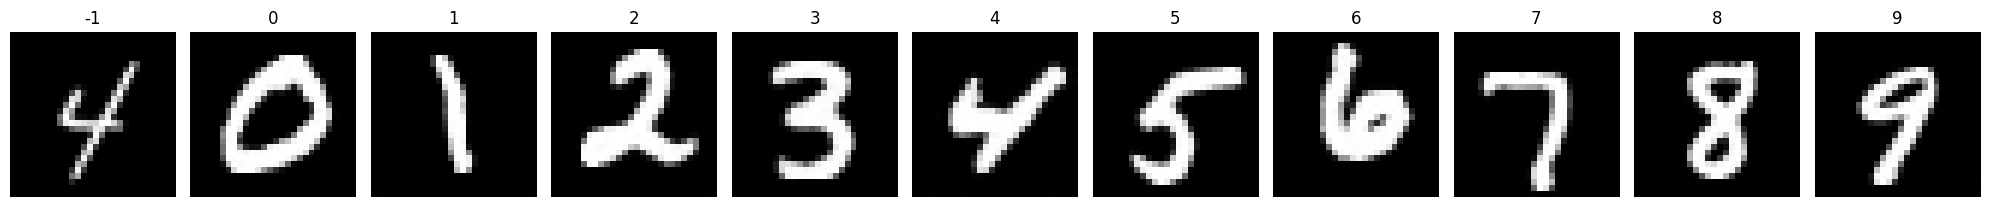

Epoch 298/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0222 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1991 - learning_rate: 1.0964e-07


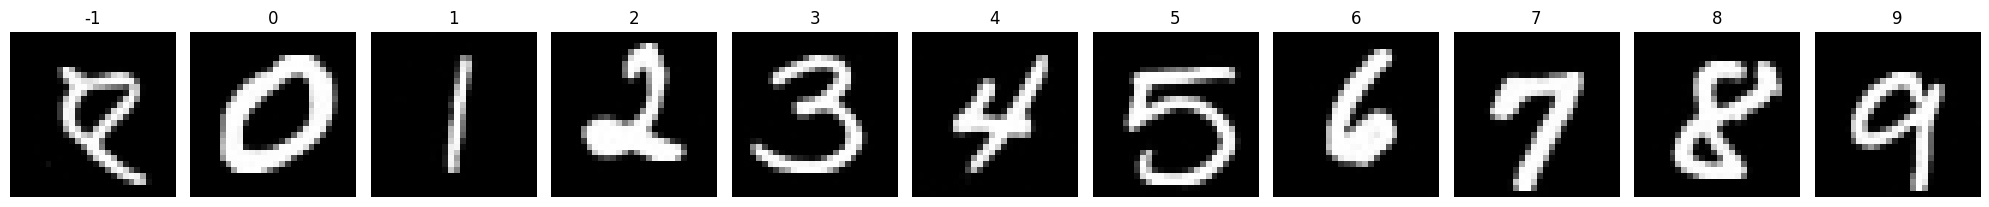

Epoch 299/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0220 - val_loss: 0.0337 - val_noise_loss: 0.0337 - val_image_loss: 0.1981 - learning_rate: 2.7418e-08


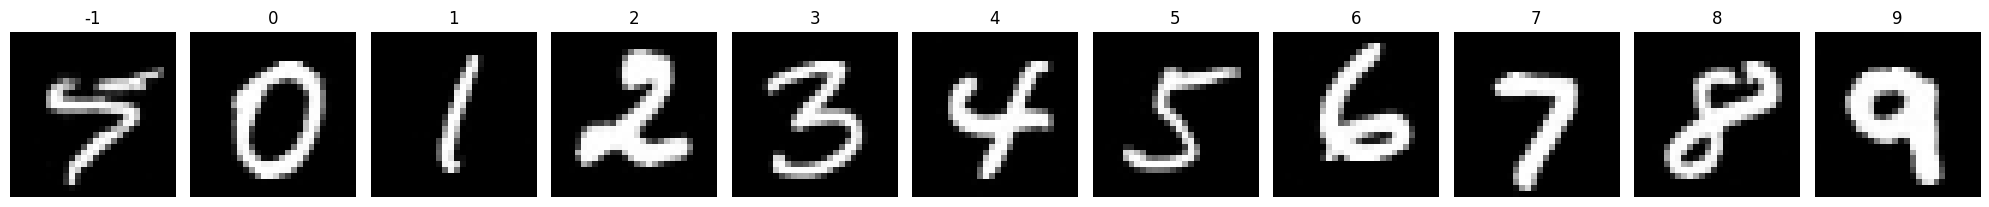

Epoch 300/300
468/468 [==============================] - 116s 248ms/step - noise_loss: 0.0221 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1994 - learning_rate: 0.0000e+00


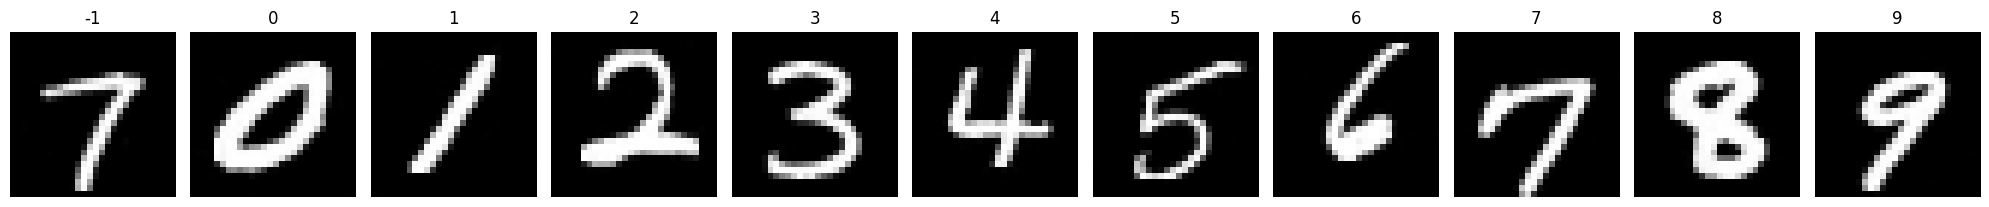

In [8]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [9]:
model.evaluate(valset, network_name="ema")

79/79 [==============================] - 13s 166ms/step - loss: 0.0338 - noise_loss: 0.0338 - image_loss: 0.1958


[0.03375464305281639, 0.03375464305281639, 0.1958233267068863]

In [10]:
model.evaluate(valset, network_name="raw")

79/79 [==============================] - 16s 166ms/step - loss: 0.0343 - noise_loss: 0.0343 - image_loss: 0.1979


[0.03426262363791466, 0.03426262363791466, 0.19791442155838013]

In [ ]:
model.save_weights("./models/DiT/model.weights.h5")

Steps: 1000/1000


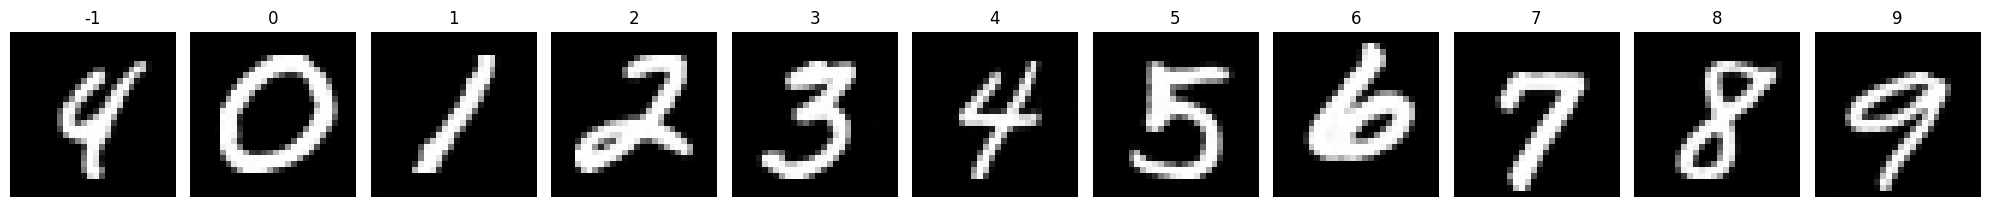

In [12]:
from common.utils import plot_images


imgs = model.sample(add_null_label=True, scale=3., eta=1., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


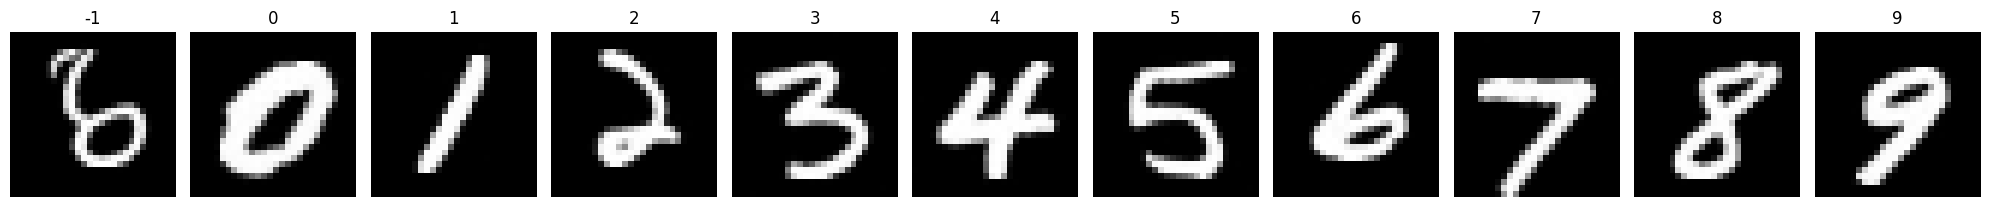

In [13]:
imgs = model.sample(add_null_label=True, scale=3., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


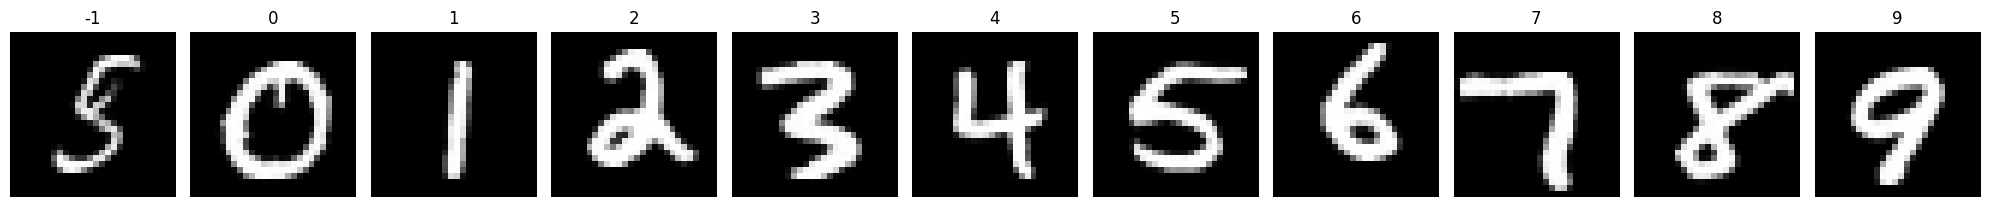

In [14]:
imgs = model.sample(add_null_label=True, scale=3., verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


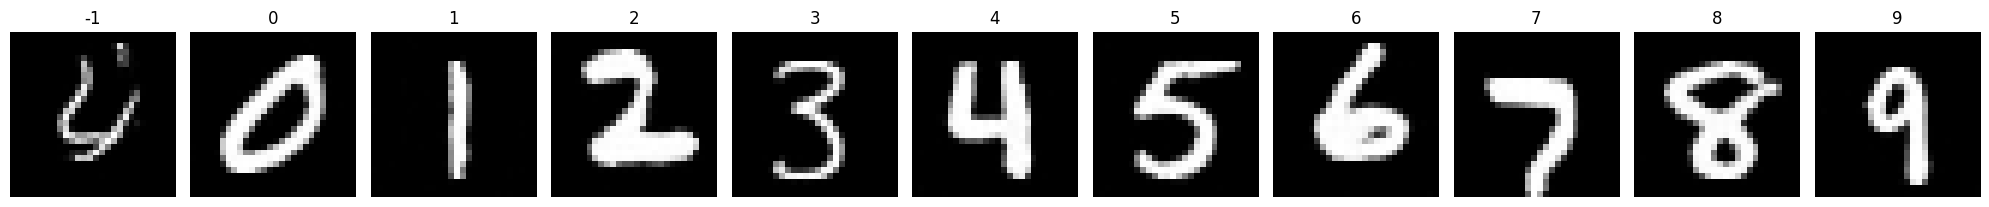

In [15]:
imgs = model.sample(add_null_label=True, scale=4., verbose=True)
plot_images(imgs, has_null_label=True)

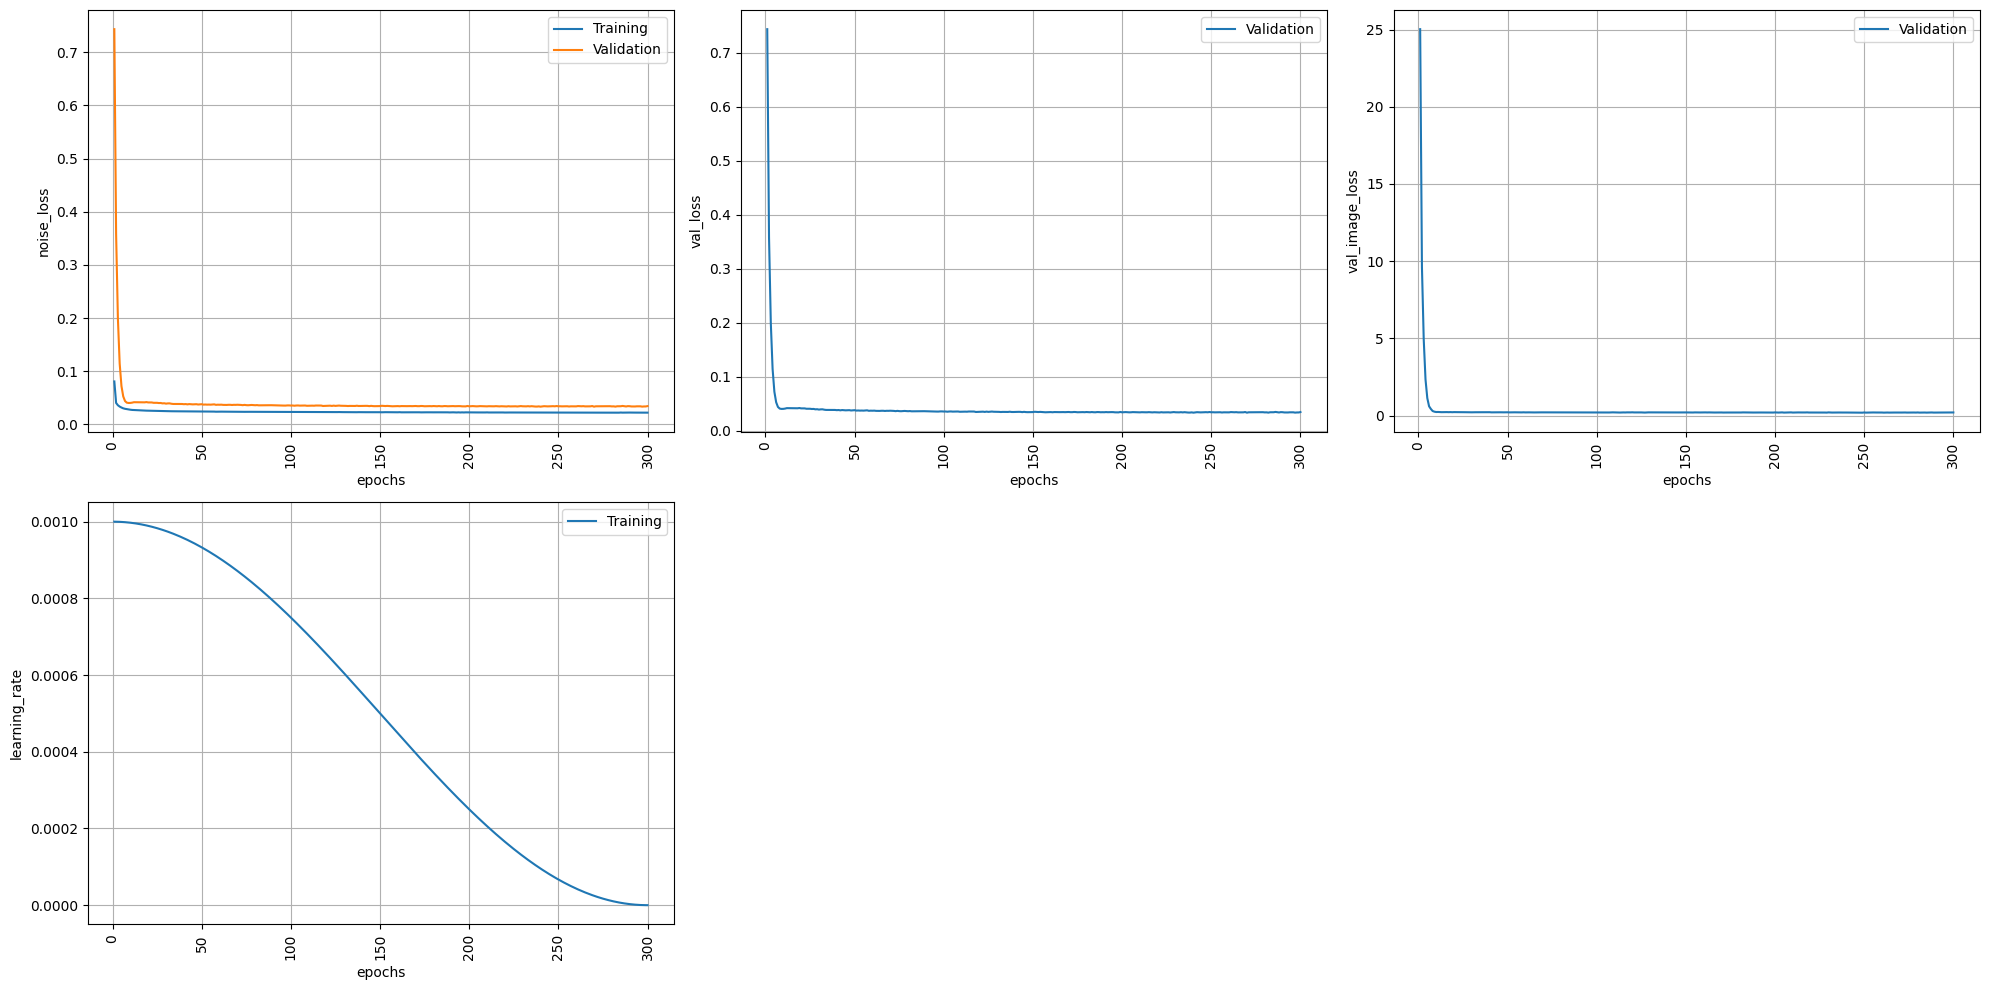

In [16]:
from common.utils import plot_history


plot_history(history, show_all_x_ticks=False)

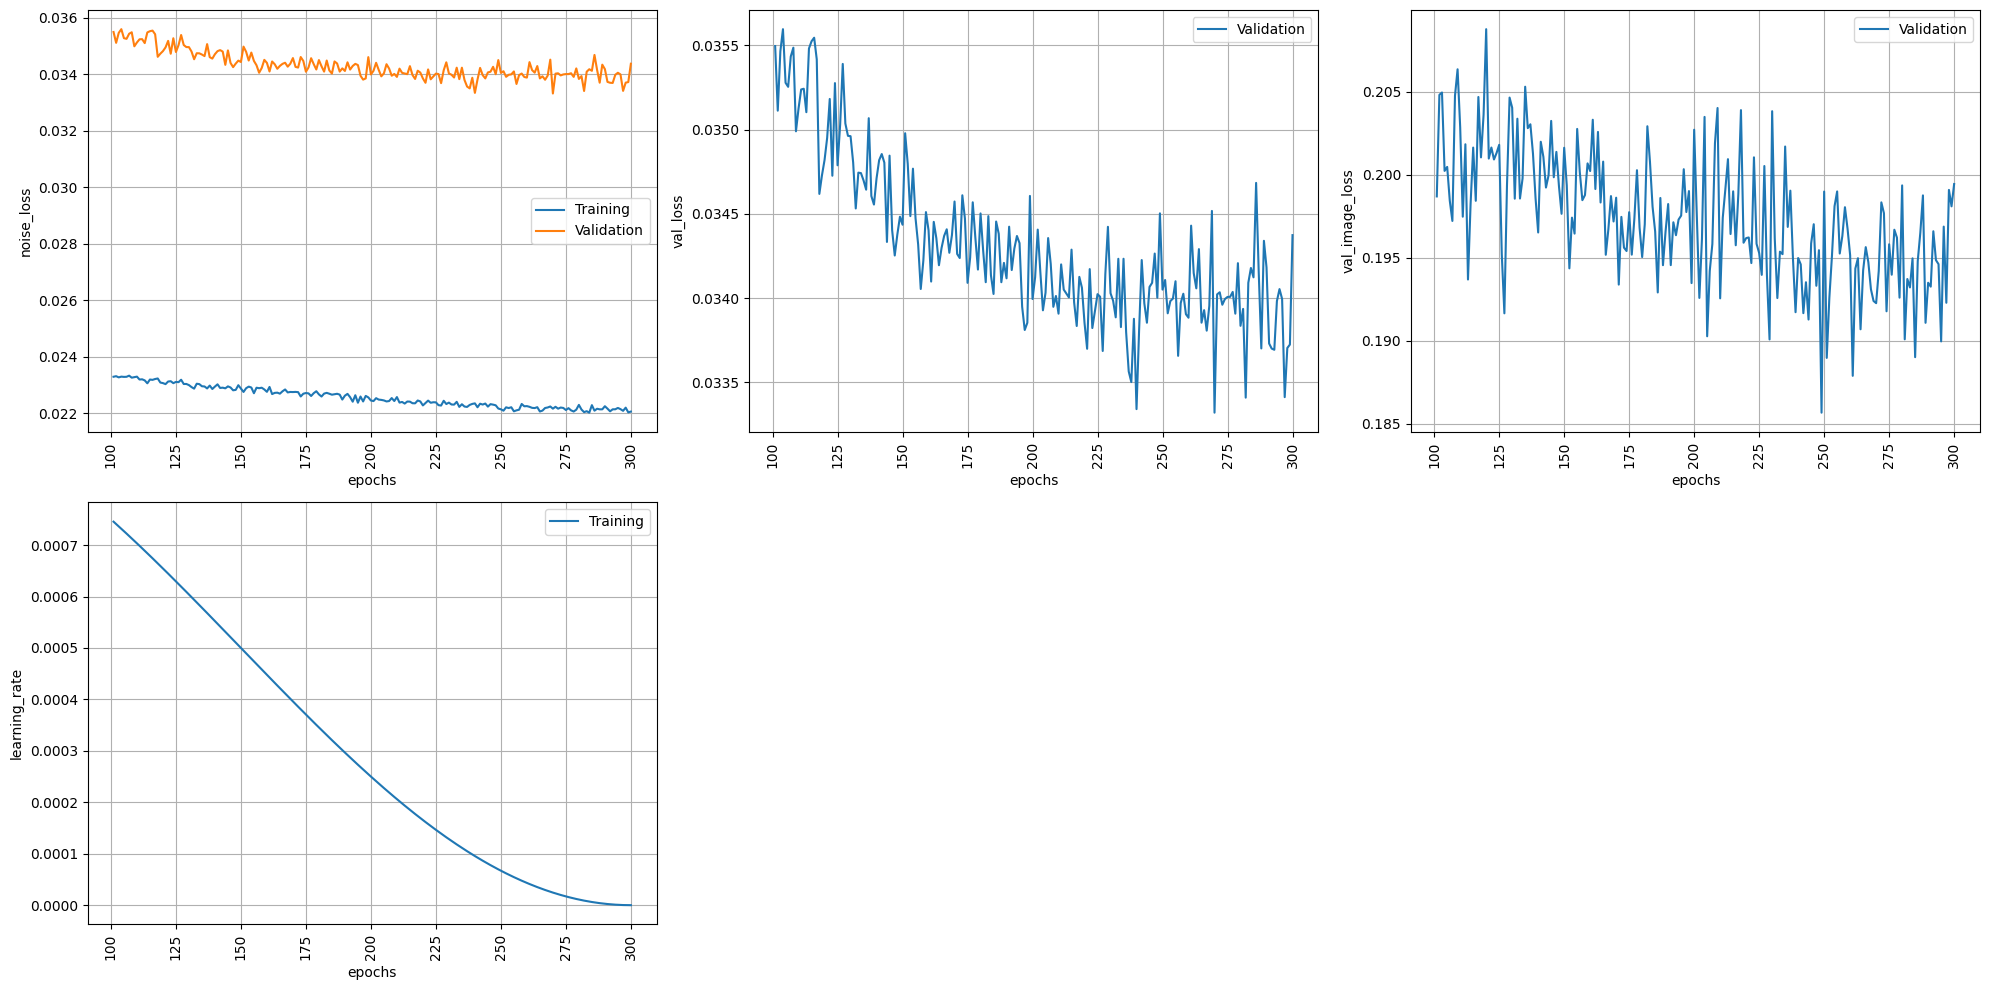

In [17]:
plot_history(history, show_all_x_ticks=False, range_=(100, None))